# Fonctions pour le projet

In [1]:
# Intégration des librairies
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import pylab
import datetime
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
import seaborn as sns
import os as os
import unicodedata
import sys
from unidecode import unidecode
import scrapy as scrapy
from bs4 import BeautifulSoup
import requests
import re

import warnings
warnings.simplefilter("ignore")

# Fonction pour récupérer automatiquement les sources de données, les concaténer et mener des vérifications
    # Test de la structure commune entre les sources de données
    # Concaténation des données quand la structure est commune entre les sources des données
    # Vérification du bon nombre de données concaténé par rapport aux sources de données
def recup_data_concatenation (chemin_dossier):
    
    # Compteur qui va nous permettre d'effectuer des tâches selon l'itération de la boucle, utile pour détecter la première itération
    counter = 0
    
    for filename in os.listdir(chemin_dossier):
        
        # Récupération du premier fichier dans le dossier, qui nous permettra de compléter pour la première fois le dataframe qui compte contenir toutes les données (datafram_concat)
        if counter == 0 & filename.endswith('.csv'):
            
            # Navigation et recherche dans le chemin du dossier du premier fichier CSV
            file_path = os.path.join(chemin_dossier, filename)
            # Lecture et enregistrement des données du premier fichier dans la variable "data_first_file"
            data_first_file = pd.read_csv(file_path)
            
            # Ajout des données du premier fichier dans le data frame qui compte tout rassembler
            dataframe_concat = data_first_file
            
            # Pour le test unitaire du nombre de données présentes avec concaténation et source de données une par une | Ajout dans une variable de la longueur de la première source de données
            lenght_data_source = len(data_first_file) 
            
            # Incrémentation du compteur, car on a passé la première étape de récupération du premier fichier
            counter += 1
        
        # SI le prochain fichier est un CSV ALORS 
        elif filename.endswith('.csv'):

            # Navigation et recherche dans le chemin du dossier du prochain fichier CSV
            file_path = os.path.join(chemin_dossier, filename)
            # Lecture et enregistrement des données du prochain fichier dans la variable "data_file"
            data_file = pd.read_csv(file_path)
                
            # Pour le test unitaire du nombre de données présentes avec concaténation et source de données une par une | Ajout dans une variable de la longueur des sources de données suivantes
            lenght_data_source = lenght_data_source + len(data_file) 
            
            # Condition, s'il n'y a pas d'erreur dans la comparaison des en-tetes du fichier référence et le dernier fichier récupéré ALORS on concatène et rassemble le dernier fichier avec les précédents fichiers obtenus
            if data_file.columns.equals(dataframe_concat.columns) == True:
                
                dataframe_concat = pd.concat([dataframe_concat, data_file], axis=0)
            
            # SInon cela voudra dire qu'il y a des différences dans la structure des en-tetes entre les fichiers précédents et le fichier actuel, ALORS on indique l'erreur et break la boucle et pas de concaténation de données avec le dernier fichier
            else :
                
                print("Différence de structure pour le fichier " + str(filename))
                pass
        
        # Sinon cela voudra dire qu'il n'y a pas de fichier avec l'extension .CSV, donc on break et sort de la boucle
        else :
            
            print("Pas de fichier CSV avec l'extension .CSV, problème provenant avec le fichier "+ str(filename))
            pass
        
    # Test unitaire, contrôle d'un nombre de données identiques entre la concaténation et les sources de données brutes
        # Si le nombre de données est identique entre concaténation ET sources de données brutes ALORS message précisant que c'est OK
    if len(dataframe_concat) == lenght_data_source :
        
        print("OK pour le test unitaire concernant le nombre de données entre concaténation et brute")
    
        # Sinon message précisant que ce n'est pas OK, qu'il y a une erreur avec un nombre de données différents
    else:
        print("PAS OK pour le test unitaire concernant le nombre de données entre concaténation et brute : \n-Pour les données brutes on a : "+str(lenght_data_source)+ "\n-Pour les données concaténées on a : "+str(len(dataframe_concat)) )
    
        
    return dataframe_concat
    
# Fonction pour enchainer l'affichage de la détection des valeurs non assingées OU vides sur chaque dataframe
def detect_valeur_nan_vide (list_tables):

    #Boucle pour effectuer les tâches répétitives de contrôle, utilisation d'un dictionnaire pour obtenir le dataframe et le nom de chaque dataframe
    for name_dataframe, dataframe in list_tables.items(): 
        
        print("Le nombre de ligne pour la table "+ name_dataframe +" est de : "+ str(len(dataframe)))
        result = dataframe.isnull().sum()
        print("Voici le nombre de valeurs non assingées et vides pour les champs de la table " + str(name_dataframe) + " :" + '\n\n' +str(result))
        print('\n')

# Fonction pour analyser les années avec le nombre de lignes NA sur les champs
def proportion_year_na(dataframe_name, date_column_name, name_dataframe_str) :
  
    # On donne le nom au dataframe que l'on traite
    dataframe_name.name = name_dataframe_str

    # Création d'une colonne avec l'année obtenu du champ de date du dataframe
    dataframe_with_year = dataframe_name
    dataframe_with_year[date_column_name] = dataframe_with_year[date_column_name].astype("str")
    dataframe_with_year["year"] = dataframe_with_year[date_column_name].str[:4]
    
    for column in dataframe_name: 
        
        # Si le nombre de valeurs NA est supérieur à 0, Alors traitement pour afficher la proportion par année, pour identifier les sources de données problématiques et à potentiellement écarter
        if dataframe_name[column].isnull().sum() > 0:
    
            # Récupération des lignes avec les valeurs NA pour la colonne souhaitée
            dataframe_na_value = dataframe_with_year[dataframe_with_year[column].isna()]
            # Remplacement des NA par 0 pour pouvoir mener le count sur la colonne analysé dans l'itération de la boucle
            dataframe_na_value = dataframe_na_value.fillna(0)
            
            # Group BY pour récupérer les proportions de lignes NA par année pour chaque colonne
            tourney_groupby_date = dataframe_na_value.groupby(["year"]).agg({column:"count"})
            tourney_groupby_date = tourney_groupby_date.rename(columns={column: 'na_row'})
            tourney_groupby_date = tourney_groupby_date.reset_index()
            
            # Passage des chiffres en répartition par pourcentage par année
            total_value_na = tourney_groupby_date["na_row"].sum()
            tourney_groupby_date["percentage_na_row"] = round((tourney_groupby_date["na_row"]/total_value_na) *100,1)
            
            # Affichage des résultats
            print("Pour le dataframe " + dataframe_name.name + " et la donnée "+ str(column) + " on a " + str(dataframe_name[column].isnull().sum()) +" valeurs NA")
            
            print("\n et voici les proportions de valeurs NA sur les années :\n ")
            print(tourney_groupby_date)
            print("\n")
            

        # Si le nombre de valeurs NA est égal à 0 alors pas besoin d'effectuer de traiement
        else :
            pass

# Fonction permettant de supprimer les caractéres spéciaux ET rendre le name sous la forme capitalisée
def remove_special_characters_capitalize(name_dataframe_column):
    # unidecode permet de remplacer les caractères spéciaux automatiquement (ASCII et tout)
    name_dataframe_column = name_dataframe_column.apply(unidecode)
    name_dataframe_column = name_dataframe_column.str.capitalize()
    return name_dataframe_column


# 0. Récupération des jeux de données

In [2]:
# Intégration des données des matchs -> Voir rassemblement des données de match (1.1)

# Intégration des données des joueurs
atp_players = pd.read_csv("M:\\disque d hdd\\Dropbox\\alternance_OC_GoodLight\\Projet 8\\data\\players\\atp_players.csv")
country_code_iso = pd.read_excel("M:\\disque d hdd\\Dropbox\\alternance_OC_GoodLight\\Projet 8\\data\\players\\pays_code_iso_alpha_3.xlsx")
#atp_players = pd.read_csv("C:\\Users\\Stefan\\Desktop\\projet_8_OCR\\projet OCR 8-20230820T225451Z-001\\projet OCR 8\\data\\players\\atp_players.csv")
#country_code_iso = pd.read_csv("C:\\Users\\Stefan\\Desktop\\projet_8_OCR\\projet OCR 8-20230820T225451Z-001\\projet OCR 8\\data\\players\\pays_code_iso_alpha_3.csv")


# Intégration des données de ranking -> Voir rassemblement des données de ranking (1.2)

# 1. Rassemblement des données

## 1.1 Rassemblement des données de match

In [3]:
# Appel de la fonction qui va permettre de contrôler la structure des sources de données et de rassembler les données en une et même source

atp_matches_90_to_22  = recup_data_concatenation("M:\\disque d hdd\\Dropbox\\alternance_OC_GoodLight\\Projet 8\\data\\matchs\\")
#atp_matches_90_to_22  = recup_data_concatenation("C:\\Users\\Stefan\\Desktop\\projet_8_OCR\\projet OCR 8-20230820T225451Z-001\\projet OCR 8\\data\matchs\\")
# Conclusion, aucun problème lors de la récupération et rassemblement des données dans le dossier des matchs

OK pour le test unitaire concernant le nombre de données entre concaténation et brute


## 1.2 Rassemblement des données de ranking

In [4]:
# Appel de la fonction qui va permettre de contrôler la structure des sources de données et de rassembler les données en une et même source

ranking_00_to_20  = recup_data_concatenation("M:\\disque d hdd\\Dropbox\\alternance_OC_GoodLight\\Projet 8\\data\\rankings\\")
#ranking_00_to_20  = recup_data_concatenation("C:\\Users\\Stefan\\Desktop\\projet_8_OCR\\projet OCR 8-20230820T225451Z-001\\projet OCR 8\\data\\rankings\\")

# Conclusion, aucun problème lors de la récupération et rassemblement des données dans le dossier des rankings

OK pour le test unitaire concernant le nombre de données entre concaténation et brute


# 2. Contrôle des données

## 2.1 Détection de doublon

In [5]:
# 1. Détection des doublons pour les données de match - Utilisation de plusieurs identifiants et champs que l'on va concaténer pour obtenir une clé unique
    # champs à concaténer pour la clé unique : Tourney_id + Tourney_date + Winner_id + Loser_id

    # Voir s'il y a besoin de passer les champs sous le type string pour rendre la concaténation possible
#print(atp_matches_90_to_22.dtypes)
#print(atp_matches_90_to_22.columns)
        # -> Besoin de passer les 4 champs sous le type string

    # Passage sous le type string des 4 champs
    ### !!! TROUVER UN MOYEN DE LE FAIRE POUR TOUS SUR UNE MEME LIGNE !!! ##
atp_matches_90_to_22_sans_doublon = atp_matches_90_to_22

    # Création de l'identifiant unique via la concaténation des champs
atp_matches_90_to_22_sans_doublon["id_atp_matches"] = atp_matches_90_to_22_sans_doublon["tourney_id"].astype("str") + atp_matches_90_to_22_sans_doublon["tourney_date"].astype("str") + atp_matches_90_to_22_sans_doublon["winner_id"].astype("str") + atp_matches_90_to_22_sans_doublon["loser_id"].astype("str")
print("Le nombre de ligne pour le dataframe "+ "atp_matches_90_to_22" +" est de : "+ str(len(atp_matches_90_to_22_sans_doublon.index)))
print("Voici le nombre de lignes uniques pour le dataframe " + "atp_matches_90_to_22" + " : " +str(atp_matches_90_to_22_sans_doublon['id_atp_matches'].nunique())) 
print("Contrôle effectué sur les champs "+"tourney_id, " + "tourney_date, " + "winner_id " + "et loser_id")
print('\n')

    # Affichage des doublons
print(atp_matches_90_to_22_sans_doublon[atp_matches_90_to_22_sans_doublon.duplicated(['id_atp_matches'], keep=False)])
#atp_matches_90_to_22_sans_doublon[atp_matches_90_to_22_sans_doublon.duplicated(['id_atp_matches'], keep=False)].sort_values("id_atp_matches", ascending = False)
# Conclusion : Doublon sur les matchs qui ont les mêmes joueurs en confrontation MAIS seulement des différences sur le numéro du match et quelques stats
    # Solution -> Rassembler les matchs via un group by sur l'id ET effectuer un MAX sur le numéro de match et la moyenne pour les stats des 8 matchs en doublon (first pour les autres champs string)
    
# 2. Détection des doublons pour les données de joueur - Utilisation seulement de l'identifiant player

atp_players_sans_doublon = atp_players

print("Le nombre de ligne pour le dataframe "+ "atp_players" +" est de : "+ str(len(atp_players_sans_doublon.index)))
print("Voici le nombre de lignes uniques pour le dataframe " + "atp_players" + " : " +str(atp_players_sans_doublon['player_id'].nunique())) 
print("Contrôle effectué sur le champ "+"player_id")
print('\n')

    # AUCUN DOUBLON

# 3. Détection des doublons pour les données de ranking - Utilisation de plusieurs identifiants et champs que l'on va concaténer pour obtenir une clé unique
    # champs à concaténer pour la clé unique : Ranking_date + Rank + Player_id

    # Voir s'il y a besoin de passer les champs sous le type string pour rendre la concaténation possible
#print(ranking_00_to_20.dtypes)
#print(ranking_00_to_20.columns)
        # -> Besoin de passer les 3 champs sous le type string

    # Passage sous le type string des 3 champs
    ### !!! TROUVER UN MOYEN DE LE FAIRE POUR TOUS SUR UNE MEME LIGNE !!! ##
ranking_00_to_20_sans_doublon = ranking_00_to_20

    # Création de l'identifiant unique via la concaténation des champs
ranking_00_to_20_sans_doublon["id_ranking"] = ranking_00_to_20_sans_doublon["ranking_date"].astype("str") +ranking_00_to_20_sans_doublon["rank"].astype("str") +ranking_00_to_20_sans_doublon["player"].astype("str")
print("Le nombre de ligne pour le dataframe "+ "ranking_00_to_20" +" est de : "+ str(len(ranking_00_to_20_sans_doublon.index)))
print("Voici le nombre de lignes uniques pour le dataframe " + "ranking_00_to_20" + " : " +str(ranking_00_to_20_sans_doublon['id_ranking'].nunique())) 
print("Contrôle effectué sur les champs "+"Ranking_date, " + "Rank " +"et Player_id")
print('\n')

    # Affichage des doublons
print(ranking_00_to_20_sans_doublon[ranking_00_to_20_sans_doublon.duplicated(['id_ranking'], keep=False)])
#ranking_00_to_20_sans_doublon[ranking_00_to_20_sans_doublon.duplicated(['id_ranking'], keep=False)].sort_values("id_ranking", ascending = False)
    # Conclusion : Doublon sur les rankings, desfois aucune différence et desfois seulement les points qui sont affichés sur une version et sur une autre les points en NA
        # Solution -> Rassembler les rankings des players via un group by sur l'id ET effectuer un MAX OU first sur tous les champs


Le nombre de ligne pour le dataframe atp_matches_90_to_22 est de : 699275
Voici le nombre de lignes uniques pour le dataframe atp_matches_90_to_22 : 699230
Contrôle effectué sur les champs tourney_id, tourney_date, winner_id et loser_id


     tourney_id        tourney_name surface  draw_size tourney_level  \
2731   2001-605         Masters Cup    Hard          8             F   
2735   2001-605         Masters Cup    Hard          8             F   
2660   2003-605         Masters Cup    Hard          8             F   
2664   2003-605         Masters Cup    Hard          8             F   
2646   2004-605         Masters Cup    Hard          8             F   
...         ...                 ...     ...        ...           ...   
8568  2019-9192         Shymkent CH    Clay         64             C   
240   2020-6932  ATP Rio de Janeiro    Clay         32             A   
242   2020-6932  ATP Rio de Janeiro    Clay         32             A   
2531  2020-9190            Parma CH    Cl

## 2.2 Traitement des doublons

In [6]:
# 1. Traitement des doublons pour la table match - utilisation d'un group by OU remove duplicate 

#print(atp_matches_90_to_22_sans_doublon.columns)
#len(atp_matches_90_to_22_sans_doublon)

    # Gestion du problème aperçu lors de la tentative de group by de données mixtes présentes dans des colonnes (exemple, valeurs de type float ET valeurs de type string), empêchant la fonction d'aggregation first OU max

# Fonction pour détecter Et afficher les types de données de toutes les valeurs des Colonnes du Dataframe
"""def detecter_type(valeur):
    return type(valeur)

# Appliquer la fonction à toutes les cellules du DataFrame
types_donnees = atp_matches_90_to_22_sans_doublon.applymap(detecter_type)

# Afficher le résultat
#print(types_donnees)

# Afficher toutes les valeurs uniques des types des valeurs composant les colonnes, pour visualiser ou il y a des données mixtes
for nom_colonne in types_donnees.columns:
    valeurs_uniques = types_donnees[nom_colonne].unique()
    print(f"Colonnes {nom_colonne} : {valeurs_uniques}")
"""
# Données mixtes présentes sur les colonnes "tourney_level", "winner_entry", "winner_hand", "loser_entry", "loser_hand", "score"

    # Passage en String des colonnes avec des valeurs mixtes problèmatiques pour le Group By
atp_matches_90_to_22_sans_doublon = atp_matches_90_to_22_sans_doublon.astype({"tourney_level": str,"winner_entry": str,"winner_hand": str,"loser_entry": str,"loser_hand": str,"score": str}) 
    
    # Group By 
atp_matches_90_to_22_sans_doublon = atp_matches_90_to_22_sans_doublon.groupby(["id_atp_matches"]).agg({"tourney_id":"first",
                                                                                                      "tourney_name":"first",
                                                                                                      "surface":"first",
                                                                                                      "draw_size":"max",
                                                                                                      "tourney_level":"first",
                                                                                                      "tourney_date":"first",
                                                                                                      "match_num":"max",
                                                                                                      "winner_id":"max",
                                                                                                      "winner_seed":"max",
                                                                                                      "winner_entry":"max",
                                                                                                      "winner_name":"first",
                                                                                                      "winner_hand":"first",
                                                                                                      "winner_ht":"max",
                                                                                                      "winner_ioc":"first",
                                                                                                      "winner_age":"first",
                                                                                                      "loser_id":"max",
                                                                                                      "loser_seed":"max",
                                                                                                      "loser_entry":"max",
                                                                                                      "loser_name":"first",
                                                                                                      "loser_hand":"first",
                                                                                                      "loser_ht":"max",
                                                                                                      "loser_ioc":"first",
                                                                                                      "loser_age":"first",
                                                                                                      "score":"max",
                                                                                                      "best_of":"max",
                                                                                                      'round':"max",
                                                                                                      "minutes":"mean",
                                                                                                      "w_ace":"mean",
                                                                                                      "w_df":"mean",
                                                                                                      "w_svpt":"mean",
                                                                                                      "w_1stIn":"mean",
                                                                                                      "w_1stWon":"mean",
                                                                                                      "w_2ndWon":"mean",
                                                                                                      "w_SvGms":"mean",
                                                                                                      "w_bpSaved":"mean",
                                                                                                      "w_bpFaced":"mean",
                                                                                                      "l_ace":"mean",
                                                                                                      "l_df":"mean",
                                                                                                      "l_svpt":"mean",
                                                                                                      "l_ace":"mean",
                                                                                                      "l_1stIn":"mean",
                                                                                                      "l_1stWon":"mean",
                                                                                                      "l_2ndWon":"mean",
                                                                                                      "l_SvGms":"mean",
                                                                                                      "l_bpSaved":"mean",
                                                                                                      "l_bpFaced":"mean",
                                                                                                      "winner_rank":"max",
                                                                                                      "winner_rank_points":"mean",
                                                                                                      "loser_rank":"max",
                                                                                                      "loser_rank_points":"mean",
         })
atp_matches_90_to_22_sans_doublon = atp_matches_90_to_22_sans_doublon.reset_index()

print(len(atp_matches_90_to_22_sans_doublon))

    # Remove dupplicate (mais on ne fait pas la moyenne, garde seulement la première ou dernière itération) 

#atp_matches_90_to_22_sans_doublon = atp_matches_90_to_22_sans_doublon.drop_duplicates(subset=['id_atp_matches'], keep='first')

#print(len(atp_matches_90_to_22_sans_doublon))

# 2. Traitement des doublons pour la table ranking

#print(ranking_00_to_20_sans_doublon.columns)
#len(ranking_00_to_20_sans_doublon)

    # Group By 

ranking_00_to_20_sans_doublon = ranking_00_to_20_sans_doublon.groupby(["id_ranking"]).agg({"ranking_date":"max",
                                                                                                      "rank":"max",
                                                                                                      "player":"max",
                                                                                                      "points":"max"})
ranking_00_to_20_sans_doublon = ranking_00_to_20_sans_doublon.reset_index()

#print(len(ranking_00_to_20_sans_doublon))

    # Remove dupplicate (mais on ne fait pas la max ou frist, garde seulement la première ou dernière itération) 

#ranking_00_to_20_sans_doublon = ranking_00_to_20_sans_doublon.drop_duplicates(subset=['id_ranking'], keep='first')

#print(len(ranking_00_to_20_sans_doublon))

699230


## 2.3 Détection de valeur NA

In [7]:
# 1. Boucle des tâches pour contrôles valeurs nan et vides pour toutes les tables
list_table_projet_na = {"atp_matches":atp_matches_90_to_22_sans_doublon, "atp_players":atp_players_sans_doublon, "atp_rankings":ranking_00_to_20_sans_doublon}
# Appel de la fonction 
detect_valeur_nan_vide(list_table_projet_na)

Le nombre de ligne pour la table atp_matches est de : 699230
Voici le nombre de valeurs non assingées et vides pour les champs de la table atp_matches :

id_atp_matches             0
tourney_id                 0
tourney_name               0
surface                    0
draw_size                  0
tourney_level              0
tourney_date               0
match_num                  0
winner_id                  0
winner_seed           388700
winner_entry               0
winner_name                0
winner_hand                0
winner_ht             269969
winner_ioc                 0
winner_age              3783
loser_id                   0
loser_seed            540017
loser_entry                0
loser_name                 0
loser_hand                 0
loser_ht              360627
loser_ioc                  0
loser_age               6483
score                      0
best_of                    0
round                      0
minutes               540916
w_ace                 535459
w_df 

### 2.3.1 Proportion des valeurs NA par an pour les matchs (source de données par année OU groupe d'années)

In [8]:
# Analyse du nombre de lignes NA pour chaque colonne sur les années pour les données de matchs
proportion_year_na(atp_matches_90_to_22_sans_doublon,"tourney_date","atp_matches_90_to_22")

Pour le dataframe atp_matches_90_to_22 et la donnée winner_seed on a 388700 valeurs NA

 et voici les proportions de valeurs NA sur les années :
 
    year  na_row  percentage_na_row
0   1990    3845                1.0
1   1991    9376                2.4
2   1992    8706                2.2
3   1993    9636                2.5
4   1994    9887                2.5
5   1995   10114                2.6
6   1996   10600                2.7
7   1997   11395                2.9
8   1998   11666                3.0
9   1999   11498                3.0
10  2000   11602                3.0
11  2001   12171                3.1
12  2002   11741                3.0
13  2003   12292                3.2
14  2004   12870                3.3
15  2005   13047                3.4
16  2006   13423                3.5
17  2007   14049                3.6
18  2008   14082                3.6
19  2009   13401                3.4
20  2010   12908                3.3
21  2011   13051                3.4
22  2012   14066         

Pour le dataframe atp_matches_90_to_22 et la donnée w_ace on a 535459 valeurs NA

 et voici les proportions de valeurs NA sur les années :
 
    year  na_row  percentage_na_row
0   1990    6148                1.1
1   1991   12467                2.3
2   1992   11661                2.2
3   1993   13395                2.5
4   1994   13920                2.6
5   1995   14913                2.8
6   1996   16037                3.0
7   1997   17228                3.2
8   1998   17008                3.2
9   1999   17110                3.2
10  2000   16855                3.1
11  2001   17820                3.3
12  2002   17187                3.2
13  2003   18520                3.5
14  2004   19550                3.7
15  2005   20526                3.8
16  2006   21411                4.0
17  2007   23084                4.3
18  2008   23991                4.5
19  2009   22388                4.2
20  2010   15517                2.9
21  2011   17158                3.2
22  2012   18823               

Pour le dataframe atp_matches_90_to_22 et la donnée w_bpSaved on a 535459 valeurs NA

 et voici les proportions de valeurs NA sur les années :
 
    year  na_row  percentage_na_row
0   1990    6148                1.1
1   1991   12467                2.3
2   1992   11661                2.2
3   1993   13395                2.5
4   1994   13920                2.6
5   1995   14913                2.8
6   1996   16037                3.0
7   1997   17228                3.2
8   1998   17008                3.2
9   1999   17110                3.2
10  2000   16855                3.1
11  2001   17820                3.3
12  2002   17187                3.2
13  2003   18520                3.5
14  2004   19550                3.7
15  2005   20526                3.8
16  2006   21411                4.0
17  2007   23084                4.3
18  2008   23991                4.5
19  2009   22388                4.2
20  2010   15517                2.9
21  2011   17158                3.2
22  2012   18823           

Pour le dataframe atp_matches_90_to_22 et la donnée l_2ndWon on a 535459 valeurs NA

 et voici les proportions de valeurs NA sur les années :
 
    year  na_row  percentage_na_row
0   1990    6148                1.1
1   1991   12467                2.3
2   1992   11661                2.2
3   1993   13395                2.5
4   1994   13920                2.6
5   1995   14913                2.8
6   1996   16037                3.0
7   1997   17228                3.2
8   1998   17008                3.2
9   1999   17110                3.2
10  2000   16855                3.1
11  2001   17820                3.3
12  2002   17187                3.2
13  2003   18520                3.5
14  2004   19550                3.7
15  2005   20526                3.8
16  2006   21411                4.0
17  2007   23084                4.3
18  2008   23991                4.5
19  2009   22388                4.2
20  2010   15517                2.9
21  2011   17158                3.2
22  2012   18823            

Pour le dataframe atp_matches_90_to_22 et la donnée loser_rank_points on a 100797 valeurs NA

 et voici les proportions de valeurs NA sur les années :
 
    year  na_row  percentage_na_row
0   1990     601                0.6
1   1991    4189                4.2
2   1992    3526                3.5
3   1993    4110                4.1
4   1994    3948                3.9
5   1995    4290                4.3
6   1996    4042                4.0
7   1997    3821                3.8
8   1998    3839                3.8
9   1999    2533                2.5
10  2000    2353                2.3
11  2001    2416                2.4
12  2002    2394                2.4
13  2003    2541                2.5
14  2004    2663                2.6
15  2005    3083                3.1
16  2006    2793                2.8
17  2007    2859                2.8
18  2008    3034                3.0
19  2009    2590                2.6
20  2010    2653                2.6
21  2011    3152                3.1
22  2012    3349   

### 2.3.2 Proportion des valeurs NA par an pour les rankings (source de données par année OU groupe d'années)

In [9]:
# Analyse du nombre de lignes NA pour chaque colonne sur les années des données de ranking
proportion_year_na(ranking_00_to_20_sans_doublon,"ranking_date","ranking_00_to_20")

Pour le dataframe ranking_00_to_20 et la donnée points on a 70526 valeurs NA

 et voici les proportions de valeurs NA sur les années :
 
    year  na_row  percentage_na_row
0   1990    8102               11.5
1   1991    9179               13.0
2   1992    8225               11.7
3   1993    8168               11.6
4   1994    8091               11.5
5   1995    8116               11.5
6   1996    7631               10.8
7   1997    6336                9.0
8   1998    5845                8.3
9   1999      84                0.1
10  2000      34                0.0
11  2001      38                0.1
12  2002      55                0.1
13  2004     106                0.2
14  2005     163                0.2
15  2006      74                0.1
16  2007       6                0.0
17  2008      40                0.1
18  2010       1                0.0
19  2012       1                0.0
20  2017      61                0.1
21  2018      92                0.1
22  2019      78                0.1

In [10]:
print(len(atp_matches_90_to_22_sans_doublon))

699230


### 2.3.3 Conclusion détection de valeur NA

In [11]:
# 2.2.3.1 Analyse des données de match avec NA 

    # A. PAS PROBLEMATIQUE, car pas des champs utiles

        # Winner Seed : Pas utile, sera supprimé plus tard
        # Winner entry : Pas utile, sera supprimé plus tard
        # Loser Seed : Pas utile, sera supprimé plus tard
        # Loser entry : Pas utile, sera supprimé plus tard

    # B. REMPLACABLE, donnée utile pour les analyses
        
        # Winner_age : Remplacable, on peut recalculer l'age du joueur avec la base de données des joueurs - Problème, beaucoup de birthday non rempli pour les joueurs
            # Seulement 3783 valeurs NA -> Possibilité de les compléter à la main / 699230 matchs - 0,5 % manquantes
        # Loser_age : Remplacable, on peut recalculer l'age du joueur avec la base de données des joueurs - Problème, beaucoup de birthday non rempli pour les joueurs
            # Seulement 6483 valeurs NA -> Possibilité de les compléter à la main / 699230 matchs - 0,9 % manquantes
        
        # Winner_hand : Remplacable, on peut croiser les données avec la base "Player" pour compléter un maximum de valeurs inconnues
            # 0 valeurs NA 
            # 81917 Valeurs "U", inconnu / 699230 matchs - 11,7 % manquantes
        # Loser_hand : Remplacable, on peut croiser les données avec la base "Player" pour compléter un maximum de valeurs inconnues
            # 0 valeurs NA 
            # 131033 Valeurs "U", inconnu / 699230 matchs- 18,7 % manquantes

        # Winner_ht : Remplacable, on peut croiser les données avec la base "Player" pour compléter un maximum de valeurs inconnues
            # 269969 valeurs NA  / 699230 matchs - 38,6 % manquante
        # Winner_ht : Remplacable, on peut croiser les données avec la base "Player" pour compléter un maximum de valeurs inconnues
            # 360627 valeurs NA  / 699230 matchs - 51,5 % manquante
            
    # C. PROBLEMATIQUE, données à utiliser pour les analyses, PAS IMPUTABLE/REMPLACABLE - VOIR D'OU PROVIENT LE PROBLEME ET VISUALISER LA PROPORTION DE DONNEES MANQUANTES
        # Environ 77 % de données manquantes - Environ 163 000 données présentes / 699230 données
    
        # Minutes : Pas trouvé de moyen de l'imputer, pas trouvé d'autres sources de données pour effectuer un croisement
            # 540916 matchs n'ont pas d'indication de minutes / 699230 matchs au total - ce qui représente 77 % de match sans Data
        # W_ace : Pas trouvé de moyen de l'imputer, pas trouvé d'autres sources de données pour effectuer un croisement
            # 535459 matchs n'ont pas d'indication d'ace / 699230 matchs au total - ce qui représente 77 % de match sans Data
        # w_df : Pas trouvé de moyen de l'imputer, pas trouvé d'autres sources de données pour effectuer un croisement
            # 535459 matchs n'ont pas d'indication de w_df / 699230 matchs au total - ce qui représente 77 % de match sans Data
        # w_svpt : Pas trouvé de moyen de l'imputer, pas trouvé d'autres sources de données pour effectuer un croisement
            # 535459 matchs n'ont pas d'indication de w_svpt / 699230 matchs au total - ce qui représente 77 % de match sans Data
        # w_1stIn : Pas trouvé de moyen de l'imputer, pas trouvé d'autres sources de données pour effectuer un croisement
            # 535459 matchs n'ont pas d'indication de w_1stIn / 699230 matchs au total - ce qui représente 77 % de match sans Data
        # w_1stWon : Pas trouvé de moyen de l'imputer, pas trouvé d'autres sources de données pour effectuer un croisement
            # 535459 matchs n'ont pas d'indication de w_1stWon / 699230 matchs au total - ce qui représente 77 % de match sans Data
        # w_2ndWon : Pas trouvé de moyen de l'imputer, pas trouvé d'autres sources de données pour effectuer un croisement
            # 535459 matchs n'ont pas d'indication de w_2ndWon / 699230 matchs au total - ce qui représente 77 % de match sans Data
        # w_SvGms : Pas trouvé de moyen de l'imputer, pas trouvé d'autres sources de données pour effectuer un croisement
            # 535459 matchs n'ont pas d'indication de w_SvGms / 699230 matchs au total - ce qui représente 77 % de match sans Data
        # w_bpSaved : Pas trouvé de moyen de l'imputer, pas trouvé d'autres sources de données pour effectuer un croisement
            # 535459 matchs n'ont pas d'indication de w_bpSaved / 699230 matchs au total - ce qui représente 77 % de match sans Data
        # w_bpFaced : Pas trouvé de moyen de l'imputer, pas trouvé d'autres sources de données pour effectuer un croisement
            # 535459 matchs n'ont pas d'indication de w_bpFaced / 699230 matchs au total - ce qui représente 77 % de match sans Data
        # l_ace : Pas trouvé de moyen de l'imputer, pas trouvé d'autres sources de données pour effectuer un croisement
            # 535459 matchs n'ont pas d'indication de l_ace / 699230 matchs au total - ce qui représente 77 % de match sans Data
        # l_df : Pas trouvé de moyen de l'imputer, pas trouvé d'autres sources de données pour effectuer un croisement
            # 535459 matchs n'ont pas d'indication de l_df / 699230 matchs au total - ce qui représente 77 % de match sans Data
        # l_svpt : Pas trouvé de moyen de l'imputer, pas trouvé d'autres sources de données pour effectuer un croisement
            # 535459 matchs n'ont pas d'indication de l_svpt / 699230 matchs au total - ce qui représente 77 % de match sans Data
        # l_1stIn : Pas trouvé de moyen de l'imputer, pas trouvé d'autres sources de données pour effectuer un croisement
            # 535459 matchs n'ont pas d'indication de l_1stIn / 699230 matchs au total - ce qui représente 77 % de match sans Data
        # l_1stWon : Pas trouvé de moyen de l'imputer, pas trouvé d'autres sources de données pour effectuer un croisement
            # 535459 matchs n'ont pas d'indication de l_1stWon / 699230 matchs au total - ce qui représente 77 % de match sans Data
        # l_2ndWon : Pas trouvé de moyen de l'imputer, pas trouvé d'autres sources de données pour effectuer un croisement
            # 535459 matchs n'ont pas d'indication de l_2ndWon / 699230 matchs au total - ce qui représente 77 % de match sans Data
        # l_SvGms : Pas trouvé de moyen de l'imputer, pas trouvé d'autres sources de données pour effectuer un croisement
            # 535459 matchs n'ont pas d'indication de l_SvGms / 699230 matchs au total - ce qui représente 77 % de match sans Data
        # l_bpSaved : Pas trouvé de moyen de l'imputer, pas trouvé d'autres sources de données pour effectuer un croisement
            # 535459 matchs n'ont pas d'indication de l_bpSaved / 699230 matchs au total - ce qui représente 77 % de match sans Data
        # l_bpFaced : Pas trouvé de moyen de l'imputer, pas trouvé d'autres sources de données pour effectuer un croisement
            # 535459 matchs n'ont pas d'indication de l_bpFaced / 699230 matchs au total - ce qui représente 77 % de match sans Data

        # Entre 0,01 et 0,04 % de données manquantes
            
        # Winner rank : Pas trouvé de moyen de l'imputer, pas trouvé d'autres sources de données pour effectuer un croisement
            # 1257 matchs n'ont pas d'indication de winner rank / 105994 matchs au total - ce qui représente 0,01 % de match sans Data
            # Entre 4 et 7,5 % (61 % en tout) entre 1990 et 2000 PUIS après entre 0,3 et 3,5 % (39 % en tout)
        # Winner rank points : Pas trouvé de moyen de l'imputer, pas trouvé d'autres sources de données pour effectuer un croisement
            # 2432 matchs n'ont pas d'indication de winner rank points / 105994 matchs au total - ce qui représente 0,02 % de match sans Data
            # Entre 2 et 13,5 % (80 % en tout) entre 1990 et 2000 PUIS après entre 0,3 et 3,5 % (20 % en tout)
        # Loser rank : Pas trouvé de moyen de l'imputer, pas trouvé d'autres sources de données pour effectuer un croisement
            # 2262 matchs n'ont pas d'indication de loser rank / 105994 matchs au total - ce qui représente 0,03 % de match sans Data
            # Entre 3,7 et 5,6 % (51,2 % en tout) entre 1990 et 2000 PUIS après entre 0,7 et 3,6 % (49 % en tout)
        # Loser rank points : Pas trouvé de moyen de l'imputer, pas trouvé d'autres sources de données pour effectuer un croisement
            # 3829 matchs n'ont pas d'indication de loser rank points / 105994 matchs au total - ce qui représente 0,04 % de match sans Data
            # Entre 2,6 et 10,3 % (66 % en tout) entre 1990 et 2000 PUIS après entre 0,5 et 2,6 % (34 % en tout)

# 2.2.4.2 Analyse des données de player avec NA 



    # A. PAS PROBLEMATIQUE, car pas des champs utiles

        # Wikidata id : Pas utile, sera supprimé plus tard

    # B. PROBLEMATIQUE, données à utiliser pour les analyses, COMPLIQUé à imputer/remplacer

        # name_first ET name_last : Impossible à remplacer, car on n'a rien à se raccrocher pour trouver les données
            # le all(1) permet de renvoyer tout ce qui renvoyé à true via le isna() OU notna() ET a l'inverse le all(0) renverrai tout ce qui est à false
            # 41 lignes concernées - print(atp_players_sans_doublon[atp_players_sans_doublon[["name_first","name_last"]].isna().all(1)])
        
        # name_first : Compliqué à remplacer avec seulement le name_last
            # le all(1) permet de renvoyer tout ce qui renvoyé à true via le isna() OU notna() ET a l'inverse le all(0) renverrai tout ce qui est à false
            # 502 lignes concernées - print(atp_players_sans_doublon[atp_players_sans_doublon["name_first"].isna()])
        
        # hand : Possibilité de l'intégrer automatiquement par scrapping OU le compléter manuellement
            # 11 lignes concernées
        
        # dob (date of birthday) : Possibilité de l'intégrer automatiquement par scrapping OU croisement de donnnées OU sinon je ne sais pas comment faire
            # 14735 lignes concernées
            
        # ioc (country) NA -> Possibilité de l'intégrer automatiquement par scrapping OU croisement de donnnées OU sinon je ne sais pas comment faire
            # 165 lignes concernées
        
        # height NA -> Possibilité de l'intégrer automatiquement par scrapping OU croisement de donnnées OU sinon je ne sais pas comment faire
            # 57961 lignes concernées

        
# 2.2.4.3 Analyse des données de ranking avec NA 

    # A. PROBLEMATIQUE, données à utiliser pour les analyses, PAS IMPUTABLE/REMPLACABLE - VOIR D'OU PROVIENT LE PROBLEME ET VISUALISER LA PROPORTION DE DONNEES MANQUANTES

            # points : Pas trouvé de moyen de l'imputer, pas trouvé d'autres sources de données pour effectuer un croisement
            # 70545 rankings n'ont pas d'indication de points / 2807726 rankings au total - ce qui représente 2,5 % de ranking sans Data
            # Entre 0,1 et 13 % (98,9 % en tout) entre 1990 et 2000 PUIS après entre 0 et 0,1 % (1,1 % en tout)
    

In [12]:
# Visualisation des données manquantes sur les années pour les données de statistiques du jeu des "matchs"
    # Création d'un champ year à partir de la date tournoi
atp_matches_90_to_22_sans_doublon["year_tourney"] = atp_matches_90_to_22_sans_doublon["tourney_date"].str[:4]
atp_matches_90_to_22_sans_doublon = atp_matches_90_to_22_sans_doublon.astype({"year_tourney": int}) 
    

# Boucle pour itérer sur les noms de colonnes
colonnes_a_analyser = ["minutes","w_ace","w_df","w_svpt","w_1stIn","w_1stWon","w_2ndWon","w_SvGms","w_bpSaved","w_bpFaced","l_ace","l_df","l_svpt","l_1stIn","l_1stWon","l_2ndWon","l_SvGms","l_bpSaved","l_bpFaced"]

for nom_colonne in colonnes_a_analyser:

    # Compter le nombre de valeurs manquantes par année
    na_par_annee = atp_matches_90_to_22_sans_doublon[nom_colonne].isna().groupby(atp_matches_90_to_22_sans_doublon['year_tourney']).sum()

    # Compter le nombre total de lignes par année
    total_par_annee = atp_matches_90_to_22_sans_doublon.groupby(atp_matches_90_to_22_sans_doublon['year_tourney']).size()

    # Calculer la proportion en pourcentage
    proportion_en_pourcentage = (na_par_annee / total_par_annee) * 100

    # Afficher le résultat
    resultat = pd.DataFrame({'Valeurs Manquantes': na_par_annee, 'Total dans année': total_par_annee, 'Proportion (%)': proportion_en_pourcentage})
    print(f"Analyse pour la colonne : {nom_colonne}")
    print(resultat)
    print("\n")

Analyse pour la colonne : minutes
              Valeurs Manquantes  Total dans année  Proportion (%)
year_tourney                                                      
1990                        6148              6208       99.033505
1991                       12466             15700       79.401274
1992                       11707             14977       78.166522
1993                       13701             16878       81.176680
1994                       14335             17400       82.385057
1995                       15150             18288       82.841207
1996                       16188             19423       83.344488
1997                       17241             20391       84.552008
1998                       17137             20233       84.698265
1999                       17109             20053       85.318905
2000                       16855             19797       85.139162
2001                       17820             20879       85.348915
2002                       1

Analyse pour la colonne : w_1stIn
              Valeurs Manquantes  Total dans année  Proportion (%)
year_tourney                                                      
1990                        6148              6208       99.033505
1991                       12467             15700       79.407643
1992                       11661             14977       77.859384
1993                       13395             16878       79.363669
1994                       13920             17400       80.000000
1995                       14913             18288       81.545276
1996                       16037             19423       82.567060
1997                       17228             20391       84.488255
1998                       17008             20233       84.060693
1999                       17110             20053       85.323892
2000                       16855             19797       85.139162
2001                       17820             20879       85.348915
2002                       1

Analyse pour la colonne : w_bpFaced
              Valeurs Manquantes  Total dans année  Proportion (%)
year_tourney                                                      
1990                        6148              6208       99.033505
1991                       12467             15700       79.407643
1992                       11661             14977       77.859384
1993                       13395             16878       79.363669
1994                       13920             17400       80.000000
1995                       14913             18288       81.545276
1996                       16037             19423       82.567060
1997                       17228             20391       84.488255
1998                       17008             20233       84.060693
1999                       17110             20053       85.323892
2000                       16855             19797       85.139162
2001                       17820             20879       85.348915
2002                      

Analyse pour la colonne : l_1stWon
              Valeurs Manquantes  Total dans année  Proportion (%)
year_tourney                                                      
1990                        6148              6208       99.033505
1991                       12467             15700       79.407643
1992                       11661             14977       77.859384
1993                       13395             16878       79.363669
1994                       13920             17400       80.000000
1995                       14913             18288       81.545276
1996                       16037             19423       82.567060
1997                       17228             20391       84.488255
1998                       17008             20233       84.060693
1999                       17110             20053       85.323892
2000                       16855             19797       85.139162
2001                       17820             20879       85.348915
2002                       

In [13]:
    # Compter le nombre total de lignes par année
total_par_annee = atp_matches_90_to_22_sans_doublon.groupby(atp_matches_90_to_22_sans_doublon['year_tourney']).size()
print(total_par_annee)

year_tourney
1990     6208
1991    15700
1992    14977
1993    16878
1994    17400
1995    18288
1996    19423
1997    20391
1998    20233
1999    20053
2000    19797
2001    20879
2002    20028
2003    21235
2004    22429
2005    23438
2006    24319
2007    25983
2008    26663
2009    25114
2010    24700
2011    25987
2012    27978
2013    29357
2014    29956
2015    31129
2016    32639
2017    30550
2018    30154
2019    28011
2020     9333
dtype: int64


## 2.4 Traitement des NA (Imputation des données, remplacement, etc.)

### 2.4.1 Suppression des données évidentes (doublons, données manquantes irrécupérable, etc.) et initialisation de jeux de données permettant de compléter les manques

In [14]:
### Voir avec Romain la proportion qui est valable par rapport aux données manquantes / données totales ###

# Scrapping de données sur des sites pour compléter des données NA 

# Effectuer un scrapping :
    # Utiliser Beautifoul soup pour la sélection des contenus HTML + request pour obtenir les URL et contenus (Moins puissant, plus petit jeu de donnée à scrapp - complexe)
        #https://www.youtube.com/watch?v=8dTpNajxaH0&t=753s
    # Utiliser Scrappy pour l'obtention des URL et contenus HTML + Sélection (Plus puissant mais mise en place + complexe)

# Effectuer un scrapping sur un site demandant la mise en place d'action pour atteindre la page souhaitée
    # Utiliser Selenium (exemple : cliquer sur un champ, coller une variable ET cliquer sur le résultat)
        # Utilisable sur les deux manières précédentes ? 
        
# Effectuer un scrapping sans se faire passer pour un bot ET éviter les problèmes d'exécution
    # Mettre un try except (try catch) -> Pour prendre en compte l'erreur MAIS continuer d'exécuter
    # Mettre en place un pool proxy et user agent (bibliothèque user agent), pour changer d'IP à chaque requête, évitant d'être ciblé par le site comme un bot
    # Mettre en place des pause (sleep) entre chaque requête de récupération, pour éviter également d'être ciblé comme un bot par le site

# Sites à scrapper pour compléter les données :
    ## Utiliser Wikipédia voir si le nom du joueur est à chaque fois à la fin de l'URL (récupérer potentiellement, l'age, la main forte ET la taille)
    ## Utiliser le site officiel atp tour, doit faire une action avant, voir comment faire (récupérer potentiellement, l'age, la main forte ET la taille) : https://www.atptour.com/en/players/yu-tanaka/t0is/overview
    ##Utiliser le site officiel ifftenis, doit faire une action avant, voir comment faire (récupérer potentiellement l'age et la main forte): https://www.itftennis.com/en/players/rafael-nadal/800226907/esp/mt/s/overview/



# 1. Traitement des NA pour les champs de la source de données des player (en premier car un champ des match découle des dates de naissance)


    # 1.0 Initialisation des deux sources de données permettant de mener une première étape de remplacement des valeurs NA via le croisement de source de données
#croisement_donnees_player_1 = pd.read_csv("C:\\Users\\Stefan\\Desktop\\projet_8_OCR\\projet OCR 8-20230820T225451Z-001\\projet OCR 8\\data\\players\\croisement_donnees_player_1.csv")
#croisement_donnees_player_2 = pd.read_csv("C:\\Users\\Stefan\\Desktop\\projet_8_OCR\\projet OCR 8-20230820T225451Z-001\\projet OCR 8\\data\\players\\croisement_donnees_player_2.csv")
croisement_donnees_player_1 = pd.read_csv("M:\\disque d hdd\\Dropbox\\alternance_OC_GoodLight\\Projet 8\\data\\players\\croisement_donnees_player_1.csv")
croisement_donnees_player_2 = pd.read_csv("M:\\disque d hdd\\Dropbox\\alternance_OC_GoodLight\\Projet 8\\data\\players\\croisement_donnees_player_2.csv")


    # 1.1.1 Suppression des lignes avec le first name et last name en NA - car impossible de faire quelque chose OU de les compléter
        # suppression de 41 lignes
#print(len(atp_players_sans_doublon))
atp_players_sans_doublon = atp_players_sans_doublon.dropna(subset=["name_first", "name_last"], how='all')
#print(len(atp_players_sans_doublon))

    # 1.1.2 Suppression des lignes avec seulement le last name - trop complexe de retrouver le joueur en question
        # Suppression de 502 lignes
#print(len(atp_players_sans_doublon))
atp_players_sans_doublon = atp_players_sans_doublon.dropna(subset=["name_first"], how='all')
#print(len(atp_players_sans_doublon))

    # 1.1.3 Suppression des lignes avec seulement une lettre comme first name ET qui ont toutes les valeurs à null (heigt, hand, dob et ioc) - trop complexe de retrouver le joueur en question
        # Suppression de 86 lignes
atp_players_sans_doublon["len_first_name"] = atp_players_sans_doublon["name_first"].str.len()
atp_players_sans_doublon = atp_players_sans_doublon.drop(atp_players_sans_doublon[(atp_players_sans_doublon["len_first_name"] == 1) & (atp_players_sans_doublon["hand"] == "U") & (atp_players_sans_doublon["dob"].isnull()) &(atp_players_sans_doublon["ioc"].isnull()) &(atp_players_sans_doublon["height"].isnull())].index)
atp_players_sans_doublon = atp_players_sans_doublon.drop(atp_players_sans_doublon[(atp_players_sans_doublon["len_first_name"] == 1) & (atp_players_sans_doublon["hand"].isnull()) & (atp_players_sans_doublon["dob"].isnull()) &(atp_players_sans_doublon["ioc"].isnull()) &(atp_players_sans_doublon["height"].isnull())].index)

    # 1.1.4 Suppression des lignes avec "Unknown" comme first name - trop complexe de retrouver le joueur en question
        # Suppression de 47 lignes
atp_players_sans_doublon = atp_players_sans_doublon.drop(atp_players_sans_doublon[atp_players_sans_doublon["name_first"] == "Unknown"].index)

    # 1.1.5 Suppression des lignes avec "Unknown" comme last name - trop complexe de retrouver le joueur en question
        # Suppression de 3 lignes
atp_players_sans_doublon = atp_players_sans_doublon.drop(atp_players_sans_doublon[atp_players_sans_doublon["name_last"] == "Unknown"].index)

    # 1.2. Besoin d'avoir un identifiant pour connecter les données entre elles, ce sera le nom et prénom ET le code pays, pour cela normalisation pour qu'il n'y ait pas de problème de correspondance, suppression des espaces, des caractères spéciaux
atp_players_sans_doublon["name_norm_country"] = atp_players_sans_doublon["name_first"] +atp_players_sans_doublon["name_last"]+atp_players_sans_doublon["ioc"]
croisement_donnees_player_1["name_norm_country"] = croisement_donnees_player_1["name"]+croisement_donnees_player_1["country"]
croisement_donnees_player_2["name_norm_country"] = croisement_donnees_player_2["first_name"] + croisement_donnees_player_2["last_name"]+croisement_donnees_player_2["flag_code"]

            # Suppression des espaces et des caractères spéciaux (via appel de fonction) et mise en place sous la forme capitalisée
atp_players_sans_doublon["name_norm_country"] = atp_players_sans_doublon["name_norm_country"].str.replace(' ', '')
atp_players_sans_doublon = atp_players_sans_doublon.astype({"name_norm_country": str}) 
atp_players_sans_doublon["name_norm_country"] = remove_special_characters_capitalize(atp_players_sans_doublon["name_norm_country"])

croisement_donnees_player_1["name_norm_country"] = croisement_donnees_player_1["name_norm_country"].str.replace(' ', '')
croisement_donnees_player_1 = croisement_donnees_player_1.astype({"name_norm_country": str}) 
croisement_donnees_player_1["name_norm_country"] = remove_special_characters_capitalize(croisement_donnees_player_1["name_norm_country"])

croisement_donnees_player_2["name_norm_country"] = croisement_donnees_player_2["name_norm_country"].str.replace(' ', '')
croisement_donnees_player_2 = croisement_donnees_player_2.astype({"name_norm_country": str}) 
croisement_donnees_player_2["name_norm_country"] = remove_special_characters_capitalize(croisement_donnees_player_2["name_norm_country"])

    # 1.3.1 Suppression des doublons dans le jeu de données référence (car problématique lors des jointures, doublonne les données)
        # 696 doublons supprimés
        # Affichage de toutes les valeurs duppliquées via l'identifiant qui se doit d'être unique
#print(atp_players_sans_doublon[atp_players_sans_doublon['name_norm_country'].duplicated() == True].sort_values(by='name_norm_country', ascending=False))
        # Affichage d'un idenitifiant en particulier
#print(atp_players_sans_doublon[atp_players_sans_doublon["name_norm_country"] == "Williamyounghkg"])
#print(len(atp_players_sans_doublon))
    # Suppression des lignes qui ont le même nom, prenom, code pays ET date de naissance
atp_players_sans_doublon = atp_players_sans_doublon.drop_duplicates(subset=['name_norm_country',"dob"], keep="first")
    # Suppression des lignes qui ont le même nom, prenom ET code pays
atp_players_sans_doublon = atp_players_sans_doublon.drop_duplicates(subset=['name_norm_country'], keep="first")
#print(len(atp_players_sans_doublon))

    # 1.3.2 Suppression des doublons dans le premier jeu de données de croisement, via le name norm, la date de naissance et le code pays (ce fait en plusieurs fois pour écrémer au maximum les doublons tout en gardant les valeurs qui ne sont vraiment pas des doublons) | (car problématique lors des jointures)
        # 209 doublons supprimés
#print(len(croisement_donnees_player_1))
    # Suppression des lignes qui ont le même nom, prenom, code pays ET date de naissance
croisement_donnees_player_1 = croisement_donnees_player_1.drop_duplicates(subset=['name_norm_country',"birthday"], keep="first")
    # Suppression des lignes qui ont le même nom, prenom ET code pays
croisement_donnees_player_1 = croisement_donnees_player_1.drop_duplicates(subset=['name_norm_country'], keep="first")
#print(len(croisement_donnees_player_1))

    # 1.3.3 Suppression des doublons dans le second jeu de données de croisement, via le name norm, la date de naissance et le code pays (ce fait en plusieurs fois pour écrémer au maximum les doublons tout en gardant les valeurs qui ne sont vraiment pas des doublons) | (car problématique lors des jointures)
        # 2195 doublons supprimés
#print(len(croisement_donnees_player_2))
    # Suppression des lignes qui ont le même nom, prenom, code pays ET date de naissance
croisement_donnees_player_2 = croisement_donnees_player_2.drop_duplicates(subset=['name_norm_country',"birthdate"], keep="first")
    # Suppression des lignes qui ont le même nom, prenom ET code pays
croisement_donnees_player_2 = croisement_donnees_player_2.drop_duplicates(subset=['name_norm_country'], keep="first")
#print(len(croisement_donnees_player_2))

### 2.4.2 Champ "Pays" pour jeu de données "Player", remplacement manuel des données manquantes

In [15]:
    # 1.4 Remplacement des valeurs NA pour les codes pays - Le faire manuellement, exporter les données Null et compléter manuellement PUIS à nouveau entrer les données et compléter la source de données principale
        # 1 ligne à compléter - manuellement car peu de lignes à compléter
print(len(atp_players_sans_doublon[atp_players_sans_doublon["ioc"].isnull()]))  

        # Export de la seule donnée à compléter manuellement
#atp_players_sans_doublon[atp_players_sans_doublon["ioc"].isnull()].to_csv('C:\\Users\\Stefan\\Desktop\\projet_8_OCR\\projet OCR 8-20230820T225451Z-001\\projet OCR 8\\data\\players\\player_country_na.csv') 
atp_players_sans_doublon[atp_players_sans_doublon["ioc"].isnull()].to_csv("M:\\disque d hdd\\Dropbox\\alternance_OC_GoodLight\\Projet 8\\data\\players\\player_country_na.csv")

        # Intégration du csv avec les données complétées
atp_players_ioc_complete = pd.read_csv("M:\\disque d hdd\\Dropbox\\alternance_OC_GoodLight\\Projet 8\\data\\players\\player_country_without_na.csv")
#atp_players_ioc_complete = pd.read_csv("C:\\Users\\Stefan\\Desktop\\projet_8_OCR\\projet OCR 8-20230820T225451Z-001\\projet OCR 8\\data\\players\\player_country_without_na.csv")

        # Jointure
atp_players_sans_doublon = atp_players_sans_doublon.merge(atp_players_ioc_complete[["name_last", "ioc"]], on= "name_last" , how= "left") 

#print(len(atp_players_sans_doublon[atp_players_sans_doublon["ioc"].isnull()]))


1


### 2.4.3.1 Champ "Main forte" pour jeu de données "Player", remplacement automatique des données manquantes via croisement

In [16]:
    # 1.5.1 Croiser les données avec un autre jeu de données pour les mains fortes
        # 11 lignes à compléter manuellement - de valeurs NA
        # 43 700 lignes à compléter manuellement - de valeurs Unknown à remplacer (représente 71 %)

        # Traitement sur les fichiers pour obtenir les mêmes données visualisables pour les mains fortes
#print(atp_players_sans_doublon.columns) # -> Voir les noms des colonnes du data frame
#print(croisement_donnees_player_1.columns) # -> Voir les noms des colonnes du data frame
#print(croisement_donnees_player_2.columns) # -> Voir les noms des colonnes du data frame
#print(atp_players_sans_doublon["hand"].unique())  # -> Voir les valeurs présentes de manière unique dans la colonne
#print(croisement_donnees_player_1["hand"].unique())  # -> Voir les valeurs présentes de manière unique dans la colonne
#print(croisement_donnees_player_2["handedness"].unique()) # -> Voir les valeurs présentes de manière unique dans la colonne

            # Group BY pour récupérer les proportions de lignes NA par année pour chaque colonne
atp_player_1 = atp_players_sans_doublon.groupby(["hand"]).agg({"player_id":"count"})
atp_player_1 = atp_player_1.rename(columns={"player_id": 'na_row'})
atp_player_1 = atp_player_1.reset_index()
            
            # Passage des chiffres en répartition par pourcentage par année
total_value_na = atp_player_1["na_row"].sum()
atp_player_1["percentage_na_row"] = round((atp_player_1["na_row"]/total_value_na) *100,1)
print(atp_player_1)

atp_player_2 = croisement_donnees_player_1.groupby(["hand"]).agg({"player_id":"count"})
atp_player_2 = atp_player_2.rename(columns={"player_id": 'na_row'})
atp_player_2 = atp_player_2.reset_index()
            
            # Passage des chiffres en répartition par pourcentage par année
total_value_na = atp_player_2["na_row"].sum()
atp_player_2["percentage_na_row"] = round((atp_player_2["na_row"]/total_value_na) *100,1)
print(atp_player_2)

atp_player_3 = croisement_donnees_player_2.groupby(["handedness"]).agg({"player_id":"count"})
atp_player_3 = atp_player_3.rename(columns={"player_id": 'na_row'})
atp_player_3 = atp_player_3.reset_index()
            
            # Passage des chiffres en répartition par pourcentage par année
total_value_na = atp_player_3["na_row"].sum()
atp_player_3["percentage_na_row"] = round((atp_player_3["na_row"]/total_value_na) *100,1)
print(atp_player_3)

    # Modifciation de l'affichage des valeurs de mains pour la seconde source de données (righ-handed -> R, etc.)
croisement_donnees_player_2.loc[(croisement_donnees_player_2['handedness'] == "Right-Handed"), ['handedness']] = "R"
croisement_donnees_player_2.loc[(croisement_donnees_player_2['handedness'] == "Left-Handed"), ['handedness']] = "L"
croisement_donnees_player_2.loc[(croisement_donnees_player_2['handedness'] == "Ambidextrous"), ['handedness']] = "A"

    # Mise en place du croisement de données

#print(len(atp_players_sans_doublon))# -> Voir avant jointure nombre de lignes (voir si doublon)

        # Jointure des données, par rapport au nom et prénom normalisé ET on ajoute seulement la colonne de la main forte
atp_players_sans_doublon = atp_players_sans_doublon.merge(croisement_donnees_player_1[["name_norm_country", "hand"]], on= "name_norm_country" , how= "left") 
atp_players_sans_doublon = atp_players_sans_doublon.merge(croisement_donnees_player_2[["name_norm_country", "handedness"]], on= "name_norm_country" , how= "left") 

#print(len(atp_players_sans_doublon)) # -> Voir après jointure nombre de lignes (voir si doublon)

        # Remplacement des données null
atp_players_sans_doublon.loc[(atp_players_sans_doublon['hand_x'].isnull()) & (atp_players_sans_doublon['hand_y'].notnull()), ['hand_x']] = atp_players_sans_doublon['hand_y']
atp_players_sans_doublon.loc[(atp_players_sans_doublon['hand_x'].isnull()) & (atp_players_sans_doublon['handedness'].notnull()), ['hand_x']] = atp_players_sans_doublon['handedness']
        # Remplacement des données unknown
atp_players_sans_doublon.loc[(atp_players_sans_doublon['hand_x'] == "U") & (atp_players_sans_doublon['hand_y'].notnull()), ['hand_x']] = atp_players_sans_doublon['hand_y']
atp_players_sans_doublon.loc[(atp_players_sans_doublon['hand_x'] == "U") & (atp_players_sans_doublon['handedness'].notnull()), ['hand_x']] = atp_players_sans_doublon['handedness']

            # Group BY pour récupérer les proportions de lignes NA par année pour chaque colonne
atp_player_1 = atp_players_sans_doublon.groupby(["hand_x"]).agg({"player_id":"count"})
atp_player_1 = atp_player_1.rename(columns={"player_id": 'na_row'})
atp_player_1 = atp_player_1.reset_index()
            
            # Passage des chiffres en répartition par pourcentage par année
total_value_na = atp_player_1["na_row"].sum()
atp_player_1["percentage_na_row"] = round((atp_player_1["na_row"]/total_value_na) *100,1)
print(atp_player_1)

# Conclusion : seulement 80 joueurs avec mains droites en plus et 10 avec mains gauches, 2 ambidextres
    # reste 42 462 valeurs inconnues

  hand  na_row  percentage_na_row
0    A       7                0.0
1    L    1413                2.4
2    R   15432               26.0
3    U   42554               71.6
  hand  na_row  percentage_na_row
0    A       1                0.0
1    L    1346                2.8
2    R   15054               31.5
3    U   31429               65.7
     handedness  na_row  percentage_na_row
0  Ambidextrous       3                0.3
1   Left-Handed     154               13.6
2  Right-Handed     978               86.2
  hand_x  na_row  percentage_na_row
0      A       9                0.0
1      L    1423                2.4
2      R   15512               26.1
3      U   42462               71.5


### 2.4.4.1 Champ "Date de naissance" pour jeu de données "Player", remplacement automatique des données manquantes via croisement

In [17]:
    # 1.6.1 Croiser les données avec un autre jeu de données pour les dates de naissance
        # 14 735 lignes à compléter

    # Modifciation de l'affichage des valeurs de date de naissance pour la premier et seconde source de données (mise en forme avec - entre année mois et jour, etc.)
        # On intégre des - entre l'année, le mois et le jour
atp_players_sans_doublon = atp_players_sans_doublon.astype({"dob": str}) # Conversion des valeurs de la colonne en string, pour pouvoir récupérer les diverses partie des valeurs
atp_players_sans_doublon["year"] = atp_players_sans_doublon["dob"].str[:4] # création d'une colonne avec l'année
atp_players_sans_doublon["month"] = atp_players_sans_doublon["dob"].str[4:6] # création d'une colonne avec le mois
atp_players_sans_doublon["day"] = atp_players_sans_doublon["dob"].str[6:8] # création d'une colonne avec le jour
atp_players_sans_doublon["dob"] = atp_players_sans_doublon["year"] + "-"+atp_players_sans_doublon["month"]+"-"+atp_players_sans_doublon["day"] # concat pour récupérer l'année, le mois et le jour avec des tirets entre
        # Remplacement des points par des "-" pour le second fichier pour croisement des données
croisement_donnees_player_2["birthdate"] = croisement_donnees_player_2["birthdate"].str.replace('.', '-')

print(len(atp_players_sans_doublon))

    # Mise en place du croisement de données
        # Jointure des données, par rapport au nom et prénom normalisé ET on ajoute seulement la colonne des années de naissances
atp_players_sans_doublon = atp_players_sans_doublon.merge(croisement_donnees_player_1[["name_norm_country", "birthday"]], on= "name_norm_country" , how= "left") 
atp_players_sans_doublon = atp_players_sans_doublon.merge(croisement_donnees_player_2[["name_norm_country", "birthdate"]], on= "name_norm_country" , how= "left") 

#print(len(atp_players_sans_doublon))# -> Voir avant jointure nombre de lignes (voir si doublon)

        # Remplacement des données null
atp_players_sans_doublon = atp_players_sans_doublon.astype({"birthday": str}) # conversion en string des valeurs de date intégrées via la source de données 1 de croisement
atp_players_sans_doublon = atp_players_sans_doublon.astype({"birthdate": str}) # conversion en string des valeurs de date intégrées via la source de données 2 de croisement
atp_players_sans_doublon.loc[(atp_players_sans_doublon['dob'] == "nan--") & (atp_players_sans_doublon['birthday'] != "nan"), ['dob']] = atp_players_sans_doublon['birthday']
atp_players_sans_doublon.loc[(atp_players_sans_doublon['dob'] == "nan--") & (atp_players_sans_doublon['birthdate']!= "nan"), ['dob']] = atp_players_sans_doublon['birthdate']

#print(len(atp_players_sans_doublon[atp_players_sans_doublon["dob"]=="nan--"]))

#print(len(atp_players_sans_doublon)) # -> Voir après jointure nombre de lignes (voir si doublon)

# Conclusion : seulement 1067 dates de naissances complétées
    # reste 13 668 valeurs inconnues

59417


### 2.4.5.1 Champ "Taille" pour jeu de données "Player", remplacement automatique des données manquantes via croisement

In [18]:
    # 1.7.1 Croiser les données avec un autre jeu de données pour les tailles des joueurs
        # 57 961 lignes à compléter
            # essayer d'atteindre 25 % de valeurs NA - voir la répartition des NA sur les époques des matchs des joueurs (si beaucoup de différence, tej l'analyse)

#print(len(atp_players_sans_doublon))  # -> Voir avant jointure nombre de lignes (voir si doublon)


    # Mise en place du croisement de données
        # Jointure des données, par rapport au nom et prénom normalisé ET on ajoute seulement la colonne des tailles
atp_players_sans_doublon = atp_players_sans_doublon.merge(croisement_donnees_player_2[["name_norm_country", "height_cm"]], on= "name_norm_country" , how= "left") 

#print(len(atp_players_sans_doublon)) # -> Voir après jointure nombre de lignes (voir si doublon)

        # Remplacement des données null
atp_players_sans_doublon.loc[(atp_players_sans_doublon['height'].isnull()) & (atp_players_sans_doublon['height_cm'].notnull()), ['height']] = atp_players_sans_doublon['height_cm']

#print(len(atp_players_sans_doublon[atp_players_sans_doublon["height"].isnull()]))

# Conclusion : seulement 1680 tailles complétées
    # reste 56 287 valeurs inconnues

# SCRAPPING DES DONNEES WIKIPEDIA AVEC BEAUTIFUL SOUP ET REQUEST

In [19]:
# Tentative de proxy mis en place : https://medium.com/france-school-of-ai/web-scraping-avec-python-apprenez-%C3%A0-utiliser-beautifulsoup-proxies-et-un-faux-user-agent-d7bfb66b6556

"""
from datetime import datetime
import time
import bs4
import random
import requests
# Permet à notre robot de scrappe de se présenter tel un humain
from fake_useragent import UserAgent
# Permet d'itérer
import itertools as it

now = datetime.now()

current_time = now.strftime("%H:%M:%S")
print("Current Time =", current_time)


# Création du data frame avec les en-têtes récupérées
get_info_na_atp_player_wikipedia = pd.DataFrame(columns=["dob","height", "hand", "name_first", "name_last", "ioc"])

#get_info_na_atp_player

# Récupération de la liste des noms et prenoms des joueurs qui ont des valeurs nulles dans au moins une des 3 informations que l'on souhaite compléter (nationalité, date de naissance, taille et prise de raquette (hand))
atp_player_with_na = atp_players_sans_doublon[(atp_players_sans_doublon["hand_x"] == "U") | (atp_players_sans_doublon["dob"]== "nan--") | (atp_players_sans_doublon["height"].isnull())]
# Utilisez str.extract() pour extraire l'année
# Conversion de la colonne "year" en integer, tout en gérant les valeurs "NaN" en string pour les passer en Int
# On filtre sur les données ou l'on veut garder seulement les avec une valeur NULL en date de naissance ou s'il y a date de naissance, alors seulement ce qui ont une année de naissance supérieur à 1950, car ce sont les derniers joueurs qui ont pu participer à des matchs des années 90, la première époque que l'on analyse
# Suppression de la colonne intermédiaire "year"
atp_player_with_na['year'] = atp_player_with_na['dob'].str.extract(r'(\d{4})')
atp_player_with_na['year'] = pd.to_numeric(atp_player_with_na['year'], errors='coerce', downcast='integer')
atp_player_with_na = atp_player_with_na[(atp_player_with_na["year"] > 1950) | (atp_player_with_na["year"].isnull())]
atp_player_with_na =atp_player_with_na.drop(columns=['year'])

# initialisation d'une liste qui va contenir les résultats récupérées de tous les joueurs
    # A initialiser qu'une seule fois avant de lancer la récupération de chaque joueur
list_all_player_na_scrap_wikipedia = []

counter_asupprimer = 0

# Récupération des données de proxy obtenues via https://geonode.com/free-proxy-list
#proxies = pd.read_csv('M:\\disque d hdd\\Dropbox\\alternance_OC_GoodLight\\Projet 8\\data\\proxy_to_scrap_secur\\Free_Proxy_List_only_ip.csv', header = None)
#proxies = proxies.values.tolist()
#proxies = list(it.chain.from_iterable(proxies))
# Création d'un itérateur autour du pool de proxy, permettant d'en changer à chaque connexion
#ua = UserAgent()
#proxy_pool = it.cycle(proxies)

# Boucle pour récupérer sur chaque joueur les informations via wikipédia, si présente
    # Boucle 56 393 fois 
for i in atp_player_with_na.index: 
    
    # itération dans le pool de proxies pour obtenir un nouveau proxy pour la connexion qui va suivre
    #proxy = next(proxy_pool)
    #print(proxy)
    
    try :
        
        counter_asupprimer +=1
        #print(counter_asupprimer)

    
    #    print(atp_player_with_na["name_first"][i])
    #    print(atp_player_with_na["name_last"][i])

        # On prend par exemple l'url wikipédia de Sebastien grosjean 
        url = "https://en.wikipedia.org/wiki/"+atp_player_with_na["name_first"][i] +"_"+ atp_player_with_na["name_last"][i]

        # On récupère via la bibliotheque la requete de la page de l'url demandée
            # Mise en place d'un proxy dans la requête, qui va changer à chaque exécution d'identité (ip) via ua.random et prendra également max 5 secondes pour se connecter à une page, pour paraitre plus humain
        #page = requests.get(url, proxies={"http": proxy, "https": proxy}, headers={'User-Agent': ua.random},timeout=5)
        page = requests.get(url)
  
        # Permet de mettre une pause random entre 1 et 5 secondes pour que notre robot de scrappe parait plus humain, et aille moins vite pour pas être détecté par le site
        #time.sleep(random.randrange(1,3))
        
        # La bibliotheque beautifoul soup va nous permettre de récupérer la requete http de l'URL sous la forme HTML et en format texte pour pouvoir manipuler son contenu
        soup = BeautifulSoup(page.text,"html")

        # On récupère la totalité de la table qui se compose des informations souhaitées sur les joueurs 
            # .find() va chercher et s'arreter au premier résultat trouvé de notre demande et afficher seulement lui
        table_wiki = soup.find("table", class_="infobox vcard")

        # Détection si le mot tennis dans tout le contenu Texte composant le HTML de la page OU "Born" dans le contenu html en en-tetes comme sur les pages de tennisman (car desfois on a des sportifs d'autres sports qui sont redirigé automatiquement avec le nom de base)
        text_html = soup.get_text()
        count_tennis_word = text_html.count('tennis')
        born = str(soup).count(">Born</th>")

        # Si la variable table_wiki est vide cela veut dire que le joueur n'existe pas sur wikipédia, donc on pass l'itération de la boucle pour passer à la suivante sans rien effectuer
        if (table_wiki == None or count_tennis_word == 0 or born == 0):

          #  print("existe pas")

            # On test avec la variante _tennis et on pass pour tester si c'est toujours None

            # Variante effectuée quand il y a plusieurs personnes du même nom, différenciation montré par le _(tennis) à la fin
            url = url + "_(tennis)"
            # On récupère via la bibliotheque la requete de la page de l'url demandée
            page = requests.get(url)
            # La bibliotheque beautifoul soup va nous permettre de récupérer la requete http de l'URL sous la forme HTML et en format texte pour pouvoir manipuler son contenu
            soup = BeautifulSoup(page.text,"html")
            # On récupère la totalité de la table qui se compose des informations souhaitées sur les joueurs 
            # .find() va chercher et s'arreter au premier résultat trouvé de notre demande et afficher seulement lui
            table_wiki = soup.find("table", class_="infobox vcard")

            pass

        # Si la variante est également à None ALORS on continue, ce qui veut dire que l'on cesse l'itération actuelle
        if (table_wiki == None):

         #   print("existe pas")
            continue


        #print("existe")

        # Récupération des en-têtes du HTML
        th_table_wiki = table_wiki.find_all("th", scope="row" )
        #print(th_table_wiki)
        # Traitement des champs de l'en tete pour exclure tout ce qui est en rapport avec le HTML (th, class, style css, etc.)
            # Fonction .text permet de convertir en type string et .strip permet de supprimer les caractères demandés, ici le \n qui est en trop
        table_th_clean = [title.text.strip("") for title in th_table_wiki]
        #print(table_th_clean)

        # Récupération de toutes les lignes du tableau ("tr", table row, contenant les "th" ET "td" ligne de données)
        tr_table_wiki = table_wiki.find_all("tr")

        # Initialisation d'une liste qui va contenir les résultats pour un joueur qui viendra en suite s'ajouter à la liste précédente
            # A intialiser à nouveau à chaque bouclage, pour récupérer les infos du joueur suivant
        list_one_player_na_scrap_wikipedia = []

        # On récupère maintenant ce qui nous interresse les données contenu dans chaque ligne de donnée du tableau (la partie "td", table data des "tr")
            # boucle permettant de parcourir le tableau obtenue des lignes de données ("tr") du tableau 
        for row in tr_table_wiki:
            # PARTIE RECUPERATION DES LIGNES DE DONNEES 
            # On récupère seulement les lignes de données ("td") avec le colspan = 4 car c'est celle que l'on souhaite (analyse du html pour la prise de cette décision)
            row_data = row.find_all("td",class_="infobox-data")
            # Nettoyage des données récupérées pour obtenir seulement la donnée de chaque ligne (suppression de la partie html, css, class, etc.)
            individual_row_data = [data.text.strip() for data in row_data]
            #print(individual_row_data)
            list_one_player_na_scrap_wikipedia.append(individual_row_data)

        #print(list_one_player_na_scrap_wikipedia_delete_blank)
        # Suppression des éléments vides de la liste récupérées des informations du joueur
        list_one_player_na_scrap_wikipedia_delete_blank = [ele for ele in list_one_player_na_scrap_wikipedia if ele != []]

        # Compteur pour la boucle while
        counter_while = 0

        # Variable qui vont contenir ou non les données que l'on souhaite obtenir, qui crééra ensuite une nouvelle liste avec les champs dans l'ordre
        naissance = ""
        taille = ""
        prise_de_raquette = ""
            # Par défaut pour la nationnalité, nom et prénom
        name_first = str(atp_player_with_na["name_first"][i])
        name_last = str(atp_player_with_na["name_last"][i])
        nationalite = str(atp_player_with_na["ioc_x"][i])

        # Boucle While 
            # Permet d'intégrer dans les variables précédentes les données si existantes
        while counter_while < len(list_one_player_na_scrap_wikipedia_delete_blank):

            # Mise en place de condition pour assigner dans les variables les données si elles sont existantes
                # Si l'en tête est égale à Naissance, alors on intégre dans la variable naissance 
            if (str(table_th_clean[counter_while]) == "Born"):
                naissance = list_one_player_na_scrap_wikipedia_delete_blank[counter_while]
                    # Si l'en tête est égale à Taille, alors on intégre dans la variable taille 
            elif (str(table_th_clean[counter_while]) == "Height"):
                taille = list_one_player_na_scrap_wikipedia_delete_blank[counter_while]
                    # Si l'en tête est égale à Prise de raquette, alors on intégre dans la variable prise_de_raquette 
            elif (str(table_th_clean[counter_while]) == "Plays"):
                prise_de_raquette  = list_one_player_na_scrap_wikipedia_delete_blank[counter_while]
            else :
                # on ne fait rien car ne correspond pas a une donnée que l'on souhaite obtenir (tel que la donnée de décés par exemple)
                pass

            # Incrémentation du compteur pour pouvoir passer à l'élélement suivant dans la prochaine itération
            counter_while+=1

        # Reconstitution d'une liste avec les champs dans l'ordre et les champs à vide si pas d'information
        list_one_player_na_scrap_wikipedia_delete_blank = [naissance,taille,prise_de_raquette,name_first,name_last,nationalite]



        print(list_one_player_na_scrap_wikipedia_delete_blank)
        print (counter_asupprimer)
        # Intégration de chaque donnée des joueurs dans la liste qui va contenir la totalité des données
        list_all_player_na_scrap_wikipedia.append(list_one_player_na_scrap_wikipedia_delete_blank)
    
    except:
        print("erreur")


now = datetime.now()

current_time = now.strftime("%H:%M:%S")
print("Current Time =", current_time)
# 12 h de scrapping avec cette manière
        
#    print(list_all_player_na_scrap_wikipedia)"""

'\nfrom datetime import datetime\nimport time\nimport bs4\nimport random\nimport requests\n# Permet à notre robot de scrappe de se présenter tel un humain\nfrom fake_useragent import UserAgent\n# Permet d\'itérer\nimport itertools as it\n\nnow = datetime.now()\n\ncurrent_time = now.strftime("%H:%M:%S")\nprint("Current Time =", current_time)\n\n\n# Création du data frame avec les en-têtes récupérées\nget_info_na_atp_player_wikipedia = pd.DataFrame(columns=["dob","height", "hand", "name_first", "name_last", "ioc"])\n\n#get_info_na_atp_player\n\n# Récupération de la liste des noms et prenoms des joueurs qui ont des valeurs nulles dans au moins une des 3 informations que l\'on souhaite compléter (nationalité, date de naissance, taille et prise de raquette (hand))\natp_player_with_na = atp_players_sans_doublon[(atp_players_sans_doublon["hand_x"] == "U") | (atp_players_sans_doublon["dob"]== "nan--") | (atp_players_sans_doublon["height"].isnull())]\n# Utilisez str.extract() pour extraire l\'a

In [20]:
"""
# Ajout des données scrappées dans un dataframe
get_info_na_atp_player_wikipedia["dob"] = [row[0] for row in list_all_player_na_scrap_wikipedia]
get_info_na_atp_player_wikipedia["height"] = [row[1] for row in list_all_player_na_scrap_wikipedia]
get_info_na_atp_player_wikipedia["hand"] = [row[2] for row in list_all_player_na_scrap_wikipedia]
get_info_na_atp_player_wikipedia["name_first"] = [row[3] for row in list_all_player_na_scrap_wikipedia]
get_info_na_atp_player_wikipedia["name_last"] = [row[4] for row in list_all_player_na_scrap_wikipedia]
get_info_na_atp_player_wikipedia["ioc"] = [row[5] for row in list_all_player_na_scrap_wikipedia]

get_info_na_atp_player_wikipedia.to_csv("M:\\disque d hdd\\Dropbox\\alternance_OC_GoodLight\\Projet 8\\data\\players\\player_wikipedia_scrap.csv")

print(counter_asupprimer)

"""

'\n# Ajout des données scrappées dans un dataframe\nget_info_na_atp_player_wikipedia["dob"] = [row[0] for row in list_all_player_na_scrap_wikipedia]\nget_info_na_atp_player_wikipedia["height"] = [row[1] for row in list_all_player_na_scrap_wikipedia]\nget_info_na_atp_player_wikipedia["hand"] = [row[2] for row in list_all_player_na_scrap_wikipedia]\nget_info_na_atp_player_wikipedia["name_first"] = [row[3] for row in list_all_player_na_scrap_wikipedia]\nget_info_na_atp_player_wikipedia["name_last"] = [row[4] for row in list_all_player_na_scrap_wikipedia]\nget_info_na_atp_player_wikipedia["ioc"] = [row[5] for row in list_all_player_na_scrap_wikipedia]\n\nget_info_na_atp_player_wikipedia.to_csv("M:\\disque d hdd\\Dropbox\\alternance_OC_GoodLight\\Projet 8\\data\\players\\player_wikipedia_scrap.csv")\n\nprint(counter_asupprimer)\n\n'

In [21]:
# Récupération des données scrapp wikipédia enregistré dans un fichier 
#get_info_na_atp_player_wikipedia = pd.read_csv("M:\\disque d hdd\\Dropbox\\alternance_OC_GoodLight\\Projet 8\\data\\players\\player_wikipedia_scrap.csv")
#print(atp_players_sans_doublon)

# TRAITEMENT DES ELEMENTS SCRAPP WIKIPEDIA

## Traitement des dates de naissances obtenues

In [22]:
from datetime import datetime

# Récupération des données scrapp wikipédia enregistré dans un fichier 
get_info_na_atp_player_wikipedia = pd.read_csv("M:\\disque d hdd\\Dropbox\\alternance_OC_GoodLight\\Projet 8\\data\\players\\player_wikipedia_scrap.csv")
#get_info_na_atp_player_wikipedia = pd.read_csv("C:\\Users\\Stefan\\Desktop\\projet_8_OCR\\projet OCR 8-20230820T225451Z-001\\projet OCR 8\\data\\players\\player_wikipedia_scrap.csv")

# Traitement des données de "Date de naissance" - Uniformisation
    # Conversion des valeurs en string pour pouvoir les traiter
get_info_na_atp_player_wikipedia["dob"] = get_info_na_atp_player_wikipedia["dob"].astype("str")
    # 1. Premier traitement : Récupération principal des valeurs les plus présentes, les (aaaa,mm,jj) dans les chaines de caractères (2480 traité sur 2729 données au total) - [(1927-10-11)11 October 1927Merano, Italy] OU [Merano, Italy]
    # Ajout dans une autre colonne pour effectuer les différents traitements à part
get_info_na_atp_player_wikipedia['dob_1_treat'] = get_info_na_atp_player_wikipedia['dob'].str.extract(r'\((\d{4}-\d{2}-\d{2})\)')
get_info_na_atp_player_wikipedia["dob_1_treat"] = get_info_na_atp_player_wikipedia["dob_1_treat"].astype("str")
    # 2. Second Traitement : Remplacement des mois en string vers le mois en nombre - ['10 July 1912Norwood, London, England']
        # Dictionnaire de correspondance des mois en chaîne de caractères vers les nombres
mois_en_chaine_a_nombre = {
    'January': '01', 'February': '02', 'March': '03', 'April': '04', 'May': '05', 'June': '06',
    'July': '07', 'August': '08', 'September': '09', 'October': '10', 'November': '11', 'December': '12'
}
        # Fonction de remplacement personnalisée
def remplacer_mois(match):
    mois_en_chaine = match.group(0)
    mois_en_nombre = mois_en_chaine_a_nombre.get(mois_en_chaine)
    return mois_en_nombre
        # Utilisez str.replace() avec la fonction personnalisée pour remplacer les mois
get_info_na_atp_player_wikipedia['dob_2_treat'] = get_info_na_atp_player_wikipedia['dob'].str.replace(r'\b(?:%s)\b' % '|'.join(mois_en_chaine_a_nombre.keys()), remplacer_mois)
    # 3.1 Troisieme traitement qui va se servir du second pour obtenir toutes les chaines de caractères qui contiennent des valeurs correspondant à une date et on va les reformatter sous le format "aaaa-mm-jj" - ['10 07 1912Norwood, London, England'] 
def reformater_date(chaine):
        # Utilisez une expression régulière pour extraire les chiffres (jour, mois, année)
    chiffres = re.findall(r'\d+', chaine)
        # Vérifiez si suffisamment de chiffres ont été extraits (jour, mois, année)
    if len(chiffres) == 3:
        annee, mois, jour = chiffres
        # Reformatez les chiffres dans le format "aaaa-mm-jj"
        date_formatee = f"{annee}-{mois.zfill(2)}-{jour.zfill(2)}"
        return date_formatee
#    else:
#        return None  # Si les chiffres nécessaires ne sont pas présents, renvoyez None
    
        # Appliquez la fonction à la colonne du DataFrame
get_info_na_atp_player_wikipedia['dob_3_treat'] = get_info_na_atp_player_wikipedia['dob_2_treat'].apply(reformater_date)
get_info_na_atp_player_wikipedia["dob_3_treat"] = get_info_na_atp_player_wikipedia["dob_3_treat"].astype("str")

    # 3.2. Passage de toutes les valeurs à 01 si Les groupes de nombres sont de 3 chiffres strictement
        # Utilisez une expression régulière pour remplacer les groupes de trois chiffres par "01"
get_info_na_atp_player_wikipedia['dob_3_treat'] = get_info_na_atp_player_wikipedia['dob_3_treat'].str.replace(r'\b(\d{3})\b', '01', regex=True)

    # 3.3. Passage de toutes les valeurs de 1 chiffre prennent un 0 devant
        # \b(\d)\b - permet d'obtenir tous les chiffres seuls
        # 0\1 - Ou l'on intégre 0 devant et \1 pour garder le chiffre originel qui était seul
get_info_na_atp_player_wikipedia['dob_3_treat'] = get_info_na_atp_player_wikipedia['dob_3_treat'].str.replace(r'\b(\d)\b', r'0\1', regex=True)

    # 3.4. Passage des valeurs contenant deux fois des nombres composaient de 4 chiffres à "xxxx-01-01", En gardant la valeur de 4 chiffres pour le début de la date - Pour les cas ou on a seulement l'année de Naissance et d'autres chiffres parasites ['1951 (age\xa071–1951)Sydney, Australia']
        # (\d{4})-(\d{2})-(\d{4}) - permet d'obtenir toutes les valeurs qui se composent de 4 chiffres au début, 2 au milieu et 4 à la fin
        # \1-01-01 - Le \1 permet de garder la valeur d'origine et ensuite c'est notre demande de mettre par défaut "-01-01"
get_info_na_atp_player_wikipedia['dob_3_treat'] = get_info_na_atp_player_wikipedia['dob_3_treat'].str.replace(r'(\d{4})-(\d{2})-(\d{4})', r'\1-01-01', regex=True)
    
    # 3.5. Changement de place avec le jour et le mois si mauvais ordre. Pour cela contrôle si la valeur du milieu (Le mois généralement/normalement) est strictement de 2 chiffres, si elle dépasse 12 alors on échange les places entre l'autre valeur de 2 chiffres strictement (gestion des échantillons "xxxx-xx-xx" et "xx-xx-xxxx"
        # Fonction pour inverser les mois et jours si nécessaire
        # Dans cet exemple, nous utilisons une fonction inverser_date qui prend un objet match en entrée et extrait les groupes de chiffres pour le jour, le mois et l'année. Ensuite, nous vérifions deux conditions : si le premier nombre est strictement composé de 2 chiffres et que le nombre du milieu est supérieur à 12, ou si le dernier nombre est supérieur à 12. Si l'une de ces conditions est vraie, nous inverserons les mois et les jours en utilisant mois et jour et renverrons la nouvelle date. Sinon, nous renverrons la date d'origine.
def inverser_date(chaine):
    # (\d{4}) => groupes[0]
    match = re.match(r'^(\d{4})-(\d{2})-(\d{2})$|^(\d{2})-(\d{2})-(\d{4})$', chaine)
    if match:
        # Permet de gérer les valeurs none, ne respectant pas le .match et éviter l'erreur "too many values to unpack"
        groupes = match.groups()
        if groupes[0] and int(groupes[1]) > 12:
            return f"{groupes[2]}-{groupes[1]}-{groupes[0]}"
        if groupes[3] and int(groupes[4]) > 12:
            return f"{groupes[4]}-{groupes[3]}-{groupes[5]}"
    return chaine


# Appliquez la fonction à la colonne du DataFrame
get_info_na_atp_player_wikipedia['dob_3_treat']  = get_info_na_atp_player_wikipedia['dob_3_treat'].apply(inverser_date)

    # 3.6. Vérification si le jour de la date n'est pas supérieur à 31 sinon on le passe à 01 (pas de gestion pour détecter tel mois à tel jour ou autre, flemme)
def jour_superieur_31(chaine):
    # (\d{4}) => groupes[0]
    match = re.match(r'^(\d{4})-(\d{2})-(\d{2})$|^(\d{2})-(\d{2})-(\d{4})$', chaine)
    if match:
        # Permet de gérer les valeurs none, ne respectant pas le .match et éviter l'erreur "too many values to unpack"
        groupes = match.groups()
        if groupes[0] and int(groupes[2]) > 31:
            return f"{groupes[0]}-{groupes[1]}-01"
        if groupes[3] and int(groupes[3]) > 31:
            return f"01-{groupes[4]}-{groupes[5]}"
    return chaine


# Appliquez la fonction à la colonne du DataFrame
get_info_na_atp_player_wikipedia['dob_3_treat']  = get_info_na_atp_player_wikipedia['dob_3_treat'].apply(jour_superieur_31)

    # 3.7. Changement du format, passage des "xx-xx-xxxx" en "xxxx-xx-xx"
        # Fonction pour reformater les dates
def reformater_date_2(date_str):
    # Gestion des valeurs None
    if date_str == "None" or date_str is None:
        return date_str
    elif isinstance(date_str, str):
        try:
            date_obj = datetime.strptime(date_str, '%d-%m-%Y')
            return date_obj.strftime('%Y-%m-%d')
        # Gestion des valeurs qui sont déjà au bon format, si erreur alors ça veut dire que c'est déjà le bon format
        except ValueError:
            return date_str  # Conservez la valeur telle quelle si la conversion échoue
    else:
        return date_str

    # Appliquez la fonction à la colonne du DataFrame
get_info_na_atp_player_wikipedia['dob_3_treat'] = get_info_na_atp_player_wikipedia['dob_3_treat'].apply(reformater_date_2)


    # 4. Remplacement des valeurs Dans la colonne d'origine par les date de naissance mise en forme 
        # Si dob_1 n'est pas null (NaN) Alors on remplace les données dans la colonne dob de référence
get_info_na_atp_player_wikipedia.loc[get_info_na_atp_player_wikipedia['dob_1_treat'].notnull(), ['dob']] = get_info_na_atp_player_wikipedia['dob_1_treat']
        # Si dob_3 n'est pas égal à "None", alors on remplace les données dans la colonne dob de référence
get_info_na_atp_player_wikipedia.loc[get_info_na_atp_player_wikipedia['dob_3_treat'] != "None", ['dob']] = get_info_na_atp_player_wikipedia['dob_3_treat']
    
## On avait 2707 date de naissance à traiter, on a pu en récupérer 2610 sous le format souhaité (97 de perdues )##

## Traitement des mains fortes des joueurs obtenues

In [23]:
# Traitement des données de "Taille" - Uniformisation
    # Formes possibles [Right-handed (two-handed backhand)] OU [Right-handed] 
        # -> Si "Right-handed" = R, Si Left-handed = L, Si Ambidextrous = A
    # Conversion en string des Valeurs de la colonne des mains
get_info_na_atp_player_wikipedia["hand_z"] = get_info_na_atp_player_wikipedia["hand"].astype("str")
    # Mise en minuscule de toutes les valeurs string des mains, Pour faciliter le traitement par la suite
get_info_na_atp_player_wikipedia['hand_z'] = get_info_na_atp_player_wikipedia['hand_z'].str.lower()
    # Suppression des espaces et des caractères spéciaux ("-" ET "–")
        # str.replace pour remplacer les données
        # l'expression régulire [\s-], le \s permet de rechercher tous les espaces et le tiret pour les sélectionner, puis remplacement par un champ vide ET regex=True pour indiquer qu'on utilise une expression régulière dans la fonction replaceilisons une expression régulière dans str.replace().
get_info_na_atp_player_wikipedia['hand_z'] = get_info_na_atp_player_wikipedia['hand_z'].str.replace(r'[\s\-–]', '', regex=True)
    # Remplacement des valeurs des données, les principaux remplacements
get_info_na_atp_player_wikipedia.loc[get_info_na_atp_player_wikipedia['hand_z'].str.contains('righthanded'), ['hand_z']] = "R"
get_info_na_atp_player_wikipedia.loc[get_info_na_atp_player_wikipedia['hand_z'].str.contains('lefthanded'), ['hand_z']] = "L"
get_info_na_atp_player_wikipedia.loc[get_info_na_atp_player_wikipedia['hand_z'].str.contains('ambidextrous'), ['hand_z']] = "A"
    # Remplacement des valeurs des données, les remplacements secondaires, avec des cas davantage particuliers
get_info_na_atp_player_wikipedia.loc[get_info_na_atp_player_wikipedia['hand_z'].str.contains('right'), ['hand_z']] = "R"
get_info_na_atp_player_wikipedia.loc[get_info_na_atp_player_wikipedia['hand_z'].str.contains('rh'), ['hand_z']] = "R"
    # Gestion des cas particuliers ne correspondant pas a des valeurs de main, mise a NaN de ces valeurs "['168cm']" 'A' "['tennis']" "['6ft5in']" "['unknown']""['89']"
        # Récupération de toutes les valeurs de la colonnes "hand_z" qui ne sont pas les valeurs "R", "L" ou "A" (via le isin et ~, pour indiquer le contraire, ne doit pas contenir)
        # Remplacement de ces valeurs par des valeurs NaN, pour cela utilisation de la bibliothèque Numpy et de la méthode nan
get_info_na_atp_player_wikipedia.loc[~get_info_na_atp_player_wikipedia['hand_z'].isin(["R", "L", "A"]), 'hand_z'] = np.nan


## Traitement des tailles obtenues

In [24]:
# Traitement des données de "Taille" - Uniformisation
    # Formes possibles : [6 ft 6 in (198 cm)] OU [1.85 m (6 ft 1 in)] OU [168 cm (5 ft 6 in)]
        # -> remplacer les . par du vide ET remplacer les m par cm
        # -> Requete regexp pour récupérer ce que l'on veut
# convert the lists in the dataframe to strings
#get_info_na_atp_player_wikipedia['height'] = get_info_na_atp_player_wikipedia['height'].apply(lambda x: ', '.join(x))
# a. Remplacement du caractère dérangeant du "."
get_info_na_atp_player_wikipedia["height"] = get_info_na_atp_player_wikipedia["height"].str.replace('.', '')
# b. Regex pour extraire tous les chiffres de la chaine de caractères en assignant un espace entre les chiffres/groupes de chiffres
    # PAS UTILE COMME ETAPE, l'étape c fait le taff directement

# Fonction pour appliquer l'expression régulière et ajouter des espaces
#def nettoyer_chaine(chaine):
#    if isinstance(chaine, str):
#        return re.sub(r'[^0-9]', ' ', chaine)
#    else:
#        return chaine

# Appliquez la fonction à la colonne du DataFrame
#get_info_na_atp_player_wikipedia["height"]  = get_info_na_atp_player_wikipedia["height"] .apply(nettoyer_chaine)

# c. Exctraction de tous les groupes de chiffres qui sont de 3

# Définissez une expression régulière pour extraire les groupes de 3 chiffres entre les espaces
    # Nous avons défini une expression régulière (\b\d{3}\b) pour extraire les groupes de trois chiffres entre les espaces. Cette expression régulière est similaire à celle que nous avons utilisée précédemment.
expression_reguliere = r'(\b\d{3}\b)'

# Utilisez str.extractall() pour extraire tous les groupes de 3 chiffres
    # str.extractall(expression_reguliere) pour extraire tous les groupes de trois chiffres de chaque chaîne de caractères dans la colonne
    # .groupby(level=0)[0].apply(' '.join) pour regrouper les résultats par ligne et les concaténer en une seule chaîne avec des espaces entre les groupes de trois chiffres
get_info_na_atp_player_wikipedia["height"] = get_info_na_atp_player_wikipedia["height"].str.extractall(expression_reguliere).groupby(level=0)[0].apply(' '.join)

# Suppression du cas particulier avec deux nombres à 3 chiffres "181 594", suppression de " 594"
get_info_na_atp_player_wikipedia["height"] = get_info_na_atp_player_wikipedia["height"].str.replace(' 594', '')

# Conversion de string à float
get_info_na_atp_player_wikipedia["height"] = get_info_na_atp_player_wikipedia["height"].astype("float")


## Création d'un identifiant unique pour les futures jointures permettant de compléter les données

In [25]:
# Création de l'identifiant pour pouvoir effectuer les jointures (name_furst + name_last + country) + normalisation, suppression des majuscules et des espaces et caractères spéciaux
get_info_na_atp_player_wikipedia["name_norm_country"] = get_info_na_atp_player_wikipedia["name_first"] + get_info_na_atp_player_wikipedia["name_last"] +  get_info_na_atp_player_wikipedia["ioc"]

get_info_na_atp_player_wikipedia["name_norm_country"] = remove_special_characters_capitalize(get_info_na_atp_player_wikipedia["name_norm_country"])

# Suppression des colonnes inutiles à ce stade
print(get_info_na_atp_player_wikipedia.columns)
get_info_na_atp_player_wikipedia =get_info_na_atp_player_wikipedia.drop(columns=['dob_1_treat','dob_2_treat', 'dob_3_treat', 'hand'])

# Vérification qu'il n'y a aucun doublon via l'identifiant qui se doit d'être unique

#print(get_info_na_atp_player_wikipedia[get_info_na_atp_player_wikipedia['name_norm_country'].duplicated() == True].sort_values(by='name_norm_country', ascending=False))


Index(['Unnamed: 0', 'dob', 'height', 'hand', 'name_first', 'name_last', 'ioc',
       'dob_1_treat', 'dob_2_treat', 'dob_3_treat', 'hand_z',
       'name_norm_country'],
      dtype='object')


In [26]:
# Vérification des valeurs uniques pour chaque colonne traitée

#print(get_info_na_atp_player_wikipedia["hand_z"].unique())
#print(get_info_na_atp_player_wikipedia["height"].unique())
#print(get_info_na_atp_player_wikipedia["dob"].unique())
#print(get_info_na_atp_player_wikipedia[get_info_na_atp_player_wikipedia["height"].isnull()])
#get_info_na_atp_player_wikipedia.to_csv("M:\\disque d hdd\\Dropbox\\alternance_OC_GoodLight\\Projet 8\\data\\players\\test_dob.csv")
#get_info_na_atp_player_wikipedia.to_csv("C:\\Users\\Stefan\\Desktop\\projet_8_OCR\\projet OCR 8-20230820T225451Z-001\\projet OCR 8\\data\\players\\test_dob.csv")


In [27]:
"""
# Récupération de toutes les URL que je compte scrappe avec scrappy
list_url_scrapp = []

# Récupération de la liste des noms et prenoms des joueurs qui ont des valeurs nulles dans au moins une des 3 informations que l'on souhaite compléter (nationalité, date de naissance, taille et prise de raquette (hand))
atp_player_with_na = atp_players_sans_doublon[(atp_players_sans_doublon["hand_x"] == "U") | (atp_players_sans_doublon["dob"]== "nan--") | (atp_players_sans_doublon["height"].isnull())]

# Boucle pour récupérer sur chaque joueur les informations via wikipédia, si présente
    # Boucle 56 393 fois 
for i in atp_player_with_na.index: 

    # On prend chaque URL ou l'on indique le nom du joueur avec des infos manquantes
    url = "https://en.wikipedia.org/wiki/"+atp_player_with_na["name_first"][i] +"_"+ atp_player_with_na["name_last"][i]
    # On prend chaque URL ou l'on indique le nom du joueur ET _(tennis) avec des infos manquantes 
    url_variante = "https://en.wikipedia.org/wiki/"+atp_player_with_na["name_first"][i] +"_"+ atp_player_with_na["name_last"][i]+"_(tennis)"
    
    # Intégration des URL dans la liste
    list_url_scrapp.append(url)
    #list_url_scrapp.append(url_variante)


## -- Scrappe avec la bibliothèque scrappy, plus puissant que Beautifoul Soup avec la bibliothèque request --#

import scrapy
from scrapy.crawler import CrawlerProcess

class TennisPlayersSpider(scrapy.Spider):
    name = "tennis_players"
    start_urls = list_url_scrapp
    # Export CSV 
    custom_settings = {
        'FEEDS': { 'bbdata.csv': { 'format': 'csv',}},
        'USER_AGENT': 'Mozilla/5.0 (Windows NT 10.0; WOW64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/109.0.0.0 Safari/537.36',
        'HTTPERROR_ALLOWED_CODES': [429,301]
    }
    
    def parse(self, response):
        # Ici, vous devez définir la logique pour extraire les données de la page
        # Utilisez les sélecteurs XPath ou CSS pour extraire les informations nécessaires
        # par exemple :
        # Récupération du texte des en-tetes et des données
        th_td_infos = []
        for r in response.css("table.infobox.vcard tbody tr"):
            td_th = [p.strip() for p in r.css("::text").extract() if p.strip()]
            th_td_infos.append(td_th)
        #print(th_td_infos)     
        #print([row[1] for row in th_td_infos])
        #print(th_td_infos[1])
        #print(len(th_td_infos))
        name_info = response.css("h1.firstHeading.mw-first-heading span.mw-page-title-main::text").extract()
        #print(name_info)
        # Une fois que vous avez extrait les données, vous pouvez les stocker ou les imprimer
        yield {
                "en-tete_donnees": th_td_infos,
                "name":name_info
        }
        
        
        # Vous pouvez également suivre d'autres pages si nécessaire
        # En utilisant par exemple : yield scrapy.Request(next_page_url, callback=self.parse)

# Initialisez le processus de Scrapy
process = CrawlerProcess()

# Ajoutez votre spider au processus
process.crawl(TennisPlayersSpider)

# Exécutez le processus (cela lancera le spider)
process.start()
"""

'\n# Récupération de toutes les URL que je compte scrappe avec scrappy\nlist_url_scrapp = []\n\n# Récupération de la liste des noms et prenoms des joueurs qui ont des valeurs nulles dans au moins une des 3 informations que l\'on souhaite compléter (nationalité, date de naissance, taille et prise de raquette (hand))\natp_player_with_na = atp_players_sans_doublon[(atp_players_sans_doublon["hand_x"] == "U") | (atp_players_sans_doublon["dob"]== "nan--") | (atp_players_sans_doublon["height"].isnull())]\n\n# Boucle pour récupérer sur chaque joueur les informations via wikipédia, si présente\n    # Boucle 56 393 fois \nfor i in atp_player_with_na.index: \n\n    # On prend chaque URL ou l\'on indique le nom du joueur avec des infos manquantes\n    url = "https://en.wikipedia.org/wiki/"+atp_player_with_na["name_first"][i] +"_"+ atp_player_with_na["name_last"][i]\n    # On prend chaque URL ou l\'on indique le nom du joueur ET _(tennis) avec des infos manquantes \n    url_variante = "https://en.w

### 2.4.3.2 Champ "Main forte" pour jeu de données "Player", remplacement automatique des données manquantes via scrapping (Wikipédia)

In [28]:
    # 1.5.2 (WIKIPEDIA) Mettre en place le scrapping automatique pour intégrer les mains fortes 

        # Jointure des données, par rapport au nom et prénom normalisé ET on ajoute seulement la colonne de la main forte
atp_players_sans_doublon = atp_players_sans_doublon.merge(get_info_na_atp_player_wikipedia[["name_norm_country", "hand_z"]], on= "name_norm_country" , how= "left") 


#print(len(atp_players_sans_doublon)) # -> Voir après jointure nombre de lignes (voir si doublon)

        # Remplacement des données null
atp_players_sans_doublon.loc[(atp_players_sans_doublon['hand_x'].isnull()) & (atp_players_sans_doublon['hand_z'].notnull()), ['hand_x']] = atp_players_sans_doublon['hand_z']
        # Remplacement des données unknown
atp_players_sans_doublon.loc[(atp_players_sans_doublon['hand_x'] == "U") & (atp_players_sans_doublon['hand_z'].notnull()), ['hand_x']] = atp_players_sans_doublon['hand_z']

            # Group BY pour récupérer les proportions de lignes NA par année pour chaque colonne
atp_player_1 = atp_players_sans_doublon.groupby(["hand_x"]).agg({"player_id":"count"})
atp_player_1 = atp_player_1.rename(columns={"player_id": 'na_row'})
atp_player_1 = atp_player_1.reset_index()
            
            # Passage des chiffres en répartition par pourcentage par année
total_value_na = atp_player_1["na_row"].sum()
atp_player_1["percentage_na_row"] = round((atp_player_1["na_row"]/total_value_na) *100,1)
print(atp_player_1)

# Conclusion : seulement 399 joueurs avec mains droites en plus et 62 avec mains gauches, 1 ambidextre
    # reste 42 000 valeurs inconnues - 462 valeurs complétées

    # 1.5.3 (ATP TOUR) Mettre en place le scrapping automatique pour intégrer les mains fortes 

# A FAIRE

    # 1.5.4 (ifftenis) Mettre en place le scrapping automatique pour intégrer les mains fortes 

# A FAIRE

  hand_x  na_row  percentage_na_row
0      A      10                0.0
1      L    1485                2.5
2      R   15911               26.8
3      U   42000               70.7


### 2.4.4.2 Champ "Date de naissance" pour jeu de données "Player", remplacement automatique des données manquantes via scrapping (Wikipédia)

In [29]:
     # 1.6.2 (WIKIPEDIA) Mettre en place le scrapping automatique pour intégrer les dates de naissance 

        # Jointure des données, par rapport au nom et prénom normalisé ET on ajoute seulement la colonne des années de naissances
atp_players_sans_doublon = atp_players_sans_doublon.merge(get_info_na_atp_player_wikipedia[["name_norm_country", "dob"]], on= "name_norm_country" , how= "left") 

#print(len(atp_players_sans_doublon))# -> Voir avant jointure nombre de lignes (voir si doublon)

        # Remplacement des données null
#atp_players_sans_doublon = atp_players_sans_doublon.astype({"dob_y": str}) # conversion en string des valeurs de date intégrées via la source de données 1 de croisement
atp_players_sans_doublon.loc[(atp_players_sans_doublon['dob_x'] == "nan--") & (atp_players_sans_doublon['dob_y'].isnull()), ['dob_x']] = atp_players_sans_doublon['dob_y']

#print(len(atp_players_sans_doublon[atp_players_sans_doublon["dob_x"].isnull()]))

# Conclusion : seulement 262 dates de naissances complétées
    # reste 13 406 valeurs inconnues

    # 1.6.3 (ATP TOUR) Mettre en place le scrapping automatique pour intégrer les dates de naissance 

# A FAIRE

    # 1.6.4 (ifftenis) Mettre en place le scrapping automatique pour intégrer les dates de naissance 

# A FAIRE

### 2.4.5.2 Champ "Taille" pour jeu de données "Player", remplacement automatique des données manquantes via scrapping (Wikipédia)

In [30]:
    # 1.7.2 (WIKIPEDIA) Mettre en place le scrapping automatique pour intégrer les tailles

        # Jointure des données, par rapport au nom et prénom normalisé ET on ajoute seulement la colonne des tailles
atp_players_sans_doublon = atp_players_sans_doublon.merge(get_info_na_atp_player_wikipedia[["name_norm_country", "height"]], on= "name_norm_country" , how= "left") 

#print(len(atp_players_sans_doublon)) # -> Voir après jointure nombre de lignes (voir si doublon)

        # Remplacement des données null
atp_players_sans_doublon.loc[(atp_players_sans_doublon['height_x'].isnull()) & (atp_players_sans_doublon['height_y'].notnull()), ['height_x']] = atp_players_sans_doublon['height_y']

#print(len(atp_players_sans_doublon[atp_players_sans_doublon["height_x"].isnull()]))

# Conclusion : seulement 485 tailles complétées
    # reste 55 802 valeurs inconnues

    # 1.7.3 (ATP TOUR) Mettre en place le scrapping automatique pour intégrer les tailles

# A FAIRE

    # 1.7.4 (ifftenis) Mettre en place le scrapping automatique pour intégrer les tailles

# A FAIRE

### 2.4.6.1 Champ "Age des joueurs gagnants" pour jeu de données "Matchs", remplacement manuel

In [31]:
# 2. Traitement des NA pour les champs de la source de données des matchs
    
    # 2.1 Compléter automatiquement via la base de données des joueurs
        # 3783 lignes à compléter

print(len(atp_matches_90_to_22_sans_doublon[atp_matches_90_to_22_sans_doublon["winner_age"].isnull()]))

print(len(atp_matches_90_to_22_sans_doublon))

        # Jointure des données, par rapport à l'identifiant du joueur ET on ajoute seulement la colonne des Date de naissances
atp_matches_90_to_22_sans_doublon = atp_matches_90_to_22_sans_doublon.merge(
    atp_players_sans_doublon[["player_id", "dob_x"]],
    left_on="winner_id",  # Colonne de la première table
    right_on="player_id",  # Colonne de la seconde table
    how="left"
)

    # Extraction de l'année de naissance des joueurs (pour pouvoir ensuite effectuer la soustraction entre année de tournoi - année de naissance)
atp_matches_90_to_22_sans_doublon = atp_matches_90_to_22_sans_doublon.astype({"dob_x": str})
atp_matches_90_to_22_sans_doublon["birthday_year_winner"] =atp_matches_90_to_22_sans_doublon["dob_x"].str[:4]
atp_matches_90_to_22_sans_doublon['birthday_year_winner'] = pd.to_numeric(atp_matches_90_to_22_sans_doublon['birthday_year_winner'], errors='coerce', downcast='integer')
    
        # Remplacement des données null, si Main forte du winner inconnu et main de la liste obtenues non null ALORS on ajoute la main forte
atp_matches_90_to_22_sans_doublon.loc[(atp_matches_90_to_22_sans_doublon['winner_age'].isnull()) & (atp_matches_90_to_22_sans_doublon['birthday_year_winner'].notnull()), ['winner_age']] = atp_matches_90_to_22_sans_doublon['year_tourney'] - atp_matches_90_to_22_sans_doublon['birthday_year_winner']

print(len(atp_matches_90_to_22_sans_doublon))
print(len(atp_matches_90_to_22_sans_doublon[atp_matches_90_to_22_sans_doublon["winner_age"].isnull()]))

atp_matches_90_to_22_sans_doublon =atp_matches_90_to_22_sans_doublon.drop(columns=['dob_x'])

    # Conclusion, reste 2248 ages inconnus pour les gagnants, ce qui fait 1535 complétés

3783
699230
699230
2248


### 2.4.6.2 Champ "Age des joueurs perdants" pour jeu de données "Matchs", remplacement manuel

In [32]:
# 2. Traitement des NA pour les champs de la source de données des matchs
    
    # 2.1 Compléter automatiquement via la base de données des joueurs
        # 3783 lignes à compléter

print(len(atp_matches_90_to_22_sans_doublon[atp_matches_90_to_22_sans_doublon["loser_age"].isnull()]))

print(len(atp_matches_90_to_22_sans_doublon))

        # Jointure des données, par rapport à l'identifiant du joueur ET on ajoute seulement la colonne des Date de naissances
atp_matches_90_to_22_sans_doublon = atp_matches_90_to_22_sans_doublon.merge(
    atp_players_sans_doublon[["player_id", "dob_x"]],
    left_on="loser_id",  # Colonne de la première table
    right_on="player_id",  # Colonne de la seconde table
    how="left"
)

    # Extraction de l'année de naissance des joueurs (pour pouvoir ensuite effectuer la soustraction entre année de tournoi - année de naissance)
atp_matches_90_to_22_sans_doublon = atp_matches_90_to_22_sans_doublon.astype({"dob_x": str})
atp_matches_90_to_22_sans_doublon["birthday_year_loser"] =atp_matches_90_to_22_sans_doublon["dob_x"].str[:4]
atp_matches_90_to_22_sans_doublon['birthday_year_loser'] = pd.to_numeric(atp_matches_90_to_22_sans_doublon['birthday_year_loser'], errors='coerce', downcast='integer')
    
        # Remplacement des données null, si Main forte du winner inconnu et main de la liste obtenues non null ALORS on ajoute la main forte
atp_matches_90_to_22_sans_doublon.loc[(atp_matches_90_to_22_sans_doublon['loser_age'].isnull()) & (atp_matches_90_to_22_sans_doublon['birthday_year_loser'].notnull()), ['loser_age']] = atp_matches_90_to_22_sans_doublon['year_tourney'] - atp_matches_90_to_22_sans_doublon['birthday_year_loser']

print(len(atp_matches_90_to_22_sans_doublon))
print(len(atp_matches_90_to_22_sans_doublon[atp_matches_90_to_22_sans_doublon["loser_age"].isnull()]))

atp_matches_90_to_22_sans_doublon =atp_matches_90_to_22_sans_doublon.drop(columns=['dob_x'])

    # Conclusion, reste 3858 ages inconnus pour les gagnants, ce qui fait 2625 complétés

6483
699230
699230
3858


### 2.4.7.1 Champ "main forte joueurs gagnants" pour jeu de données "Matchs", traitement des NA et valeurs inconnues

In [33]:
# 1. Passage des valeurs NA en Unknown - 9 valeurs
print(len(atp_matches_90_to_22_sans_doublon[atp_matches_90_to_22_sans_doublon["winner_hand"] == "U"]))
atp_matches_90_to_22_sans_doublon.loc[(atp_matches_90_to_22_sans_doublon['winner_hand'].isnull()), ['winner_hand']] = "U"
atp_matches_90_to_22_sans_doublon.loc[(atp_matches_90_to_22_sans_doublon['winner_hand']=="nan"), ['winner_hand']] = "U"
print(len(atp_matches_90_to_22_sans_doublon[atp_matches_90_to_22_sans_doublon["winner_hand"] == "U"]))

# 2. Tentative de compléter les données de main forte via la table "player" - 615 valeurs "U"
    # Création de l'identifiant unique Des joueurs, avec leur name et leur nationalité (aucune manquante)
        # Suppression des espaces dans le name et mise en forme avec premiere lettre en majuscule
        # Concaténation avec le pays
print(len(atp_matches_90_to_22_sans_doublon[atp_matches_90_to_22_sans_doublon["winner_hand"] == "U"]))

print(len(atp_matches_90_to_22_sans_doublon))

        # Jointure des données, par rapport à l'identifiant du joueur ET on ajoute seulement la colonne des mains fortes
atp_matches_90_to_22_sans_doublon = atp_matches_90_to_22_sans_doublon.merge(
    atp_players_sans_doublon[["player_id", "hand_x"]],
    left_on="winner_id",  # Colonne de la première table
    right_on="player_id",  # Colonne de la seconde table
    how="left"
)

        # Remplacement des données null, si Main forte du winner inconnu et main de la liste obtenues non null ALORS on ajoute la main forte
atp_matches_90_to_22_sans_doublon.loc[(atp_matches_90_to_22_sans_doublon['winner_hand'] == "U") & (atp_matches_90_to_22_sans_doublon['hand_x'].notnull()) & (atp_matches_90_to_22_sans_doublon['hand_x'] != "U"), ['winner_hand']] = atp_matches_90_to_22_sans_doublon['hand_x']

print(len(atp_matches_90_to_22_sans_doublon))
print(len(atp_matches_90_to_22_sans_doublon[atp_matches_90_to_22_sans_doublon["winner_hand"] == "U"]))

atp_matches_90_to_22_sans_doublon =atp_matches_90_to_22_sans_doublon.drop(columns=['hand_x'])

    # Conclusion, reste 56745 mains fortes inconnue pour les gagnants, ce qui fait 25172 complétés

81917
82064
82064
699230
699230
56745


### 2.4.7.2 Champ "main forte joueurs perdants" pour jeu de données "Matchs", traitement des NA et valeurs inconnues

In [34]:
# 1. Passage des valeurs NA en Unknown - 42 valeurs
print(len(atp_matches_90_to_22_sans_doublon[atp_matches_90_to_22_sans_doublon["loser_hand"] == "U"]))
atp_matches_90_to_22_sans_doublon.loc[(atp_matches_90_to_22_sans_doublon['loser_hand'].isnull()), ['loser_hand']] = "U"
atp_matches_90_to_22_sans_doublon.loc[(atp_matches_90_to_22_sans_doublon['loser_hand']=="nan"), ['loser_hand']] = "U"
print(len(atp_matches_90_to_22_sans_doublon[atp_matches_90_to_22_sans_doublon["loser_hand"] == "U"]))

# 2. Tentative de compléter les données de main forte via la table "player" - 1577 valeurs "U"
    # Création de l'identifiant unique Des joueurs, avec leur name et leur nationalité (aucune manquante)
        # Suppression des espaces dans le name et mise en forme avec premiere lettre en majuscule
        # Concaténation avec le pays
print(len(atp_matches_90_to_22_sans_doublon[atp_matches_90_to_22_sans_doublon["loser_hand"] == "U"]))

print(len(atp_matches_90_to_22_sans_doublon))

        # Jointure des données, par rapport à l'identifiant du joueur ET on ajoute seulement la colonne des mains fortes
atp_matches_90_to_22_sans_doublon = atp_matches_90_to_22_sans_doublon.merge(
    atp_players_sans_doublon[["player_id", "hand_x"]],
    left_on="loser_id",  # Colonne de la première table
    right_on="player_id",  # Colonne de la seconde table
    how="left"
)
        # Remplacement des données null, si Main forte du loser inconnu et main de la liste obtenues non null ALORS on ajoute la main forte
atp_matches_90_to_22_sans_doublon.loc[(atp_matches_90_to_22_sans_doublon['loser_hand'] == "U") & (atp_matches_90_to_22_sans_doublon['hand_x'].notnull() & (atp_matches_90_to_22_sans_doublon['hand_x'] != "U")), ['loser_hand']] = atp_matches_90_to_22_sans_doublon['hand_x']

print(len(atp_matches_90_to_22_sans_doublon))
print(len(atp_matches_90_to_22_sans_doublon[atp_matches_90_to_22_sans_doublon["loser_hand"] == "U"]))

atp_matches_90_to_22_sans_doublon =atp_matches_90_to_22_sans_doublon.drop(columns=['hand_x'])

    # Conclusion, reste 106114 main forte inconnue pour les perdants, ce qui fait 24919 complétés

131033
131327
131327
699230
699230
106148


### 2.4.8.1 Champ "Taille joueurs gagnants" pour jeu de données "Matchs", traitement des NA 

In [35]:
# 1. Tentative de compléter les données de taille via la table "player" - 2439 valeurs NULL

print(len(atp_matches_90_to_22_sans_doublon[atp_matches_90_to_22_sans_doublon["winner_ht"].isnull()]))
print(len(atp_matches_90_to_22_sans_doublon))

        # Jointure des données, par rapport à l'identifiant du joueur ET on ajoute seulement la colonne des tailles
atp_matches_90_to_22_sans_doublon = atp_matches_90_to_22_sans_doublon.merge(
    atp_players_sans_doublon[["player_id", "height_x"]],
    left_on="winner_id",  # Colonne de la première table
    right_on="player_id",  # Colonne de la seconde table
    how="left"
)

        # Remplacement des données null, si Main forte du winner inconnu et main de la liste obtenues non null ALORS on ajoute la main forte
atp_matches_90_to_22_sans_doublon.loc[(atp_matches_90_to_22_sans_doublon['winner_ht'].isnull()) & (atp_matches_90_to_22_sans_doublon['height_x'].notnull()), ['winner_ht']] = atp_matches_90_to_22_sans_doublon['height_x']

print(len(atp_matches_90_to_22_sans_doublon))
print(len(atp_matches_90_to_22_sans_doublon[atp_matches_90_to_22_sans_doublon["winner_ht"].isnull()]))

atp_matches_90_to_22_sans_doublon =atp_matches_90_to_22_sans_doublon.drop(columns=['height_x'])

    # Conclusion, reste 220423 taille inconnue pour les gagnants, ce qui fait 49546 complétés

269969
699230
699230
220423


### 2.4.8.2 Champ "Taille joueurs perdants" pour jeu de données "Matchs", traitement des NA

In [36]:
# 1. Tentative de compléter les données de taille via la table "player" - 4817 valeurs NULL

print(len(atp_matches_90_to_22_sans_doublon[atp_matches_90_to_22_sans_doublon["loser_ht"].isnull()]))
print(len(atp_matches_90_to_22_sans_doublon))

        # Jointure des données, par rapport à l'identifiant du joueur ET on ajoute seulement la colonne des tailles
atp_matches_90_to_22_sans_doublon = atp_matches_90_to_22_sans_doublon.merge(
    atp_players_sans_doublon[["player_id", "height_x"]],
    left_on="loser_id",  # Colonne de la première table
    right_on="player_id",  # Colonne de la seconde table
    how="left"
)

        # Remplacement des données null, si Main forte du winner inconnu et loser_ht de la liste obtenues non null ALORS on ajoute la main forte
atp_matches_90_to_22_sans_doublon.loc[(atp_matches_90_to_22_sans_doublon['loser_ht'].isnull()) & (atp_matches_90_to_22_sans_doublon['height_x'].notnull()), ['loser_ht']] = atp_matches_90_to_22_sans_doublon['height_x']

print(len(atp_matches_90_to_22_sans_doublon))
print(len(atp_matches_90_to_22_sans_doublon[atp_matches_90_to_22_sans_doublon["loser_ht"].isnull()]))

atp_matches_90_to_22_sans_doublon =atp_matches_90_to_22_sans_doublon.drop(columns=['height_x'])

    # Conclusion, reste 310631 tailles inconnues pour les perdants, ce qui fait 49996 complétés

360627
699230
699230
310631


In [37]:
# 3. Traitement des NA pour le champ de la source de données des rankings

    ## Aucun traitement, on peut rien faire pour compléter les données, à part écarter les données ou les garder au vu des 2,5 % de données manquantes sur la totalité de l'échantillon ##

### 2.4.9 Rename et suppression de champs intermédiaires pour le jeu de données "Player" ET "matches"

In [38]:
    # 1.8 - ALL - Rename de la colonne hand_x en hand + Suppression des colonnes créées lors des jointures, qui ne sont maintenant plus utile
atp_players_sans_doublon =atp_players_sans_doublon.drop(columns=['hand_y','handedness', 'year','month','day','birthday','birthdate','height_cm','name_norm_country',"len_first_name","ioc_y", "hand_z","dob_y", "height_y"])
atp_players_sans_doublon = atp_players_sans_doublon.rename(columns={"hand_x": "hand", "ioc_x":"ioc", "dob_x":"dob","height_x":"height"})
atp_matches_90_to_22_sans_doublon =atp_matches_90_to_22_sans_doublon.drop(columns=['player_id_x','player_id_y',  'birthday_year_winner', 'birthday_year_loser'])


#print(atp_players_sans_doublon.columns)

## 2.5 Vérification et suppression des valeurs abberantes

In [39]:
# A FAIRE

## Valeur abberantes - valeur qui ne peut pas exister (impossible, poids négatif par exemple) 
    # -> Analyse et connaissance métier - savoir qu'un joueur ne peut pas dépasser 2,40 m par exemple
    # Un joueur ne doit pas dépasser 211 cm, c'est Reilly Opelka qui est le plus grand joueur de l'histoire avec cette taille
print(len(atp_players_sans_doublon[atp_players_sans_doublon["height"]==0]))
atp_players_sans_doublon.loc[(atp_players_sans_doublon['height'] > 211), ['height']] = 0
print(len(atp_players_sans_doublon[atp_players_sans_doublon["height"]==0]))

        # Aucune valeur abberante ici

    # -> Pas de possibilité d'une valeur négative sur la taille
print(len(atp_players_sans_doublon[atp_players_sans_doublon["height"]==0]))
atp_players_sans_doublon.loc[(atp_players_sans_doublon['height'] < 0), ['height']] = 0
print(len(atp_players_sans_doublon[atp_players_sans_doublon["height"]==0]))

        # Aucune valeur abberante ici

    # -> les minutes d'un match, voir le max de durée d'un match et si ça dépasse ce nombre alors supprimer - valeur négative
    # Un match ne doit pas dépasser 11h et 5 min, ce qui fait 665 min, match le plus long effectué entre Isner et Mahut
print(len(atp_matches_90_to_22_sans_doublon[atp_matches_90_to_22_sans_doublon["minutes"]==0]))
atp_matches_90_to_22_sans_doublon.loc[(atp_matches_90_to_22_sans_doublon['minutes'] > 665), ['minutes']] = 0
print(len(atp_matches_90_to_22_sans_doublon[atp_matches_90_to_22_sans_doublon["minutes"]==0]))

        # 2 valeurs abberantes ici, un match avec une longueur de 1146 minutes et un autre de 987 minutes

    # -> les minutes d'un match, voir si présence d'un match avec une valeur négative

print(len(atp_matches_90_to_22_sans_doublon[atp_matches_90_to_22_sans_doublon["minutes"]==0]))
atp_matches_90_to_22_sans_doublon.loc[(atp_matches_90_to_22_sans_doublon['minutes'] < 0), ['minutes']] = 0
print(len(atp_matches_90_to_22_sans_doublon[atp_matches_90_to_22_sans_doublon["minutes"]==0]))

        # Aucune valeur abberante ici

    # -> voir s'il y a des valeurs abberantes pour les différentes stats ? - négtive, valeur max ,pas plus d'ace que de service, etc.     
    # COTE WINNER ET LOSER
        # x_svpt => Nombre de services effectués dans le match
            # NB valeurs à 0 avant check des valeurs aberrantes
print("x_svpt")
print(len(atp_matches_90_to_22_sans_doublon[atp_matches_90_to_22_sans_doublon["w_svpt"]==0]))
print(len(atp_matches_90_to_22_sans_doublon[atp_matches_90_to_22_sans_doublon["l_svpt"]==0]))
            # V_negative - Pas de valeur négative possible
atp_matches_90_to_22_sans_doublon.loc[(atp_matches_90_to_22_sans_doublon['w_svpt'] < 0), ['w_svpt']] = 0
atp_matches_90_to_22_sans_doublon.loc[(atp_matches_90_to_22_sans_doublon['l_svpt'] < 0), ['l_svpt']] = 0
            # Vmax - Pour 2 sets (best of = 3) - Pas trouvé ??? -> Pas tester le max pour les matchs en 2 sets ? 
            # Vmax - Pour 3 sets (best of = 5) - Pas trouvé ??? -> Pas tester le max pour les matchs en 3 sets ? 
            # NB valeurs à 0 après check des valeurs aberrantes
print(len(atp_matches_90_to_22_sans_doublon[atp_matches_90_to_22_sans_doublon["w_svpt"]==0]))
print(len(atp_matches_90_to_22_sans_doublon[atp_matches_90_to_22_sans_doublon["l_svpt"]==0]))

        # Aucune valeur abberante ici

        # x_1stWon => Nombre de points gagnés sur son premier service
            # NB valeurs à 0 avant check des valeurs aberrantes
print("x_1stWon")
print(len(atp_matches_90_to_22_sans_doublon[atp_matches_90_to_22_sans_doublon["w_1stWon"]==0]))
print(len(atp_matches_90_to_22_sans_doublon[atp_matches_90_to_22_sans_doublon["l_1stWon"]==0]))
            # V_negative - Pas de valeur négative possible
atp_matches_90_to_22_sans_doublon.loc[(atp_matches_90_to_22_sans_doublon['w_1stWon'] < 0), ['w_1stWon']] = 0
atp_matches_90_to_22_sans_doublon.loc[(atp_matches_90_to_22_sans_doublon['l_1stWon'] < 0), ['l_1stWon']] = 0
            # Vmax - Pour 2 sets (best of = 3) - Pas trouvé ??? -> Pas tester le max pour les matchs en 2 sets ? 
            # Vmax - Pour 3 sets (best of = 5) - Pas trouvé ??? -> Pas tester le max pour les matchs en 3 sets ? 
            # Comparaison 1 - <= x_svpt
atp_matches_90_to_22_sans_doublon.loc[(atp_matches_90_to_22_sans_doublon['w_1stWon'] < 0) & (atp_matches_90_to_22_sans_doublon['w_1stWon'] <= atp_matches_90_to_22_sans_doublon['w_svpt']), ['w_1stWon']] = 0
atp_matches_90_to_22_sans_doublon.loc[(atp_matches_90_to_22_sans_doublon['l_1stWon'] < 0) & (atp_matches_90_to_22_sans_doublon['l_1stWon'] <= atp_matches_90_to_22_sans_doublon['l_svpt']), ['l_1stWon']] = 0
            # NB valeurs à 0 après check des valeurs aberrantes
print(len(atp_matches_90_to_22_sans_doublon[atp_matches_90_to_22_sans_doublon["w_1stWon"]==0]))
print(len(atp_matches_90_to_22_sans_doublon[atp_matches_90_to_22_sans_doublon["l_1stWon"]==0]))

        # Aucune valeur abberante ici

        # x_ace => Nombre d'aces
            # NB valeurs à 0 avant check des valeurs aberrantes
print("x_ace")
print(len(atp_matches_90_to_22_sans_doublon[atp_matches_90_to_22_sans_doublon["w_ace"]==0]))
print(len(atp_matches_90_to_22_sans_doublon[atp_matches_90_to_22_sans_doublon["l_ace"]==0]))
            # V_negative - Pas de valeur négative possible
atp_matches_90_to_22_sans_doublon.loc[(atp_matches_90_to_22_sans_doublon['w_ace'] < 0), ['w_ace']] = 0
atp_matches_90_to_22_sans_doublon.loc[(atp_matches_90_to_22_sans_doublon['l_ace'] < 0), ['l_ace']] = 0
            # Vmax - Pour 2 sets (best of = 3) - Match en 2022 à Dallas - Opelka Et Isner - 39 par Isner
atp_matches_90_to_22_sans_doublon.loc[(atp_matches_90_to_22_sans_doublon['w_ace'] > 39) & (atp_matches_90_to_22_sans_doublon['best_of'] == 3), ['w_ace']] = 0
atp_matches_90_to_22_sans_doublon.loc[(atp_matches_90_to_22_sans_doublon['l_ace'] > 39) & (atp_matches_90_to_22_sans_doublon['best_of'] == 3), ['l_ace']] = 0
            # Vmax - Pour 3 sets (best of = 5) - Match en 2010 à Wimbledon - Nicolas Mahut et Isner - 113 par Isner
atp_matches_90_to_22_sans_doublon.loc[(atp_matches_90_to_22_sans_doublon['w_ace'] > 113) & (atp_matches_90_to_22_sans_doublon['best_of'] == 5), ['w_ace']] = 0
atp_matches_90_to_22_sans_doublon.loc[(atp_matches_90_to_22_sans_doublon['l_ace'] > 113) & (atp_matches_90_to_22_sans_doublon['best_of'] == 5), ['l_ace']] = 0
            # Comparaison 1 - <= x_svpt
atp_matches_90_to_22_sans_doublon.loc[(atp_matches_90_to_22_sans_doublon['w_ace'] < 0) & (atp_matches_90_to_22_sans_doublon['w_ace'] <= atp_matches_90_to_22_sans_doublon['w_svpt']), ['w_ace']] = 0
atp_matches_90_to_22_sans_doublon.loc[(atp_matches_90_to_22_sans_doublon['l_ace'] < 0) & (atp_matches_90_to_22_sans_doublon['l_ace'] <= atp_matches_90_to_22_sans_doublon['l_svpt']), ['l_ace']] = 0
            # Comparaison 2 - <= x_1stWon
atp_matches_90_to_22_sans_doublon.loc[(atp_matches_90_to_22_sans_doublon['w_ace'] < 0) & (atp_matches_90_to_22_sans_doublon['w_ace'] <= atp_matches_90_to_22_sans_doublon['w_1stWon']), ['w_ace']] = 0
atp_matches_90_to_22_sans_doublon.loc[(atp_matches_90_to_22_sans_doublon['l_ace'] < 0) & (atp_matches_90_to_22_sans_doublon['l_ace'] <= atp_matches_90_to_22_sans_doublon['l_1stWon']), ['l_ace']] = 0
            # NB valeurs à 0 après check des valeurs aberrantes
print(len(atp_matches_90_to_22_sans_doublon[atp_matches_90_to_22_sans_doublon["w_ace"]==0]))
print(len(atp_matches_90_to_22_sans_doublon[atp_matches_90_to_22_sans_doublon["l_ace"]==0])) 

        # 11 valeurs abberantes ici (8 dans la partie des joueurs winners ET 3 dans les loosers)

        # x_df => Nombre de doubles fautes
            # NB valeurs à 0 avant check des valeurs aberrantes
print("x_df")
print(len(atp_matches_90_to_22_sans_doublon[atp_matches_90_to_22_sans_doublon["w_df"]==0]))
print(len(atp_matches_90_to_22_sans_doublon[atp_matches_90_to_22_sans_doublon["l_df"]==0]))
            # V_negative - Pas de valeur négative possible
atp_matches_90_to_22_sans_doublon.loc[(atp_matches_90_to_22_sans_doublon['w_df'] < 0), ['w_df']] = 0
atp_matches_90_to_22_sans_doublon.loc[(atp_matches_90_to_22_sans_doublon['l_df'] < 0), ['l_df']] = 0
            # Vmax - Pour 2 sets (best of = 3) - Match en 2023 à Dubai - Cressy Et Auger-Aliassime - 25 par Cressy
atp_matches_90_to_22_sans_doublon.loc[(atp_matches_90_to_22_sans_doublon['w_df'] > 25) & (atp_matches_90_to_22_sans_doublon['best_of'] == 3), ['w_df']] = 0
atp_matches_90_to_22_sans_doublon.loc[(atp_matches_90_to_22_sans_doublon['l_df'] > 25) & (atp_matches_90_to_22_sans_doublon['best_of'] == 3), ['l_df']] = 0
            # Vmax - Pour 3 sets (best of = 5) - Pas trouvé ??? -> Pas tester le max pour les matchs en 3 sets ? 
            # Comparaison 1 - <= x_svpt
atp_matches_90_to_22_sans_doublon.loc[(atp_matches_90_to_22_sans_doublon['w_df'] < 0) & (atp_matches_90_to_22_sans_doublon['w_df'] <= atp_matches_90_to_22_sans_doublon['w_svpt']), ['w_df']] = 0
atp_matches_90_to_22_sans_doublon.loc[(atp_matches_90_to_22_sans_doublon['l_df'] < 0) & (atp_matches_90_to_22_sans_doublon['l_df'] <= atp_matches_90_to_22_sans_doublon['l_svpt']), ['l_df']] = 0
            # NB valeurs à 0 après check des valeurs aberrantes
print(len(atp_matches_90_to_22_sans_doublon[atp_matches_90_to_22_sans_doublon["w_df"]==0]))
print(len(atp_matches_90_to_22_sans_doublon[atp_matches_90_to_22_sans_doublon["l_df"]==0])) 

        # Aucune valeur abberante ici

        # x_1stIn => Nombre de premiers services valables
            # NB valeurs à 0 avant check des valeurs aberrantes
print("x_1stIn")
print(len(atp_matches_90_to_22_sans_doublon[atp_matches_90_to_22_sans_doublon["w_1stIn"]==0]))
print(len(atp_matches_90_to_22_sans_doublon[atp_matches_90_to_22_sans_doublon["l_1stIn"]==0]))
            # V_negative - Pas de valeur négative possible
atp_matches_90_to_22_sans_doublon.loc[(atp_matches_90_to_22_sans_doublon['w_1stIn'] < 0), ['w_1stIn']] = 0
atp_matches_90_to_22_sans_doublon.loc[(atp_matches_90_to_22_sans_doublon['l_1stIn'] < 0), ['l_1stIn']] = 0
            # Vmax - Pour 2 sets (best of = 3) - Pas trouvé ??? -> Pas tester le max pour les matchs en 2 sets ? 
            # Vmax - Pour 3 sets (best of = 5) - Pas trouvé ??? -> Pas tester le max pour les matchs en 3 sets ? 
            # Comparaison 1 - <= x_svpt
atp_matches_90_to_22_sans_doublon.loc[(atp_matches_90_to_22_sans_doublon['w_1stIn'] < 0) & (atp_matches_90_to_22_sans_doublon['w_1stIn'] <= atp_matches_90_to_22_sans_doublon['w_svpt']), ['w_1stIn']] = 0
atp_matches_90_to_22_sans_doublon.loc[(atp_matches_90_to_22_sans_doublon['l_1stIn'] < 0) & (atp_matches_90_to_22_sans_doublon['l_1stIn'] <= atp_matches_90_to_22_sans_doublon['l_svpt']), ['l_1stIn']] = 0
            # NB valeurs à 0 après check des valeurs aberrantes
print(len(atp_matches_90_to_22_sans_doublon[atp_matches_90_to_22_sans_doublon["w_1stIn"]==0]))
print(len(atp_matches_90_to_22_sans_doublon[atp_matches_90_to_22_sans_doublon["l_1stIn"]==0]))

        # Aucune valeur abberante ici

        # x_2ndWon => Nombre de points gagnés sur son second service
            # NB valeurs à 0 avant check des valeurs aberrantes
print("x_2ndWon")
print(len(atp_matches_90_to_22_sans_doublon[atp_matches_90_to_22_sans_doublon["w_2ndWon"]==0]))
print(len(atp_matches_90_to_22_sans_doublon[atp_matches_90_to_22_sans_doublon["l_2ndWon"]==0]))
            # V_negative - Pas de valeur négative possible
atp_matches_90_to_22_sans_doublon.loc[(atp_matches_90_to_22_sans_doublon['w_2ndWon'] < 0), ['w_2ndWon']] = 0
atp_matches_90_to_22_sans_doublon.loc[(atp_matches_90_to_22_sans_doublon['l_2ndWon'] < 0), ['l_2ndWon']] = 0
            # Vmax - Pour 2 sets (best of = 3) - Pas trouvé ??? -> Pas tester le max pour les matchs en 2 sets ? 
            # Vmax - Pour 3 sets (best of = 5) - Pas trouvé ??? -> Pas tester le max pour les matchs en 3 sets ? 
            # Comparaison 1 - <= x_svpt
atp_matches_90_to_22_sans_doublon.loc[(atp_matches_90_to_22_sans_doublon['w_2ndWon'] < 0) & (atp_matches_90_to_22_sans_doublon['w_2ndWon'] <= atp_matches_90_to_22_sans_doublon['w_svpt']), ['w_2ndWon']] = 0
atp_matches_90_to_22_sans_doublon.loc[(atp_matches_90_to_22_sans_doublon['l_2ndWon'] < 0) & (atp_matches_90_to_22_sans_doublon['l_2ndWon'] <= atp_matches_90_to_22_sans_doublon['l_svpt']), ['l_2ndWon']] = 0
            # NB valeurs à 0 après check des valeurs aberrantes
print(len(atp_matches_90_to_22_sans_doublon[atp_matches_90_to_22_sans_doublon["w_2ndWon"]==0]))
print(len(atp_matches_90_to_22_sans_doublon[atp_matches_90_to_22_sans_doublon["l_2ndWon"]==0]))

        # Aucune valeur abberante ici

        # x_SvGms => Nombre de jeux de services gagnés -> https://github.com/JeffSackmann/tennis_atp/blob/master/matches_data_dictionary.txt 
            # NB valeurs à 0 avant check des valeurs aberrantes
print("x_SvGms")
print(len(atp_matches_90_to_22_sans_doublon[atp_matches_90_to_22_sans_doublon["w_SvGms"]==0]))
print(len(atp_matches_90_to_22_sans_doublon[atp_matches_90_to_22_sans_doublon["l_SvGms"]==0]))
            # V_negative - Pas de valeur négative possible
atp_matches_90_to_22_sans_doublon.loc[(atp_matches_90_to_22_sans_doublon['w_SvGms'] < 0), ['w_SvGms']] = 0
atp_matches_90_to_22_sans_doublon.loc[(atp_matches_90_to_22_sans_doublon['l_SvGms'] < 0), ['l_SvGms']] = 0
            # Vmax - Pour 2 sets (best of = 3) - Pas trouvé ??? -> Pas tester le max pour les matchs en 2 sets ? 
            # Vmax - Pour 3 sets (best of = 5) - Pas trouvé ??? -> Pas tester le max pour les matchs en 3 sets ? 
            # NB valeurs à 0 après check des valeurs aberrantes
print(len(atp_matches_90_to_22_sans_doublon[atp_matches_90_to_22_sans_doublon["w_SvGms"]==0]))
print(len(atp_matches_90_to_22_sans_doublon[atp_matches_90_to_22_sans_doublon["l_SvGms"]==0]))

        # Aucune valeur abberante ici

        # x_bpSaved => Nombre de balles de break sauvées
            # NB valeurs à 0 avant check des valeurs aberrantes
print("x_bpSaved")
print(len(atp_matches_90_to_22_sans_doublon[atp_matches_90_to_22_sans_doublon["w_bpSaved"]==0]))
print(len(atp_matches_90_to_22_sans_doublon[atp_matches_90_to_22_sans_doublon["l_bpSaved"]==0]))
            # V_negative - Pas de valeur négative possible
atp_matches_90_to_22_sans_doublon.loc[(atp_matches_90_to_22_sans_doublon['w_bpSaved'] < 0), ['w_bpSaved']] = 0
atp_matches_90_to_22_sans_doublon.loc[(atp_matches_90_to_22_sans_doublon['l_bpSaved'] < 0), ['l_bpSaved']] = 0
            # Vmax - Pour 2 sets (best of = 3) - Pas trouvé ??? -> Pas tester le max pour les matchs en 2 sets ? 
            # Vmax - Pour 3 sets (best of = 5) - Pas trouvé ??? -> Pas tester le max pour les matchs en 3 sets ? 
            # NB valeurs à 0 après check des valeurs aberrantes
print(len(atp_matches_90_to_22_sans_doublon[atp_matches_90_to_22_sans_doublon["w_bpSaved"]==0]))
print(len(atp_matches_90_to_22_sans_doublon[atp_matches_90_to_22_sans_doublon["l_bpSaved"]==0]))

        # 2 valeurs abberantes ici (dans la partie des joueurs perdants seulement)

        # x_bpFaced => Nombre de balles de break rencontrées
            # NB valeurs à 0 avant check des valeurs aberrantes
print("x_bpFaced")
print(len(atp_matches_90_to_22_sans_doublon[atp_matches_90_to_22_sans_doublon["w_bpFaced"]==0]))
print(len(atp_matches_90_to_22_sans_doublon[atp_matches_90_to_22_sans_doublon["l_bpFaced"]==0]))
            # V_negative - Pas de valeur négative possible
atp_matches_90_to_22_sans_doublon.loc[(atp_matches_90_to_22_sans_doublon['w_bpFaced'] < 0), ['w_bpFaced']] = 0
atp_matches_90_to_22_sans_doublon.loc[(atp_matches_90_to_22_sans_doublon['l_bpFaced'] < 0), ['l_bpFaced']] = 0
            # Vmax - Pour 2 sets (best of = 3) - Pas trouvé ??? -> Pas tester le max pour les matchs en 2 sets ? 
            # Vmax - Pour 3 sets (best of = 5) - Pas trouvé ??? -> Pas tester le max pour les matchs en 3 sets ? 
            # NB valeurs à 0 après check des valeurs aberrantes
print(len(atp_matches_90_to_22_sans_doublon[atp_matches_90_to_22_sans_doublon["w_bpFaced"]==0]))
print(len(atp_matches_90_to_22_sans_doublon[atp_matches_90_to_22_sans_doublon["l_bpFaced"]==0]))
        
        # Aucune valeur abberante ici


91
91
91
91
11
19
19
19
x_svpt
15
48
15
48
x_1stWon
20
89
20
89
x_ace
9489
19683
9497
19686
x_df
23310
12359
23310
12359
x_1stIn
17
51
17
51
x_2ndWon
90
263
90
263
x_SvGms
242
285
242
285
x_bpSaved
27203
8350
27203
8352
x_bpFaced
15347
359
15347
359


## 2.6 Visualisation des valeurs outliers

In [40]:
## Valeur outlier - valeur qui peut exister mais qui est singulière (possible poids extraordinaire)
    # Etude des outliers OU les dégager pour entrainement de modèle, car affecte et étire la performance du modèle 
        # Pour les dégager utilisation de méthodes, tel que IQR ou score Z
    # Sinon on les garde généralement


                        ## PAS UTILE DANS NOTRE PROJET, ON VA GARDER LES OUTLIERS S'IL Y EN A ##

# 3. Traitement / transformation des données

## 3.1 Traitement des données de match

In [41]:
# A. Champs à supprimer, inutiles (winner_seed, winner_entry, loser_seed, loser_entry)
#atp_matches_90_to_22_sans_doublon =atp_matches_90_to_22_sans_doublon.drop(columns=['winner_seed','winner_entry', 'loser_seed','loser_entry'])

# B.1 Créer un champ qui compte le nombre de Set effectué dans le match, en comptant le nombre de "-" dans le champ "score"
    # Comptabilise le nombre de "-" dans chaque chaîne de la colonne "MaColonne"
atp_matches_90_to_22_sans_doublon['nb_sets'] = atp_matches_90_to_22_sans_doublon['score'].str.count('-')

# B.2 Créer un champ qui compte le nombre de Set effectué dans le match par le winner, en effectuant une soustraction selon le BO
    # Si BO3, alors on prend le nb_sets total que l'on soustrait au nombre_sets total - 2 (le nombre de sets qu'il faut pour gagner, correspondant au nombre de sets que le perdant à prit)
atp_matches_90_to_22_sans_doublon.loc[(atp_matches_90_to_22_sans_doublon['best_of'] == 3), ['nb_sets_winner']] = atp_matches_90_to_22_sans_doublon['nb_sets'] - (atp_matches_90_to_22_sans_doublon['nb_sets'] - 2)
    # Si BO5, alors on prend le nb_sets total que l'on soustrait au nombre_sets total - 3 (le nombre de sets qu'il faut pour gagner, correspondant au nombre de sets que le perdant à prit)
atp_matches_90_to_22_sans_doublon.loc[(atp_matches_90_to_22_sans_doublon['best_of'] == 5), ['nb_sets_winner']] = atp_matches_90_to_22_sans_doublon['nb_sets'] - (atp_matches_90_to_22_sans_doublon['nb_sets'] - 3)

# B.3 Créer un champ qui compte le nombre de Set effectué dans le match par le loser, en effectuant une soustraction selon le BO
    # Si BO3, alors on soustrait au nombre_sets total - 2 (le nombre de sets qu'il faut pour gagner, correspondant au nombre de sets que le perdant à prit)
atp_matches_90_to_22_sans_doublon.loc[(atp_matches_90_to_22_sans_doublon['best_of'] == 3), ['nb_sets_loser']] = atp_matches_90_to_22_sans_doublon['nb_sets'] - 2
    # Si BO5, alors on soustrait au nombre_sets total - 3 (le nombre de sets qu'il faut pour gagner, correspondant au nombre de sets que le perdant à prit)
atp_matches_90_to_22_sans_doublon.loc[(atp_matches_90_to_22_sans_doublon['best_of'] == 5), ['nb_sets_loser']] = atp_matches_90_to_22_sans_doublon['nb_sets'] - 3

# C.1 Créer un champ qui compte le nombre de Jeu effectué dans le match, en Faisant l'addition de tous les nombres des sets 
    # Fonction pour additionner les chiffres en ignorant ceux entre parenthèses
def additionner_chiffres(chaine):
    chiffres = re.findall(r'(\d+)(?![^(]*\))', chaine)
    chiffres = [int(ch) for ch in chiffres]
    return sum(chiffres)

    # Appliquer la fonction à la colonne "nb_jeux" du DataFrame
atp_matches_90_to_22_sans_doublon['nb_jeux'] = atp_matches_90_to_22_sans_doublon['score'].apply(additionner_chiffres)

# C.2 Créer un champ qui compte le nombre de jeu effectué dans le match pour le gagnant du match, en faisant l'addition des nombres à gauche des "-"
    # Fonction pour obtenir la somme des jeux
def somme_des_jeux_winner(scores):
    # Utilisez une expression régulière pour extraire les chiffres à gauche des "-"
    jeux = re.findall(r'(\d+)-\d+(?![^(]*\))', scores)
    jeux = [int(j) for j in jeux]
    return sum(jeux)

    # Appliquer la fonction à la colonne "Scores" du DataFrame
atp_matches_90_to_22_sans_doublon['nb_jeux_winner'] = atp_matches_90_to_22_sans_doublon['score'].apply(somme_des_jeux_winner)

# C.3 Créer un champ qui compte le nombre de jeu effectué dans le match pour le perdant du match, en faisant l'addition des nombres à gauche des "-"
    # Fonction pour obtenir la somme des jeux
def somme_des_jeux_perdant(scores):
    # Utilisez une expression régulière pour extraire les chiffres à gauche des "-"
    jeux = re.findall(r'\d+-(\d+)(?![^(]*\))', scores)
    jeux = [int(j) for j in jeux]
    return sum(jeux)

    # Appliquer la fonction à la colonne "Scores" du DataFrame
atp_matches_90_to_22_sans_doublon['nb_jeux_loser'] = atp_matches_90_to_22_sans_doublon['score'].apply(somme_des_jeux_perdant)

# D. Créer un champ qui indique par 1 SI victoire d'un joueur avec un classement plus élevé que l'autre ET 0 pour l'inverse (pour des analyses plus tard)
    # 1 -> Si winner rank > looser rank
    # 0 -> Si winner rank < looser rank
    # 2 -> Si winner rank OU looser rank NULL
atp_matches_90_to_22_sans_doublon.loc[(atp_matches_90_to_22_sans_doublon['winner_rank'].isnull()) | (atp_matches_90_to_22_sans_doublon['loser_rank'].isnull()), ['comparaison_rank_winner_loser']] = 2
atp_matches_90_to_22_sans_doublon.loc[(atp_matches_90_to_22_sans_doublon['winner_rank'] > atp_matches_90_to_22_sans_doublon['loser_rank']), ['comparaison_rank_winner_loser']] = 1
atp_matches_90_to_22_sans_doublon.loc[(atp_matches_90_to_22_sans_doublon['winner_rank'] < atp_matches_90_to_22_sans_doublon['loser_rank']), ['comparaison_rank_winner_loser']] = 0

# E. Création de la catégorisation des circuits des tournois via la catégorisation du jeu de données de base (Grand chelem, master 1000, etc.)
    # 3 circuits dans le tennis professionnel masculin (https://dicodusport.fr/blog/atp-challenger-itf-tout-ce-quil-faut-savoir-sur-les-3-circuits-du-tennis-masculin/#:~:text=Commun%C3%A9ment%20appel%C3%A9s%20les%20Futures%20(leur,plus%20que%20le%20circuit%20principal.)
    # https://www.swisstennis.ch/fr/news/news-details/1016/tournois-points-dotations-le-cirque-du-tennis-expliqu-simplement-.html
    # ATP
            # Le circuit le plus haut professionnellement 
            # Catégories de tournois : Grands Chelems, Masters 1000, ATP 500, ATP 250
            # Cash prize : 560 k à 76 M euros
            # Joueurs y participant principalement - 1er classement ATP à 100 eme classement ATP 
                # - D'autres possibles via la phase de qualification, laissant la possibilité d'accès à des joueurs au dessus du top 100
                # - D’autres possibles ne respectant pas les critères de participation via la Wild Card (invitation privilégiée)
        # Challenger 
            # Le second circuit le plus haut professionnellement (ce qui veulent atteindre le top 100)
            # Catégories de tournois : Challengers 175, 125, 100, 75, 50
            # Cash prize : 40 k à 220 k euros
            # Joueurs y participant principalement - 100 eme classement ATP à 350 eme classement ATP 

        # ITF 
            # Le troisieme circuit le plus haut professionnellement (ce qui font leurs premiers pas dans le milieu pro)
            # Catégories de tournois : M25, M15
            # Cash prize : 15 k à 25 k euros
            # Joueurs y participant principalement - au dela du 350 eme classement ATP 
            
    # On veut répartir les catégories des matchs par circuit 
        # 1. Gestion via les catégories de base qui ne posent pas problème
            # G = Grand chelem -> ATP 
            # M = Masters 1000 -> ATP 
atp_matches_90_to_22_sans_doublon.loc[(atp_matches_90_to_22_sans_doublon['tourney_level'] == "G"), ['tourney_circuit']] = "ATP"
atp_matches_90_to_22_sans_doublon.loc[(atp_matches_90_to_22_sans_doublon['tourney_level'] == "M"), ['tourney_circuit']] = "ATP"
    # S = Satellite -> ITF 
    # C = Challenger -> Challenger
    # 25 = M25 (masculin 25k cash prize) -> ITF
    # 15 = M15 (masculin 15k cash prize) -> ITF
atp_matches_90_to_22_sans_doublon.loc[(atp_matches_90_to_22_sans_doublon['tourney_level'] == "25"), ['tourney_circuit']] = "ITF"
atp_matches_90_to_22_sans_doublon.loc[(atp_matches_90_to_22_sans_doublon['tourney_level'] == "15"), ['tourney_circuit']] = "ITF"
atp_matches_90_to_22_sans_doublon.loc[(atp_matches_90_to_22_sans_doublon['tourney_level'] == "S"), ['tourney_circuit']] = "ITF"
atp_matches_90_to_22_sans_doublon.loc[(atp_matches_90_to_22_sans_doublon['tourney_level'] == "C"), ['tourney_circuit']] = "Challenger"

        # 2. Gestion via les catégories de base qui posent problèmes, car catégorie regroupant plusieurs tournois sans pouvoir en déceler le circuit et la réelle catégorie du tournoi  
            # A = Autres tournois (Contient des tournois sur tous les circuits) - https://fr.wikipedia.org/wiki/Cat%C3%A9gorisation_des_tournois_de_tennis#Cat%C3%A9gories_des_tournois_masculins
                # Intégration dans une table des tournoi seulement de la catégorie "A"
                # Group by pour obtenir et rassembler les données autour du nom ET de l'année de celui-ci (car catégorie tournoi évolutive selon les années)
                # Export de ce jeu de données 
                # Traitement ensuite effectué via Chat GPT, pour récupérer automatiquement le type de catégorie de tournoi selon le nom ET la date (ATP 250, Grand prix, etc.)
                # Intégration des données avec la catégorie exacte des tournois de la catégorie "A"
                # Jointure via le nom du tournoi ET l'année de celui-ci
                # Intégration des circuit déduis des traitements menés
                # Suppression du champ intermédiaire "Categ_traite_circuit" obtenu via la jointure
#traitement_categ_tournoi_a = atp_matches_90_to_22_sans_doublon[atp_matches_90_to_22_sans_doublon['tourney_level']=="A"]
#traitement_categ_tournoi_a = traitement_categ_tournoi_a.groupby(["tourney_name", "year_tourney"]).agg({"match_num":"max"})
#traitement_categ_tournoi_a = traitement_categ_tournoi_a.reset_index()
#traitement_categ_tournoi_a[["tourney_name","year_tourney"]].to_csv("M:\\disque d hdd\\Dropbox\\alternance_OC_GoodLight\\Projet 8\\data\\tournoi_sans_categ.csv")
traitement_categ_tournoi_a = pd.read_excel("M:\\disque d hdd\\Dropbox\\alternance_OC_GoodLight\\Projet 8\\data\\tournoi_avec_categ.xlsx")
atp_matches_90_to_22_sans_doublon = atp_matches_90_to_22_sans_doublon.merge(
    traitement_categ_tournoi_a[["tourney_name","year_tourney", "Categ_traite_circuit"]],
    left_on=["tourney_name","year_tourney"],  # Colonne de la première table
    right_on=["tourney_name","year_tourney"],  # Colonne de la seconde table
    how="left"
)
atp_matches_90_to_22_sans_doublon.loc[(atp_matches_90_to_22_sans_doublon['Categ_traite_circuit'] == "ATP"), ['tourney_circuit']] = "ATP"
atp_matches_90_to_22_sans_doublon.loc[(atp_matches_90_to_22_sans_doublon['Categ_traite_circuit'] == "Hors circuit"), ['tourney_circuit']] = "Hors circuit"
atp_matches_90_to_22_sans_doublon =atp_matches_90_to_22_sans_doublon.drop(columns=['Categ_traite_circuit'])
                                                                                   
        # 3. Gestion via les catégories de base qui ne sont liés à aucun circuit (JO, Finale CUP grand chelem, Coupe Davis, etc.)
            # F = Finales du circuit (?)
            # D = Coupe Davis (Circuit à part, internationale)
atp_matches_90_to_22_sans_doublon.loc[(atp_matches_90_to_22_sans_doublon['tourney_level'] == "F"), ['tourney_circuit']] = "Hors circuit"
atp_matches_90_to_22_sans_doublon.loc[(atp_matches_90_to_22_sans_doublon['tourney_level'] == "D"), ['tourney_circuit']] = "Hors circuit"

    
# F. Créer Une table pour avoir les données des joueurs des matchs de manière individuelle, les informations de match d'un joueur par ligne
        #Faire une table avec seulement les perdants - crééer champ avec valeur l partout (pour indiquer que ce sont les données des loosers)
atp_matches_90_to_22_loser = atp_matches_90_to_22_sans_doublon
atp_matches_90_to_22_loser = atp_matches_90_to_22_loser.drop(columns=['winner_id','winner_name', 'winner_hand','winner_ht', 'winner_ioc','winner_age', 'w_ace','w_df','w_svpt','w_1stIn','w_1stWon','w_2ndWon','w_SvGms','w_bpSaved','w_bpFaced','winner_rank','winner_rank_points', 'nb_jeux_winner','nb_sets_winner'])
        # Rename des champs pour correspondre à la table commune, pour mener à bien la concaténation vers cette table
atp_matches_90_to_22_loser = atp_matches_90_to_22_loser.rename(columns={"loser_id": "player_id", "loser_name":"player_name", "loser_hand":"player_hand","loser_ht":"player_ht","loser_ioc":"player_ioc","loser_age":"player_age","l_ace":"p_ace","l_df":"p_df","l_svpt":"p_svpt","l_1stIn":"p_1stIn","l_1stWon":"p_1stWon","l_2ndWon":"p_2ndWon","l_SvGms":"p_SvGms","l_bpSaved":"p_bpSaved","l_bpFaced":"p_bpFaced","loser_rank":"player_rank","loser_rank_points":"player_rank_points", "nb_jeux_loser":"nb_jeux_player", "nb_sets_loser":"nb_sets_player"})
atp_matches_90_to_22_loser["result_player_match"] = "Loose"
    #Faire une table avec seulement les winners - crééer champ avec valeur w partout (pour indiquer que ce sont les données des winners)
atp_matches_90_to_22_winner = atp_matches_90_to_22_sans_doublon
atp_matches_90_to_22_winner = atp_matches_90_to_22_winner.drop(columns=['loser_id','loser_name', 'loser_hand','loser_ht', 'loser_ioc','loser_age', 'l_ace','l_df','l_svpt','l_1stIn','l_1stWon','l_2ndWon','l_SvGms','l_bpSaved','l_bpFaced','loser_rank','loser_rank_points', 'nb_jeux_loser','nb_sets_loser'])
        # Rename des champs pour correspondre à la table commune, pour mener à bien la concaténation vers cette table
atp_matches_90_to_22_winner = atp_matches_90_to_22_winner.rename(columns={"winner_id": "player_id", "winner_name":"player_name", "winner_hand":"player_hand","winner_ht":"player_ht","winner_ioc":"player_ioc","winner_age":"player_age","w_ace":"p_ace","w_df":"p_df","w_svpt":"p_svpt","w_1stIn":"p_1stIn","w_1stWon":"p_1stWon","w_2ndWon":"p_2ndWon","w_SvGms":"p_SvGms","w_bpSaved":"p_bpSaved","w_bpFaced":"p_bpFaced","winner_rank":"player_rank","winner_rank_points":"player_rank_points", "nb_jeux_winner":"nb_jeux_player", "nb_sets_winner":"nb_sets_player"})
atp_matches_90_to_22_winner["result_player_match"] = "Win"
    #Concat des données entre la table des loosers et des winners, via une table créé avec les champs de manière neutre
atp_matches_90_to_22_dissociate_winner_loser = pd.DataFrame(columns=['id_atp_matches','tourney_id', 'tourney_name', 'surface', 'draw_size','tourney_level', 'tourney_date', 'match_num', 'player_id','player_name', 'player_hand','player_ht', 'player_ioc','player_age','score', 'best_of', 'round', 'minutes', 'p_ace','p_df','p_svpt','p_1stIn','p_1stWon','p_2ndWon','p_SvGms','p_bpSaved','p_bpFaced','player_rank','player_rank_points','year','result_player_match', 'nb_jeux_player','nb_sets_player'])
        # Insérez les données du dataframe "atp_matches_90_to_22_loser" dans le dataframe "atp_matches_90_to_22_dissociate_winner_loser"
atp_matches_90_to_22_dissociate_winner_loser = pd.concat([atp_matches_90_to_22_dissociate_winner_loser, atp_matches_90_to_22_loser], ignore_index=True)
        # Insérez les données du dataframe "atp_matches_90_to_22_winer" dans le dataframe "atp_matches_90_to_22_dissociate_winner_loser"
atp_matches_90_to_22_dissociate_winner_loser = pd.concat([atp_matches_90_to_22_dissociate_winner_loser, atp_matches_90_to_22_winner], ignore_index=True)


# G. Ajout des noms complets des pays via le code ISO - Utilisation d'une jointure 

atp_matches_90_to_22_dissociate_winner_loser = atp_matches_90_to_22_dissociate_winner_loser.merge(
    country_code_iso[["Code_iso", "Pays"]],
    left_on="player_ioc",  # Colonne de la première table
    right_on="Code_iso",  # Colonne de la seconde table
    how="left"
)

#tt = atp_matches_90_to_22_dissociate_winner_loser[atp_matches_90_to_22_dissociate_winner_loser["best_of"] == 5]
#print(tt[['best_of', 'score', 'nb_sets', 'nb_sets_player','result_player_match' ,'comparaison_rank_winner_loser']])
    
# Table(s) utilisable(s) pour les analyses :
    # atp_matches_90_to_22_sans_doublon -> Les matchs avec le winner et looser sur la même ligne 
    # atp_matches_90_to_22_dissociate_winner_loser -> Les informations sur le joueur d'un match sur une seule ligne, avec l'indication que c'est le gagnant ou perdant du match

## 3.2 Traitement des données de joueur

In [42]:
    ##### FAIRE UNE FONCTION POUR EVITER LES REPETITION SUR LES GROUP BY ET CREATION DES CHAMPS UNIQUE POUR LES JOINTURES ET LES JOINTURES ###

# A. Ecarte les joueurs qui sont nés après 1950, et exclu les joueurs Dont on a pas la date de naissance, donc à NULL
    # Utilisez str.extract() pour extraire l'année
    # Conversion de la colonne "year" en integer, tout en gérant les valeurs "NaN" en string pour les passer en Int
    # On filtre sur les données ou l'on veut garder seulement les avec une valeur NULL en date de naissance ou s'il y a date de naissance, alors seulement ce qui ont une année de naissance supérieur à 1950, car ce sont les derniers joueurs qui ont pu participer à des matchs des années 90, la première époque que l'on analyse
    # Suppression de la colonne intermédiaire "year"
print(len(atp_players_sans_doublon))
atp_players_sans_doublon['year'] = atp_players_sans_doublon['dob'].str.extract(r'(\d{4})')
atp_players_sans_doublon['year'] = pd.to_numeric(atp_players_sans_doublon['year'], errors='coerce', downcast='integer')
atp_players_sans_doublon = atp_players_sans_doublon[(atp_players_sans_doublon["year"] > 1950)]
atp_players_sans_doublon =atp_players_sans_doublon.drop(columns=['year'])
print(len(atp_players_sans_doublon))

# B. Transformer la date d'anniversaire en vrai date sous le format Date
    # Convertissez les valeurs de la colonne en format de date
atp_players_sans_doublon['dob'] = pd.to_datetime(atp_players_sans_doublon['dob'])

# C. Supprimer colonnes inutiles (wikidata_id)
atp_players_sans_doublon =atp_players_sans_doublon.drop(columns=["wikidata_id"])

# D. Croiser données avec données de matchs pour obtenir l'année du premier match recensé en ATP pour les joueurs et le dernier/le plus récent
atp_matches_90_to_22_dissociate_winner_loser['year'] = pd.to_numeric(atp_matches_90_to_22_dissociate_winner_loser['year'], errors='coerce', downcast='integer')
        # Obtenir année du match plus récent pour chaque joueur en circuit ATP - Group By sur les données de la seconde table créée pour les matchs autour du "player id" POUR obtenir min du champ "year"
atp_matches_most_past = atp_matches_90_to_22_dissociate_winner_loser.groupby(["player_id"]).agg({"year":"min"})
atp_matches_most_past = atp_matches_most_past.reset_index()
     # Jointure via l'identifiant du joueur 
print(len(atp_players_sans_doublon))
atp_players_sans_doublon = atp_players_sans_doublon.merge(
    atp_matches_most_past[["player_id", "year"]],
    left_on="player_id",  # Colonne de la première table
    right_on="player_id",  # Colonne de la seconde table
    how="left"
)
print(len(atp_players_sans_doublon))
        # Rename du champ ajouté, de year -> premier match ATP
atp_players_sans_doublon = atp_players_sans_doublon.rename(columns={"year": "year_first_match_atp"})

# E. Croiser données avec données de matchs pour obtenir l'année du dernier match recensé en ATP pour les joueurs 
    # Obtenir année du match le plus récent pour chaque joueur en circuit ATP - Group By sur les données de la seconde table créée pour les matchs autour du "player id" POUR obtenir max du champ "year"
atp_matches_most_recent = atp_matches_90_to_22_dissociate_winner_loser.groupby(["player_id"]).agg({"year":"max"})
atp_matches_most_recent = atp_matches_most_recent.reset_index()
     # Jointure via l'identifiant du joueur
print(len(atp_players_sans_doublon))
atp_players_sans_doublon = atp_players_sans_doublon.merge(
    atp_matches_most_recent[["player_id", "year"]],
    left_on="player_id",  # Colonne de la première table
    right_on="player_id",  # Colonne de la seconde table
    how="left"
)
print(len(atp_players_sans_doublon))
        # Rename du champ ajouté, de year -> dernier match ATP
atp_players_sans_doublon = atp_players_sans_doublon.rename(columns={"year": "year_last_match_atp"})    
    
# F. Croiser données de ranking pour obtenir la date de la premiere apparition dans le classement ATP - effectuer le croisement via les données "ranking" et "player" via player_id
ranking_00_to_20_sans_doublon['year'] = pd.to_numeric(ranking_00_to_20_sans_doublon['year'], errors='coerce', downcast='integer')
    # Group by autour des player id pour les rankings ET min year pour avoir la première année d'apparition dans le circuit ATP
ranking_00_to_20_first_apparition = ranking_00_to_20_sans_doublon.groupby(["player"]).agg({"year":"min"})
ranking_00_to_20_first_apparition = ranking_00_to_20_first_apparition.reset_index()
        # Rename du champ
ranking_00_to_20_first_apparition = ranking_00_to_20_first_apparition.rename(columns={"year": "year_first_apparition_rank_atp"}) 
    # Jointure Player - Rank
print(len(atp_players_sans_doublon))
atp_players_sans_doublon = atp_players_sans_doublon.merge(
    ranking_00_to_20_first_apparition[["player", "year_first_apparition_rank_atp"]],
    left_on="player_id",  # Colonne de la première table
    right_on="player",  # Colonne de la seconde table
    how="left"
)
print(len(atp_players_sans_doublon))

# G. Croiser données de ranking pour obtenir le pire ranking atp obtenu
   # Group by autour des player id pour les rankings ET Max rank pour avoir le pire classement dans le circuit ATP
ranking_00_to_20_max_rank = ranking_00_to_20_sans_doublon.groupby(["player"]).agg({"rank":"max"})
ranking_00_to_20_max_rank = ranking_00_to_20_max_rank.reset_index()
        # Rename du champ
ranking_00_to_20_max_rank = ranking_00_to_20_max_rank.rename(columns={"rank": "worth_rank_atp"}) 
    # Jointure Player - Rank
print(len(atp_players_sans_doublon))
atp_players_sans_doublon = atp_players_sans_doublon.merge(
    ranking_00_to_20_max_rank[["player", "worth_rank_atp"]],
    left_on="player_id",  # Colonne de la première table
    right_on="player",  # Colonne de la seconde table
    how="left"
)
print(len(atp_players_sans_doublon))

# H. Croiser données de ranking pour obtenir le meilleur ranking atp obtenu
   # Group by autour des player id pour les rankings ET Min rank pour avoir le meilleur classement dans le circuit ATP
ranking_00_to_20_min_rank = ranking_00_to_20_sans_doublon.groupby(["player"]).agg({"rank":"min"})
ranking_00_to_20_min_rank = ranking_00_to_20_min_rank.reset_index()
        # Rename du champ
ranking_00_to_20_min_rank = ranking_00_to_20_min_rank.rename(columns={"rank": "best_rank_atp"}) 
    # Jointure Player - Rank
print(len(atp_players_sans_doublon))
atp_players_sans_doublon = atp_players_sans_doublon.merge(
    ranking_00_to_20_min_rank[["player", "best_rank_atp"]],
    left_on="player_id",  # Colonne de la première table
    right_on="player",  # Colonne de la seconde table
    how="left"
)
print(len(atp_players_sans_doublon))

# I. Croiser données de ranking pour obtenir la ranking moyen obtenu au fil de la carrière sur le circuit atp
   # Group by autour des player id pour les rankings ET Median rank pour avoir la médiane du classement dans le circuit ATP lors de la totalité de la présence du joueur dans le classement
ranking_00_to_20_median_rank = ranking_00_to_20_sans_doublon.groupby(["player"]).agg({"rank":"median"})
ranking_00_to_20_median_rank = ranking_00_to_20_median_rank.reset_index()
        # Rename du champ
ranking_00_to_20_median_rank = ranking_00_to_20_median_rank.rename(columns={"rank": "median_rank_atp"}) 
    # Jointure Player - Rank
print(len(atp_players_sans_doublon))
atp_players_sans_doublon = atp_players_sans_doublon.merge(
    ranking_00_to_20_median_rank[["player", "median_rank_atp"]],
    left_on="player_id",  # Colonne de la première table
    right_on="player",  # Colonne de la seconde table
    how="left"
)
print(len(atp_players_sans_doublon))

# J. Ajout des noms complets des pays via le code ISO - Utilisation d'une jointure 

atp_players_sans_doublon = atp_players_sans_doublon.merge(
    country_code_iso[["Code_iso", "Pays"]],
    left_on="ioc",  # Colonne de la première table
    right_on="Code_iso",  # Colonne de la seconde table
    how="left"
)

atp_players_sans_doublon = atp_players_sans_doublon.drop(columns=['player_x','player_y'])

# Table(s) utilisable(s) pour les analyses :
    # atp_players_sans_doublon

59417
43379
43379
43379
43379
43379
43379
43379
43379
43379
43379
43379
43379
43379


## 3.3 Traitement des données de ranking

In [43]:
# A. Convertir ranking date en vrai format date, "19900101" -> "1990-01-01"
    # Convertissez les valeurs de la colonne en format de date
ranking_00_to_20_sans_doublon['ranking_date_date'] = pd.to_datetime(ranking_00_to_20_sans_doublon['ranking_date'], format='%Y%m%d')

# B. Extraction de l'année et le mois dans une nouvelle colonne 
ranking_00_to_20_sans_doublon['year_month'] = ranking_00_to_20_sans_doublon['ranking_date_date'].dt.strftime('%Y-%m')

# C. Extraction de l'année seulement dans une nouvelle colonne 
ranking_00_to_20_sans_doublon['year'] = ranking_00_to_20_sans_doublon['ranking_date_date'].dt.strftime('%Y')

# D. Intégration du nom et de la nationalité des joueurs du rank
    # Jointure Rank - Player (unique de base)
print(len(ranking_00_to_20_sans_doublon))
ranking_00_to_20_sans_doublon = ranking_00_to_20_sans_doublon.merge(
    atp_players_sans_doublon[["player_id", "name_first", "name_last", "ioc", "dob"]],
    left_on="player",  # Colonne de la première table
    right_on="player_id",  # Colonne de la seconde table
    how="left"
)
print(len(ranking_00_to_20_sans_doublon))

    # 2 759 330 ranking qui ont une correspondance de naming SUR 2 807 607

# E. Création de la première table pour les analyses, avec toutes les données quotidiennes du jeu de données
    # On garde seulement id_ranking, ranking_date_date, rank, player, points, name_first, name_last, ioc, dob
ranking_00_to_20_quotidien = ranking_00_to_20_sans_doublon[["id_ranking","player" ,"ranking_date_date", "rank", "points", "name_first", "name_last", "ioc", "dob"]]

# F. Création de la seconde table pour les analyses, avec les données par mois et années seulement
    # Group by pour rassembler les données autour d'année mois ET player_id
ranking_00_to_20_annees_mois = ranking_00_to_20_sans_doublon.groupby(["player", "year_month"]).agg({"rank":"median", "points":"sum", "name_first": "first", "name_last": "first", "ioc": "first", "dob": "first" })
ranking_00_to_20_annees_mois = ranking_00_to_20_annees_mois.reset_index() 

# Table(s) utilisable(s) pour les analyses :
    # ranking_00_to_20_quotidien -> Données brutes quotidiennnes 
    # ranking_00_to_20_annees_mois -> Données filtrées par mois et années

2807607
2807607


# 4. Analyses des données par thématique

## 4.1 Thématique 1 : Evolution des caractéristiques identitaires et physiques des joueurs au fil du temps

### 4.1.1 Proportion de gauchers / droitiers par époque

Epoque 1990 - 1999: Nombre de mains fortes inconnus  = 45.84 %
Epoque 2000 - 2009: Nombre de mains fortes inconnus  = 54.08 %
Epoque 2010 - 2019: Nombre de mains fortes inconnus  = 60.62 %


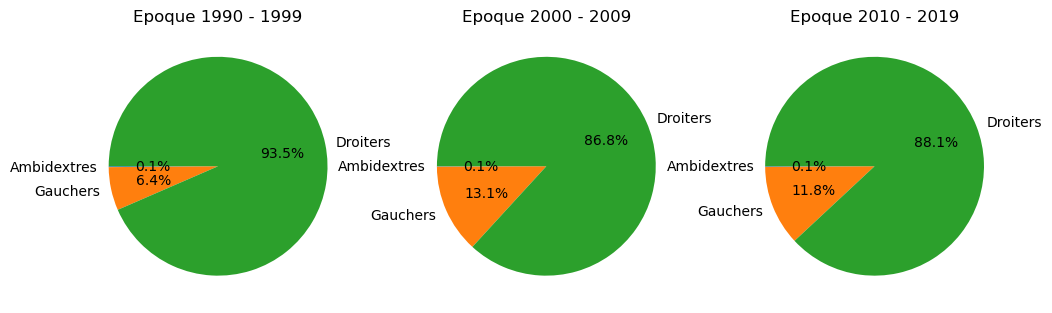

In [44]:
# 3 graphiques - 1 pour chaque décennie 90-99, 2000-2009, 2010-2019 
# Montrer la proportion de données nul et non null sur chaque décennie et la totalité
# Prendre quelle table pour mener cette analyse ? -> Match - atp_matches_90_to_22_dissociate_winner_loser, on peut se baser sur les années des matchs pour calculer la proportion

# 1. Traitement de la donnée pour la visualisation

    # Créer un champ époque pour répartir les données entre les 3 époques analysées 
analyse_all_epoque = atp_matches_90_to_22_dissociate_winner_loser
analyse_all_epoque.loc[(analyse_all_epoque['year_tourney'] >= 1990) & (analyse_all_epoque['year_tourney'] <= 1999), ['epoque']] = "1990 - 1999"
analyse_all_epoque.loc[(analyse_all_epoque['year_tourney'] >= 2000) & (analyse_all_epoque['year_tourney'] <= 2009), ['epoque']] = "2000 - 2009"
analyse_all_epoque.loc[(analyse_all_epoque['year_tourney'] >= 2010) & (analyse_all_epoque['year_tourney'] <= 2019), ['epoque']] = "2010 - 2019"

    # Groupez les données par player id pour éviter la redondance des données pour les joueurs qui ont joué plusieurs fois pendant une époque, on garde l'époque ET la main forte du joueur
analyse_1 = analyse_all_epoque.groupby(["player_id"]).agg({"epoque":"first", "player_hand":"first"})
analyse_1 = analyse_1.reset_index()

    # Groupez les données par époque et comptez le nombre de joueurs avec des mains fortes
analyse_1 = analyse_1.groupby('epoque')['player_hand'].value_counts(normalize=True).unstack()

    # Renommez les colonnes pour plus de clarté
analyse_1.columns = ['Ambidextres', 'Gauchers', "Droitiers", "Inconnus"]

    # Conversion en pourcentage (juste * 100)
analyse_1["Ambidextres"] = analyse_1["Ambidextres"]*100
analyse_1["Gauchers"] = analyse_1["Gauchers"]*100
analyse_1["Droitiers"] = analyse_1["Droitiers"]*100
analyse_1["Inconnus"] = analyse_1["Inconnus"]*100

#print(analyse_1)

# Transformation des données et export pour que ça soit utilisable pour Tableau 

# Utilisez la fonction melt pour convertir le DataFrame
analyse_1_tableau = pd.melt(analyse_1.reset_index(), id_vars=['epoque'], var_name='main_forte', value_name='proportion')

# Intégration du nom de l'analyse
analyse_1_tableau["nom_analyse"] = "1.proportion_mains_forte" 

# Modification du naming contenant les valeurs de la proportion
analyse_1_tableau = analyse_1_tableau.rename(columns={"proportion": "valeurs"})

# Affichez le DataFrame résultant
#print(analyse_1_tableau)

#analyse_1_tableau.to_excel("1.proportion_mains_forte.xlsx",  sheet_name='Sheet_name_1') 

# 2. Visualisation (3 pie chart sur 1 ligne)

    # Créez une figure avec 3 sous-graphiques
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    # Boucle pour créer et afficher les graphiques camemberts, on boucle sur les époques qui sont index (analyse_1.index)
for i, epoque in enumerate(analyse_1.index):
    # Recalcule la proportion sans les valeurs inconnus
    proportions = [analyse_1['Ambidextres'][i], analyse_1['Gauchers'][i], analyse_1['Droitiers'][i]]
    labels = ['Ambidextres', 'Gauchers', 'Droiters']
    axes[i].pie(proportions, labels=labels, autopct='%1.1f%%', startangle=180)
    axes[i].set_title(f'Epoque {epoque}')
    
    # Indication du nombre de valeurs inconnues
for epoque in analyse_1.index:
    nombre_inconnus = analyse_1['Inconnus'][epoque]
    print(f"Epoque {epoque}: Nombre de mains fortes inconnus  = {nombre_inconnus:.2f} %")

### 4.1.2 Proportion des tailles des joueurs par époque

Epoque 1990 - 1999: Nombre de tailles inconnus  = 80.24 %
Epoque 2000 - 2009: Nombre de tailles inconnus  = 88.88 %
Epoque 2010 - 2019: Nombre de tailles inconnus  = 91.24 %


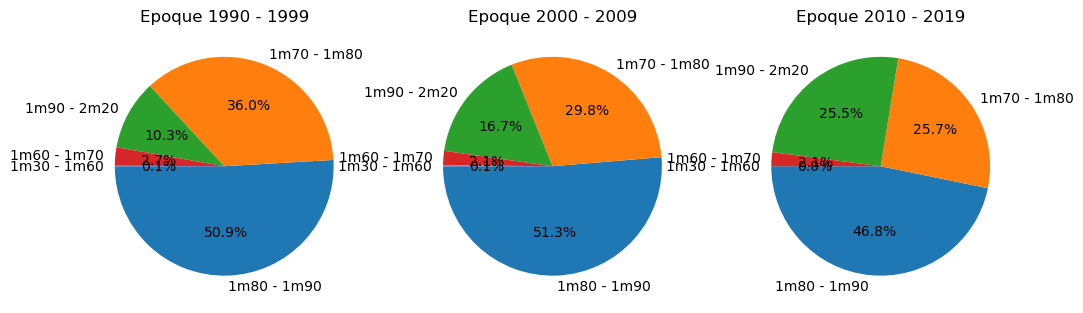

In [45]:
# 1. Traitement de la donnée pour la visualisation

analyse_2 = analyse_all_epoque

    # Créer un champ de taille sous la forme de catégorie, avec une fourchette des tailles pour faciliter la visualisation
        # Liste des intervalles de taille que l'on souhaite entre les fourchettes (np.inf, pour ajouter une intervalle permettant l'intagration de la dernière catégorie "Inconnu", c'est infini, donc tout ce qui est supérieur à 2m20, donc impossible)
        # Liste des catégories qui seront liés aux intervalles choisies (création d'une catégorie inconnu pour les valeurs NULL)
        # Fonction pd.cut qui va permettre de créer les catégories par rapport aux intervalles souhaitées
intervalles = [130,160, 170,180,190,220, np.inf]  
categories = ["1m30 - 1m60", "1m60 - 1m70", "1m70 - 1m80", "1m80 - 1m90", "1m90 - 2m20", "Inconnu"]
analyse_2["height_categorie"] = pd.cut(analyse_2["player_ht"], bins = intervalles, labels=categories,  include_lowest=True)

    # Groupez les données par player id pour éviter la redondance des données pour les joueurs qui ont joué plusieurs fois pendant une époque, on garde l'époque ET la catégorie de taille du joueur
analyse_2 = analyse_2.groupby(["player_id"]).agg({"epoque":"first", "height_categorie":"first"})
analyse_2 = analyse_2.reset_index()

    # Remplacement des valeurs NULL par Inconnu
analyse_2.loc[(analyse_2['height_categorie'].isnull()), ['height_categorie']] = "Inconnu"


    # Groupez les données par époque et comptez le nombre de joueurs avec des mains fortes, calcul de la fréquence relative de chaque catégorie de taille par époque selon leur nombre de présence
        # .value_counts(normalize=True) - compte le nombre d'occurence de chaque catégorie de taille dans chaque époque | le normalize = True, transforme le nombre brute en une proportion
        # .unstack - permet de transformer le résultat de ce traitement sous la forme d'un data frame, ou les catégories de taille deviennnent des colonnes et les époques deviennent les index
analyse_2 = analyse_2.groupby('epoque')['height_categorie'].value_counts(normalize=True).unstack()

    # Fonction multiple permet de multiplier toutes les valeurs du data frame par le nombre entre parenthèse, ici 100
analyse_2 = analyse_2.multiply(100)

#print(analyse_2)

# Transformation des données et export pour que ça soit utilisable pour Tableau 

# Utilisez la fonction melt pour convertir le DataFrame
analyse_2_tableau = pd.melt(analyse_2.reset_index(), id_vars=['epoque'], var_name='categorie_taille', value_name='proportion')

# Intégration du nom de l'analyse
analyse_2_tableau["nom_analyse"] = "2.Proportion_de_taille_par_epoque" 

# Modification du naming contenant les valeurs de la proportion
analyse_2_tableau = analyse_2_tableau.rename(columns={"proportion": "valeurs"})

# Affichez le DataFrame résultant
#print(analyse_2_tableau)

#analyse_2_tableau.to_excel("2.Proportion_de_taille_par_epoque.xlsx",  sheet_name='Sheet_name_1') 

# 2. Visualisation (3 pie chart sur 1 ligne)

    # Créez une figure avec 3 sous-graphiques
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    # Boucle pour créer et afficher les graphiques camemberts, on boucle sur les époques qui sont index ET afficher seulement les catégories qui ne sont pas "Inconnu"
for i, epoque in enumerate(analyse_2.index):
    # Filtrer les données pour l'époque donnée et exclure la catégorie "Inconnu"
    data = analyse_2.loc[epoque].drop("Inconnu")
    
    # Recalcule la proportion car on a exclu la catégorie "Inconnu" précédemment 
    proportions = data / data.sum() * 100
    # Récupération de l'époque
    labels = data.index
    axes[i].pie(proportions, labels=labels, autopct='%1.1f%%', startangle=180)
    axes[i].set_title(f'Epoque {epoque}')
    
    # Indication du nombre de valeurs inconnues
for epoque in analyse_2.index:
    nombre_inconnus = analyse_2['Inconnu'][epoque]
    print(f"Epoque {epoque}: Nombre de tailles inconnus  = {nombre_inconnus:.2f} %")

### 4.1.3.1 Proportion des 10 pays par par époque les plus représentés

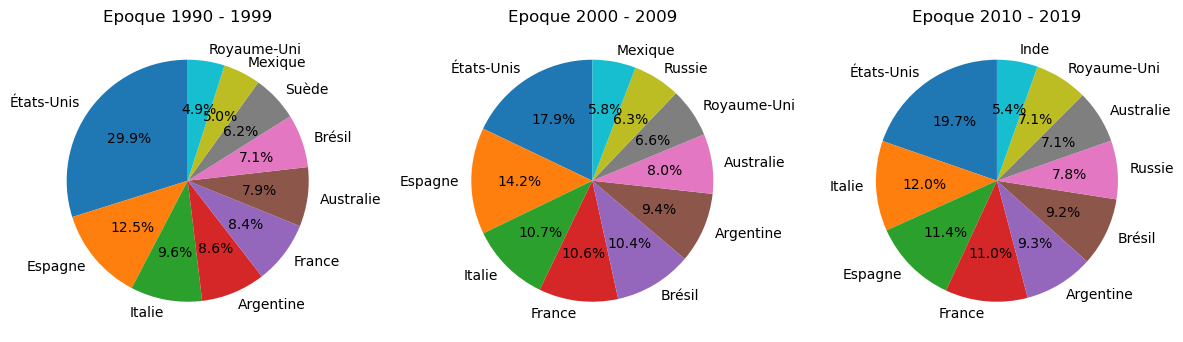

In [46]:
# 1. Traitement de la donnée pour la visualisation

analyse_3 = analyse_all_epoque

    # Group by - Rassembler les données autour du player id et de l'époque | Car un joueur peut jouer sur plusieurs époques, donc comptabiliser tous les joueurs qui ont joué dans une époque
analyse_3 = analyse_3.groupby(["player_id", "epoque"]).agg({"Pays":"first"})
analyse_3 = analyse_3.reset_index()

    # Création d'un DataFrame pour stocker les 10 meilleurs pays par époque
analyse_3_top_10_country_per_epoque = pd.DataFrame()

    # Boucle pour détecter les 10 pays les plus fréquents par époque, group by par époque
        # epoques = l'itération sur chaque époque  (au nombre de 3)
        # data = la table utilisé (analyse_3)
for epoques, data in analyse_3.groupby('epoque'):
    
    # Regroupement par pays et comptage du nombre de joueurs Par pays
    counts = data['Pays'].value_counts()
    
    # Création d'un jeu de donnée intermédiaire avec le top 10 des pays ayant le plus grand nombre de joueurs
        # Modification des noms de colonnes 
        # Intégration d'une colonne avec les époques qui concerne les données itérées
    top_10_country = counts.head(10).reset_index()
    top_10_country.columns = ['pays', 'nombre_joueurs']
    top_10_country['epoque'] = epoques
    
    # Calcul de la proportion par époque pour le top 10
        # Calcul du total de joueur sur le top 10 des pays les plus présents
        # Calcul de la proportion
    total_players = top_10_country['nombre_joueurs'].sum()
    top_10_country['proportion'] = (top_10_country['nombre_joueurs'] / total_players)  *100
    
    # Ajout des données au DataFrame global
    analyse_3_top_10_country_per_epoque = pd.concat([analyse_3_top_10_country_per_epoque, top_10_country])


#print(analyse_3_top_10_country_per_epoque)

# Transformation des données et export pour que ça soit utilisable pour Tableau 

# Utilisez la fonction melt pour convertir le DataFrame
#analyse_3_tableau = pd.melt(analyse_3_top_10_country_per_epoque.reset_index(), id_vars=['epoque'], var_name='categorie_taille', value_name='proportion')


# Intégration du nom de l'analyse
analyse_3_top_10_country_per_epoque["nom_analyse"] = "3.Proportion_10_pays_par_epoque" 

# Modification du naming contenant les valeurs de la proportion
analyse_3_top_10_country_per_epoque = analyse_3_top_10_country_per_epoque.rename(columns={"proportion": "valeurs"})

# Suppression de la colonne inutile 
analyse_3_top_10_country_per_epoque =analyse_3_top_10_country_per_epoque.drop(columns=['nombre_joueurs'])


# Affichez le DataFrame résultant
#print(analyse_3_top_10_country_per_epoque)

#analyse_3_top_10_country_per_epoque.to_excel("3.Proportion_10_pays_par_epoque.xlsx",  sheet_name='Sheet_name_1') 

#print(analyse_3_top_10_country_per_epoque)

# 2. Visualisation (3 pie chart sur 1 ligne)

    # Créez une figure avec 3 sous-graphiques en ligne
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    # Boucle pour créer et afficher les pie charts par époque, donc on itère sur toutes les époques, donc 3 fois
for i, epoques in enumerate(analyse_3_top_10_country_per_epoque['epoque'].unique()):
    
        # Récupération des données correspondant à l'époque itéré sur le jeu obtenu via la boucle de traitement précédente 
    data = analyse_3_top_10_country_per_epoque[analyse_3_top_10_country_per_epoque['epoque'] == epoques]
    
    proportions = data['valeurs']
    labels = data['pays']
    
    axes[i].pie(proportions, labels=labels, autopct='%1.1f%%', startangle=90)
    axes[i].set_title(f'Epoque {epoques}')
    
plt.tight_layout()
plt.show()

# Carte avec rond plus gros selon la proportion - sur Tableau

### 4.1.3.2 Nombre de pays représentés par époque

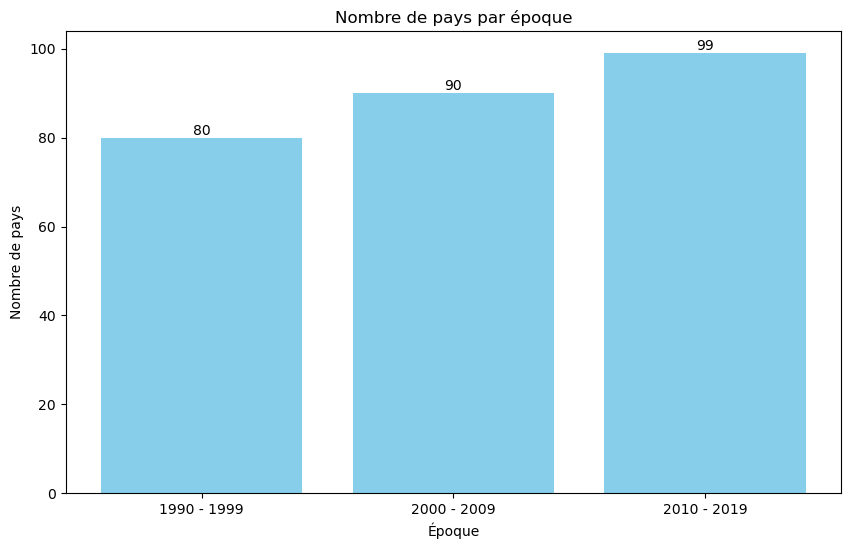

In [47]:
# 1. Traitement de la donnée pour la visualisation

analyse_4 = analyse_all_epoque

    # Group by - Rassembler les données autour de l'époque et du pays - pour supprimer tous les doublons des pays par époque
analyse_4 = analyse_4.groupby(["epoque", "Pays"]).agg({"player_id":"count"})
analyse_4 = analyse_4.reset_index()
analyse_4 = analyse_4[["epoque", "Pays"]]

    # Group by - Rassembler les données autour de l'époque et compter le nombre de pays au total par époque
analyse_4 = analyse_4.groupby(["epoque"]).agg({"Pays":"count"})
analyse_4 = analyse_4.reset_index()


# Intégration du nom de l'analyse
analyse_4["nom_analyse"] = "4.Nombre_pays_par_epoque" 

# Modification du naming contenant les valeurs de la proportion
analyse_4 = analyse_4.rename(columns={"Pays": "valeurs"})

#print(analyse_4)

#analyse_4.to_excel("4.Nombre_pays_par_epoque.xlsx",  sheet_name='Sheet_name_1') 

# 2. Visualisation (1 pie chart)

# Créez un bar chart avec les données d'époque et du nombre de pays
plt.figure(figsize=(10, 6))
plt.bar(analyse_4["epoque"], analyse_4["valeurs"], color='skyblue')

# Ajoutez des étiquettes aux barres
for i, value in enumerate(analyse_4["valeurs"]):
    plt.text(i, value, str(value), ha='center', va='bottom')

# Titre du graphique et des axes
plt.title('Nombre de pays par époque')
plt.xlabel('Époque')
plt.ylabel('Nombre de pays')

# Affichez le graphique
plt.show()

### 4.1.4 Age moyen des joueurs par époque

Epoque 1990 - 1999: Nombre d'âges inconnus = 1.0 %
Epoque 2000 - 2009: Nombre d'âges inconnus = 0.0 %
Epoque 2010 - 2019: Nombre d'âges inconnus = 0.0 %


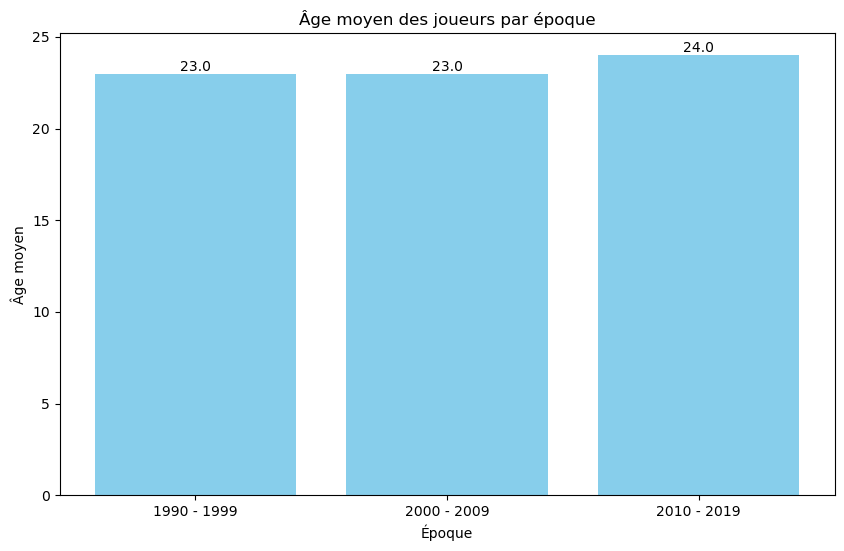

In [48]:
# Par rapport à leur premier match, si 1er match en 92, voir le nombre d'année en pro ATP par rapport à son dernier match ? (problèmatique pour ceux qui ont débuté avant 90 et fin du jeu de donnée donc 2015 et tout)
# OU age moyen des joueurs par époque

# -> Choix de l'age moyen Des joueurs par époque

analyse_5 = analyse_all_epoque

# 1. Traitement de la donnée pour la visualisation

    # Détection du nombre de valeur NA par époque - pour afficher la partie NA 
        # Liste qui va contenir les données de proportion au global par époque après la boucle
proportions_age_null = []
        # Boucle pour effectuer l'analyse sur chaque époque
for epoque, data in analyse_5.groupby('epoque'):
    # Filtrer les données pour une époque donnée
    data_epoque = data[data["epoque"] == epoque]

    # Comptez le nombre total de joueurs dans cette époque - pour le calcul de la proportion après
    total_joueurs = len(data_epoque)

    # Comptez le nombre de joueurs avec des valeurs NULL pour l'âge dans cette époque
    joueurs_age_null = data_epoque["player_age"].isnull().sum()

    # Calculez la proportion de joueurs avec des valeurs NULL pour l'âge dans cette époque
    proportion_age_null = round((joueurs_age_null / total_joueurs) * 100,0)
 
    # On intégre dans la liste toutes les données de proportion pour chaque époque
    proportions_age_null.append((epoque, proportion_age_null))
    
    
    # Conversion de la liste en un DataFrame
proportions_df_age_null = pd.DataFrame(proportions_age_null, columns=["epoque", "proportion_age_null"])

#print(proportions_age_null)
    
    # Traitement pour avoir les ages moyens par époque
        # On filtre les données en écartant toutes les valeurs d'ages qui sont NULL
analyse_5 = analyse_5[analyse_5["player_age"].notnull()]
        # Group by pour obtenir la moyenne des ages sur chaque époque
analyse_5 = analyse_5.groupby(["epoque"]).agg({"player_age":"mean"})
analyse_5 = analyse_5.reset_index()
analyse_5 = analyse_5.round({"player_age":0})

# Intégration du nom de l'analyse
analyse_5["nom_analyse"] = "5.Age_moyen_joueur_par_epoque" 

# Modification du naming contenant les valeurs de la proportion
analyse_5 = analyse_5.rename(columns={"player_age": "valeurs"})


#print(analyse_5)

#analyse_5.to_excel("5.Age_moyen_joueur_par_epoque.xlsx",  sheet_name='Sheet_name_1') 

# 2. Visualisation (1 pie chart)

    # Indication du nombre de valeurs inconnues
        # .iterrows() pour boucler sur les lignes du dataframe
for index, data in proportions_df_age_null.iterrows():
    epoque = data["epoque"]
    proportion = data["proportion_age_null"]
    print(f"Epoque {epoque}: Nombre d'âges inconnus = {proportion:.2} %")

# Créez un bar chart avec les données d'époque et d'âge moyen
plt.figure(figsize=(10, 6))
plt.bar(analyse_5["epoque"], analyse_5["valeurs"], color='skyblue')

# Ajoutez des étiquettes aux barres
for i, value in enumerate(analyse_5["valeurs"]):
    plt.text(i, value, str(value), ha='center', va='bottom')

# Titre du graphique et des axes
plt.title('Âge moyen des joueurs par époque')
plt.xlabel('Époque')
plt.ylabel('Âge moyen')

# Affichez le graphique
plt.show()

### 4.1.5 Proportion du nombre de joueurs dans le top 100 par fourchette d'age sur le top niveau (catégorie ATP - 100 meilleurs)

Epoque 1990 - 1999: Nombre d'ages inconnus  = 0.00 %
Epoque 2000 - 2009: Nombre d'ages inconnus  = 0.00 %
Epoque 2010 - 2019: Nombre d'ages inconnus  = 0.03 %


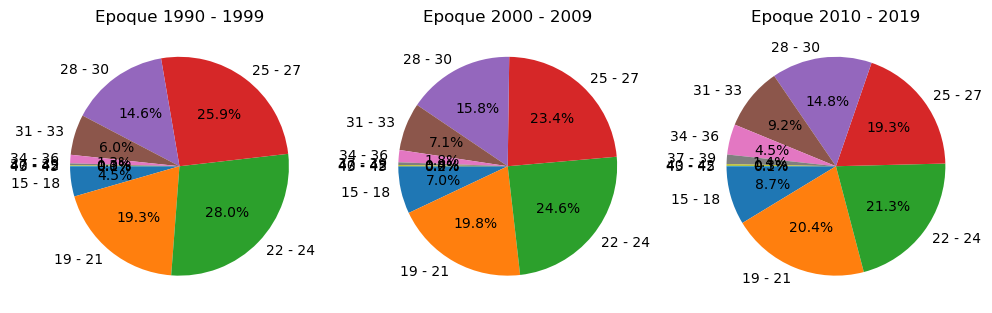

In [49]:
analyse_5_bis = analyse_all_epoque

# 1. Traitement de la donnée pour la visualisation

    # Filtre seulement sur les matchs qui sont dans le circuit ATP
analyse_5_bis = analyse_5_bis[analyse_5_bis["tourney_circuit"] == "ATP"]

    # Créer un champ d'age sous la forme de catégorie, avec une fourchette d'ages pour faciliter la visualisation
        # Liste des intervalles d'age que l'on souhaite entre les fourchettes (np.inf, pour ajouter une intervalle permettant l'intagration de la dernière catégorie "Inconnu", c'est infini, donc tout ce qui est supérieur à 2m20, donc impossible)
        # Liste des catégories qui seront liés aux intervalles choisies (création d'une catégorie inconnu pour les valeurs NULL)
        # Fonction pd.cut qui va permettre de créer les catégories par rapport aux intervalles souhaitées
intervalles_age = [15,18,21,24,27,30,33,36,39,42,45, np.inf]  
categories_age = ["15 - 18", "19 - 21", "22 - 24", "25 - 27", "28 - 30", "31 - 33", "34 - 36", "37 - 39", "40 - 42", "43 - 45", "Inconnu"]
analyse_5_bis["age_categorie"] = pd.cut(analyse_5_bis["player_age"], bins = intervalles_age, labels=categories_age,  include_lowest=True)

    # Groupez les données par player id pour éviter la redondance des données pour les joueurs qui ont joué plusieurs fois pendant une époque, on garde l'époque ET la catégorie d'age du joueur
analyse_5_bis = analyse_5_bis.groupby(["player_id","age_categorie"]).agg({"epoque":"first"})
analyse_5_bis = analyse_5_bis.reset_index()

    # Remplacement des valeurs NULL par Inconnu
analyse_5_bis.loc[(analyse_5_bis['age_categorie'].isnull()), ['age_categorie']] = "Inconnu"

    # Groupez les données par époque et comptez le nombre de joueurs avec des catégories d'age, calcul de la fréquence relative de chaque catégorie d'age par époque selon leur nombre de présence
        # .value_counts(normalize=True) - compte le nombre d'occurence de chaque catégorie d'age dans chaque époque | le normalize = True, transforme le nombre brute en une proportion
        # .unstack - permet de transformer le résultat de ce traitement sous la forme d'un data frame, ou les catégories d'ages deviennnent des colonnes et les époques deviennent les index
analyse_5_bis = analyse_5_bis.groupby('epoque')['age_categorie'].value_counts(normalize=True).unstack()

    # Fonction multiple permet de multiplier toutes les valeurs du data frame par le nombre entre parenthèse, ici 100
analyse_5_bis = analyse_5_bis.multiply(100)

#print(analyse_5_bis)

# Transformation des données et export pour que ça soit utilisable pour Tableau 

# Utilisez la fonction melt pour convertir le DataFrame
analyse_5_bis_tableau = pd.melt(analyse_5_bis.reset_index(), id_vars=['epoque'], var_name='categorie_age', value_name='proportion')


# Intégration du nom de l'analyse
analyse_5_bis_tableau["nom_analyse"] = "5.bis.Proportion_nb_joueur_top_100_par_epoque.xlsx" 

# Modification du naming contenant les valeurs de la proportion
analyse_5_bis_tableau = analyse_5_bis_tableau.rename(columns={"proportion": "valeurs"})

# Affichez le DataFrame résultant
#print(analyse_5_bis_tableau)

#analyse_5_bis_tableau.to_excel("5.bis.Proportion_nb_joueur_top_100_par_epoque.xlsx",  sheet_name='Sheet_name_1') 

# 2. Visualisation (3 pie chart sur 1 ligne)

    # Créez une figure avec 3 sous-graphiques
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    # Boucle pour créer et afficher les graphiques camemberts, on boucle sur les époques qui sont index ET afficher seulement les catégories qui ne sont pas "Inconnu"
for i, epoque in enumerate(analyse_5_bis.index):
    # Filtrer les données pour l'époque donnée et exclure la catégorie "Inconnu"
    data = analyse_5_bis.loc[epoque].drop("Inconnu")
    
    # Recalcule la proportion car on a exclu la catégorie "Inconnu" précédemment 
    proportions = data / data.sum() * 100
    # Récupération de l'époque
    labels = data.index
    axes[i].pie(proportions, labels=labels, autopct='%1.1f%%', startangle=180)
    axes[i].set_title(f'Epoque {epoque}')
    
    # Indication du nombre de valeurs inconnues
for epoque in analyse_5_bis.index:
    nombre_inconnus = analyse_5_bis['Inconnu'][epoque]
    print(f"Epoque {epoque}: Nombre d'ages inconnus  = {nombre_inconnus:.2f} %")

### 4.1.6.1 Distribution des temps des matchs des joueurs par époque - montre l'endurance ET/OU l'efficacité - BO3 - tous les circuits et tournoi compris

In [50]:
analyse_6 = analyse_all_epoque
analyse_6_unique = analyse_6.groupby(["id_atp_matches"]).agg({"epoque":"first","minutes":"max", "best_of":"max"})
analyse_6_unique = analyse_6_unique.reset_index()

In [51]:
# Fonction pour éviter la redondance du code 4.1.5.1 et 4.1.5.2, qui sont identiques, seulement données BO3 et BO5 qui change
def temps_moyen_match_per_epoque(nb_bo_int, str_nom_bo):

    analyse_6 = analyse_all_epoque

    # 1. Traitement de la donnée pour la visualisationAnalyse
    
        # Détection du nombre de valeur NA par époque - pour afficher la partie NA 
            # Liste qui va contenir les données de proportion au global par époque après la boucle
    proportions_minutes_null_0 = []
            # Group by pour obtenir les matchs de manières uniques
                # Mise en place d'une condition pour éviter d'effectuer cette partie de traitement si la table est déjà existante, car long traitement
                    # Vérification que le Data frame existe (utilisation de la méthode locals, qui permet de renvoyer les variables locals existantes)
                        # Si oui, on ne fait pas le traitement, SINON on le fait
    if 'analyse_6_unique' in locals():
        print("Le DataFrame existe.")
    else:
        #analyse_6_unique = analyse_6.groupby(["id_atp_matches"]).agg({"epoque":"first","minutes":"max", "best_of":"max"})
        #analyse_6_unique = analyse_6_unique.reset_index()
        print("Le DataFrame n'existe pas.")

            # Boucle pour effectuer l'analyse sur chaque époque
    for epoque, data in analyse_6_unique.groupby('epoque'):
        # Filtrer les données pour une époque donnée
        data_epoque = data[data["epoque"] == epoque]

        # Filtrer les données pour prendre en compte seulement les BO3
        data_epoque = data_epoque[data_epoque["best_of"] == nb_bo_int]

        # Comptez le nombre total de joueurs dans cette époque - pour le calcul de la proportion après
        total_matchs = len(data_epoque)

        # Comptez le nombre de joueurs avec des valeurs NULL pour l'âge dans cette époque
        match_minutes_null = data_epoque["minutes"].isnull().sum()
        match_minutes_null_0 = len(data_epoque[data_epoque["minutes"]==0]) + match_minutes_null
        
        # Calculez la proportion de joueurs avec des valeurs NULL pour l'âge dans cette époque
        proportions_minute_null_0 = round((match_minutes_null_0 / total_matchs) * 100,0)

        # On intégre dans la liste toutes les données de proportion pour chaque époque
        proportions_minutes_null_0.append((epoque, proportions_minute_null_0))


        # Conversion de la liste en un DataFrame
    proportions_df_min_null_0 = pd.DataFrame(proportions_minutes_null_0, columns=["epoque", "proportion_minutes_null_0"])


        # Traitement pour obtenir les données utiles à la distribution
            # On filtre les données en écartant toutes les valeurs de minutes qui sont NULL
    analyse_6 = analyse_6_unique[analyse_6_unique["minutes"].notnull()]
            # On filtre pour garder seulement les matchs qui sont des BO3
    analyse_6 = analyse_6[analyse_6["best_of"] == nb_bo_int]
    
    # 2. Visualisation (3 pie chart)

        # Indication du nombre de valeurs inconnues
            # .iterrows() pour boucler sur les lignes du dataframe
    for index, data in proportions_df_min_null_0.iterrows():
        epoque = data["epoque"]
        proportion = data["proportion_minutes_null_0"]
        print(f"Epoque {epoque}: Nombre de matchs avec des temps inconnus = {proportion} %")

        # Visualisation des données 
    # Créer un box plot et un violon plot avec des valeurs brutes
    
    # Exclue les données None des époques
    analyse_6 = analyse_6[analyse_6["epoque"].notnull()]
    # Obtenez les époques uniques
    epoques = analyse_6['epoque'].unique()

    # Créez une figure avec des sous-graphiques pour chaque époque
    fig, axes = plt.subplots(1, len(epoques), figsize=(15, 6))

    # Itérez sur les époques
    for i, epoque in enumerate(epoques):
        
        # Sélectionnez les données pour l'époque actuelle
        data_epoque = analyse_6[analyse_6['epoque'] == epoque]

        # Créez un box plot pour les minutes
        boxplot = axes[i].boxplot(data_epoque['minutes'], vert=True, patch_artist=True)
        axes[i].set_title(f'Distribution des minutes ({epoque})')
        axes[i].set_xlabel('Minutes')
        axes[i].set_yticks([])  # Masquez les étiquettes de l'axe y

        # Ajoutez des intervalles sur toute la longueur de l'axe y
        num_intervals = 10
        y_min, y_max = min(data_epoque['minutes']), max(data_epoque['minutes'])
        y_intervals = [y_min + i * (y_max - y_min) / num_intervals for i in range(num_intervals + 1)]
        axes[i].set_yticks(y_intervals)


    # Affichez la figure
    plt.tight_layout()
    plt.show()
    
    return(analyse_6)

Le DataFrame n'existe pas.
Epoque 1990 - 1999: Nombre de matchs avec des temps inconnus = 84.0 %
Epoque 2000 - 2009: Nombre de matchs avec des temps inconnus = 89.0 %
Epoque 2010 - 2019: Nombre de matchs avec des temps inconnus = 68.0 %


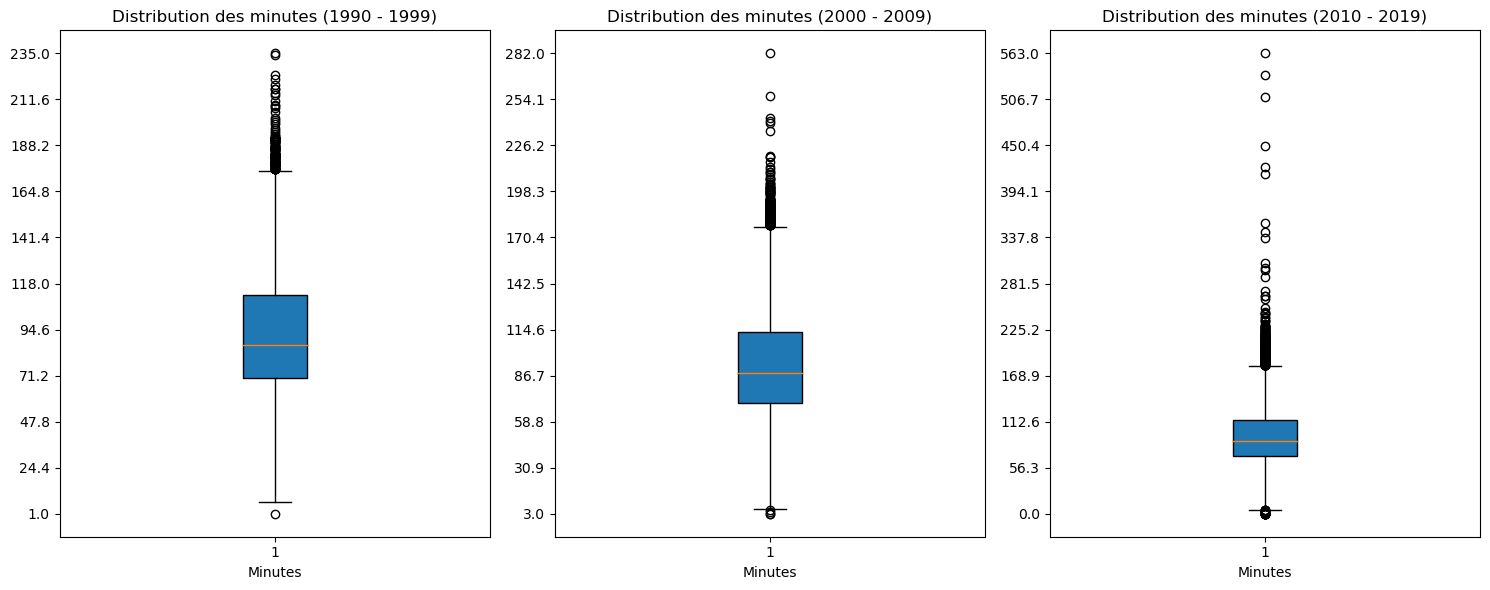

                       id_atp_matches       epoque  minutes  best_of
5945     1991-20119910204100782100711  1990 - 1999     75.0        3
5946     1991-20119910204100800100942  1990 - 1999     72.0        3
5947     1991-20119910204100800101897  1990 - 1999     61.0        3
5948     1991-20119910204100864101080  1990 - 1999     85.0        3
5949     1991-20119910204100864101341  1990 - 1999     72.0        3
...                               ...          ...      ...      ...
689892  2019-M03520190729128034105385  2010 - 2019     63.0        3
689893  2019-M03520190729144750105575  2010 - 2019    113.0        3
689894  2019-M03520190729200000124187  2010 - 2019    106.0        3
689895  2019-M03520190729200175105732  2010 - 2019    141.0        3
689896  2019-M03520190729200175200615  2010 - 2019     92.0        3

[139988 rows x 4 columns]


In [52]:
temps_moyen_per_epoque_bo3 = temps_moyen_match_per_epoque(3,"BO3")

print(temps_moyen_per_epoque_bo3)

### 4.1.6.2 Temps moyens des matchs des joueurs par époque - BO5 - tous les circuits et tournoi compris

Le DataFrame n'existe pas.
Epoque 1990 - 1999: Nombre de matchs avec des temps inconnus = 57.0 %
Epoque 2000 - 2009: Nombre de matchs avec des temps inconnus = 33.0 %
Epoque 2010 - 2019: Nombre de matchs avec des temps inconnus = 24.0 %


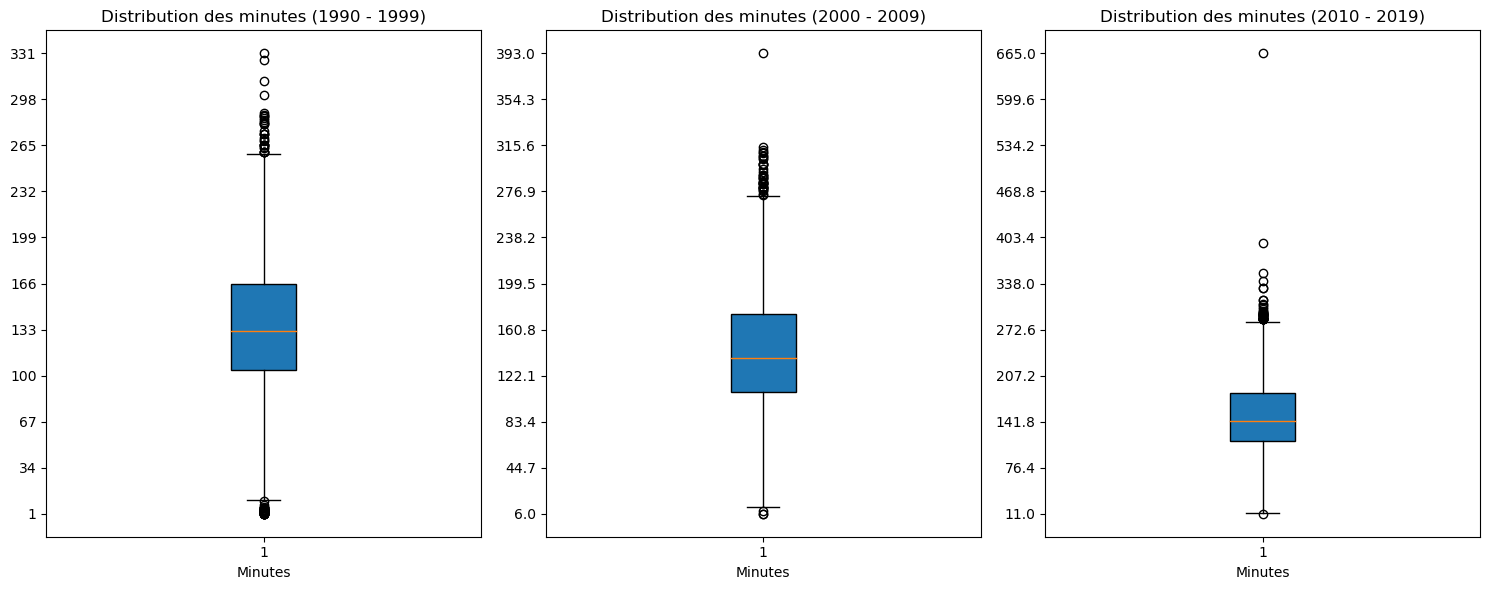

                      id_atp_matches       epoque  minutes  best_of
7036    1991-31419910708101142101843  1990 - 1999    106.0        5
7125    1991-31719910722101320101063  1990 - 1999    218.0        5
7156    1991-31919910729101120101320  1990 - 1999    156.0        5
7213    1991-32119910715101529101606  1990 - 1999    143.0        5
7406    1991-32819910923101084100581  1990 - 1999    129.0        5
...                              ...          ...      ...      ...
666579  2019-58020190114133430106121  2010 - 2019    128.0        5
666590  2019-58020190114200282105155  2010 - 2019    118.0        5
666591  2019-58020190114200282105967  2010 - 2019    232.0        5
666596  2019-58020190114200615104999  2010 - 2019    119.0        5
666597  2019-58020190114200615106233  2010 - 2019    104.0        5

[13648 rows x 4 columns]


In [53]:
temps_moyen_per_epoque_bo5 = temps_moyen_match_per_epoque(5,"BO5")

print(temps_moyen_per_epoque_bo5)

In [54]:
# Concaténation des deux jeux de données, pour pouvoir ensuite les exporter et les traiter sur tableau
temps_moyen_match_per_epoque_bo3_bo5 = pd.concat([temps_moyen_per_epoque_bo3, temps_moyen_per_epoque_bo5], axis=0)

# Intégration du nom de l'analyse
temps_moyen_match_per_epoque_bo3_bo5["nom_analyse"] = "6.Distribution du temps des matchs BO3 et BO5" 

# Modification du naming contenant les valeurs de la proportion
temps_moyen_match_per_epoque_bo3_bo5 = temps_moyen_match_per_epoque_bo3_bo5.rename(columns={"minutes": "valeurs"})

# Suppression de la colonne inutile 
temps_moyen_match_per_epoque_bo3_bo5 =temps_moyen_match_per_epoque_bo3_bo5.drop(columns=['id_atp_matches'])

#print(temps_moyen_match_per_epoque_bo3_bo5)

# Export des données
#temps_moyen_match_per_epoque_bo3_bo5.to_excel("6.Distribution du temps des matchs BO3 et BO5.xlsx",  sheet_name='Sheet_name_1') 

### Concaténation des données de la thématique 1 pour l'utilisation sur Tableau Public, et obtenir des filtres communs sur le dashboard

In [55]:
# Concaténation des deux jeux de données, pour pouvoir ensuite les exporter et les traiter sur tableau
tableau_thematique_1 = pd.concat([analyse_1_tableau, analyse_2_tableau,analyse_3_top_10_country_per_epoque,analyse_4,analyse_5,analyse_5_bis_tableau,temps_moyen_match_per_epoque_bo3_bo5], axis=0)


# Indication "no_data" sur les valeurs NULL
tableau_thematique_1 = tableau_thematique_1.fillna("no_data")

#print(tableau_thematique_1)

# Export des données
tableau_thematique_1.to_excel("thematique_1_data.xlsx",  sheet_name='Sheet_name_1') 

## 4.2 Thématique 2 : Historique des tournois/surface ET évolution des statistiques des joueurs sur les différents tournois / surfaces au fil du temps

### 4.2.0.1 Nombre de tournoi Par surface BO3 par circuit et par époque

In [56]:
# Fonction pour éviter la redondance du code 4.2.0.1 et 4.2.0.2, qui sont identiques, seulement données BO3 et BO5 qui change
def proportion_tournoi_per_surface_per_circuit_per_epoque(nb_bo_int):

    analyse_8 = analyse_all_epoque

    # 1. Traitement de la donnée pour la visualisation

        # Filtrer les données pour les tournois BO3 (best_of = 3)
    analyse_8 = analyse_8[analyse_8['best_of'] == nb_bo_int]
        # Grouper les données autour de tourney_id, pour les obtenir de manière unique, tout en récupérant les champs souhaités lié à chaque tournoi
    analyse_8 = analyse_8.groupby(["tourney_id"]).agg({"surface":"first","tourney_circuit":"first", "epoque":"first", "tourney_name":"first"})
    analyse_8 = analyse_8.reset_index()
        # Grouper les données autour de tourney_name et époque, pour les obtenir de manière unique par époque et comptatibiliser le nombre de tournoi qu'il y a eu lors de chaque époque
    analyse_8 = analyse_8.groupby(["tourney_name", "epoque"]).agg({"surface":"first","tourney_circuit":"first", "tourney_id":"count"})
    analyse_8 = analyse_8.reset_index()

    #print(analyse_8)

    # 2. Visualisation (3 pie chart sur 1 ligne, 1 par époque)

        # Filtrer les données pour ne pas prendre en compte les données "Hors circuit"
    analyse_8 = analyse_8[analyse_8["tourney_circuit"] != "Hors circuit"]
        # Filtrer les données pour ne pas prendre en compte les données "None" pour les époques
    analyse_8 = analyse_8[analyse_8["epoque"].notnull()]

        # Liste des époques dans l'ordre souhaité - modification pour afficher les graphiques dans le bon ordre des époques
    epochs_order = ['1990 - 1999', '2000 - 2009', '2010 - 2019']
        # Réorganisez l'ordre des niveaux dans l'index
    analyse_8 = analyse_8.set_index('epoque').loc[epochs_order].reset_index()

        # Liste des surfaces uniques
    surfaces = analyse_8['surface'].unique()

        # Liste des circuits uniques
    circuits = analyse_8['tourney_circuit'].unique()

        # Créez une figure pour afficher les graphiques
    fig, axes = plt.subplots(1, len(epochs_order), figsize=(18, 6))

    # Créer une liste pour stocker les DataFrames de chaque époque
    dfs = []
    
        # Parcourez chaque époque pour créer un graphique à barres empilées
            # Itére sur chaque époque
    for i, epoch in enumerate(epochs_order):
            # Récupération des données de l'époque itérée
        data = analyse_8[analyse_8['epoque'] == epoch]
            # .size permet de compter le nombre d'occurences des tournois présents dans le circuit ET la surface
            # .unstack() permet de déplacer dans le dataframe obtenu les surfaces en colonne 
            # .reindex() permet de placer les circuits en index, pour chaque ligne - fill_value, si problème de valeur, mise à 0 par défaut
        data_by_epoch = data.groupby(['tourney_circuit', 'surface']).size().unstack().reindex(circuits, fill_value=0)
        #print(data_by_epoch)

        # Calculer les proportions en pourcentage via le nombre de tournois obtenus dans data_by_epoch
        sum_by_circuit = data_by_epoch.sum(axis=1)
        data_percentage = round(data_by_epoch.divide(sum_by_circuit, axis=0) * 100,0)
        
    
        # Configuration du graphique
        ax = data_percentage.plot(kind='bar', stacked=True, ax=axes[i])
        ax.set_xlabel("Circuits et Surfaces")
        ax.set_ylabel("Proportion de tournois")
        ax.set_title(f"Époque {epoch}")

        # Ajoutez des étiquettes aux barres
        for p in ax.patches:
            width, height = p.get_width(), p.get_height()
            x, y = p.get_xy()
            ax.annotate(f'{height}', (x + width / 2, y + height / 2), ha='center', va='center')

            
        #print(data_percentage)
        
       # data_percentage = data_percentage.reset_index()
        
        #print(data_percentage)
                # Utilisez la fonction melt pour convertir le DataFrame
        data_percentage = pd.melt(data_percentage.reset_index(), id_vars=['tourney_circuit'], var_name='surfaces', value_name='proportion')

        # Affichez le DataFrame résultant
        #print(data_percentage)
    
        # Ajouter l'époque comme colonne supplémentaire
        data_percentage['epoque'] = epoch
         
        # Reset index pour rendre utilisable les noms de tournoi en colonne et non en index
        #data_percentage = data_percentage.reset_index()
        #print(data_percentage)
        
        # Ajouter la colonne "tourney_circuit"
        #print(data_percentage['tourney_circuit'].values)
        data_percentage['tourney_circuit'] = data_percentage['tourney_circuit'].values
        
        # Ajouter la colonne "bo"
        #print(data_percentage['tourney_circuit'].values)
        data_percentage['bo'] = nb_bo_int
            
            
        # Ajouter le DataFrame à la liste
        dfs.append(data_percentage)
        
    # Affichez les graphiques
    plt.show()
    
    # Concaténer les DataFrames de chaque époque en un seul DataFrame
    result_df = pd.concat(dfs, ignore_index=True)
    
    return(result_df)

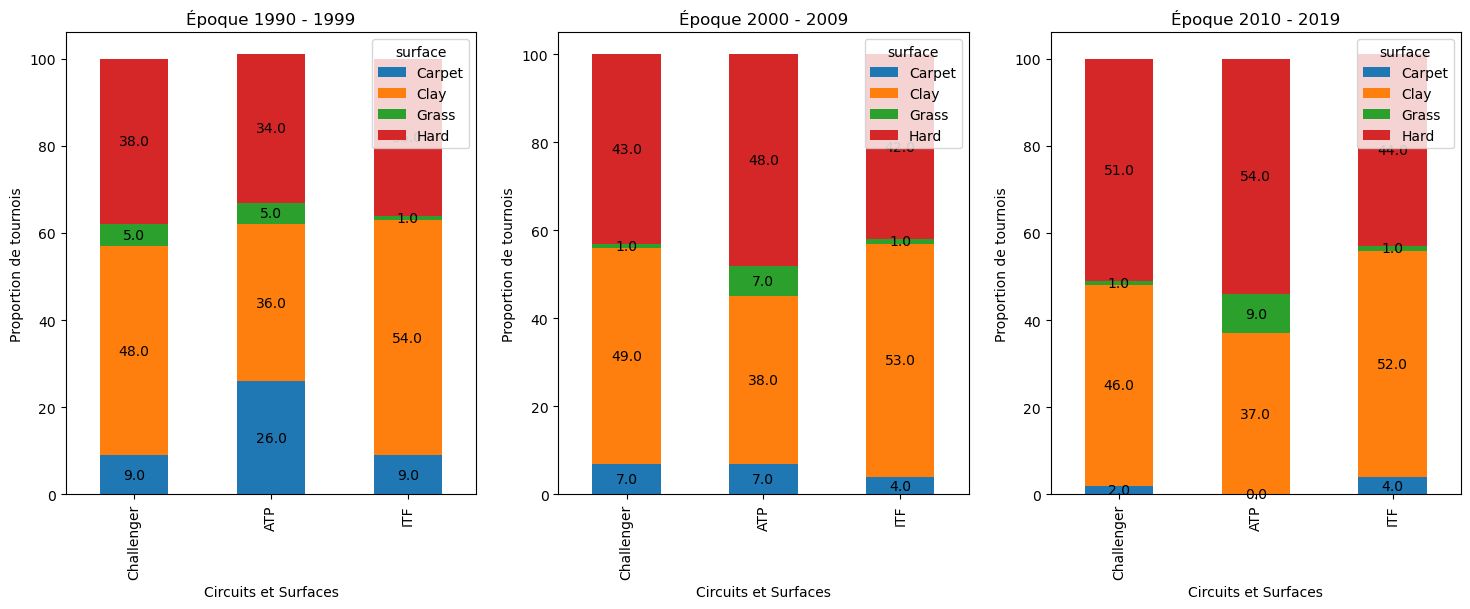

In [57]:
nb_tournoi_per_epoque_bo3 = proportion_tournoi_per_surface_per_circuit_per_epoque(3)

### 4.2.0.2 Nombre de tournoi Par surface BO5 par circuit et par époque

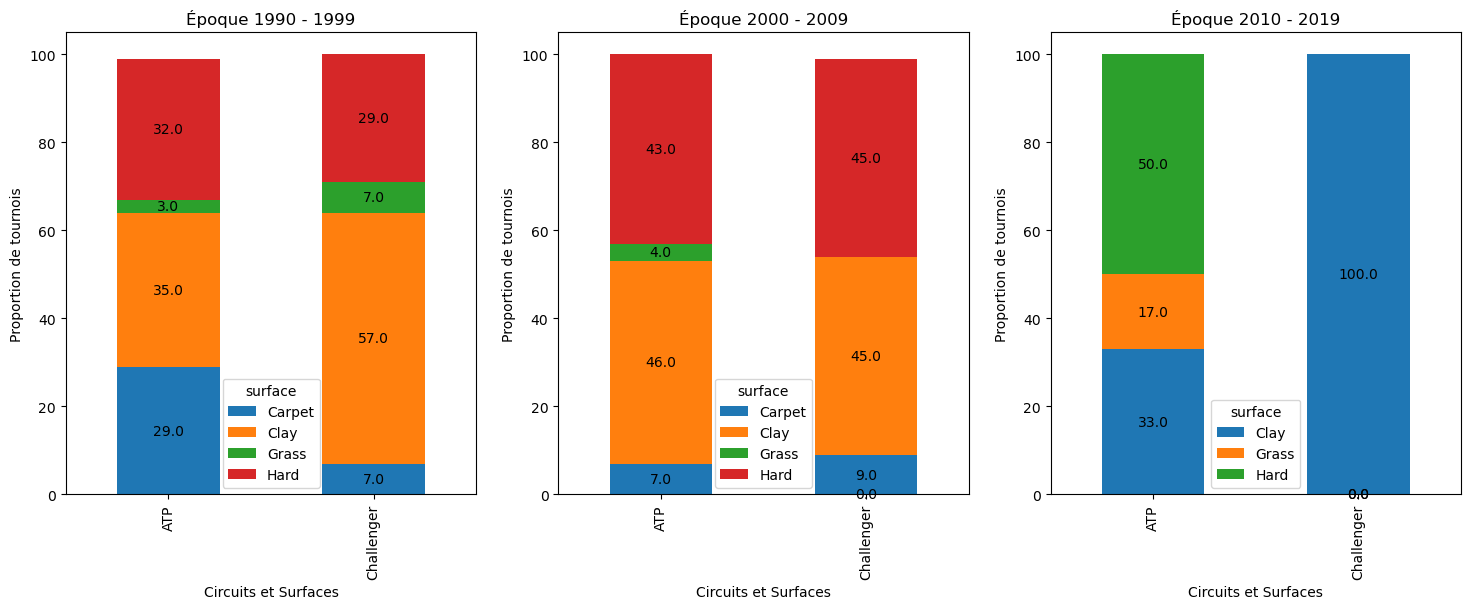

In [58]:
nb_tournoi_per_epoque_bo5 = proportion_tournoi_per_surface_per_circuit_per_epoque(5)

In [59]:
# Concaténation des deux jeux de données, pour pouvoir ensuite les exporter et les traiter sur tableau
#print(nb_tournoi_per_epoque_bo3)
#rint(nb_tournoi_per_epoque_bo5)

#print(nb_tournoi_per_epoque_bo3)

nb_tournoi_per_epoque_bo3_bo5 = pd.concat([nb_tournoi_per_epoque_bo3, nb_tournoi_per_epoque_bo5], axis=0)

nb_tournoi_per_epoque_bo3_bo5 = nb_tournoi_per_epoque_bo3_bo5.fillna(0)

# Intégration du nom de l'analyse
nb_tournoi_per_epoque_bo3_bo5["nom_analyse"] = "2.1.Nombre de matchs BO3 et BO5" 

# Modification du naming contenant les valeurs de la proportion
nb_tournoi_per_epoque_bo3_bo5 = nb_tournoi_per_epoque_bo3_bo5.rename(columns={"proportion": "valeurs", "surfaces":"surface"})

print(nb_tournoi_per_epoque_bo3_bo5)

# Export des données
#nb_tournoi_per_epoque_bo3_bo5.to_excel("2.1.Nombre de matchs BO3 et BO5.xlsx",  sheet_name='Sheet_name_1') 

   tourney_circuit surface  valeurs       epoque  bo  \
0       Challenger  Carpet      9.0  1990 - 1999   3   
1              ATP  Carpet     26.0  1990 - 1999   3   
2              ITF  Carpet      9.0  1990 - 1999   3   
3       Challenger    Clay     48.0  1990 - 1999   3   
4              ATP    Clay     36.0  1990 - 1999   3   
5              ITF    Clay     54.0  1990 - 1999   3   
6       Challenger   Grass      5.0  1990 - 1999   3   
7              ATP   Grass      5.0  1990 - 1999   3   
8              ITF   Grass      1.0  1990 - 1999   3   
9       Challenger    Hard     38.0  1990 - 1999   3   
10             ATP    Hard     34.0  1990 - 1999   3   
11             ITF    Hard     36.0  1990 - 1999   3   
12      Challenger  Carpet      7.0  2000 - 2009   3   
13             ATP  Carpet      7.0  2000 - 2009   3   
14             ITF  Carpet      4.0  2000 - 2009   3   
15      Challenger    Clay     49.0  2000 - 2009   3   
16             ATP    Clay     38.0  2000 - 2009

### 4.2.1.1 Temps moyens par surface des différents circuits par époque - BO3 ET BO5

In [60]:
# Statistiques à analyser :
    # -> Moyenne utilisé et non la somme car la proportion de tournoi n'est pas identique d'époque en époque

    # Minutes 
    # x_svpt => Nombre de services effectués dans le match
    # x_1stWon => Nombre de points gagnés sur son premier service
    # x_ace => Nombre d'aces
    # x_df => Nombre de doubles fautes
    # x_1stIn => Nombre de premiers services valables
    # x_2ndWon => Nombre de points gagnés sur son second service
    # x_SvGms => Nombre de jeux de services gagnés
    # x_bpSaved => Nombre de balles de break sauvées
    # x_bpFaced => Nombre de balles de break rencontrées
    
# Graphique à utiliser stacked bar, pas afficher en proportion, en nombre brute 
# Afficher 3 graphiques stacked bar par statistiques
# Afficher la proportion de valeur NULL pour chaque statistique

# Fonction de traitement des données pour les statistiques pour les analyses - lancer seulement deux fois pour le BO3 et BO5
def traitement_statistique_mean_per_surface_per_circuit_per_epoque_per_bo(nb_bo_int):
    
    analyse_9 = analyse_all_epoque

    # 1. Traitement de la donnée pour la visualisation

        # A. Traitement des valeurs brutes
        # Filtrer les données pour les tournois BO3 (best_of = 3)
    analyse_9 = analyse_9[analyse_9['best_of'] == nb_bo_int]
        # Grouper les données autour des matchs, ce qui permettra de récupérer de manière unique les minutes du matchs et d'effectuer la somme des autres statistiques | Tout en récupérant les autres infos qui vont nous servir pour le reste des analyses (epoque, surface, circuit)
            # Mise en place d'une condition pour éviter d'effectuer cette partie de traitement si la table est déjà existante, car long traitement
                # Vérification que le Data frame existe (utilisation de la méthode locals, qui permet de renvoyer les variables locals existantes)
                    # Si oui, on ne fait pas le traitement, SINON on le fait
    if 'analyse_9_treat_by_match' in locals():
        print("Le DataFrame existe.")
    else:
        analyse_9_treat_by_match = analyse_9.groupby(["id_atp_matches"]).agg({"surface":"first","tourney_circuit":"first", "epoque":"first", "minutes":"max","p_svpt":"sum","p_ace":"sum","p_1stIn":"sum","p_1stWon":"sum","p_2ndWon":"sum","p_SvGms":"sum","p_bpSaved":"sum","p_bpFaced":"sum", "p_df":"sum"})
        analyse_9_treat_by_match = analyse_9_treat_by_match.reset_index()
        #print("Le DataFrame n'existe pas.")


        # Grouper les données autour de surface, circuit et époque, pour obtenir les statistiques moyennes par surface ET époque 
            # ATTENTION, on doit effectuer la moyenne seulement sur les valeurs qui ne sont pas NULL, ni à 0, sinon ça fausserait les moyennes
            # Créez une fonction personnalisée pour calculer la moyenne en excluant les valeurs NULL et 0
    def custom_mean(column):
        non_null_values = column.dropna()  # Exclure les valeurs NULL
        non_zero_values = non_null_values[non_null_values != 0]  # Exclure les valeurs égales à 0
        return np.mean(non_zero_values)

            # Liste des colonnes à agréger avec la fonction personnalisé excluant les valeurs null et à 0
    columns_to_aggregate = ["minutes","p_ace","p_df", "p_svpt", "p_1stIn", "p_1stWon", "p_2ndWon", "p_SvGms", "p_bpSaved", "p_bpFaced"]

            # Utilisez la méthode apply avec la fonction personnalisée
    analyse_9 = analyse_9_treat_by_match.groupby(["surface", "epoque", "tourney_circuit"]).agg({ **{col: lambda x: custom_mean(x) for col in columns_to_aggregate}}).reset_index()
    # Arrondir toutes les valeurs à 0
    analyse_9 = analyse_9.round(0)
    analyse_9 = analyse_9.reset_index()
    # Passage à nouveau des valeurs NULL à 0
    analyse_9 = analyse_9.fillna(0)

    # Filtrer les données pour ne pas prendre en compte les données "Hors circuit"
    analyse_9 = analyse_9[analyse_9["tourney_circuit"] != "Hors circuit"]

    # Filtrer les données pour ne pas prendre en compte les données "None" pour les époques
    analyse_9 = analyse_9[analyse_9["epoque"].notnull()]

    #print(analyse_9)

    return analyse_9

# Fonction de traitement des données Inconnues pour les statistiques - lancer seulement deux fois pour le BO3 et BO5
def traitement_statistique_0_null_per_surface_per_circuit_per_epoque_per_bo(nb_bo_int):
    
    analyse_9 = analyse_all_epoque

    # 1. Traitement de la donnée pour la visualisation

        # A. Traitement des valeurs brutes
        # Filtrer les données pour les tournois BO3 (best_of = 3)
    analyse_9 = analyse_9[analyse_9['best_of'] == nb_bo_int]
        # Grouper les données autour des matchs, ce qui permettra de récupérer de manière unique les minutes du matchs et d'effectuer la somme des autres statistiques | Tout en récupérant les autres infos qui vont nous servir pour le reste des analyses (epoque, surface, circuit)
            # Mise en place d'une condition pour éviter d'effectuer cette partie de traitement si la table est déjà existante, car long traitement
                # Vérification que le Data frame existe (utilisation de la méthode locals, qui permet de renvoyer les variables locals existantes)
                    # Si oui, on ne fait pas le traitement, SINON on le fait
    if 'analyse_9_treat_by_match' in locals():
        print("Le DataFrame existe.")
    else:
        analyse_9_treat_by_match = analyse_9.groupby(["id_atp_matches"]).agg({"surface":"first","tourney_circuit":"first", "epoque":"first", "minutes":"max","p_svpt":"sum","p_ace":"sum","p_1stIn":"sum","p_1stWon":"sum","p_2ndWon":"sum","p_SvGms":"sum","p_bpSaved":"sum","p_bpFaced":"sum", "p_df":"sum"})
        analyse_9_treat_by_match = analyse_9_treat_by_match.reset_index()
        #print("Le DataFrame n'existe pas.")

        # B. Détection du nombre de valeur NA par époque - pour afficher la partie NA 

            # Liste des statistiques à considérer
    statistics_columns = ['minutes', 'p_svpt', 'p_1stWon', 'p_ace', 'p_df', 'p_1stIn', 'p_2ndWon', 'p_SvGms', 'p_bpSaved', 'p_bpFaced']

            # Créez une liste vide pour stocker les proportions de valeurs NULL et 0 pour chaque statistique
    proportions_null_0_list = []


            # Boucle pour parcourir chaque statistique
    for statistic_column in statistics_columns:
        # Créez une liste vide pour stocker les proportions de valeurs NULL pour chaque époque
        proportions_epoque_null_0 = []

                # Boucle pour effectuer l'analyse sur chaque époque
        for epoque, data in analyse_9_treat_by_match.groupby('epoque'):
            # Filtrer les données pour une époque donnée
            data_epoque = data[data["epoque"] == epoque]

            # Comptez le nombre total de matchs dans cette époque - pour le calcul de la proportion après
            total_matchs = len(data_epoque)

            # Comptez le nombre de matchs avec des valeurs NULL ET 0 pour la statistique
            statistic_null_count = data_epoque[statistic_column].isnull().sum()
            statistic_null_0_count = len(data_epoque[data_epoque[statistic_column] ==0]) + statistic_null_count

            # Calculez la proportion de matchs avec des valeurs NULL pour la statistique dans cette époque
            proportion_statistic_null_0 = round((statistic_null_0_count / total_matchs) * 100, 2)

            # Ajoutez la proportion calculée à la liste des proportions pour cette époque
            proportions_epoque_null_0.append((epoque, proportion_statistic_null_0))

        # Créez un DataFrame à partir de la liste des proportions pour cette statistique
        proportions_df_statistic_null_0 = pd.DataFrame(proportions_epoque_null_0, columns=["epoque", f"{statistic_column}"])

        # Ajoutez le DataFrame de cette statistique à la liste globale
        proportions_null_0_list.append(proportions_df_statistic_null_0)

    # Créez un DataFrame global en fusionnant les DataFrames de chaque statistique sur la colonne 'epoque'
    proportions_null_0_all_stat = pd.concat(proportions_null_0_list, axis=1)

    # Suppression de la colonne "epoque" qui s'est vu duppliquée à chaque concatenation, on garde seulement une colonne "epoque" car elles sont toutes identiques
    proportions_null_0_all_stat = proportions_null_0_all_stat.loc[:, ~proportions_null_0_all_stat.columns.duplicated()]

    #print(proportions_null_0_all_stat)    
    
    return proportions_null_0_all_stat
    
# Fonction d'affichage, à appeler pour chaque visualisation des statistiques
def visualisation_stat_mean_per_surface_per_circuit_per_epoque(nom_stat_str,nb_bo, dataframe_proportion_null_0,dataframe_analyse):

    # A. Visualisation de la proportion de valeurs inconnues pour la statistique

        # Indication du nombre de valeurs inconnues
            # .iterrows() pour boucler sur les lignes du dataframe
    for index, data in dataframe_proportion_null_0.iterrows():
        epoque = data["epoque"]
        proportion = data[nom_stat_str]
        print(f"Epoque {epoque}: Nombre de matchs avec des "+ nom_stat_str +f" inconnus = {proportion} %")

    # B. Visualisation des valeurs existantes

# Liste des statistiques à afficher
    statistics_columns = [nom_stat_str]

    # Liste des époques dans l'ordre souhaité
    epochs_order = ['1990 - 1999', '2000 - 2009', '2010 - 2019']

    # Réorganisez l'ordre des niveaux dans l'index
    dataframe_analyse = dataframe_analyse.set_index('epoque').loc[epochs_order].reset_index()

    # Créez une figure pour afficher les graphiques
    fig, axes = plt.subplots(1, len(epochs_order), figsize=(18, 6), sharey=True)  # Partagez l'axe Y entre les graphiques
    
    # Créer une liste pour stocker les DataFrames de chaque époque, utile pour l'export et son utilisation via tableau
    dfs = []    

    # Parcourez chaque époque pour créer un graphique en ligne empilé
    for i, epoch in enumerate(epochs_order):

        # Récupération des données de l'époque itérée
        data = dataframe_analyse[dataframe_analyse['epoque'] == epoch]
        
        #print(data)
        
        # Pour n'avoir qu'une statistique à la fois
        for statcolumn in statistics_columns:

            # Récupération seulement des colonnes qui nous intéressent lors de cette itération
            data_stat = data[["tourney_circuit", "surface", statcolumn]]

            #print(data_stat)
            # Pivot table pour passer les circuits en ligne, les surfaces en colonne et les valeurs seront celles de la statistique
            pivoted_table = data_stat.pivot_table(index='tourney_circuit', columns='surface', values=statcolumn, aggfunc='mean').fillna(0)
            
            #print(pivoted_table)
            
            # Configuration du graphique en ligne empilé
            ax = pivoted_table.plot(kind='line', stacked=True, colormap='viridis', ax=axes[i])  # Utilisez un colormap pour distinguer les circuits
            ax.set_xlabel("Circuits")
            ax.set_ylabel(f"Nombre moyen de {statcolumn}")
            ax.set_title(f"Époque {epoch}")

            
           # Ajoutez des étiquettes de valeurs aux lignes
            for line in ax.get_lines():
                xdata, ydata = line.get_data()
                for x, y in zip(xdata, ydata):
                    if y != 0:
                        ax.annotate(f'{y:.2f}', (x, y), textcoords="offset points", xytext=(0, 5), ha='center')

            
            # Affichez la légende
            ax.legend(loc='upper right')
            
            #print(pivoted_table) 
            
            # Utilisez la fonction melt pour convertir le DataFrame - pour son utilité dans tableau public 
            pivot_table = pd.melt(pivoted_table.reset_index(), id_vars=['tourney_circuit'], var_name='surface', value_name=nom_stat_str)
            #print(pivoted_table)
            # Intégration des époques pour chaque ligne - utile pour l'export pour tableau public
            pivot_table['epoque'] = epoch
            
            # Intégration du BO sur chaque ligne- utile pour l'export pour tableau public
            pivot_table['bo'] = nb_bo
            
            # Intégration du type de données que l'on analyse - pour l'export tableau public
            pivot_table['stat_analyse'] = nom_stat_str
            
            # Rename de la colonne de la stat analysé en un nom générique pour la construction de la table de fin - pour l'export tableau public
            pivot_table = pivot_table.rename(columns={nom_stat_str: "proportion_stat_analyse"})

            # Affichez le DataFrame résultant
            #print(pivot_table)
            
            # Ajouter le DataFrame à la liste - utile pour l'utilisation dans tableau public
            dfs.append(pivot_table)

    # Affichez les graphiques
    plt.tight_layout()
    plt.show()
    
    # Concaténer les DataFrames de chaque époque en un seul DataFrame - utile pour Tableau public
    result_df = pd.concat(dfs, ignore_index=True)    
    #print(result_df)
    # On retourne les données traitées pour leurs utilisation sur Tableau, pour ensuite concaténer toutes les données en un fichier pour cette étape d'analyse
    return(result_df)
      
    
# Passer pour toutes les stats d'évolution en line chart - avec catégorie époque comme base de temps

In [61]:
# Appels de fonction pour obtenir les données de statistiques moyennes sur les données de match BO3 et BO5
analyse_9_bo3 = traitement_statistique_mean_per_surface_per_circuit_per_epoque_per_bo(3)
analyse_9_bo5 = traitement_statistique_mean_per_surface_per_circuit_per_epoque_per_bo(5)

# Appels de fonction pour obtenir les données de proportion des valeurs inconnues pour chaque statistiques sur les données de match BO3 et BO5
analyse_9_null_0_bo3 = traitement_statistique_0_null_per_surface_per_circuit_per_epoque_per_bo(3)
analyse_9_null_0_bo5 = traitement_statistique_0_null_per_surface_per_circuit_per_epoque_per_bo(5)

Epoque 1990 - 1999: Nombre de matchs avec des minutes inconnus = 84.49 %
Epoque 2000 - 2009: Nombre de matchs avec des minutes inconnus = 89.48 %
Epoque 2010 - 2019: Nombre de matchs avec des minutes inconnus = 67.74 %


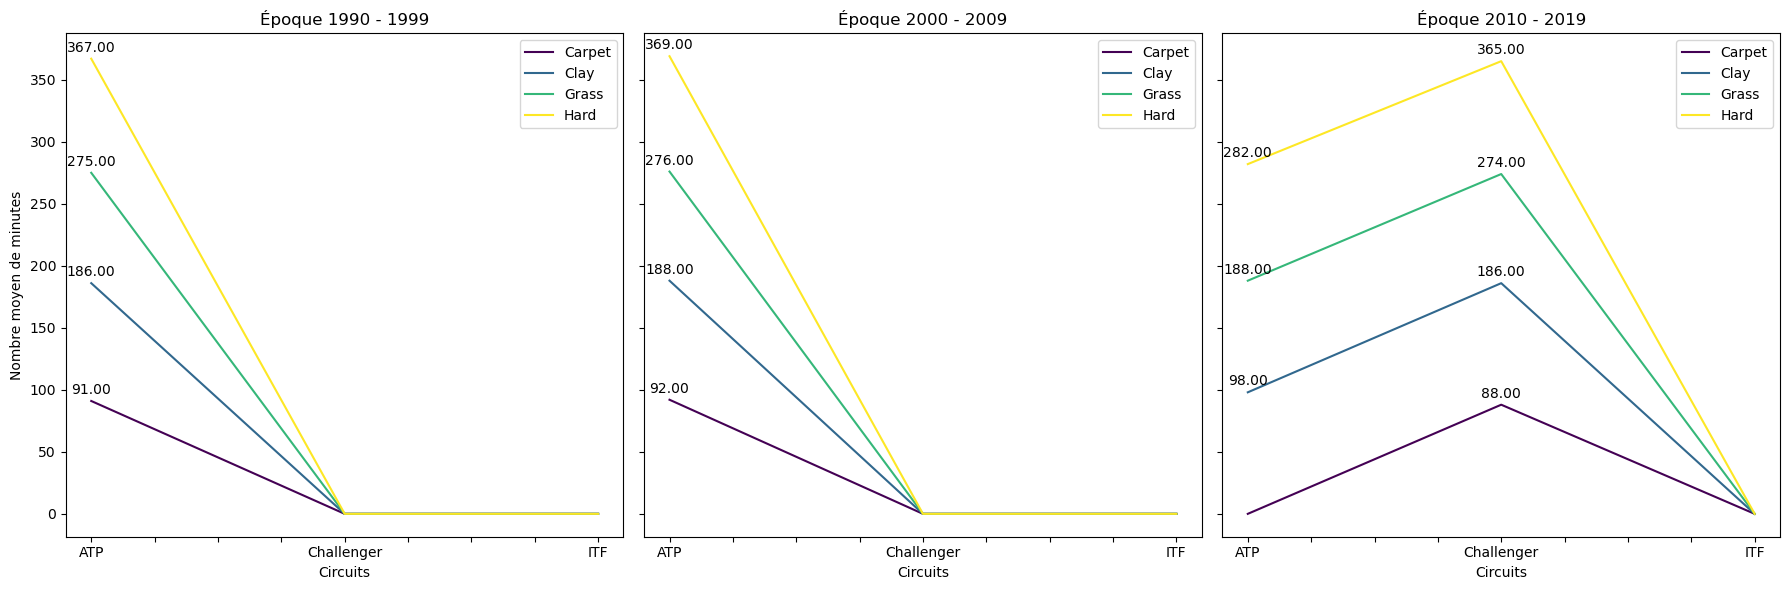

In [62]:
# Appel de fonction pour afficher les données liées à la statistique souhaitée
df_minutes_bo3 = visualisation_stat_mean_per_surface_per_circuit_per_epoque("minutes",3,analyse_9_null_0_bo3,analyse_9_bo3)

#print(df_minutes_bo3)

Epoque 1990 - 1999: Nombre de matchs avec des minutes inconnus = 57.21 %
Epoque 2000 - 2009: Nombre de matchs avec des minutes inconnus = 32.85 %
Epoque 2010 - 2019: Nombre de matchs avec des minutes inconnus = 24.48 %


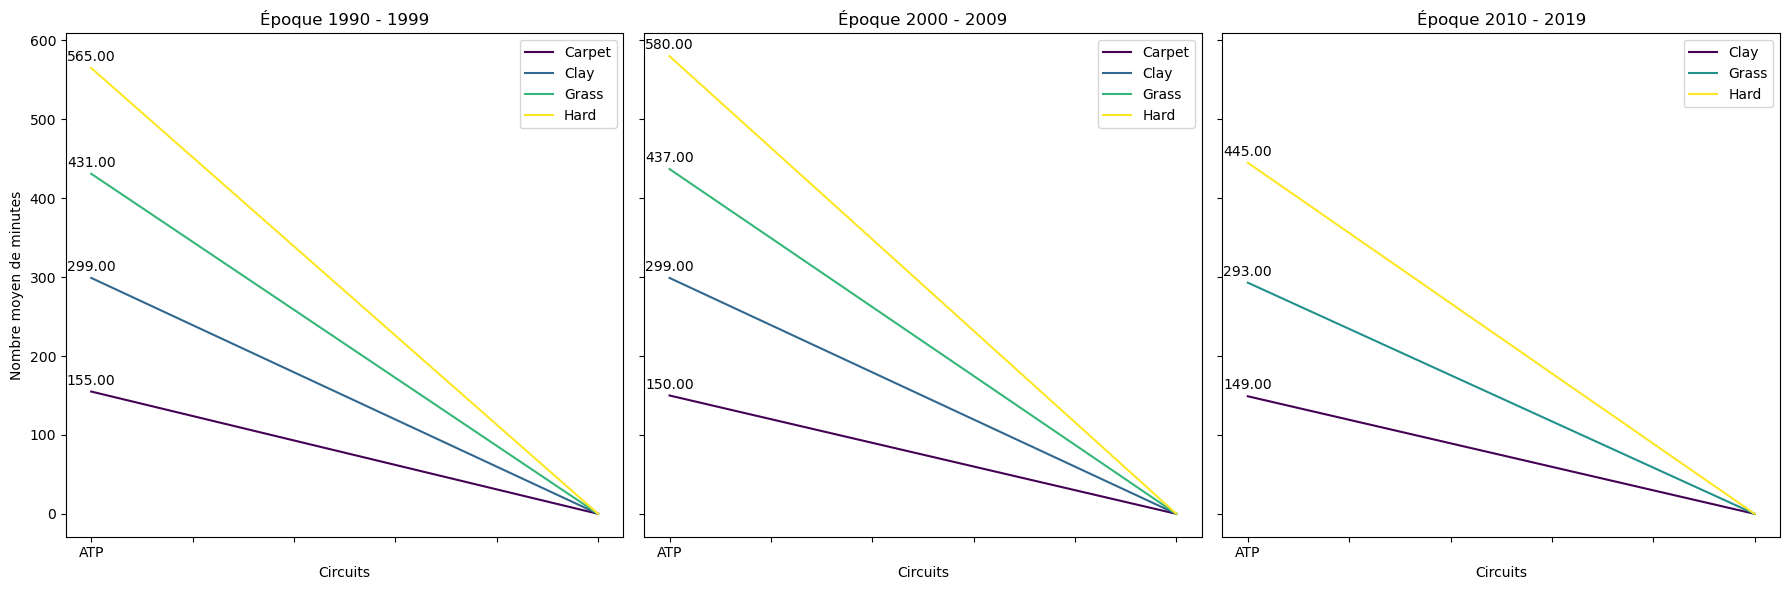

In [63]:
# Appel de fonction pour afficher les données liées à la statistique souhaitée
df_minutes_bo5 = visualisation_stat_mean_per_surface_per_circuit_per_epoque("minutes",5,analyse_9_null_0_bo5,analyse_9_bo5)

#print(df_minutes_bo5)

In [64]:
# Concaténation des données entre BO3 et BO5 de cette analyse de variable - utile pour tableau public
df_minutes_bo3_bo5 = pd.concat([df_minutes_bo3, df_minutes_bo5], axis=0)
df_minutes_bo3_bo5 = df_minutes_bo3_bo5.reset_index()
df_minutes_bo3_bo5 =df_minutes_bo3_bo5.drop(columns=['index'])
#print(df_minutes_bo3_bo5)

### 4.2.1.2 Moyenne des aces moyens par surface des différents circuits par époque - BO3 ET BO5

Epoque 1990 - 1999: Nombre de matchs avec des p_ace inconnus = 84.69 %
Epoque 2000 - 2009: Nombre de matchs avec des p_ace inconnus = 89.58 %
Epoque 2010 - 2019: Nombre de matchs avec des p_ace inconnus = 66.83 %


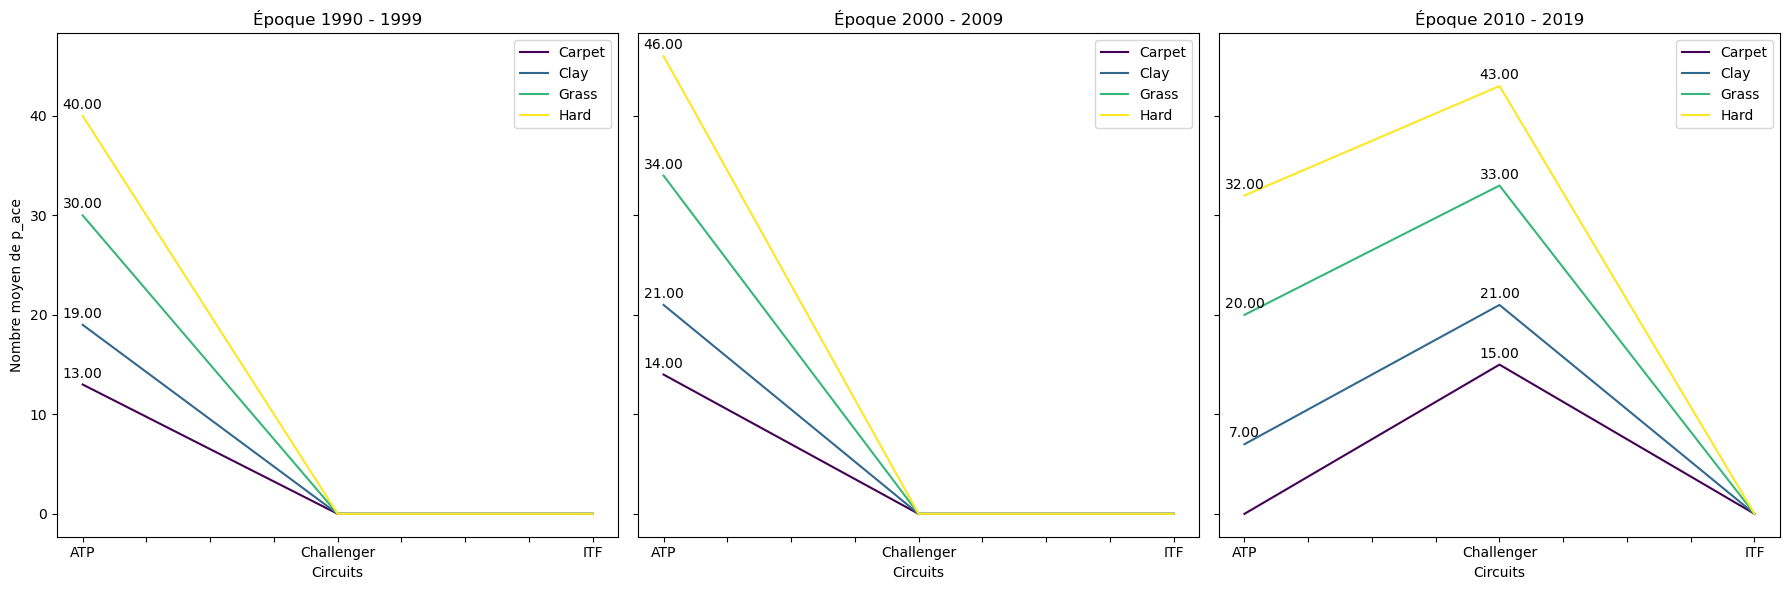

In [65]:
# Appel de fonction pour afficher les données liées à la statistique souhaitée
df_ace_bo3 = visualisation_stat_mean_per_surface_per_circuit_per_epoque("p_ace",3,analyse_9_null_0_bo3,analyse_9_bo3)

Epoque 1990 - 1999: Nombre de matchs avec des p_ace inconnus = 41.77 %
Epoque 2000 - 2009: Nombre de matchs avec des p_ace inconnus = 32.91 %
Epoque 2010 - 2019: Nombre de matchs avec des p_ace inconnus = 21.86 %


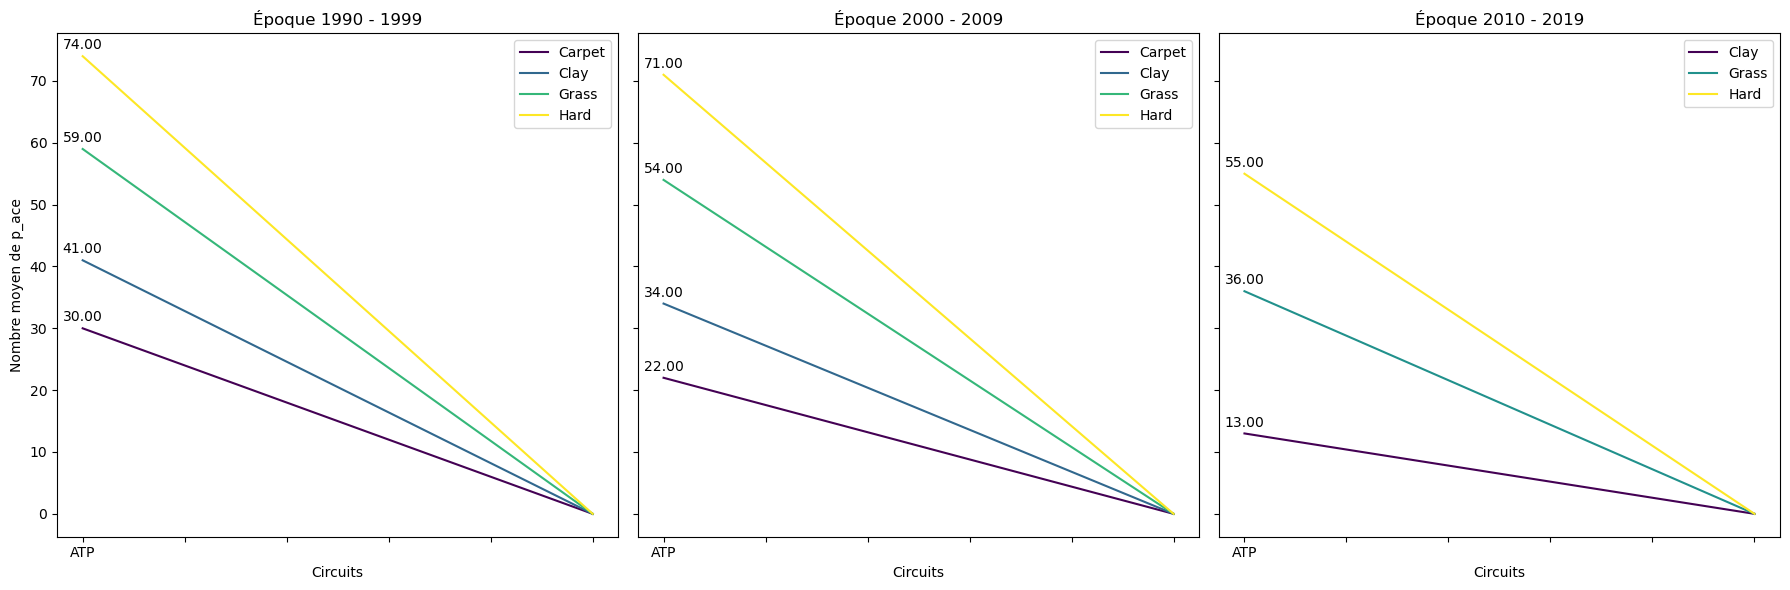

In [66]:
# Appel de fonction pour afficher les données liées à la statistique souhaitée
df_ace_bo5 = visualisation_stat_mean_per_surface_per_circuit_per_epoque("p_ace",5,analyse_9_null_0_bo5,analyse_9_bo5)

In [67]:
# Concaténation des données entre BO3 et BO5 de cette analyse de variable - utile pour tableau public
df_ace_bo3_bo5 = pd.concat([df_ace_bo3, df_ace_bo5], axis=0)
df_ace_bo3_bo5 = df_ace_bo3_bo5.reset_index()
df_ace_bo3_bo5 =df_ace_bo3_bo5.drop(columns=['index'])
#print(df_ace_bo3_bo5)

### 4.2.1.3 Moyenne des doubles fautes moyennes par surface des différents circuits par époque - BO3 ET BO5

Epoque 1990 - 1999: Nombre de matchs avec des p_df inconnus = 84.7 %
Epoque 2000 - 2009: Nombre de matchs avec des p_df inconnus = 89.67 %
Epoque 2010 - 2019: Nombre de matchs avec des p_df inconnus = 66.92 %


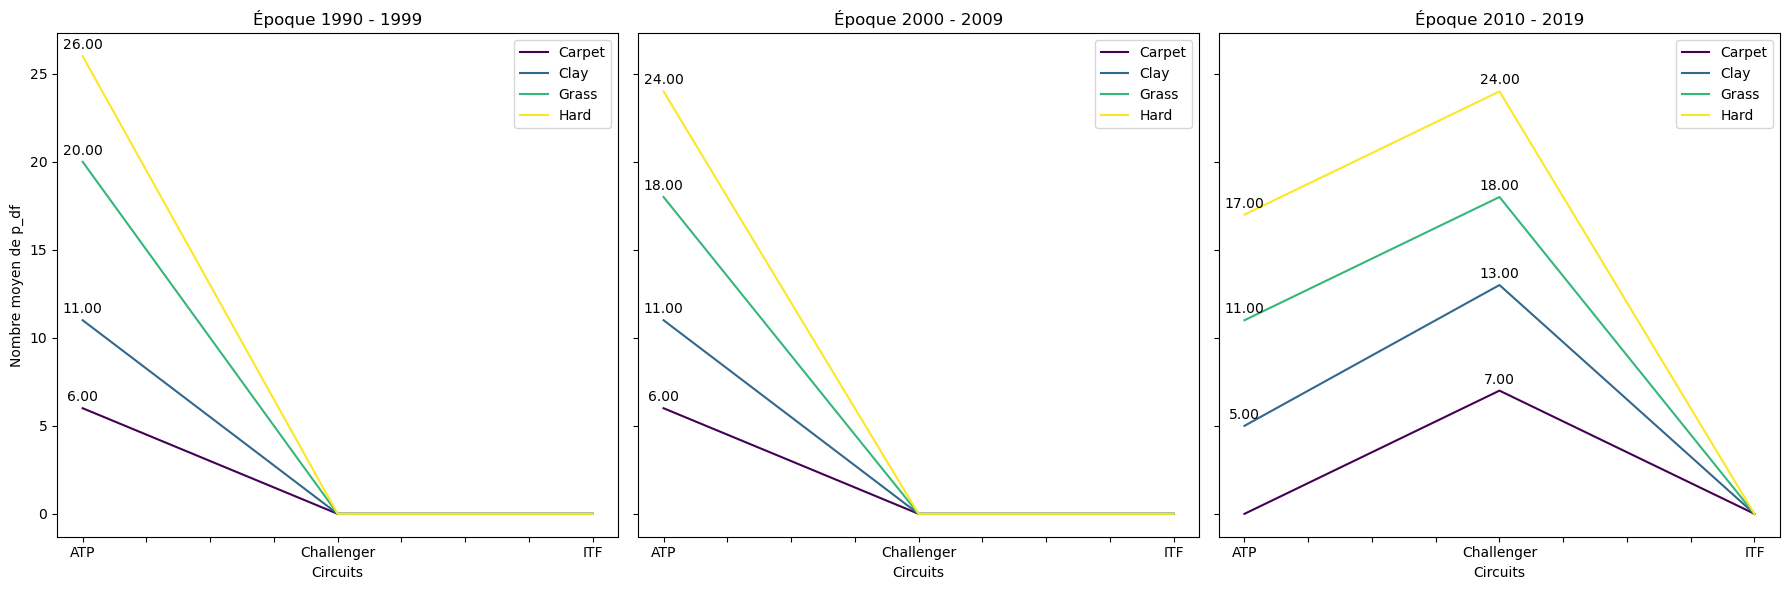

In [68]:
# Appel de fonction pour afficher les données liées à la statistique souhaitée
df_df_bo3 = visualisation_stat_mean_per_surface_per_circuit_per_epoque("p_df",3,analyse_9_null_0_bo3,analyse_9_bo3)

Epoque 1990 - 1999: Nombre de matchs avec des p_df inconnus = 41.7 %
Epoque 2000 - 2009: Nombre de matchs avec des p_df inconnus = 33.19 %
Epoque 2010 - 2019: Nombre de matchs avec des p_df inconnus = 22.05 %


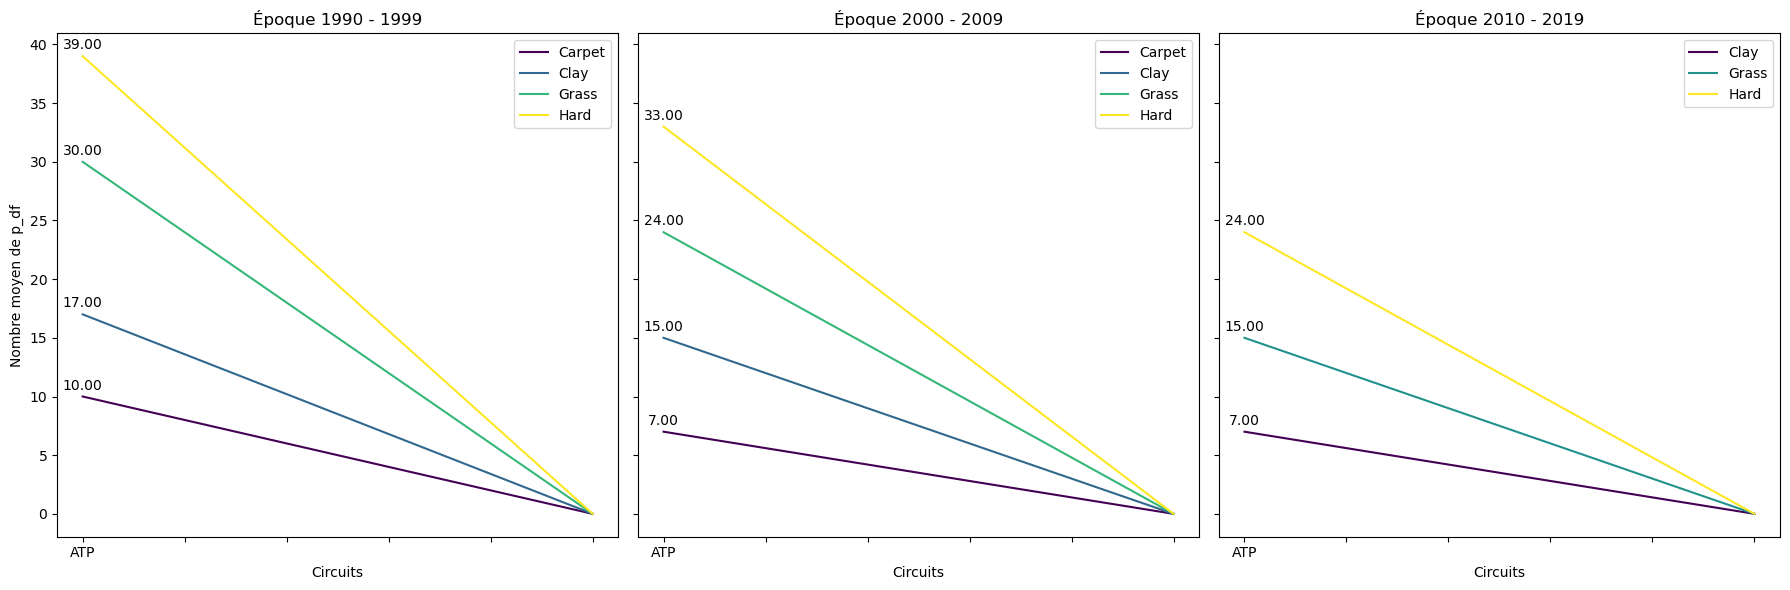

In [69]:
# Appel de fonction pour afficher les données liées à la statistique souhaitée
df_df_bo5 = visualisation_stat_mean_per_surface_per_circuit_per_epoque("p_df",5,analyse_9_null_0_bo5,analyse_9_bo5)

In [70]:
# Concaténation des données entre BO3 et BO5 de cette analyse de variable - utile pour tableau public
df_df_bo3_bo5 = pd.concat([df_df_bo3, df_df_bo5], axis=0)
df_df_bo3_bo5 = df_df_bo3_bo5.reset_index()
df_df_bo3_bo5 =df_df_bo3_bo5.drop(columns=['index'])
#print(df_ace_bo3_bo5)

### 4.2.1.4 Moyenne des services par surface des différents circuits par époque - BO3 ET BO5

Epoque 1990 - 1999: Nombre de matchs avec des p_svpt inconnus = 84.42 %
Epoque 2000 - 2009: Nombre de matchs avec des p_svpt inconnus = 89.47 %
Epoque 2010 - 2019: Nombre de matchs avec des p_svpt inconnus = 66.33 %


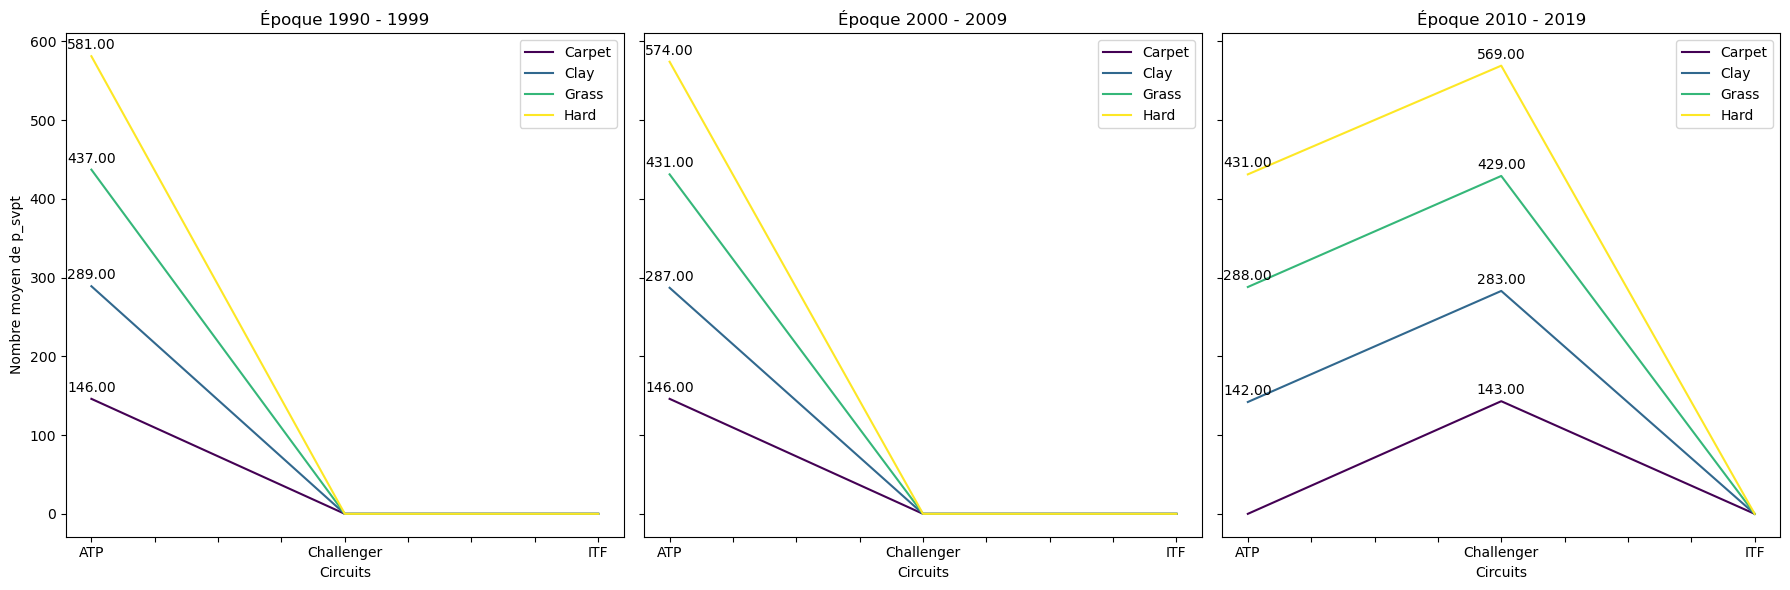

In [71]:
# Appel de fonction pour afficher les données liées à la statistique souhaitée
df_svpt_bo3 = visualisation_stat_mean_per_surface_per_circuit_per_epoque("p_svpt",3,analyse_9_null_0_bo3,analyse_9_bo3)

Epoque 1990 - 1999: Nombre de matchs avec des p_svpt inconnus = 41.56 %
Epoque 2000 - 2009: Nombre de matchs avec des p_svpt inconnus = 32.85 %
Epoque 2010 - 2019: Nombre de matchs avec des p_svpt inconnus = 21.66 %


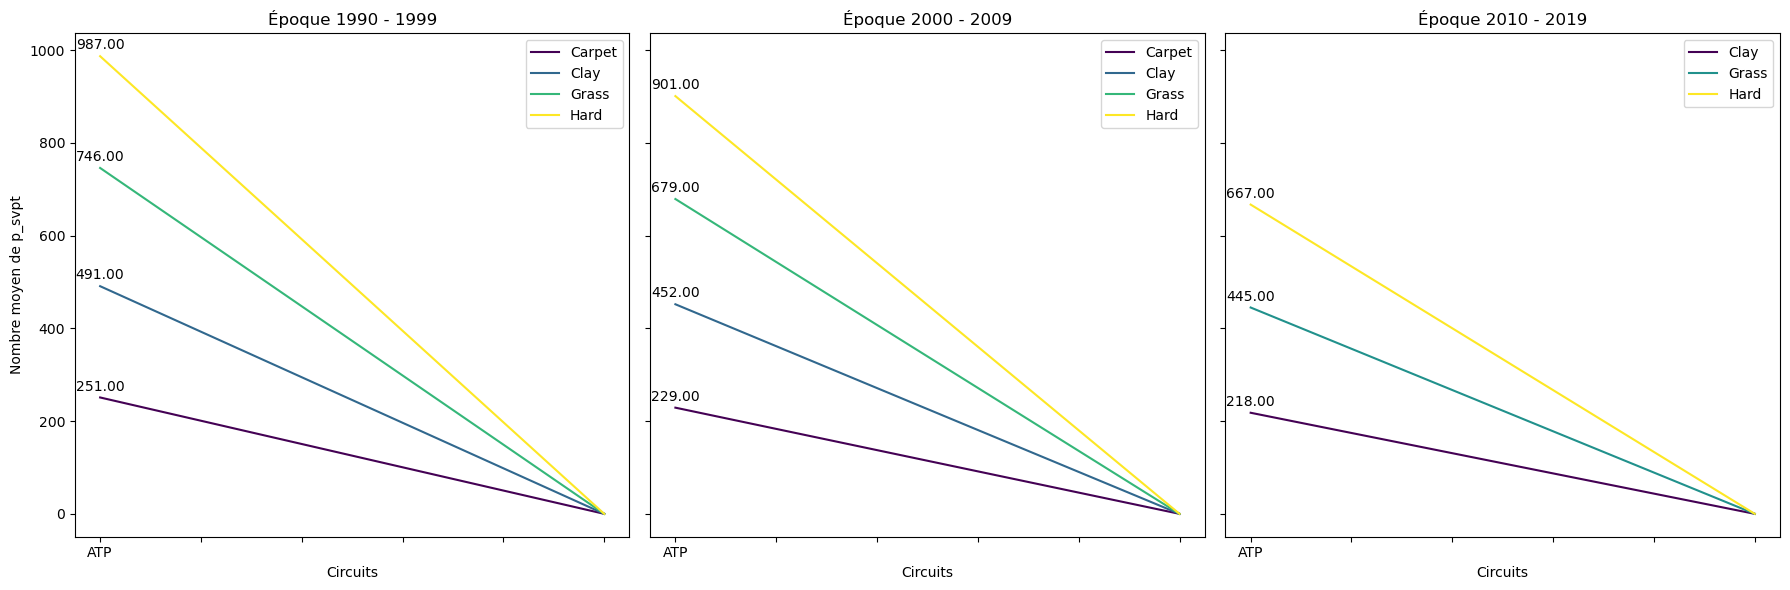

In [72]:
# Appel de fonction pour afficher les données liées à la statistique souhaitée
df_svpt_bo5 = visualisation_stat_mean_per_surface_per_circuit_per_epoque("p_svpt",5,analyse_9_null_0_bo5,analyse_9_bo5)

In [73]:
# Concaténation des données entre BO3 et BO5 de cette analyse de variable - utile pour tableau public
df_svpt_bo3_bo5 = pd.concat([df_svpt_bo3, df_svpt_bo5], axis=0)
df_svpt_bo3_bo5 = df_svpt_bo3_bo5.reset_index()
df_svpt_bo3_bo5 =df_svpt_bo3_bo5.drop(columns=['index'])
#print(df_ace_bo3_bo5)

### 4.2.1.5 Moyenne des p_1stIn par surface des différents circuits par époque - BO3 ET BO5

Epoque 1990 - 1999: Nombre de matchs avec des p_1stIn inconnus = 84.42 %
Epoque 2000 - 2009: Nombre de matchs avec des p_1stIn inconnus = 89.47 %
Epoque 2010 - 2019: Nombre de matchs avec des p_1stIn inconnus = 66.34 %


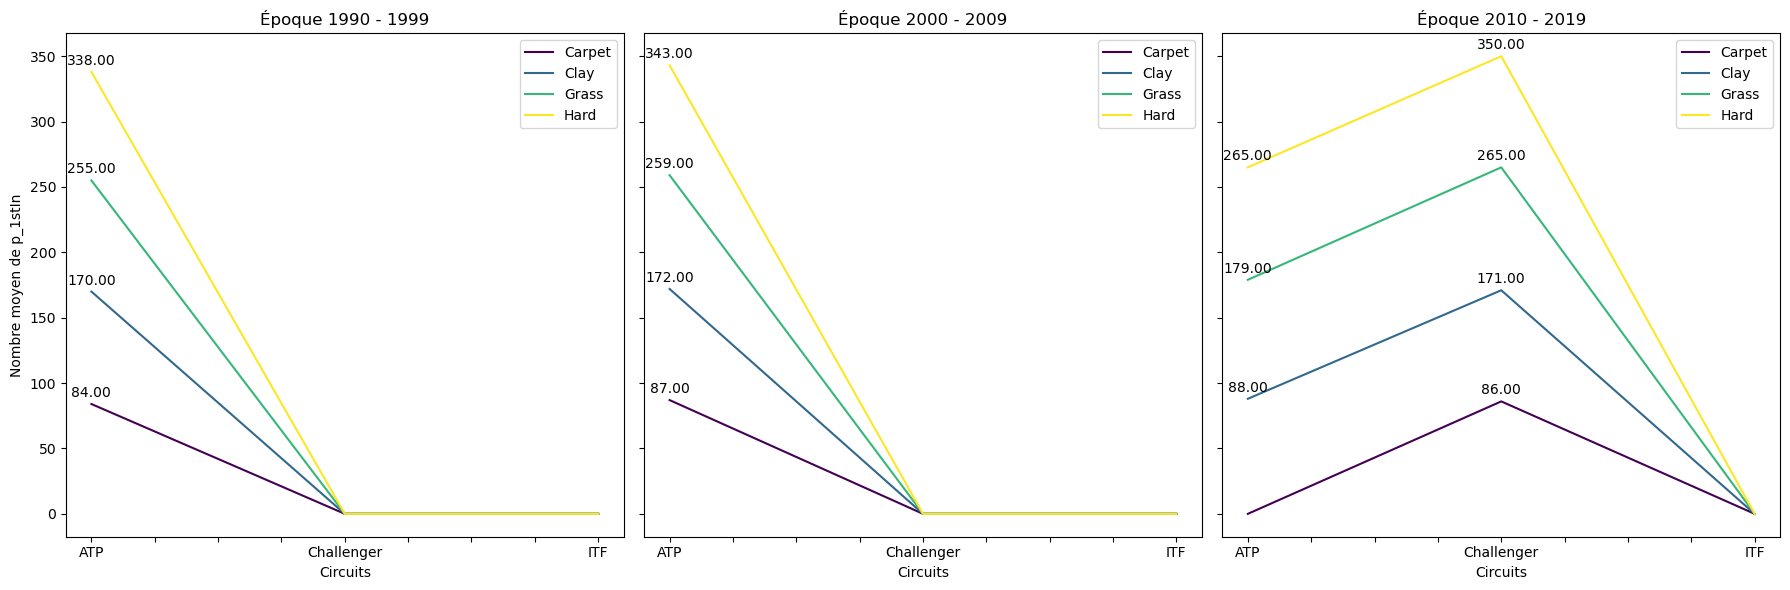

In [74]:
# Appel de fonction pour afficher les données liées à la statistique souhaitée
df_1stIn_bo3 = visualisation_stat_mean_per_surface_per_circuit_per_epoque("p_1stIn",3,analyse_9_null_0_bo3,analyse_9_bo3)

Epoque 1990 - 1999: Nombre de matchs avec des p_1stIn inconnus = 41.56 %
Epoque 2000 - 2009: Nombre de matchs avec des p_1stIn inconnus = 32.85 %
Epoque 2010 - 2019: Nombre de matchs avec des p_1stIn inconnus = 21.66 %


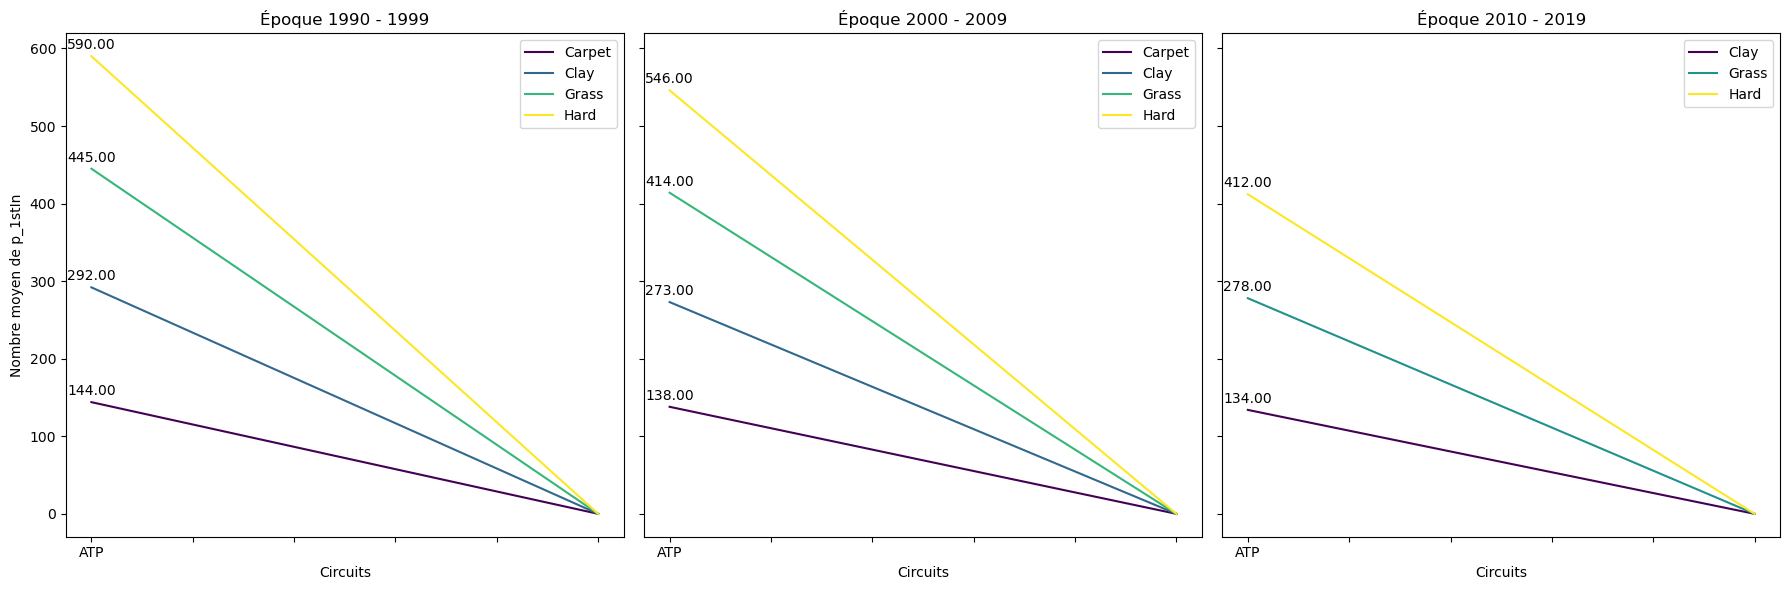

In [75]:
# Appel de fonction pour afficher les données liées à la statistique souhaitée
df_1stIn_bo5 = visualisation_stat_mean_per_surface_per_circuit_per_epoque("p_1stIn",5,analyse_9_null_0_bo5,analyse_9_bo5)

In [76]:
# Concaténation des données entre BO3 et BO5 de cette analyse de variable - utile pour tableau public
df_1stIn_bo3_bo5 = pd.concat([df_1stIn_bo3, df_1stIn_bo5], axis=0)
df_1stIn_bo3_bo5 = df_1stIn_bo3_bo5.reset_index()
df_1stIn_bo3_bo5 =df_1stIn_bo3_bo5.drop(columns=['index'])
#print(df_ace_bo3_bo5)

### 4.2.1.6 Moyenne des p_1stWon par surface des différents circuits par époque - BO3 ET BO5

Epoque 1990 - 1999: Nombre de matchs avec des p_1stWon inconnus = 84.42 %
Epoque 2000 - 2009: Nombre de matchs avec des p_1stWon inconnus = 89.47 %
Epoque 2010 - 2019: Nombre de matchs avec des p_1stWon inconnus = 66.34 %


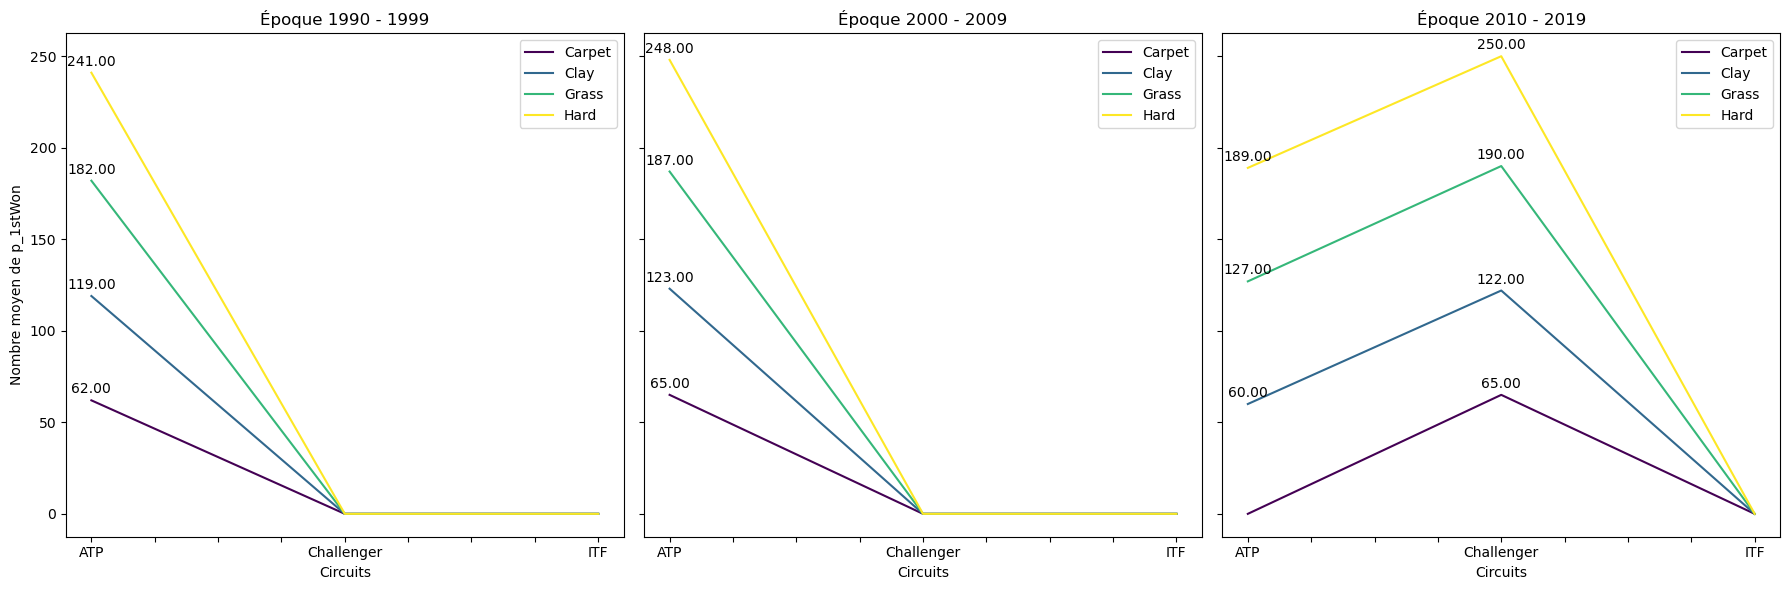

In [77]:
# Appel de fonction pour afficher les données liées à la statistique souhaitée
df_1stWon_bo3 = visualisation_stat_mean_per_surface_per_circuit_per_epoque("p_1stWon",3,analyse_9_null_0_bo3,analyse_9_bo3)

Epoque 1990 - 1999: Nombre de matchs avec des p_1stWon inconnus = 41.56 %
Epoque 2000 - 2009: Nombre de matchs avec des p_1stWon inconnus = 32.85 %
Epoque 2010 - 2019: Nombre de matchs avec des p_1stWon inconnus = 21.67 %


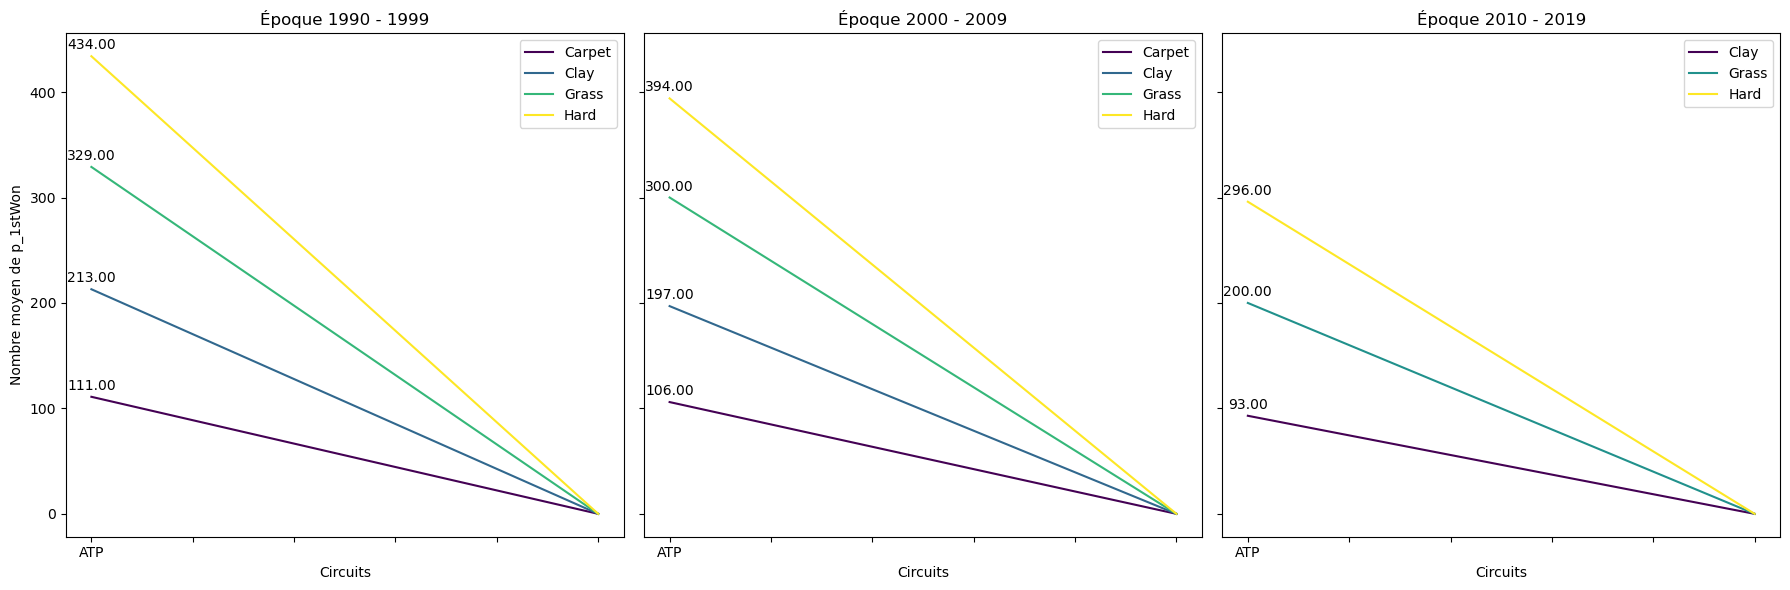

In [78]:
# Appel de fonction pour afficher les données liées à la statistique souhaitée
df_1stWon_bo5 = visualisation_stat_mean_per_surface_per_circuit_per_epoque("p_1stWon",5,analyse_9_null_0_bo5,analyse_9_bo5)

In [79]:
# Concaténation des données entre BO3 et BO5 de cette analyse de variable - utile pour tableau public
df_1stWon_bo3_bo5 = pd.concat([df_1stWon_bo3, df_1stWon_bo5], axis=0)
df_1stWon_bo3_bo5 = df_1stWon_bo3_bo5.reset_index()
df_1stWon_bo3_bo5 =df_1stWon_bo3_bo5.drop(columns=['index'])
#print(df_ace_bo3_bo5)

### 4.2.1.7 Moyenne des p_2ndWon par surface des différents circuits par époque - BO3 ET BO5

Epoque 1990 - 1999: Nombre de matchs avec des p_2ndWon inconnus = 84.42 %
Epoque 2000 - 2009: Nombre de matchs avec des p_2ndWon inconnus = 89.47 %
Epoque 2010 - 2019: Nombre de matchs avec des p_2ndWon inconnus = 66.34 %


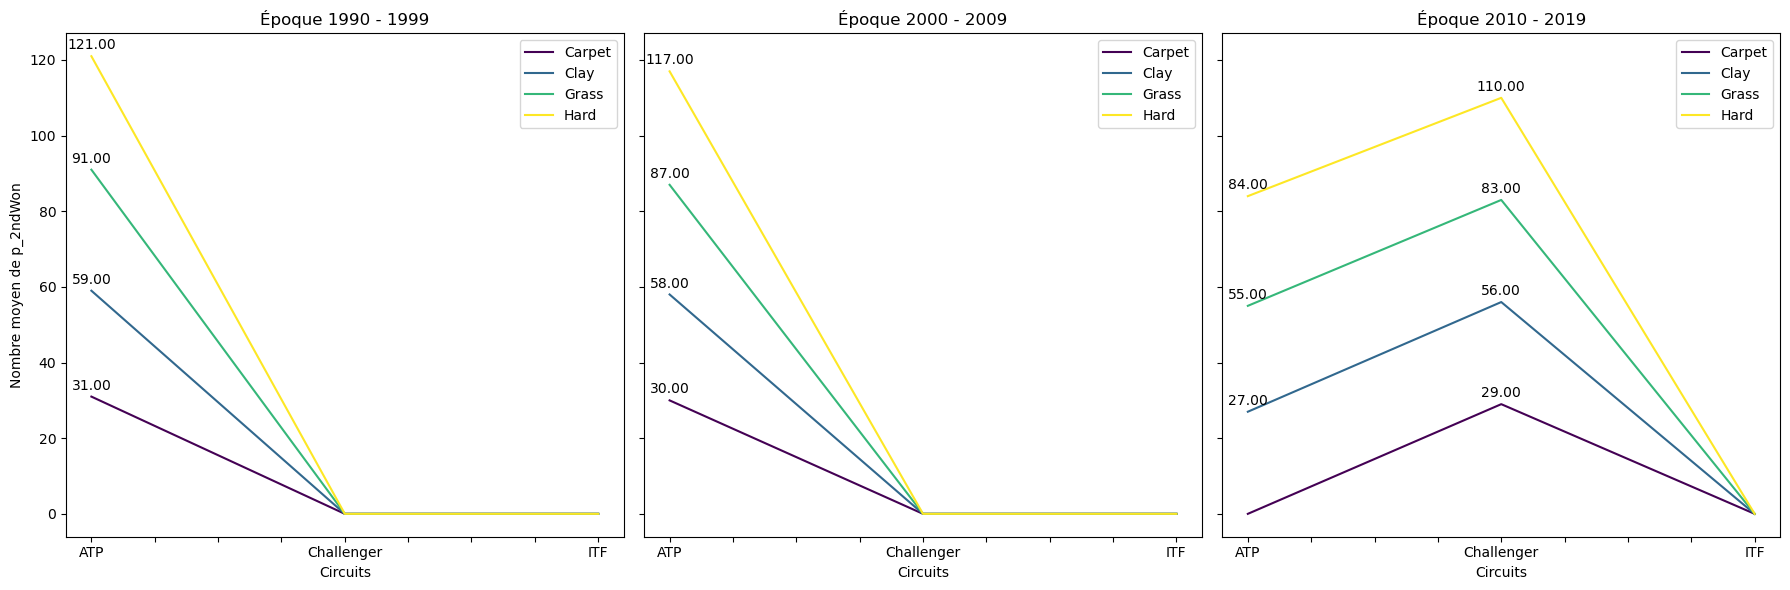

In [80]:
# Appel de fonction pour afficher les données liées à la statistique souhaitée
df_2ndWon_bo3 = visualisation_stat_mean_per_surface_per_circuit_per_epoque("p_2ndWon",3,analyse_9_null_0_bo3,analyse_9_bo3)

Epoque 1990 - 1999: Nombre de matchs avec des p_2ndWon inconnus = 41.56 %
Epoque 2000 - 2009: Nombre de matchs avec des p_2ndWon inconnus = 32.86 %
Epoque 2010 - 2019: Nombre de matchs avec des p_2ndWon inconnus = 21.69 %


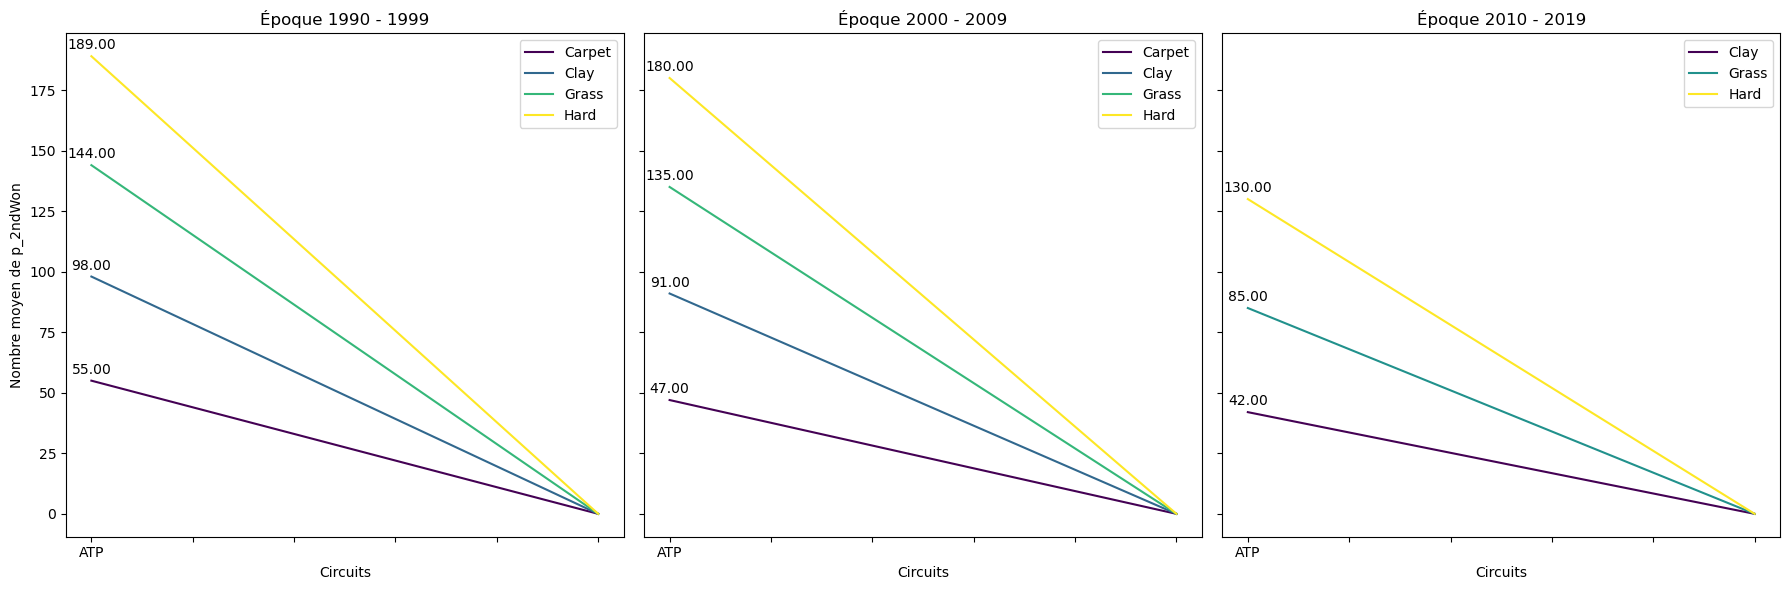

In [81]:
# Appel de fonction pour afficher les données liées à la statistique souhaitée
df_2ndWon_bo5 = visualisation_stat_mean_per_surface_per_circuit_per_epoque("p_2ndWon",5,analyse_9_null_0_bo5,analyse_9_bo5)

In [82]:
# Concaténation des données entre BO3 et BO5 de cette analyse de variable - utile pour tableau public
df_2ndWon_bo3_bo5 = pd.concat([df_2ndWon_bo3, df_2ndWon_bo5], axis=0)
df_2ndWon_bo3_bo5 = df_2ndWon_bo3_bo5.reset_index()
df_2ndWon_bo3_bo5 =df_2ndWon_bo3_bo5.drop(columns=['index'])
#print(df_ace_bo3_bo5)

### 4.2.1.8 Moyenne des p_SvGms par surface des différents circuits par époque - BO3 ET BO5

Epoque 1990 - 1999: Nombre de matchs avec des p_SvGms inconnus = 84.42 %
Epoque 2000 - 2009: Nombre de matchs avec des p_SvGms inconnus = 89.47 %
Epoque 2010 - 2019: Nombre de matchs avec des p_SvGms inconnus = 66.41 %


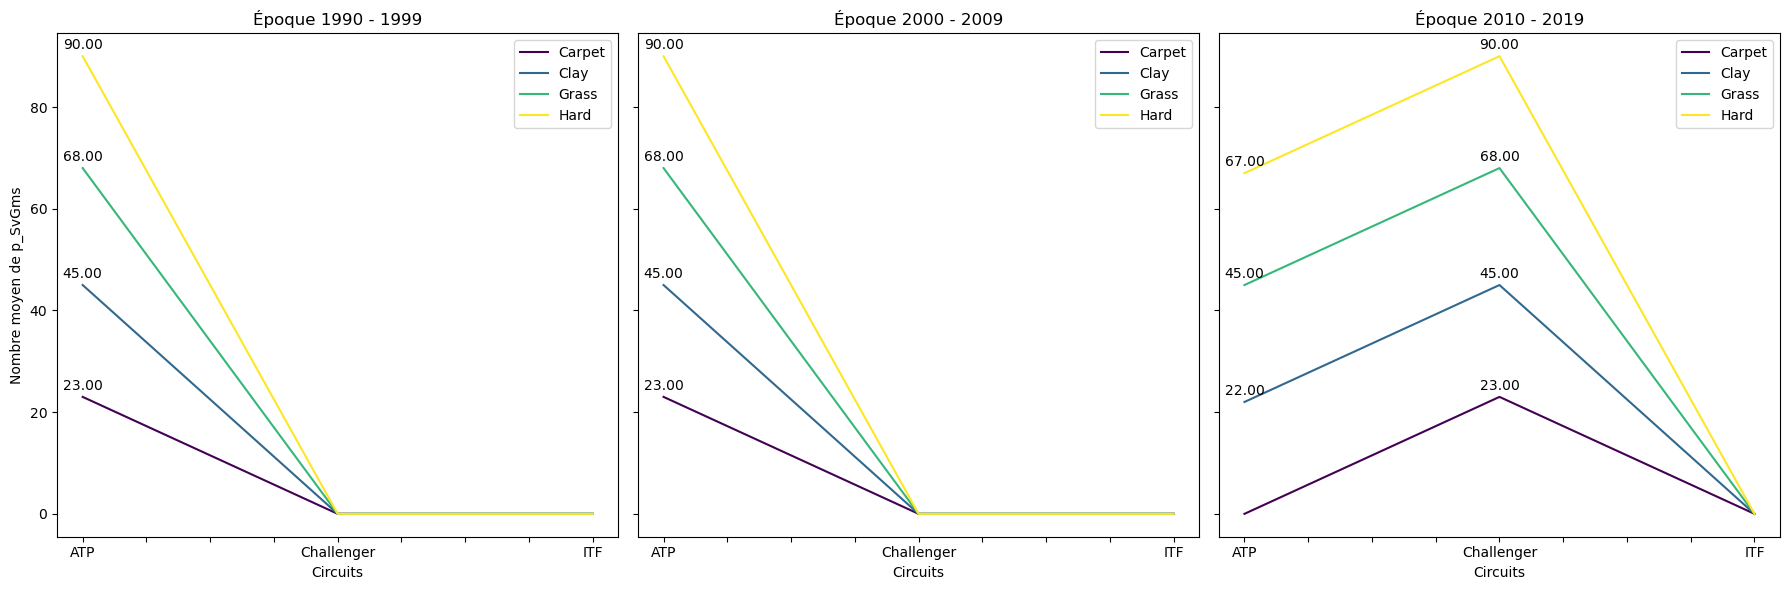

In [83]:
# Appel de fonction pour afficher les données liées à la statistique souhaitée
df_svgms_bo3 = visualisation_stat_mean_per_surface_per_circuit_per_epoque("p_SvGms",3,analyse_9_null_0_bo3,analyse_9_bo3)

Epoque 1990 - 1999: Nombre de matchs avec des p_SvGms inconnus = 41.56 %
Epoque 2000 - 2009: Nombre de matchs avec des p_SvGms inconnus = 32.86 %
Epoque 2010 - 2019: Nombre de matchs avec des p_SvGms inconnus = 21.66 %


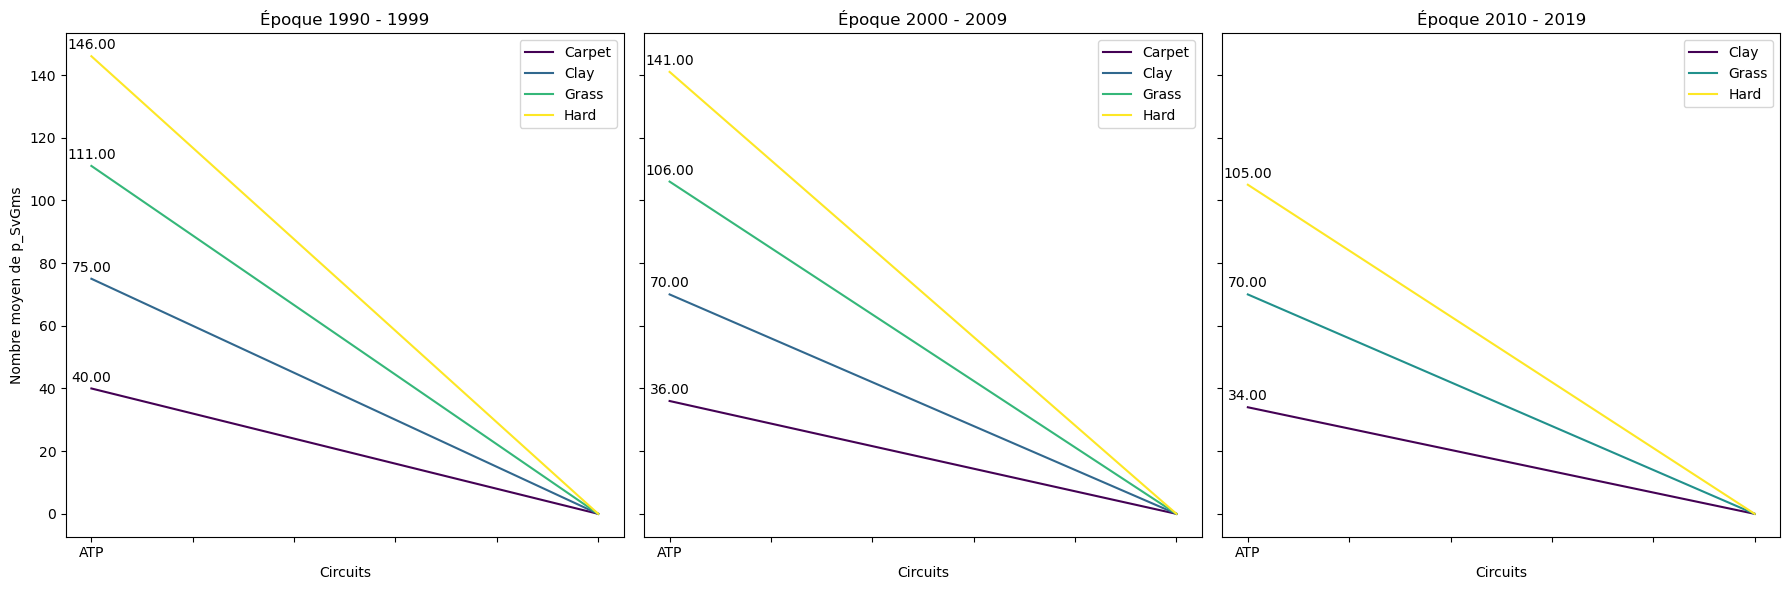

In [84]:
# Appel de fonction pour afficher les données liées à la statistique souhaitée
df_svgms_bo5 = visualisation_stat_mean_per_surface_per_circuit_per_epoque("p_SvGms",5,analyse_9_null_0_bo5,analyse_9_bo5)

In [85]:
# Concaténation des données entre BO3 et BO5 de cette analyse de variable - utile pour tableau public
df_svgms_bo3_bo5 = pd.concat([df_svgms_bo3, df_svgms_bo5], axis=0)
df_svgms_bo3_bo5 = df_svgms_bo3_bo5.reset_index()
df_svgms_bo3_bo5 =df_svgms_bo3_bo5.drop(columns=['index'])
#print(df_ace_bo3_bo5)

### 4.2.1.9 Moyenne des p_bpSaved par surface des différents circuits par époque - BO3 ET BO5

Epoque 1990 - 1999: Nombre de matchs avec des p_bpSaved inconnus = 84.58 %
Epoque 2000 - 2009: Nombre de matchs avec des p_bpSaved inconnus = 89.62 %
Epoque 2010 - 2019: Nombre de matchs avec des p_bpSaved inconnus = 66.81 %


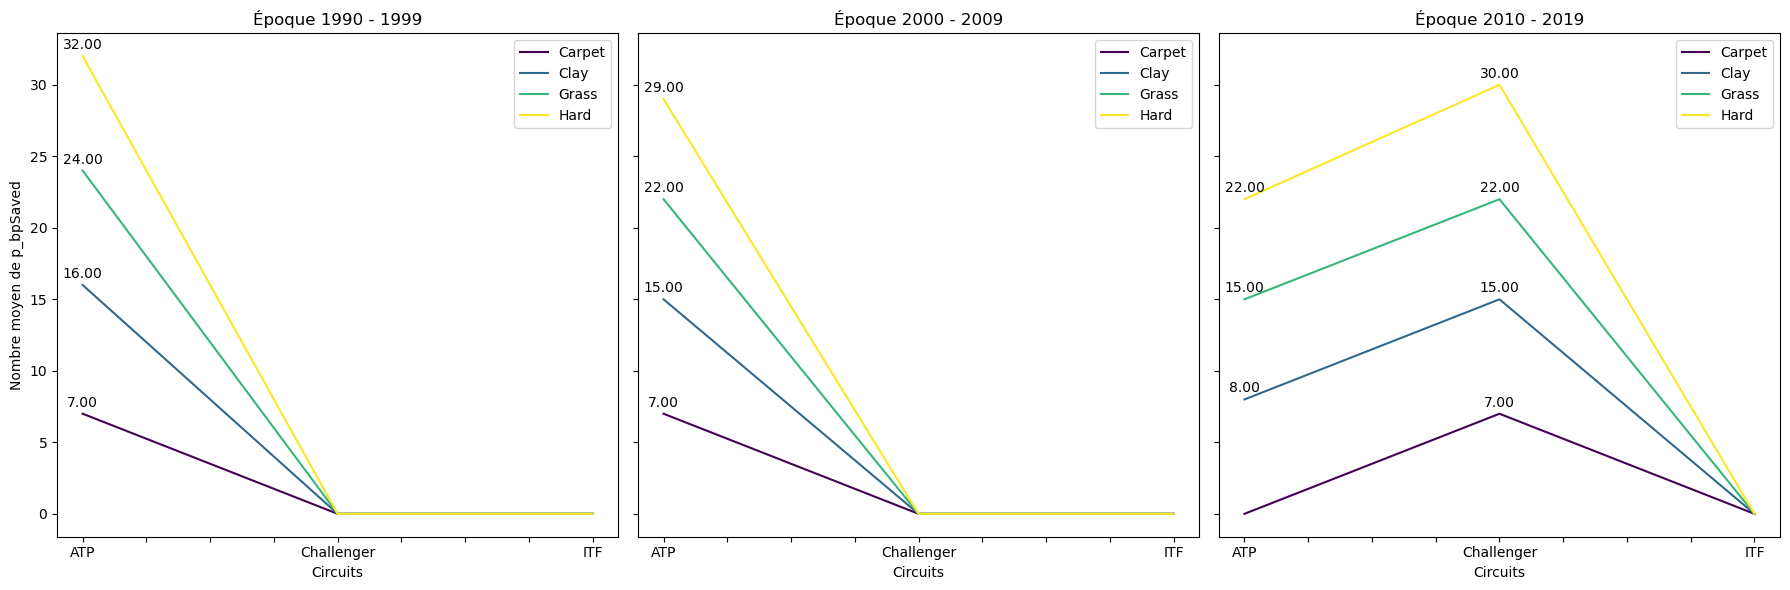

In [86]:
# Appel de fonction pour afficher les données liées à la statistique souhaitée
df_bpsaved_bo3 = visualisation_stat_mean_per_surface_per_circuit_per_epoque("p_bpSaved",3,analyse_9_null_0_bo3,analyse_9_bo3)

Epoque 1990 - 1999: Nombre de matchs avec des p_bpSaved inconnus = 41.71 %
Epoque 2000 - 2009: Nombre de matchs avec des p_bpSaved inconnus = 33.03 %
Epoque 2010 - 2019: Nombre de matchs avec des p_bpSaved inconnus = 21.98 %


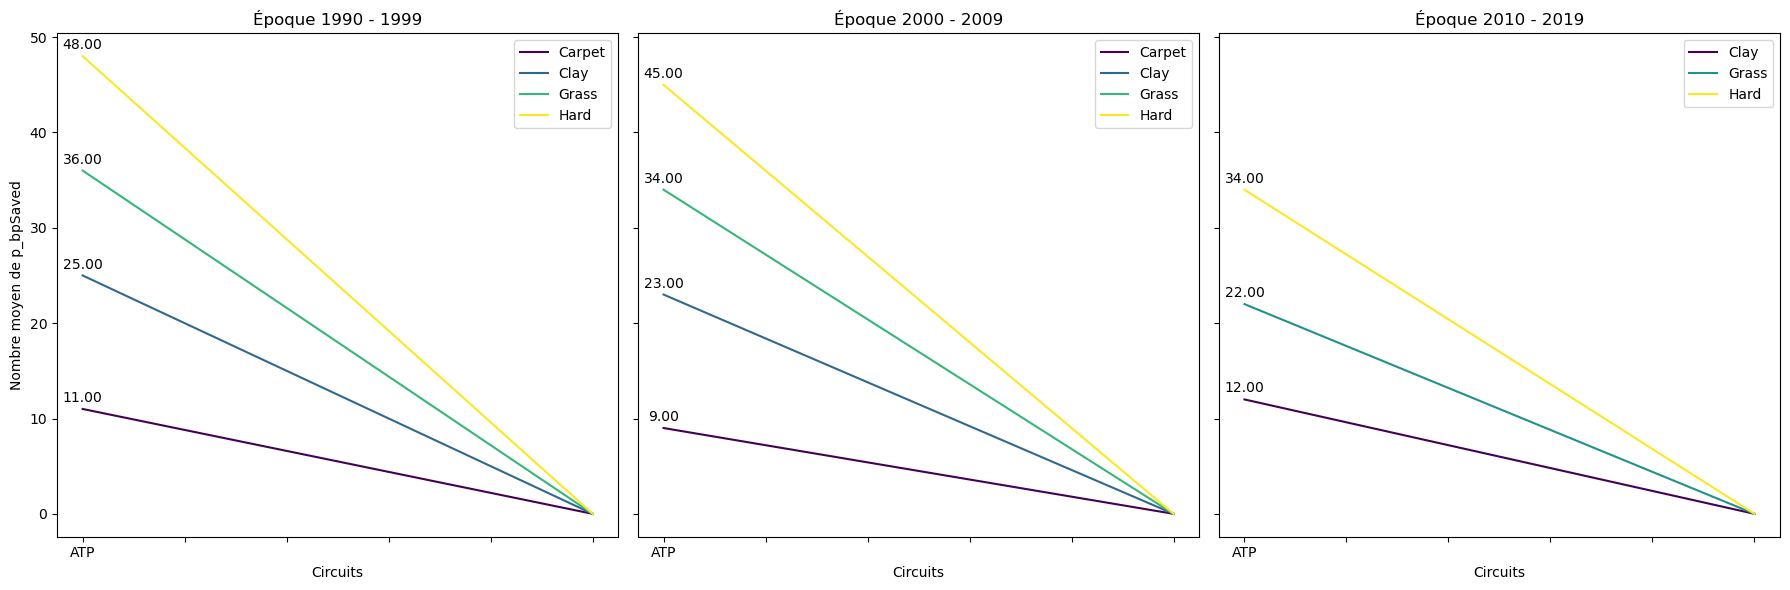

In [87]:
# Appel de fonction pour afficher les données liées à la statistique souhaitée
df_bpsaved_bo5 = visualisation_stat_mean_per_surface_per_circuit_per_epoque("p_bpSaved",5,analyse_9_null_0_bo5,analyse_9_bo5)

In [88]:
# Concaténation des données entre BO3 et BO5 de cette analyse de variable - utile pour tableau public
df_bpsaved_bo3_bo5 = pd.concat([df_bpsaved_bo3, df_bpsaved_bo5], axis=0)
df_bpsaved_bo3_bo5 = df_bpsaved_bo3_bo5.reset_index()
df_bpsaved_bo3_bo5 =df_bpsaved_bo3_bo5.drop(columns=['index'])
#print(df_ace_bo3_bo5)

### 4.2.1.10 Moyenne des p_bpFaced par surface des différents circuits par époque - BO3 ET BO5

Epoque 1990 - 1999: Nombre de matchs avec des p_bpFaced inconnus = 84.43 %
Epoque 2000 - 2009: Nombre de matchs avec des p_bpFaced inconnus = 89.48 %
Epoque 2010 - 2019: Nombre de matchs avec des p_bpFaced inconnus = 66.36 %


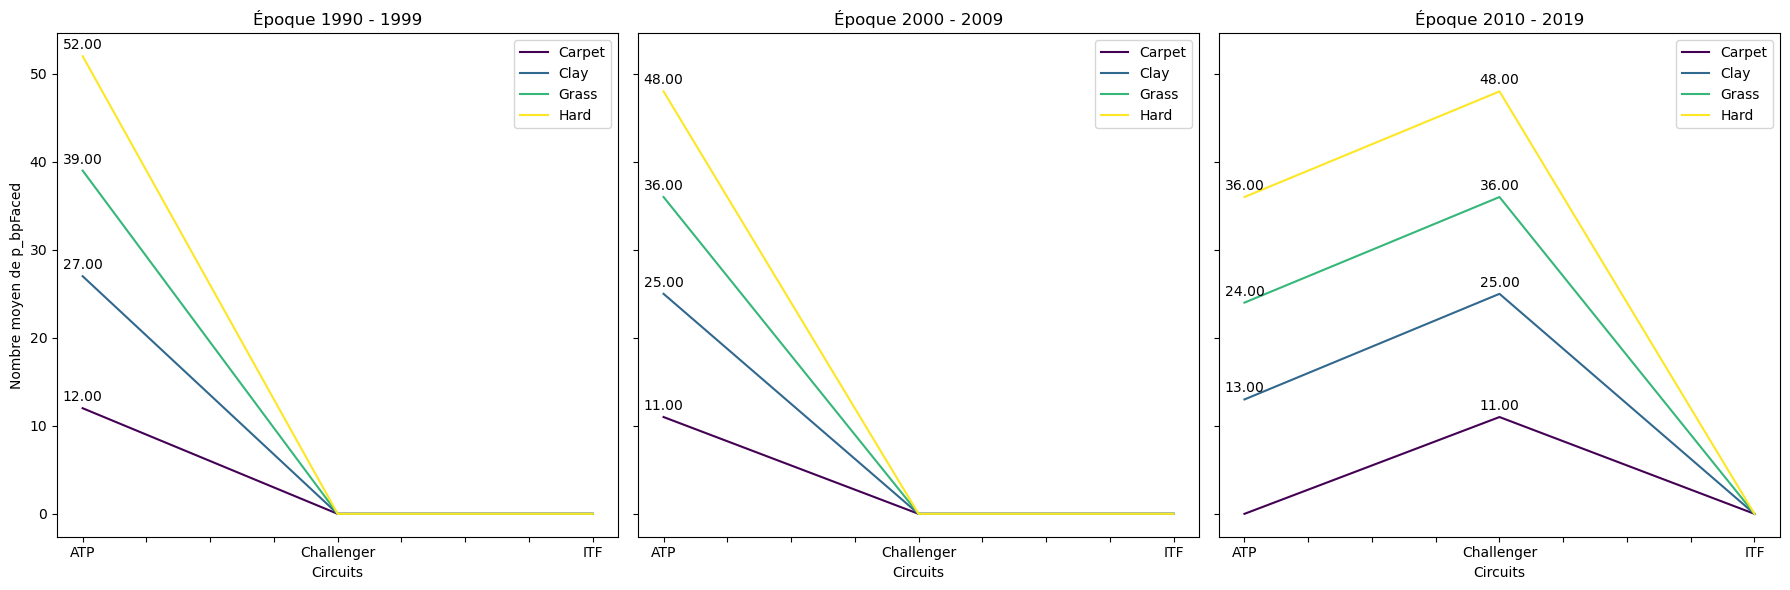

In [89]:
# Appel de fonction pour afficher les données liées à la statistique souhaitée
df_bpfaced_bo3 = visualisation_stat_mean_per_surface_per_circuit_per_epoque("p_bpFaced",3,analyse_9_null_0_bo3,analyse_9_bo3)

Epoque 1990 - 1999: Nombre de matchs avec des p_bpFaced inconnus = 41.56 %
Epoque 2000 - 2009: Nombre de matchs avec des p_bpFaced inconnus = 32.87 %
Epoque 2010 - 2019: Nombre de matchs avec des p_bpFaced inconnus = 21.72 %


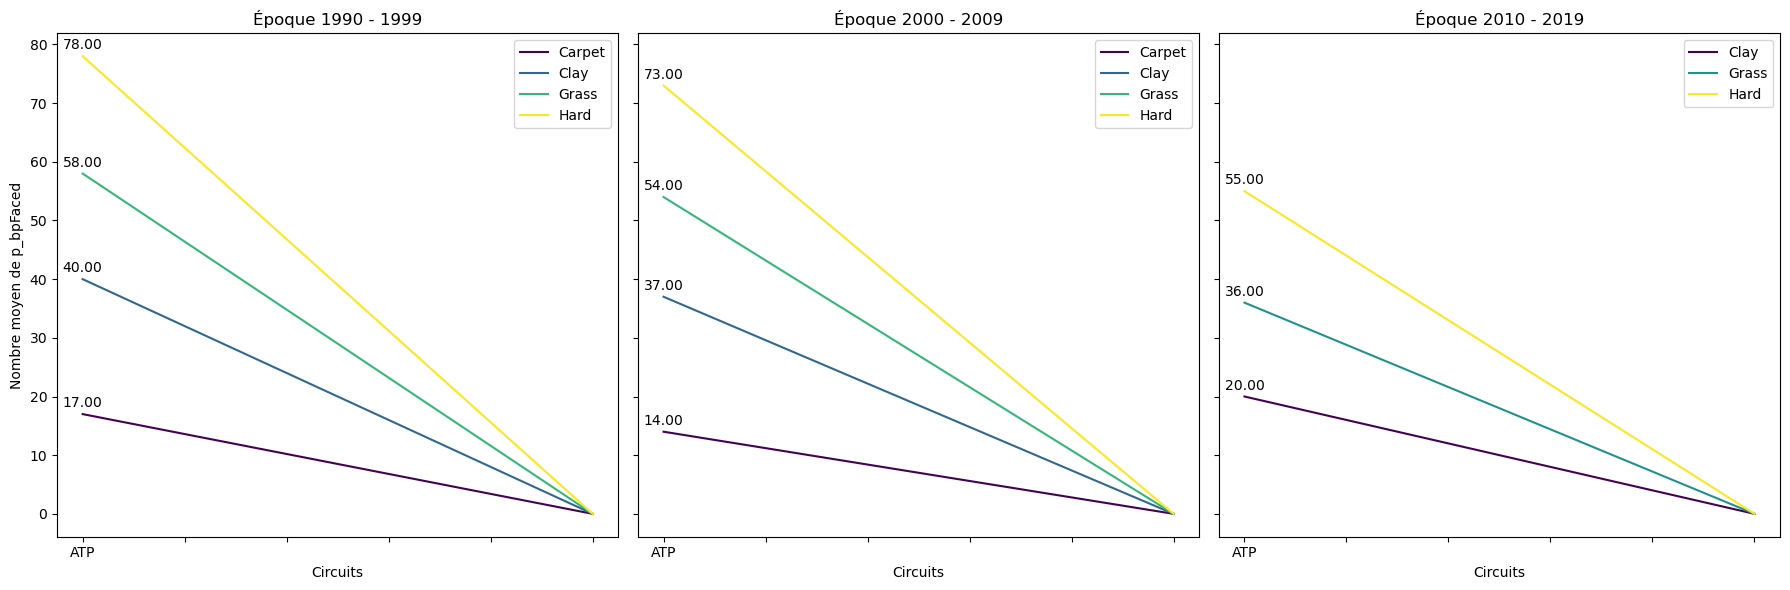

In [90]:
# Appel de fonction pour afficher les données liées à la statistique souhaitée
df_bpfaced_bo5 = visualisation_stat_mean_per_surface_per_circuit_per_epoque("p_bpFaced",5,analyse_9_null_0_bo5,analyse_9_bo5)

In [91]:
# Concaténation des données entre BO3 et BO5 de cette analyse de variable - utile pour tableau public
df_bpfaced_bo3_bo5 = pd.concat([df_bpfaced_bo3, df_bpfaced_bo5], axis=0)
df_bpfaced_bo3_bo5 = df_bpfaced_bo3_bo5.reset_index()
df_bpfaced_bo3_bo5 =df_bpfaced_bo3_bo5.drop(columns=['index'])
#print(df_ace_bo3_bo5)

In [92]:
# Concaténation de tous les résultats de ces analyses en un et même tableau

# Bibliothèque qui va permettre la fusion de plusieurs dataframe ensemble de manière itérative
#from functools import reduce

# Supposons que vos DataFrames soient stockés dans une liste appelée df_list
#df_list = [df_minutes_bo3_bo5, df_ace_bo3_bo5,df_df_bo3_bo5,df_svpt_bo3_bo5,df_1stIn_bo3_bo5,df_1stWon_bo3_bo5,df_2ndWon_bo3_bo5,df_svgms_bo3_bo5,df_bpsaved_bo3_bo5,df_bpfaced_bo3_bo5]

# Utilisez reduce pour appliquer la fusion itérative
#df_merged_analyse_9 = reduce(lambda left, right: pd.merge(left, right, on=['tourney_circuit', 'surface', 'epoque', 'bo'], how='outer'), df_list)

df_merged_analyse_9 = pd.concat([df_minutes_bo3_bo5, df_ace_bo3_bo5,df_df_bo3_bo5,df_svpt_bo3_bo5,df_1stIn_bo3_bo5,df_1stWon_bo3_bo5,df_2ndWon_bo3_bo5,df_svgms_bo3_bo5,df_bpsaved_bo3_bo5,df_bpfaced_bo3_bo5], axis=0)
df_merged_analyse_9 = df_merged_analyse_9.reset_index()
df_merged_analyse_9 =df_merged_analyse_9.drop(columns=['index'])



# Affichez le DataFrame résultant
#print(df_merged_analyse_9)

# On garde seulement les valeurs qui ne sont pas à 0
df_merged_analyse_9 = df_merged_analyse_9[df_merged_analyse_9["proportion_stat_analyse"] > 0]

# Intégration du nom de l'analyse
df_merged_analyse_9["nom_analyse"] = "2.2.variables_moyennes_per_circuit_per_surface_par_epoque" 

# Modification du naming contenant les valeurs de la proportion
df_merged_analyse_9 = df_merged_analyse_9.rename(columns={"proportion_stat_analyse": "valeurs"})

#print(df_merged_analyse_9)

# Export des données pour tableau public
#df_merged_analyse_9.to_excel(f"2.2.variables_moyennes_per_circuit_per_surface_par_epoque.xlsx",  sheet_name='Sheet_name_1') 
      

### Concaténation des données de la thématique 2 pour l'utilisation sur Tableau Public, et obtenir des filtres communs sur le dashboard

In [93]:
# Concaténation des deux jeux de données, pour pouvoir ensuite les exporter et les traiter sur tableau
tableau_thematique_2 = pd.concat([nb_tournoi_per_epoque_bo3_bo5, df_merged_analyse_9], axis=0)


# Indication "no_data" sur les valeurs NULL
tableau_thematique_2 = tableau_thematique_2.fillna("no_data")

#print(tableau_thematique_1)

# Export des données
tableau_thematique_2.to_excel("thematique_2_data.xlsx",  sheet_name='Sheet_name_1') 

## 4.3 Thématique 3 : Les joueurs et les rankings

In [94]:
# Convertissez la colonne "ranking_date_date" en type datetime si ce n'est pas déjà fait
ranking_00_to_20_quotidien['ranking_date_date'] = pd.to_datetime(ranking_00_to_20_quotidien['ranking_date_date'])

# Extrait l'année de la colonne "ranking_date_date"
ranking_00_to_20_quotidien['year'] = ranking_00_to_20_quotidien['ranking_date_date'].dt.year

    # Créer un champ époque pour répartir les données entre les 3 époques analysées 
analyse_all_rank_epoque = ranking_00_to_20_quotidien
analyse_all_rank_epoque.loc[(analyse_all_rank_epoque['year'] >= 1990) & (analyse_all_rank_epoque['year'] <= 1999), ['epoque']] = "1990 - 1999"
analyse_all_rank_epoque.loc[(analyse_all_rank_epoque['year'] >= 2000) & (analyse_all_rank_epoque['year'] <= 2009), ['epoque']] = "2000 - 2009"
analyse_all_rank_epoque.loc[(analyse_all_rank_epoque['year'] >= 2010) & (analyse_all_rank_epoque['year'] <= 2019), ['epoque']] = "2010 - 2019"


    # On exclut tous les ranks ne rentrant pas dans les catégories d'époque
analyse_all_rank_epoque = analyse_all_rank_epoque[analyse_all_rank_epoque["epoque"].notnull()]

### 4.3.1.1 TOP 10 : Nombre de joueurs qui sont restés le plus dans le top 100 toutes époques confondues (nb semaines)

In [95]:
# Traitements pour tous les top 10 des joueurs qui sont restés le plus dans x rank, pendant le plus de semaines - ranking_date = classement par semaine

analyse_10 = analyse_all_rank_epoque

    # CréatIon des champs qui vont permettre de comptabiliser le nombre de jours passés a tel ou tel rank et completion
        # Création du champ pour le top 100 ranks - Ajout de 1 quand rank inférieur ou égal à 100
            # Initialisez la colonne à 0
        # Création du champ pour le top 10 ranks - Ajout de 1 quand rank inférieur ou égal à 10
            # Initialisez la colonne à 0
        # Création du champ pour rank 1 - Ajout de 1 quand rank Égal à 1
            # Initialisez la colonne à 0
analyse_10['rank_top_100'] = 0 
analyse_10.loc[(analyse_10['rank'] <= 100) & (analyse_10['rank'] >= 1), ['rank_top_100']] = 1
analyse_10['rank_top_10'] = 0 
analyse_10.loc[(analyse_10['rank'] <= 10) & (analyse_10['rank'] >= 1), ['rank_top_10']] = 1
analyse_10['rank_top_1'] = 0 
analyse_10.loc[analyse_10['rank'] == 1, ['rank_top_1']] = 1

    # A. Traitement pour obtenir les top 10 toutes époques confondues 

        # Group by pour rassembler les données autour des identifiants des joueurs, pour mener la somme des points sur les champs créées, qui correspond au nombre de jours passées à tel ou tel rank
analyse_10_all_epoque = analyse_10.groupby(["player"]).agg({"name_first":"first", "name_last":"first", "ioc":"first","rank_top_100":"sum", "rank_top_10":"sum","rank_top_1":"sum"})
analyse_10_all_epoque = analyse_10_all_epoque.reset_index()

        # Trie et top 10 des joueurs qui sont restés le plus de semaines dans le top 100
top_10_players_top_rank_100 = analyse_10_all_epoque.sort_values(by='rank_top_100', ascending=False).head(10)
#print(top_10_players_top_rank_100)

        # Trie et top 10 des joueurs qui sont restés le plus de semaines dans le top 10
top_10_players_top_rank_10 = analyse_10_all_epoque.sort_values(by='rank_top_10', ascending=False).head(10)
#print(top_10_players_top_rank_10)

        # Trie et top 10 des joueurs qui sont restés le plus de semaines top 1
top_10_players_top_rank_1 = analyse_10_all_epoque.sort_values(by='rank_top_1', ascending=False).head(10)
#print(top_10_players_top_rank_1)

    # B. Traitement pour obtenir les top 10 par époque

        # Group by pour rassembler les données autour des identifiants des joueurs ET les époques, pour mener la somme des points sur les champs créées, qui correspond au nombre de jours passées à tel ou tel rank
analyse_10_per_epoque = analyse_10.groupby(["player", "epoque"]).agg({"name_first":"first", "name_last":"first", "ioc":"first","rank_top_100":"sum", "rank_top_10":"sum","rank_top_1":"sum"})
analyse_10_per_epoque = analyse_10_per_epoque.reset_index()

# Fonction pour récupérer de manière dynmaique via des appels les top 10 de chaque époque 
def get_top_10_per_epoque (dataframe, colonne_analyse_rank):
    
    epoques = dataframe["epoque"].unique()
    
    top_10_players_df_per_epoque = pd.DataFrame()
    
    for epoque in epoques:
        
        analyse_10_per_epoque = dataframe[dataframe["epoque"] == epoque]

        top_10_players_per_epoque = analyse_10_per_epoque.sort_values(by=colonne_analyse_rank, ascending=False).head(10)
        
        top_10_players_df_per_epoque = pd.concat([top_10_players_df_per_epoque, top_10_players_per_epoque])

    return(top_10_players_df_per_epoque)
 

In [96]:
# Visualisation du nombre de temps passés à tel ou tel classement
    # Utilisation d'une fonction pour éviter la redondance
def nb_joueur_keep_top_x(dataframe, type_analyse_epoque, column_analyse_rank):

    # A. Visualisation toutes époques
    if(type_analyse_epoque == "all_epoque"):

        # Concaténer les colonnes "name_first" et "name_last" pour obtenir le nom complet
        dataframe['player_name'] = dataframe['name_first'] + ' ' + dataframe['name_last']

        # Trier les données par "rank_top_x" en ordre décroissant
        dataframe = dataframe.sort_values(by=column_analyse_rank, ascending=False)

        # Créer le graphique à barres
        plt.figure(figsize=(10, 6))
        plt.barh(dataframe['player_name'], dataframe[column_analyse_rank])
        plt.xlabel('Nombre de semaines passées '+column_analyse_rank)
        plt.ylabel('Joueurs')
        plt.title('Top 10 des joueurs avec le plus de '+column_analyse_rank)
        plt.gca().invert_yaxis()  # Inverser l'axe y pour afficher le joueur avec le plus de rank_top_100 en haut
        plt.tight_layout()

        # Ajouter des étiquettes de valeurs à chaque barre
        for index, value in enumerate(dataframe[column_analyse_rank]):
            plt.text(value, index, str(value))

        plt.tight_layout()
        
        # Afficher le graphique
        plt.show()
        
        # Ajout d'une colonne qui précise le rank_top_ciblé pour les joueurs
        dataframe["rank_analyse"] = column_analyse_rank    
        
        # Rename pour uniformiser le champ, pour la construction du dataframe concaténé à la fin - utile pour Tableau public
        dataframe = dataframe.rename(columns={column_analyse_rank: "nb_semaine_rank_x"})

        return(dataframe)
    
    # Visualisation par époque
    elif(type_analyse_epoque == "per_epoque"):
        
        # Divisez les données par époque
        epoques = dataframe['epoque'].unique()
        top_10_players = {}

        for epoque in epoques:
            top_10_players[epoque] = dataframe[dataframe['epoque'] == epoque].sort_values(by=column_analyse_rank, ascending=False).head(10)

        
        # Création d'une liste qui va rassembler les donénes de toutes les époques - utile pour tableau public
        dfs = []
            
        # Créez les graphiques à barres pour chaque époque
        for epoque, top_players in top_10_players.items():
            plt.figure(figsize=(10, 6))


            plt.barh(top_players['name_first'] + ' ' + top_players['name_last'], top_players[column_analyse_rank])
            plt.xlabel('Nombre de Semaines passées dans le '+ column_analyse_rank)
            plt.ylabel('Joueurs')
            plt.title(f'Top 10 des joueurs ({epoque})')
            plt.gca().invert_yaxis()  # Inverser l'axe y pour afficher le joueur avec le plus de rank_top_100 en haut
            
            
                        # Ajouter des étiquettes de valeurs à chaque barre
            for index, value in enumerate(top_players[column_analyse_rank]):
                plt.text(value, index, str(value))
            
            plt.tight_layout()
            plt.show()
            
            #print(top_players)
            
            # Ajout d'une colonne qui précise le rank_top_ciblé pour les joueurs
            top_players["rank_analyse"] = column_analyse_rank
    
            # Rename pour uniformiser le champ, pour la construction du dataframe concaténé à la fin - utile pour Tableau public
            top_players = top_players.rename(columns={column_analyse_rank: "nb_semaine_rank_x"})

            # Ajouter le DataFrame à la liste - utile pour tableau public
            dfs.append(top_players)
    
        # Concaténer les DataFrames de chaque époque en un seul DataFrame - utile pour tableau public
        result_df = pd.concat(dfs, ignore_index=True)
        
        #print(result_df)
        return(result_df)

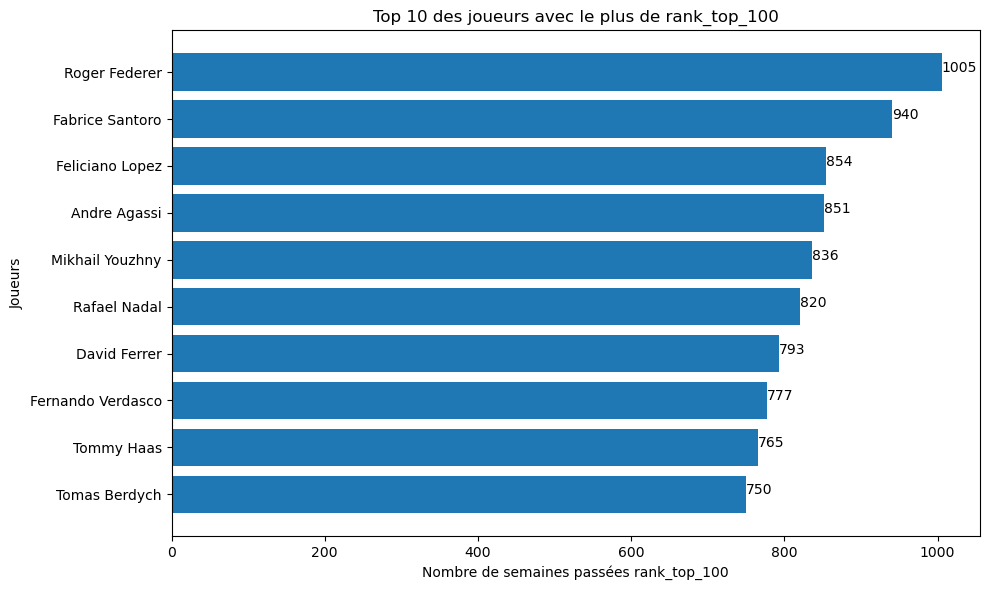

In [97]:
# Appel de fonction pour visualiser les données toutes épouqes pour le top en question
df_rank_top_100_all_epoque = nb_joueur_keep_top_x(top_10_players_top_rank_100, "all_epoque", "rank_top_100")

# Suppression des colonnes qui ne correspondent pas au rank traité
df_rank_top_100_all_epoque =df_rank_top_100_all_epoque.drop(columns=['rank_top_10','rank_top_1'])

#print(df_rank_top_100_all_epoque)

### 4.3.1.2 TOP 10 : Nombre de joueurs qui sont restés le plus dans le top 100 par époque

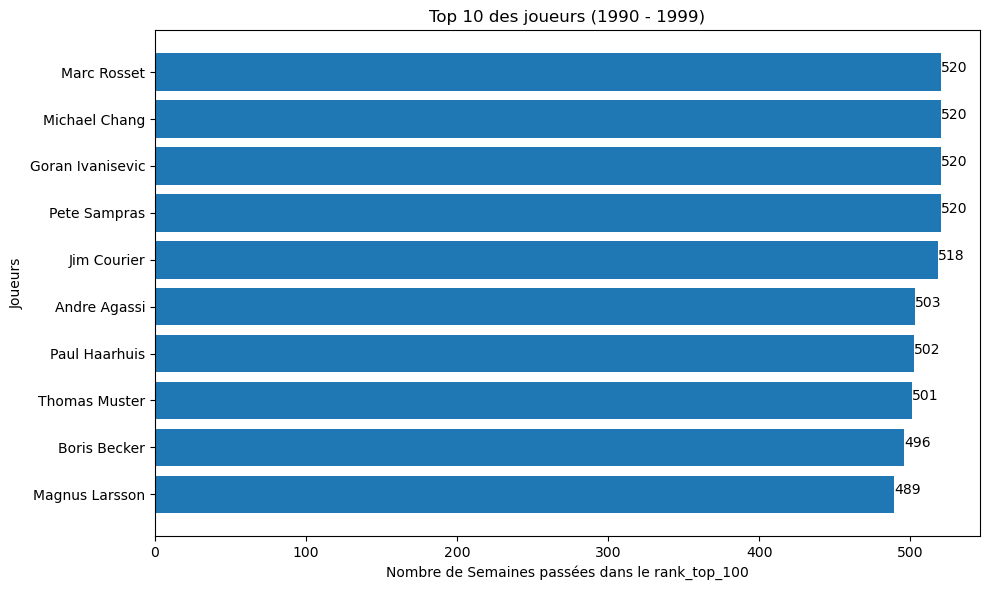

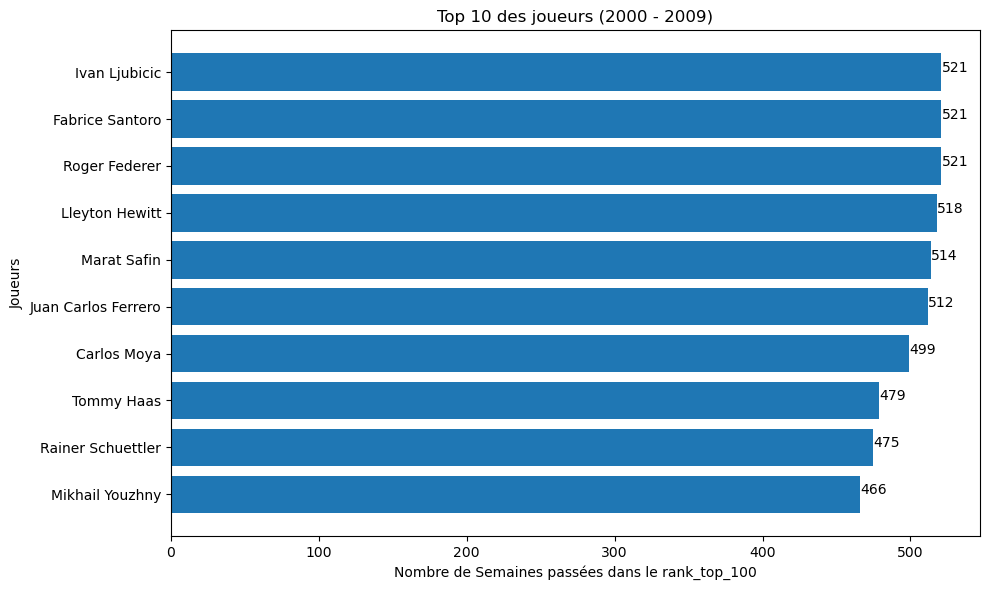

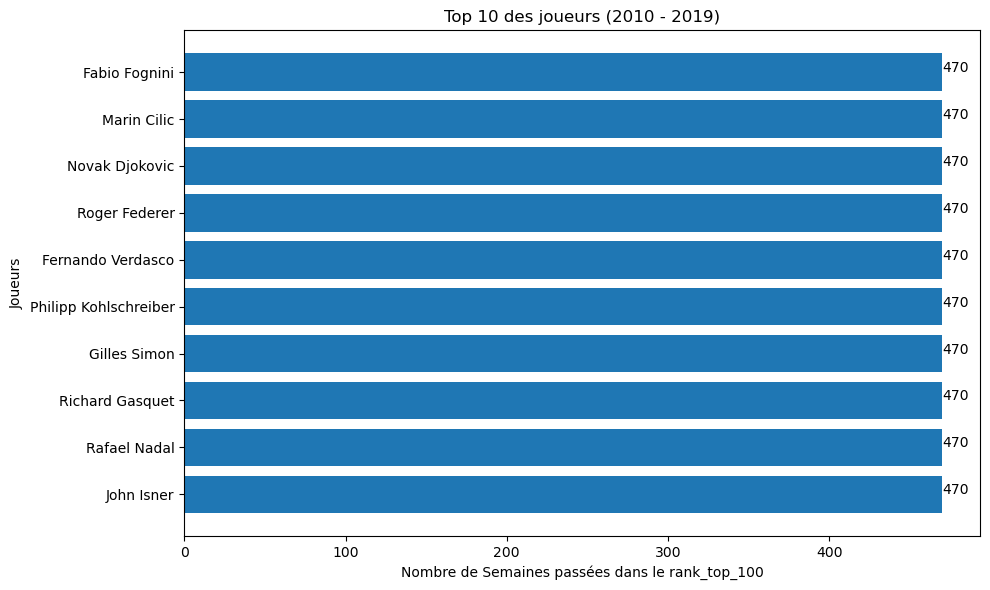

In [98]:
# Appel de fonction pour traiter et récupérer le top 100 par époque
top_rank_100_per_epoque = get_top_10_per_epoque (analyse_10_per_epoque, "rank_top_100")

# Appel de fonction pour visualiser les données par époque pour le top en question
df_rank_top_100_per_epoque = nb_joueur_keep_top_x(top_rank_100_per_epoque, "per_epoque", "rank_top_100")

# Suppression des colonnes qui ne correspondent pas au rank traité
df_rank_top_100_per_epoque =df_rank_top_100_per_epoque.drop(columns=['rank_top_10','rank_top_1'])


### 4.3.1.3 TOP 10 : Nombre de joueurs qui sont restés le plus dans le top 10 toutes époques confondues

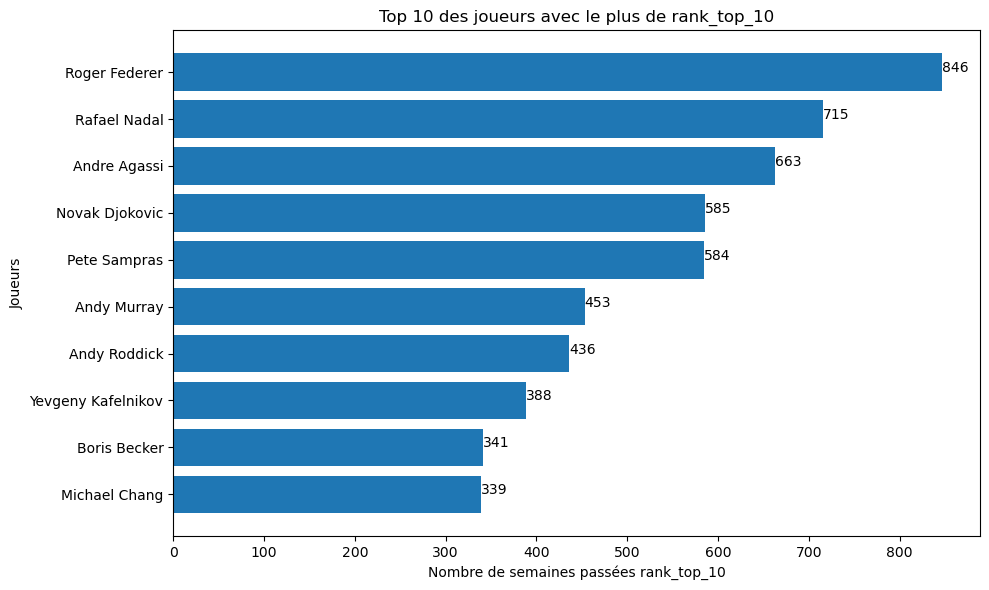

In [99]:
# Appel de fonction pour visualiser les données toutes épouqes pour le top en question
df_rank_top_10_all_epoque = nb_joueur_keep_top_x(top_10_players_top_rank_10, "all_epoque", "rank_top_10")

# Suppression des colonnes qui ne correspondent pas au rank traité
df_rank_top_10_all_epoque =df_rank_top_10_all_epoque.drop(columns=['rank_top_100','rank_top_1'])

### 4.3.1.4 TOP 10 : Nombre de joueurs qui sont restés le plus dans le top 10 par époque

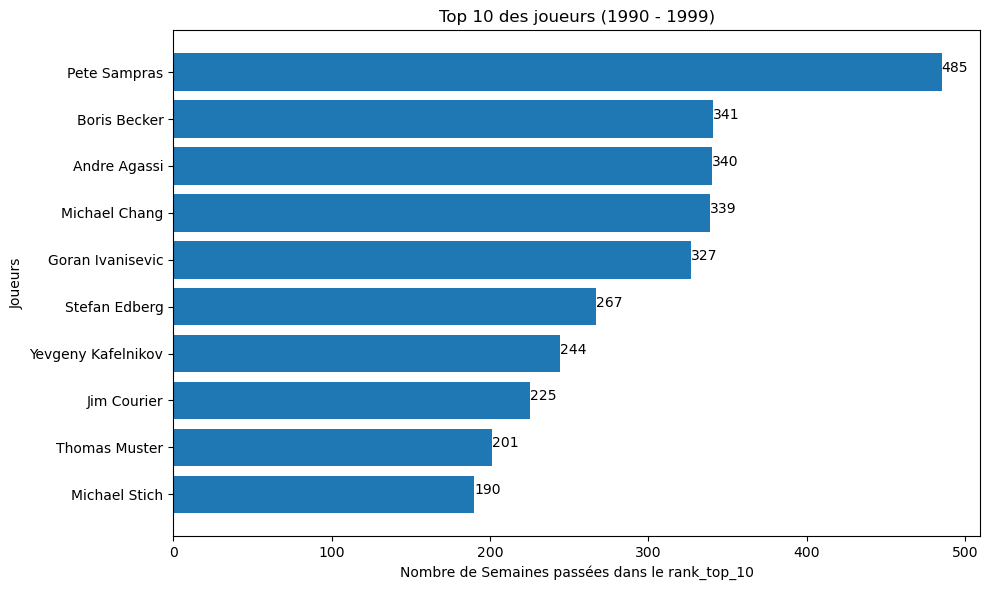

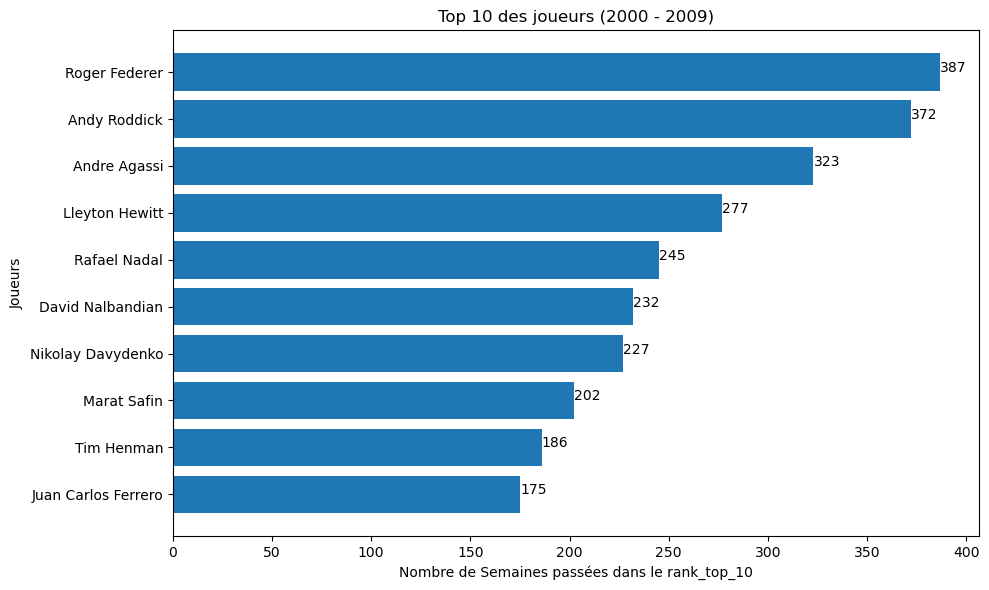

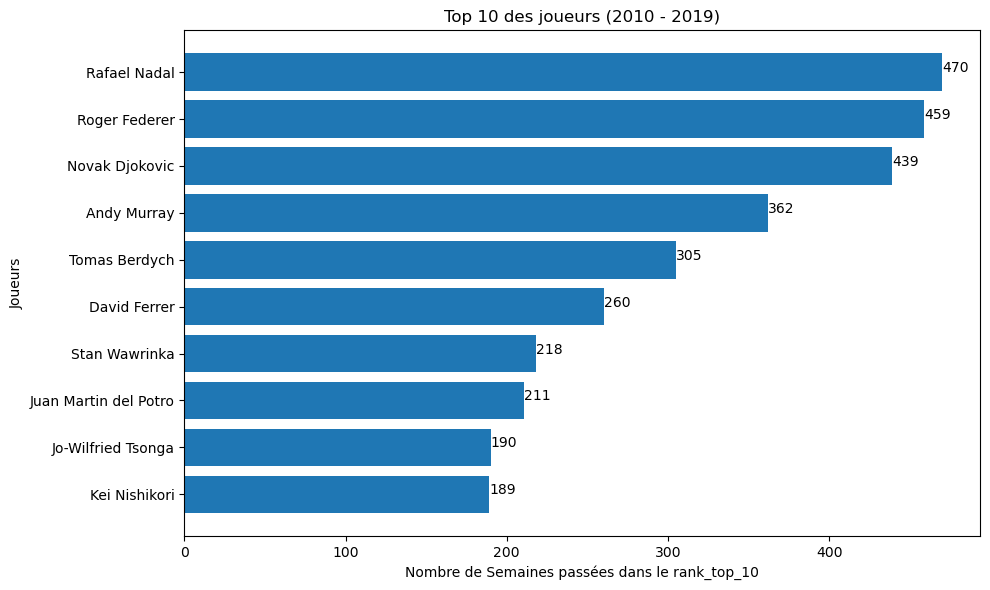

In [100]:
# Appel de fonction pour traiter et récupérer le top 10 par époque
top_rank_10_per_epoque = get_top_10_per_epoque (analyse_10_per_epoque, "rank_top_10")

# Appel de fonction pour visualiser les données par époque pour le top en question
df_rank_top_10_per_epoque = nb_joueur_keep_top_x(top_rank_10_per_epoque, "per_epoque", "rank_top_10")

# Suppression des colonnes qui ne correspondent pas au rank traité
df_rank_top_10_per_epoque =df_rank_top_10_per_epoque.drop(columns=['rank_top_100','rank_top_1'])

### 4.3.1.5 TOP 10 : Nombre de joueurs qui sont restés le plus dans le top 1 toutes époques confondues

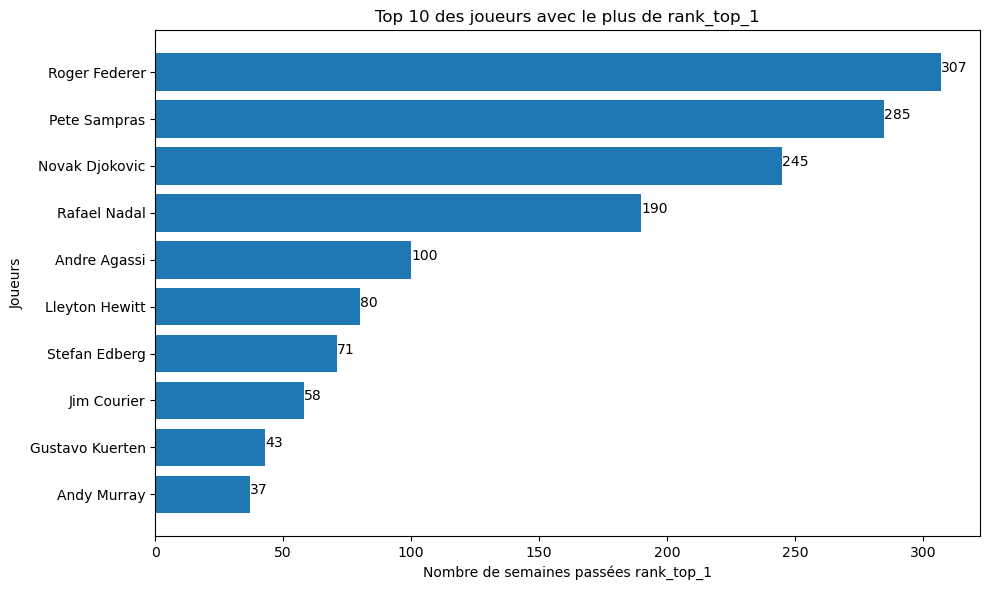

In [101]:
# Appel de fonction pour visualiser les données toutes épouqes pour le top en question
df_rank_top_1_all_epoque =nb_joueur_keep_top_x(top_10_players_top_rank_1, "all_epoque", "rank_top_1")

# Suppression des colonnes qui ne correspondent pas au rank traité
df_rank_top_1_all_epoque =df_rank_top_1_all_epoque.drop(columns=['rank_top_100','rank_top_10'])

### 4.3.1.6 TOP 10 : Nombre de joueurs qui sont restés le plus dans le top 1 par époque

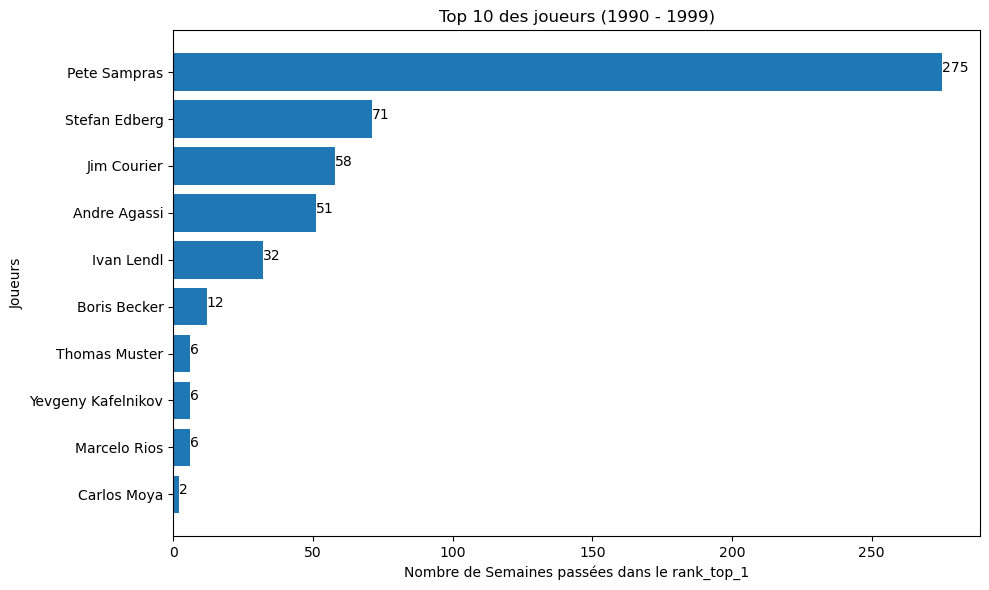

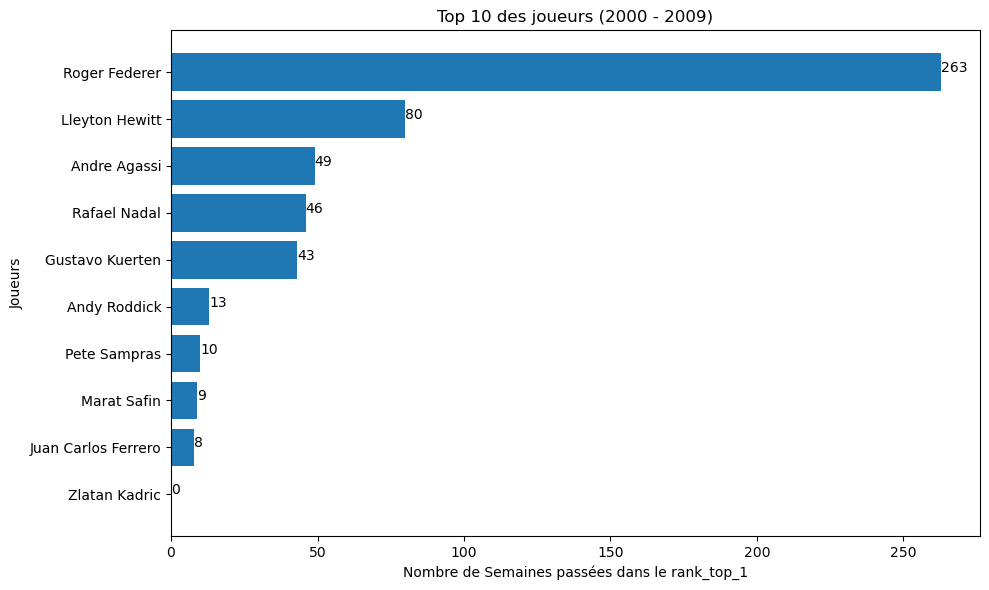

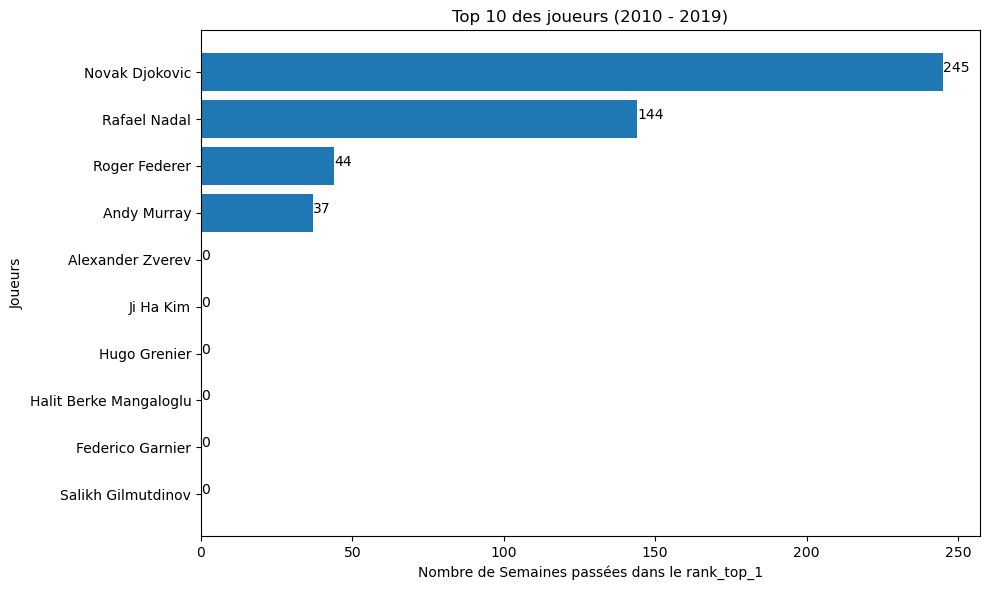

In [102]:
# Appel de fonction pour traiter et récupérer le top 1 par époque
top_rank_1_per_epoque = get_top_10_per_epoque (analyse_10_per_epoque, "rank_top_1")

# Appel de fonction pour visualiser les données par époque pour le top en question
df_rank_top_1_per_epoque = nb_joueur_keep_top_x(top_rank_1_per_epoque, "per_epoque", "rank_top_1")

# Suppression des colonnes qui ne correspondent pas au rank traité
df_rank_top_1_per_epoque =df_rank_top_1_per_epoque.drop(columns=['rank_top_100','rank_top_10'])

In [103]:
# Concaténation pour les donénes top joueurs selon les classements pour toutes les époques - utile pour tableau public
    # Rassemblement des données en un et même dataframe


    
df_rank_top_all_all_epoque = pd.concat([df_rank_top_1_all_epoque, df_rank_top_10_all_epoque,df_rank_top_100_all_epoque], axis=0)
df_rank_top_all_all_epoque = df_rank_top_all_all_epoque.reset_index()
df_rank_top_all_all_epoque =df_rank_top_all_all_epoque.drop(columns=['index'])


# Intégration du nom de l'analyse
df_rank_top_all_all_epoque["nom_analyse"] = "3.1.top10_stay_plus_longtemps_per_classement_all_epoque" 

# Modification du naming contenant les valeurs de la proportion
df_rank_top_all_all_epoque = df_rank_top_all_all_epoque.rename(columns={"nb_semaine_rank_x": "valeurs"})

# Suppression de la colonne inutile 
df_rank_top_all_all_epoque =df_rank_top_all_all_epoque.drop(columns=['player', 'name_first', 'name_last', 'ioc'])

#print(df_rank_top_all_all_epoque)


# Export des données pour tableau public
#df_rank_top_all_all_epoque.to_excel(f"3.1.top10_stay_plus_longtemps_per_classement_all_epoque.xlsx",  sheet_name='Sheet_name_1') 
      

In [104]:
# Concaténation pour les donénes top joueurs selon les classements pour chaque époque - utile pour tableau public
    # Rassemblement des données en un et même dataframe
    
df_rank_top_all_per_epoque = pd.concat([df_rank_top_1_per_epoque, df_rank_top_10_per_epoque,df_rank_top_100_per_epoque], axis=0)
df_rank_top_all_per_epoque = df_rank_top_all_per_epoque.reset_index()
df_rank_top_all_per_epoque =df_rank_top_all_per_epoque.drop(columns=['index'])

# Intégration du nom de l'analyse
df_rank_top_all_per_epoque["nom_analyse"] = "3.1.top10_stay_plus_longtemps_per_classement_all_epoque" 

# Modification du naming contenant les valeurs de la proportion
df_rank_top_all_per_epoque = df_rank_top_all_per_epoque.rename(columns={"nb_semaine_rank_x": "valeurs"})

# Concaténation des noms pour que ça devienne un champ
df_rank_top_all_per_epoque["player_name"] = df_rank_top_all_per_epoque["name_first"] + " " + df_rank_top_all_per_epoque["name_last"]

# Suppression de la colonne inutile 
df_rank_top_all_per_epoque =df_rank_top_all_per_epoque.drop(columns=['player', 'name_first', 'name_last', 'ioc'])



#print(df_rank_top_all_per_epoque)


# Export des données pour tableau public
#df_rank_top_all_per_epoque.to_excel(f"3.1.top10_stay_plus_longtemps_per_classement_per_epoque.xlsx",  sheet_name='Sheet_name_1') 
      

In [105]:
# Concaténation des deux jeux de données, pour pouvoir ensuite les exporter et les traiter sur tableau
df_rank_top_all_per_epoque_all_epoque = pd.concat([df_rank_top_all_all_epoque, df_rank_top_all_per_epoque], axis=0)


# Indication "no_data" sur les valeurs NULL
df_rank_top_all_per_epoque_all_epoque = df_rank_top_all_per_epoque_all_epoque.fillna("no_data")

#print(df_rank_top_all_per_epoque_all_epoque)

### 4.3.2.1 TOP 10 : Joueurs qui ont mis le moins de temps à atteindre le top 100, toutes époques confondues

In [106]:
# Traitements pour tous les top 10 des joueurs qui ont mis le moins de temps à atteindre tel ou tel classement, nombre de semaone pour atteindre tel ou Tel classement

analyse_11 = analyse_all_rank_epoque

def traitement_premiere_apparition_atp_premiere_apparition_rank_x (dataframe,type_analyse_epoque, nom_colonne_rank_a_traiter):

    ## Traitements communs pour les deux traitements spécifiques qui vont suivres pour toutes époques et époque par époque

    # 1. Filtrer sur les joueurs qui ont au moins atteint le top x une fois, acquisition de la liste unique des player id
    analyse_11_rank_x_reach_at_least_one_each = dataframe[dataframe[nom_colonne_rank_a_traiter] > 0]

    analyse_11_rank_x_reach_at_least_one_each = analyse_11_rank_x_reach_at_least_one_each["player"].unique()

    # 2. Récupération seulement des player_id qui ont déjà été une fois dans le top ciblé, en reprenant les données références
    analyse_11_rank_x = dataframe[dataframe['player'].isin(analyse_11_rank_x_reach_at_least_one_each)]

    # 3. Suppression de tous les joueurs nés avant 1975, pour éviter les joueurs trentenaire ou avec vingt ans qui sont déjà dans le top 100 dès les années 90 -> Ce qui fausserait les résultats
        # Convertir la colonne 'dob' en type datetime
    analyse_11_rank_x['dob'] = pd.to_datetime(analyse_11_rank_x['dob'])
        # Extraire l'année de naissance
    analyse_11_rank_x['year_of_birth'] = analyse_11_rank_x['dob'].dt.year
        # Filtrer les entrées avec une année de naissance supérieure ou égale à 1975
    analyse_11_rank_x = analyse_11_rank_x[analyse_11_rank_x['year_of_birth'] >= 1973]

    # Traitement pour obtenir les données toutes époques confondues
    if (type_analyse_epoque == "all_epoque"):
        
        # 4. Garder dans une table seulement les identifiant player présent au moins une fois dans le top x, la date de premiere apparition 
        first_appearance_all = analyse_11_rank_x[analyse_11_rank_x[nom_colonne_rank_a_traiter] == 0].groupby('player')[['ranking_date_date', 'name_first', 'name_last']].min()

        # 5. Garder dans une table seulement les identifiant player présent au moins une fois dans le top x, la date de premiere apparition dans le top x ciblé
        first_appearance_rank_top_x = analyse_11_rank_x[analyse_11_rank_x[nom_colonne_rank_a_traiter] > 0].groupby('player')['ranking_date_date'].min()

        # 6. Calculez la différence entre les dates en jours
        time_to_reach_rank_top_x_days = (first_appearance_rank_top_x - first_appearance_all['ranking_date_date']).dt.days

        # 7. Convertissez la différence en semaines en divisant les jours par 7
        time_to_reach_rank_top_x_weeks = time_to_reach_rank_top_x_days / 7

        # 8. Ajoutez les noms des joueurs
        top_players_fastest_ranking_weeks_with_names = time_to_reach_rank_top_x_weeks.reset_index().merge(first_appearance_all, on='player')
        top_players_fastest_ranking_weeks_with_names = top_players_fastest_ranking_weeks_with_names.rename(columns={"ranking_date_date_x": nom_colonne_rank_a_traiter})

        # 9. Suppression des valeurs négatives dans le champ "ecart_semaine_top_x" car impossible
        top_players_fastest_ranking_weeks_with_names = top_players_fastest_ranking_weeks_with_names[top_players_fastest_ranking_weeks_with_names[nom_colonne_rank_a_traiter] > 0]

        # 10. Triez les joueurs qui ont eu le besoin de moins de semaines pour atteindre le top 100 depuis leur premiere apparition
        top_players_fastest_ranking_weeks = top_players_fastest_ranking_weeks_with_names.sort_values(by=nom_colonne_rank_a_traiter, ascending=True).head(10)

        return (top_players_fastest_ranking_weeks)

    # Traitement pour obtenir les données par époque
    elif (type_analyse_epoque == "per_epoque"):
        
        epoques = dataframe["epoque"].unique()

        top_10_players_df_per_epoque = pd.DataFrame()

        for epoque in epoques:
            
            #print(epoque)
            
            # Si epoque c'est 2000 à 2009, on exclut tous les joueurs nés avant 1983, donc 17 max en 2000, pour garder les petits jeunots qui arrivent
            if (epoque == "2000 - 2009"):
                
                # Suppression de tous les joueurs nés avant 1983, pour éviter les joueurs trentenaire ou avec vingt ans qui sont déjà dans le top 100 dès les années 2000 -> Ce qui fausserait les résultats
                    # Convertir la colonne 'dob' en type datetime
                analyse_11_rank_x['dob'] = pd.to_datetime(analyse_11_rank_x['dob'])
                    # Extraire l'année de naissance
                analyse_11_rank_x['year_of_birth'] = analyse_11_rank_x['dob'].dt.year
                    # Filtrer les entrées avec une année de naissance supérieure ou égale à 1983
                analyse_11_rank_x = analyse_11_rank_x[analyse_11_rank_x['year_of_birth'] >= 1983]
                
            # Si epoque c'est 2010 à 2019, on exclut tous les joueurs nés avant 1993, donc 17 max en 2010, pour garder les petits jeunots qui arrivent
            elif (epoque == "2010 - 2019"):
                
                # Suppression de tous les joueurs nés avant 1993, pour éviter les joueurs trentenaire ou avec vingt ans qui sont déjà dans le top 100 dès les années 2010 -> Ce qui fausserait les résultats
                    # Convertir la colonne 'dob' en type datetime
                analyse_11_rank_x['dob'] = pd.to_datetime(analyse_11_rank_x['dob'])
                    # Extraire l'année de naissance
                analyse_11_rank_x['year_of_birth'] = analyse_11_rank_x['dob'].dt.year
                    # Filtrer les entrées avec une année de naissance supérieure ou égale à 1993
                analyse_11_rank_x = analyse_11_rank_x[analyse_11_rank_x['year_of_birth'] >= 1993]
            
            # 3. bis, on récupère les données de l'époque seulement que l'on itère
            analyse_11_rank_x_epoque = analyse_11_rank_x[analyse_11_rank_x["epoque"] == epoque]

            # 4. Garder dans une table seulement les identifiant player présent au moins une fois dans le top x, la date de premiere apparition 
            first_appearance_all = analyse_11_rank_x_epoque[analyse_11_rank_x_epoque[nom_colonne_rank_a_traiter] == 0].groupby('player')[['ranking_date_date', 'name_first', 'name_last', 'epoque']].min()

            # 5. Garder dans une table seulement les identifiant player présent au moins une fois dans le top x, la date de premiere apparition dans le top x ciblé
            first_appearance_rank_top_x = analyse_11_rank_x_epoque[analyse_11_rank_x_epoque[nom_colonne_rank_a_traiter] > 0].groupby('player')['ranking_date_date'].min()

            # 6. Calculez la différence entre les dates en jours
            time_to_reach_rank_top_x_days = (first_appearance_rank_top_x - first_appearance_all['ranking_date_date']).dt.days

            # 7. Convertissez la différence en semaines en divisant les jours par 7
            time_to_reach_rank_top_x_weeks = time_to_reach_rank_top_x_days / 7

            # 8. Ajoutez les noms des joueurs
            top_players_fastest_ranking_weeks_with_names = time_to_reach_rank_top_x_weeks.reset_index().merge(first_appearance_all, on='player')
            top_players_fastest_ranking_weeks_with_names = top_players_fastest_ranking_weeks_with_names.rename(columns={"ranking_date_date_x": nom_colonne_rank_a_traiter})

            # 9. Suppression des valeurs négatives dans le champ "ecart_semaine_top_x" car impossible
            top_players_fastest_ranking_weeks_with_names = top_players_fastest_ranking_weeks_with_names[top_players_fastest_ranking_weeks_with_names[nom_colonne_rank_a_traiter] > 0]

            # 10. Triez les joueurs qui ont eu le besoin de moins de semaines pour atteindre le top 100 depuis leur premiere apparition
            top_players_fastest_ranking_weeks = top_players_fastest_ranking_weeks_with_names.sort_values(by=nom_colonne_rank_a_traiter, ascending=True).head(10)
            
            #print(top_players_fastest_ranking_weeks)
            
            # Concaténation pour ajouter tous les top 10 des 3 époques
            top_10_players_df_per_epoque = pd.concat([top_10_players_df_per_epoque, top_players_fastest_ranking_weeks])

            
        return(top_10_players_df_per_epoque)

In [107]:
# Visualisation du nombre de temps mis pour atteindre un rank
    # Utilisation d'une fonction pour éviter la redondance
def nb_joueur_reach_top_x(dataframe, type_analyse_epoque, column_analyse_rank):

    # A. Visualisation toutes époques
    if(type_analyse_epoque == "all_epoque"):

        # Concaténer les colonnes "name_first" et "name_last" pour obtenir le nom complet
        dataframe['player_name'] = dataframe['name_first'] + ' ' + dataframe['name_last']

        # Trier les données par "rank_top_x" en ordre décroissant
        dataframe = dataframe.sort_values(by=column_analyse_rank, ascending=True)

        # Créer le graphique à barres
        plt.figure(figsize=(10, 6))
        plt.barh(dataframe['player_name'], dataframe[column_analyse_rank])
        plt.xlabel('Nombre de semaines utilisées pour atteindre le '+column_analyse_rank)
        plt.ylabel('Joueurs')
        plt.title('Top 10 des joueurs qui ont mis le moins de temps pour atteindre le '+column_analyse_rank)
        plt.gca().invert_yaxis()  # Inverser l'axe y pour afficher le joueur avec le plus de rank_top_100 en haut
        plt.tight_layout()

        # Ajouter des étiquettes de valeurs à chaque barre
        for index, value in enumerate(dataframe[column_analyse_rank]):
            plt.text(value, index, str(value))

        plt.tight_layout()
        
        # Afficher le graphique
        plt.show()
        
        # Ajout d'une colonne qui précise le rank_top_ciblé pour les joueurs
        dataframe["rank_analyse"] = column_analyse_rank    
    
        return(dataframe)
    
    # Visualisation par époque
    elif(type_analyse_epoque == "per_epoque"):
        
        # Divisez les données par époque
        epoques = dataframe['epoque'].unique()
        top_10_players = {}

        for epoque in epoques:
            top_10_players[epoque] = dataframe[dataframe['epoque'] == epoque].sort_values(by=column_analyse_rank, ascending=True).head(10)

        # Création d'une liste qui va rassembler les donénes de toutes les époques - utile pour tableau public
        dfs = []
            
        # Créez les graphiques à barres pour chaque époque
        for epoque, top_players in top_10_players.items():
            plt.figure(figsize=(10, 6))


            plt.barh(top_players['name_first'] + ' ' + top_players['name_last'], top_players[column_analyse_rank])
            plt.xlabel('Nombre de semaines utilisées pour atteindre le '+ column_analyse_rank)
            plt.ylabel('Joueurs')
            plt.title(f'Top 10 des joueurs ({epoque})')
            plt.gca().invert_yaxis()  # Inverser l'axe y pour afficher le joueur avec le plus de rank_top_100 en haut
            
            
                        # Ajouter des étiquettes de valeurs à chaque barre
            for index, value in enumerate(top_players[column_analyse_rank]):
                plt.text(value, index, str(value))
            
            plt.tight_layout()
            plt.show()
            
            # Ajout d'une colonne qui précise le rank_top_ciblé pour les joueurs
            top_players["rank_analyse"] = column_analyse_rank
        
            # Ajouter le DataFrame à la liste - utile pour tableau public
            dfs.append(top_players)
    
        # Concaténer les DataFrames de chaque époque en un seul DataFrame - utile pour tableau public
        result_df = pd.concat(dfs, ignore_index=True)
        
        #print(result_df)
        return(result_df)
        

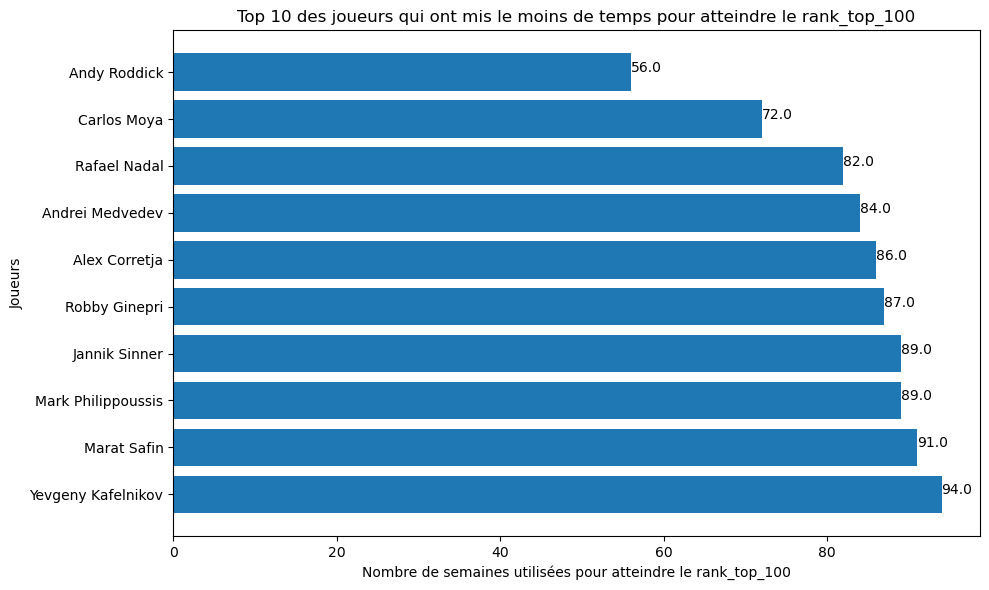

In [108]:
# Appel de fonction pour traiter et récupérer le top 100 par époque
top_reach_rank_100_all_epoque = traitement_premiere_apparition_atp_premiere_apparition_rank_x (analyse_11,"all_epoque", "rank_top_100")

# Appel de fonction pour visualiser les données par époque pour le top en question
df_rank_top_reach_rank_100_all_epoque = nb_joueur_reach_top_x(top_reach_rank_100_all_epoque, "all_epoque", "rank_top_100")

# Suppression des colonnes qui ne correspondent pas au rank traité
#df_rank_top_reach_rank_100_all_epoque =df_rank_top_reach_rank_100_all_epoque.drop(columns=['rank_top_10','rank_top_1'])

# Rename de la colonne rank_top_x pour qu'elle soit commune aux autres dataframe qui vont suivre, pour mener une concaténation
df_rank_top_reach_rank_100_all_epoque = df_rank_top_reach_rank_100_all_epoque.rename(columns={'rank_top_100': 'nb_semaine'})

#print(df_rank_top_reach_rank_100_all_epoque)


### 4.3.2.2 TOP 10 : Joueurs qui ont mis le moins de temps à atteindre le top 100, Par époque

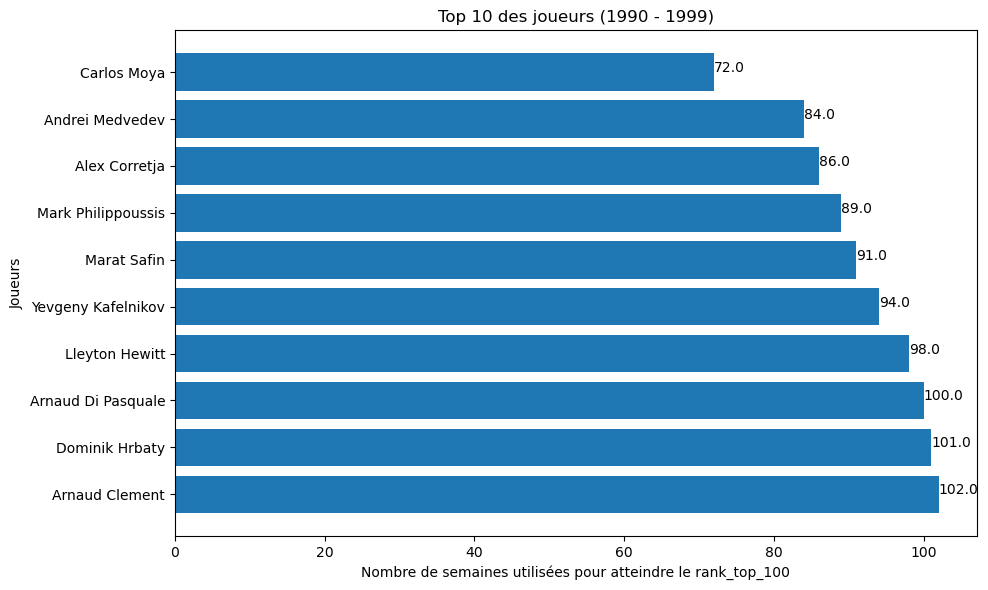

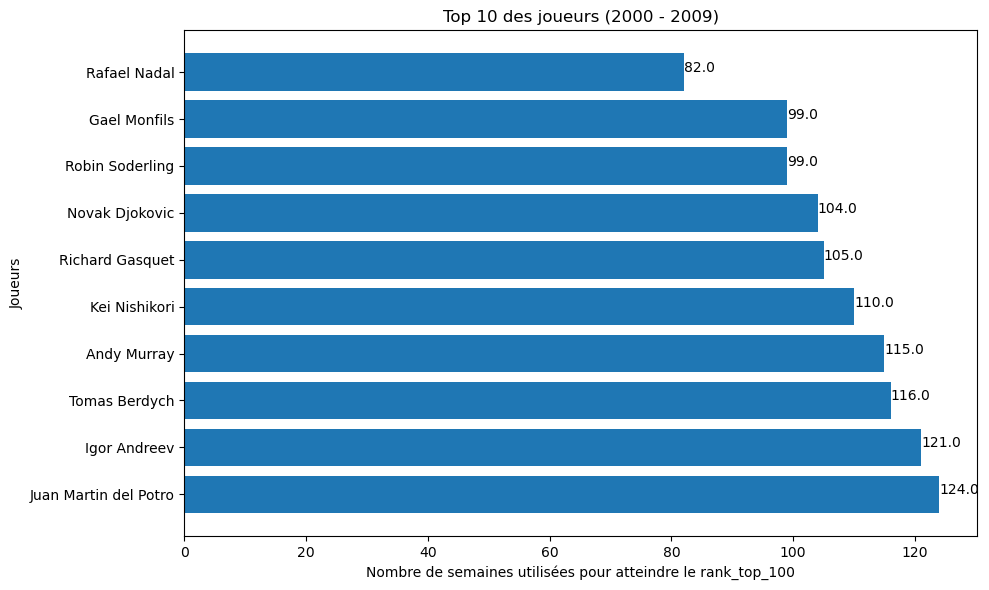

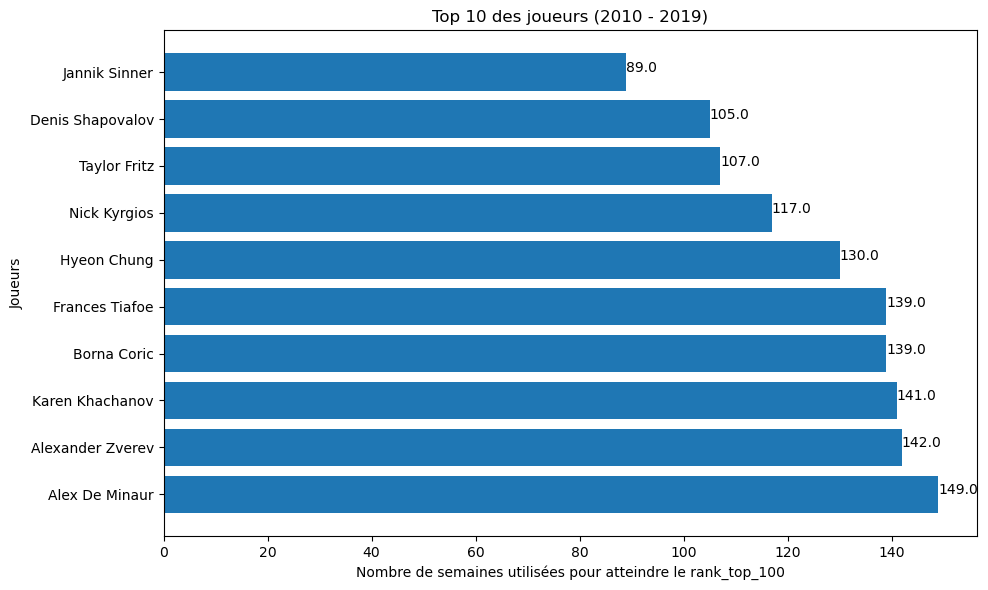

In [109]:
# Appel de fonction pour traiter et récupérer le top 1 par époque
top_reach_rank_100_per_epoque = traitement_premiere_apparition_atp_premiere_apparition_rank_x (analyse_11,"per_epoque", "rank_top_100")

# Appel de fonction pour visualiser les données par époque pour le top en question
df_rank_top_reach_rank_100_per_epoque = nb_joueur_reach_top_x(top_reach_rank_100_per_epoque, "per_epoque", "rank_top_100")

# Rename de la colonne rank_top_x pour qu'elle soit commune aux autres dataframe qui vont suivre, pour mener une concaténation
df_rank_top_reach_rank_100_per_epoque = df_rank_top_reach_rank_100_per_epoque.rename(columns={'rank_top_100': 'nb_semaine'})

#print(df_rank_top_reach_rank_100_per_epoque)

### 4.3.2.3 TOP 10 : Joueurs qui ont mis le moins de temps à atteindre le top 10, toutes époques confondues

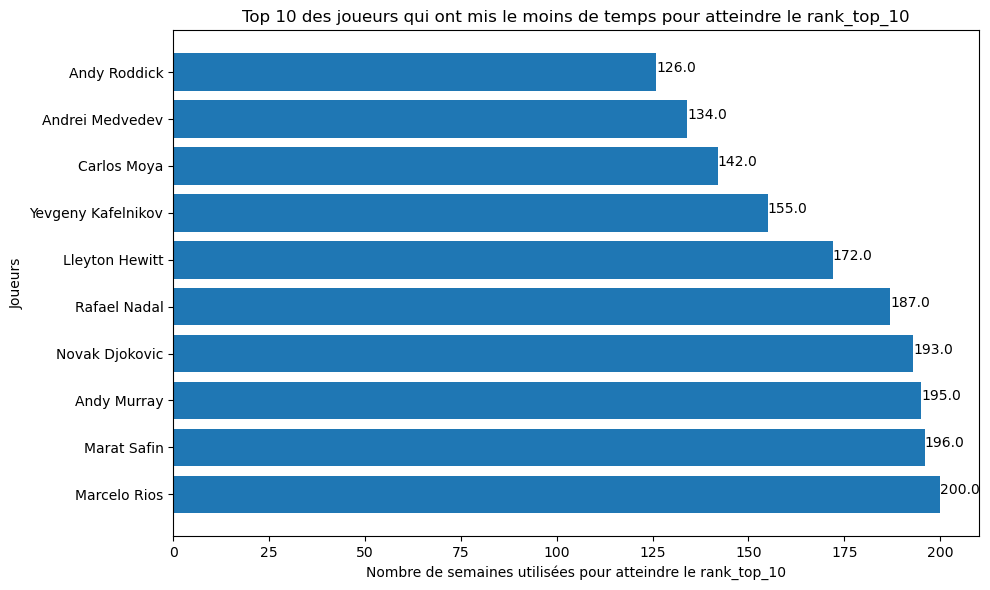

In [110]:
# Appel de fonction pour traiter et récupérer le top 10 par époque
top_reach_rank_10_all_epoque = traitement_premiere_apparition_atp_premiere_apparition_rank_x (analyse_11,"all_epoque", "rank_top_10")

# Appel de fonction pour visualiser les données par époque pour le top en question
df_rank_top_reach_rank_10_all_epoque = nb_joueur_reach_top_x(top_reach_rank_10_all_epoque, "all_epoque", "rank_top_10")

# Rename de la colonne rank_top_x pour qu'elle soit commune aux autres dataframe qui vont suivre, pour mener une concaténation
df_rank_top_reach_rank_10_all_epoque = df_rank_top_reach_rank_10_all_epoque.rename(columns={'rank_top_10': 'nb_semaine'})

#print(df_rank_top_reach_rank_10_all_epoque)


### 4.3.2.4 TOP 10 : Joueurs qui ont mis le moins de temps à atteindre le top 10, Par époque

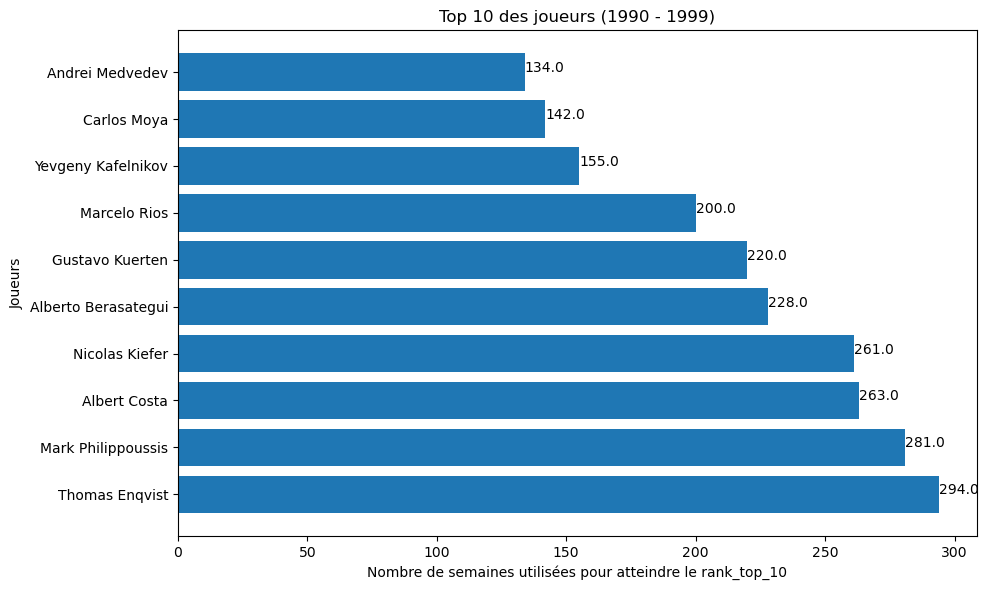

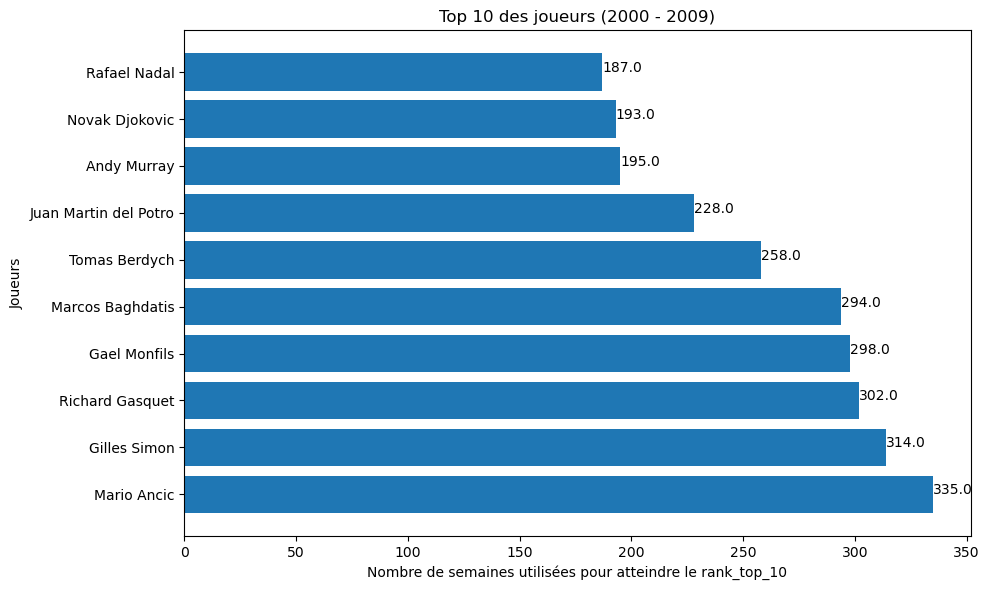

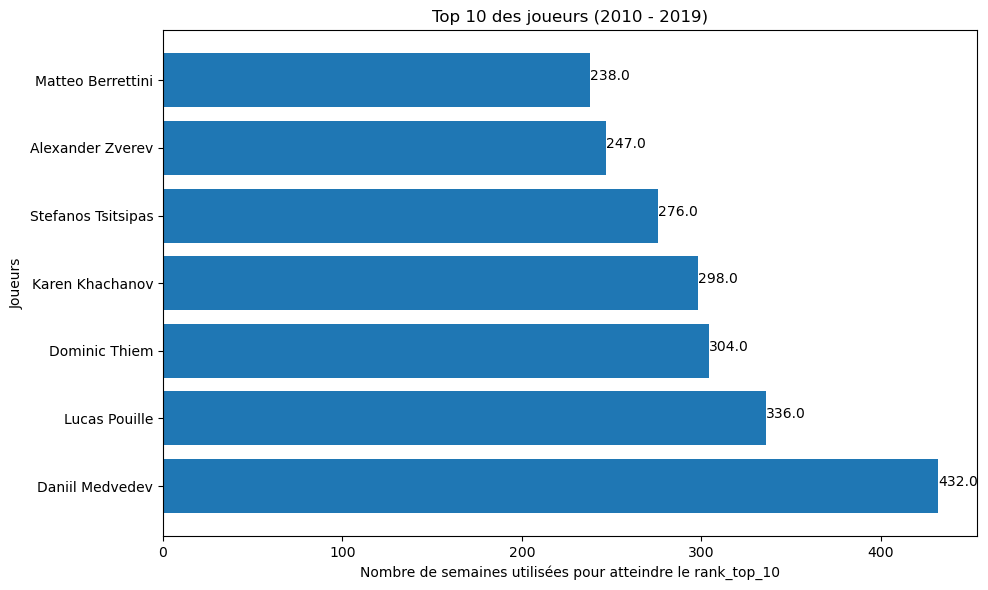

In [111]:
# Appel de fonction pour traiter et récupérer le top 10 par époque
top_reach_rank_10_per_epoque = traitement_premiere_apparition_atp_premiere_apparition_rank_x (analyse_11,"per_epoque", "rank_top_10")

# Appel de fonction pour visualiser les données par époque pour le top en question
df_rank_top_reach_rank_10_per_epoque = nb_joueur_reach_top_x(top_reach_rank_10_per_epoque, "per_epoque", "rank_top_10")

# Rename de la colonne rank_top_x pour qu'elle soit commune aux autres dataframe qui vont suivre, pour mener une concaténation
df_rank_top_reach_rank_10_per_epoque = df_rank_top_reach_rank_10_per_epoque.rename(columns={'rank_top_10': 'nb_semaine'})

#print(df_rank_top_reach_rank_10_per_epoque)

### 4.3.2.5 TOP 10 : Joueurs qui ont mis le moins de temps à atteindre le top 1, toutes époques confondues

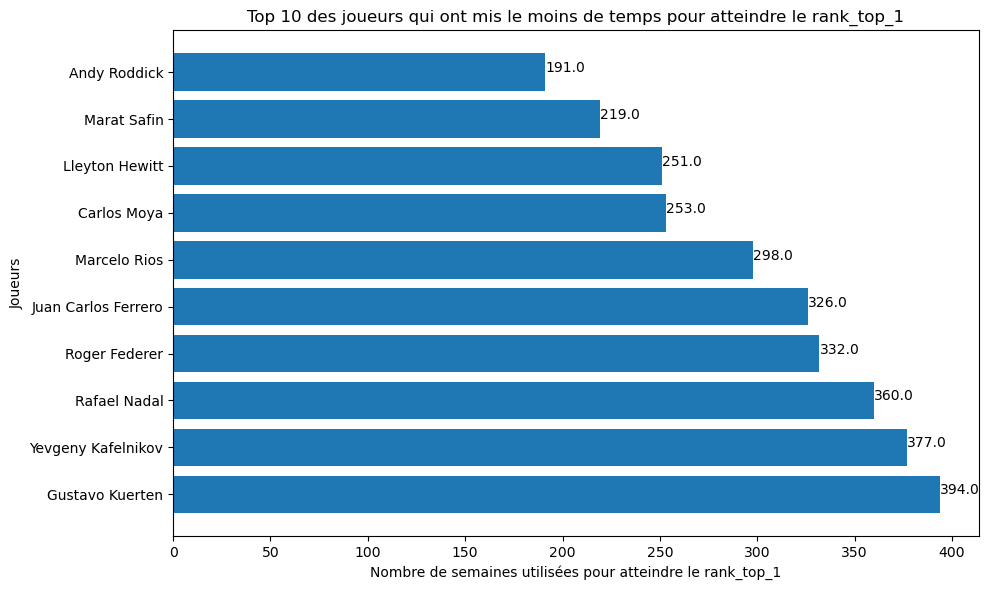

In [112]:
# Appel de fonction pour traiter et récupérer le top 1 par époque
top_reach_rank_1_all_epoque = traitement_premiere_apparition_atp_premiere_apparition_rank_x (analyse_11,"all_epoque", "rank_top_1")

# Appel de fonction pour visualiser les données par époque pour le top en question
df_rank_top_reach_rank_1_all_epoque = nb_joueur_reach_top_x(top_reach_rank_1_all_epoque, "all_epoque", "rank_top_1")

# Rename de la colonne rank_top_x pour qu'elle soit commune aux autres dataframe qui vont suivre, pour mener une concaténation
df_rank_top_reach_rank_1_all_epoque = df_rank_top_reach_rank_1_all_epoque.rename(columns={'rank_top_1': 'nb_semaine'})

#print(df_rank_top_reach_rank_1_all_epoque)

### 4.3.2.6 TOP 10 : Joueurs qui ont mis le moins de temps à atteindre le top 1, Par époque

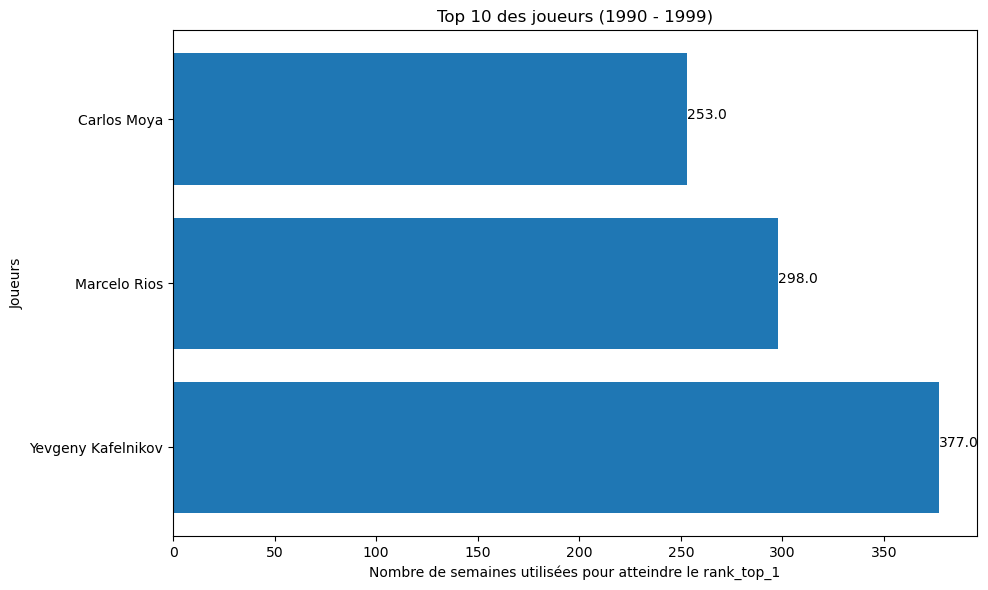

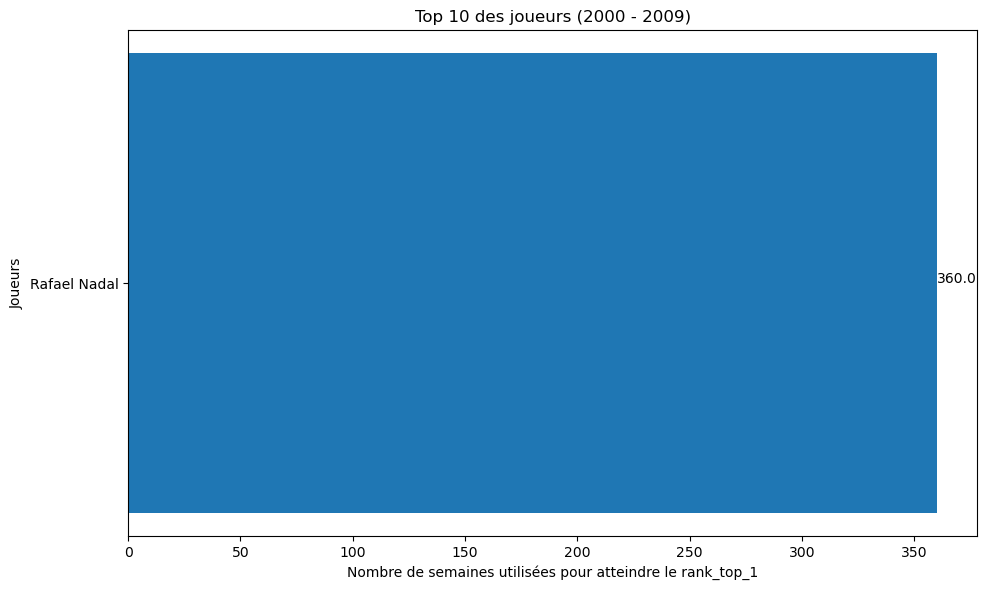

In [113]:
# Appel de fonction pour traiter et récupérer le top 1 par époque
top_reach_rank_1_per_epoque = traitement_premiere_apparition_atp_premiere_apparition_rank_x (analyse_11,"per_epoque", "rank_top_1")

# Appel de fonction pour visualiser les données par époque pour le top en question
df_rank_top_reach_rank_1_per_epoque = nb_joueur_reach_top_x(top_reach_rank_1_per_epoque, "per_epoque", "rank_top_1")

# Rename de la colonne rank_top_x pour qu'elle soit commune aux autres dataframe qui vont suivre, pour mener une concaténation
df_rank_top_reach_rank_1_per_epoque = df_rank_top_reach_rank_1_per_epoque.rename(columns={'rank_top_1': 'nb_semaine'})

#print(df_rank_top_reach_rank_1_per_epoque)

In [114]:
# Concaténation pour les donénes top joueurs selon les classements pour toutes les époques - utile pour tableau public
    # Rassemblement des données en un et même dataframe


    
df_rank_arrive_le_plus_rapidement_top_all_all_epoque = pd.concat([df_rank_top_reach_rank_1_all_epoque, df_rank_top_reach_rank_10_all_epoque,df_rank_top_reach_rank_100_all_epoque], axis=0)
df_rank_arrive_le_plus_rapidement_top_all_all_epoque = df_rank_arrive_le_plus_rapidement_top_all_all_epoque.reset_index()
df_rank_arrive_le_plus_rapidement_top_all_all_epoque =df_rank_arrive_le_plus_rapidement_top_all_all_epoque.drop(columns=['index'])

# Intégration du nom de l'analyse
df_rank_arrive_le_plus_rapidement_top_all_all_epoque["nom_analyse"] = "3.2.top10_arrive_plus_rapidement_per_classement_all_epoque" 

# Modification du naming contenant les valeurs de la proportion
df_rank_arrive_le_plus_rapidement_top_all_all_epoque = df_rank_arrive_le_plus_rapidement_top_all_all_epoque.rename(columns={"nb_semaine": "valeurs"})

# Suppression de la colonne inutile 
df_rank_arrive_le_plus_rapidement_top_all_all_epoque =df_rank_arrive_le_plus_rapidement_top_all_all_epoque.drop(columns=['player','ranking_date_date_y', 'name_first', 'name_last'])


#print(df_rank_arrive_le_plus_rapidement_top_all_all_epoque)


# Export des données pour tableau public
#df_rank_arrive_le_plus_rapidement_top_all_all_epoque.to_excel(f"3.2.top10_arrive_plus_rapidement_per_classement_all_epoque.xlsx",  sheet_name='Sheet_name_1') 
      

In [115]:
# Concaténation pour les donénes top joueurs selon les classements pour chaque époque  - utile pour tableau public
    # Rassemblement des données en un et même dataframe

df_rank_arrive_le_plus_rapidement_top_all_per_epoque = pd.concat([df_rank_top_reach_rank_1_per_epoque, df_rank_top_reach_rank_10_per_epoque,df_rank_top_reach_rank_100_per_epoque], axis=0)
df_rank_arrive_le_plus_rapidement_top_all_per_epoque = df_rank_arrive_le_plus_rapidement_top_all_per_epoque.reset_index()
df_rank_arrive_le_plus_rapidement_top_all_per_epoque =df_rank_arrive_le_plus_rapidement_top_all_per_epoque.drop(columns=['index'])


# Intégration du nom de l'analyse
df_rank_arrive_le_plus_rapidement_top_all_per_epoque["nom_analyse"] = "3.2.top10_arrive_plus_rapidement_per_classement_per_epoque.xlsx" 

# Modification du naming contenant les valeurs de la proportion
df_rank_arrive_le_plus_rapidement_top_all_per_epoque = df_rank_arrive_le_plus_rapidement_top_all_per_epoque.rename(columns={"nb_semaine": "valeurs"})

# Intégration du nom et prénom concaténé
df_rank_arrive_le_plus_rapidement_top_all_per_epoque["player_name"] = df_rank_arrive_le_plus_rapidement_top_all_per_epoque["name_first"] + " " + df_rank_arrive_le_plus_rapidement_top_all_per_epoque["name_last"]

# Suppression de la colonne inutile 
df_rank_arrive_le_plus_rapidement_top_all_per_epoque =df_rank_arrive_le_plus_rapidement_top_all_per_epoque.drop(columns=["player", "ranking_date_date_y", "name_first", "name_last"])

#print(df_rank_arrive_le_plus_rapidement_top_all_per_epoque)


# Export des données pour tableau public
#df_rank_arrive_le_plus_rapidement_top_all_per_epoque.to_excel(f"3.2.top10_arrive_plus_rapidement_per_classement_per_epoque.xlsx",  sheet_name='Sheet_name_1') 
      

In [116]:
# Concaténation des deux jeux de données, pour pouvoir ensuite les exporter et les traiter sur tableau
df_rank_arrive_le_plus_rapidement_top_all_per_epoque_all_epoque = pd.concat([df_rank_arrive_le_plus_rapidement_top_all_all_epoque, df_rank_arrive_le_plus_rapidement_top_all_per_epoque], axis=0)


# Indication "no_data" sur les valeurs NULL
df_rank_arrive_le_plus_rapidement_top_all_per_epoque_all_epoque = df_rank_arrive_le_plus_rapidement_top_all_per_epoque_all_epoque.fillna("no_data")

print(df_rank_arrive_le_plus_rapidement_top_all_per_epoque_all_epoque)

    valeurs       player_name  rank_analyse  \
0     191.0      Andy Roddick    rank_top_1   
1     219.0       Marat Safin    rank_top_1   
2     251.0    Lleyton Hewitt    rank_top_1   
3     253.0       Carlos Moya    rank_top_1   
4     298.0      Marcelo Rios    rank_top_1   
..      ...               ...           ...   
56    139.0    Frances Tiafoe  rank_top_100   
57    139.0       Borna Coric  rank_top_100   
58    141.0   Karen Khachanov  rank_top_100   
59    142.0  Alexander Zverev  rank_top_100   
60    149.0    Alex De Minaur  rank_top_100   

                                          nom_analyse       epoque  
0   3.2.top10_arrive_plus_rapidement_per_classemen...      no_data  
1   3.2.top10_arrive_plus_rapidement_per_classemen...      no_data  
2   3.2.top10_arrive_plus_rapidement_per_classemen...      no_data  
3   3.2.top10_arrive_plus_rapidement_per_classemen...      no_data  
4   3.2.top10_arrive_plus_rapidement_per_classemen...      no_data  
..                   

### 4.3.3.1. Etat de la hiérarchie lors des matchs (Taux de match gagné par ceux qui ont moins de rank), tous tournois et toutes époques confondues 

In [117]:
    # Créer un champ époque pour répartir les données entre les 3 époques analysées sur les matchs aAvec les deux joueurs sur la même ligne
analyse_all_epoque_winner_loser = atp_matches_90_to_22_sans_doublon
analyse_all_epoque_winner_loser.loc[(analyse_all_epoque_winner_loser['year_tourney'] >= 1990) & (analyse_all_epoque_winner_loser['year_tourney'] <= 1999), ['epoque']] = "1990 - 1999"
analyse_all_epoque_winner_loser.loc[(analyse_all_epoque_winner_loser['year_tourney'] >= 2000) & (analyse_all_epoque_winner_loser['year_tourney'] <= 2009), ['epoque']] = "2000 - 2009"
analyse_all_epoque_winner_loser.loc[(analyse_all_epoque_winner_loser['year_tourney'] >= 2010) & (analyse_all_epoque_winner_loser['year_tourney'] <= 2019), ['epoque']] = "2010 - 2019"

analyse_all_epoque_winner_loser = analyse_all_epoque_winner_loser[analyse_all_epoque_winner_loser["epoque"].notnull()]

In [118]:
def hierarchie_all_epoque_per_epoque(dataframe, analyse_epoque,circuit_filtre):
  
    if(analyse_epoque == "all_epoque"):

            # Comparaison rank result - 2 -> rank NULL ; 1 -> Rank winner supérieur au rank looser ; 0 -> Rank winner inférieur au rank loser
                # On garde seulement les champs que l'on souhaite traiter
        dataframe = dataframe[["id_atp_matches", "winner_rank", "loser_rank", "comparaison_rank_winner_loser"]]

            # Calcul de La proportion de données NA (2 OU NULL dans le champ comparaison_rank_winner_loser)
                # On récupère seulement toutes les données qui sont NULL ou incomplète
        proportion_NA = round((len(dataframe[(dataframe["comparaison_rank_winner_loser"].isnull()) | (dataframe["comparaison_rank_winner_loser"] == 2)]) / len(dataframe)) *100,0)

        #print(proportion_NA)

            # On Écarte les données de 2
        dataframe = dataframe[dataframe["comparaison_rank_winner_loser"] != 2]
        dataframe = dataframe[dataframe["comparaison_rank_winner_loser"].notnull()]
        
        
        # On crée des catégories pour la comparaison des ranks des winners et looser - Hierarchie respectée ; Hierarchie non respectée (-10 ranks de différences) ; Hierarchie non respectée (+10 ranks de différences)
        dataframe.loc[(dataframe['comparaison_rank_winner_loser'] == 1), ['categ_comparaison_rank_winner_loser']] = "Hiérarchie respectée"
        dataframe.loc[(dataframe['comparaison_rank_winner_loser'] == 0 )&(dataframe['loser_rank'] - dataframe['winner_rank']  <=10), ['categ_comparaison_rank_winner_loser']] = "Hiérarchie non respectée (- 10 ranks différences)"
        dataframe.loc[(dataframe['comparaison_rank_winner_loser'] == 0 )&(dataframe['loser_rank'] - dataframe['winner_rank']  > 10), ['categ_comparaison_rank_winner_loser']] = "Hiérarchie non respectée (+ 10 ranks différences)"

            # Calcul de La proportion de hiérarchie respectée ET hiérarchie non respectée
        proportion = dataframe['categ_comparaison_rank_winner_loser'].value_counts(normalize=True)

        # Visualisation des données

            # Affichage de la proportion de données NA dans le jeu de données
        print(f"Nombre de matchs avec des rankings inconnus sur un OU deux joueurs = {proportion_NA} %")

            # Affichage de la proportion des hierarchies respectées ou non

                # Créez un pie chart
        plt.figure(figsize=(6, 6))
        plt.pie(proportion, labels=proportion.index, autopct='%1.1f%%', startangle=140)
        plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
        plt.title("Proportion de hiérarchie respectée et non respectée sur toutes les époques")

                # Affichez le pie chart
        plt.show()
        
        #print(proportion)
        
        # Créer un DataFrame à partir de la série - Utile pour tableau public
        proportion = pd.DataFrame({'Type de hierarchie': proportion.index, 'proportion': proportion.values})

        # Afficher le DataFrame résultant
        #print(proportion) 
        
        # Intégration du type de circuit filtré (si tous pris en compte OU seulement un précisément) - utile pour Tableau public
        proportion["circuit_cible"] = circuit_filtre
        
        return(proportion)
    
    elif (analyse_epoque == "per_epoque"):
        
            # Comparaison rank result - 2 -> rank NULL ; 1 -> Rank winner supérieur au rank looser ; 0 -> Rank winner inférieur au rank loser
                # On garde seulement les champs que l'on souhaite traiter
        dataframe = dataframe[["id_atp_matches", "winner_rank", "loser_rank", "comparaison_rank_winner_loser", "epoque"]]

        epoque_unique_na = dataframe["epoque"].unique()
        #print(epoque_unique_na)
        
        # Création d'un dataframe pour stocker les proportions de NA par époque
        df_proportion_na_per_epoque = pd.DataFrame(columns=['epoque', 'proportion_na'])

        # Boucle pour obtenir la proportion par époque 
        for epoque in epoque_unique_na:

            # Récupération des données de l'époque pour l'analyse
            analyse_12_2_per_epoque = dataframe[dataframe["epoque"] == epoque]
            
            #print(epoque)
            
            # Récupération de longueur totale des données sur l'époque pour calculer la proportion
            len_total = len(analyse_12_2_per_epoque)
            
            #print(len_total)
            
            # Calcul de La proportion de données NA pour l'époque itérée (2 OU NULL dans le champ comparaison_rank_winner_loser)
                # On récupère seulement toutes les données qui sont NULL ou incomplète
            analyse_12_2_NA_per_epoque = analyse_12_2_per_epoque[(analyse_12_2_per_epoque["comparaison_rank_winner_loser"].isnull()) | (analyse_12_2_per_epoque["comparaison_rank_winner_loser"] == 2)]

            # Récupération de la longueur des données NA de l'époque
            len_na = len(analyse_12_2_NA_per_epoque)

            # Calcul de la proportion 
            proportion_na_epoque = round((len_na / len_total) *100,0)

            # Intégration des données dans le dataframe pour ajouter la proportion de l'époque
            df_proportion_na_per_epoque = df_proportion_na_per_epoque.append({'epoque': epoque, 'proportion_na': proportion_na_epoque}, ignore_index=True)

        #print(df_proportion_na_per_epoque)

        # --- #

            # On Écarte les données de 2
        dataframe = dataframe[dataframe["comparaison_rank_winner_loser"] != 2]
        dataframe = dataframe[dataframe["comparaison_rank_winner_loser"].notnull()]

        # On crée des catégories pour la comparaison des ranks des winners et looser - Hierarchie respectée ; Hierarchie non respectée (-10 ranks de différences) ; Hierarchie non respectée (+10 ranks de différences)
        dataframe.loc[(dataframe['comparaison_rank_winner_loser'] == 1), ['categ_comparaison_rank_winner_loser']] = "Hiérarchie respectée"
        dataframe.loc[(dataframe['comparaison_rank_winner_loser'] == 0 )&(dataframe['loser_rank'] - dataframe['winner_rank']  <=10), ['categ_comparaison_rank_winner_loser']] = "Hiérarchie non respectée (- 10 ranks différences)"
        dataframe.loc[(dataframe['comparaison_rank_winner_loser'] == 0 )&(dataframe['loser_rank'] - dataframe['winner_rank']  > 10), ['categ_comparaison_rank_winner_loser']] = "Hiérarchie non respectée (+ 10 ranks différences)"

            # Calcul de La proportion de hiérarchie respectée ET hiérarchie non respectée par époque
                # unstack, pour passer en ligne les époques et en colonne les hiéarchie
        proportion_by_epoque = dataframe.groupby('epoque')['categ_comparaison_rank_winner_loser'].value_counts(normalize=True).unstack()
                # multiplication par 100 de toutes les valeurs du dataframe, pour obtenir les données en pourcentage
        proportion_by_epoque = round(proportion_by_epoque.multiply(100),0)

        #print(proportion_by_epoque)

        # Visualisation des données

            # Affichage de la proportion de données NA dans le jeu de données pour chaque époque

        for epoque in df_proportion_na_per_epoque["epoque"].unique():


            prop_na_epoque = df_proportion_na_per_epoque[df_proportion_na_per_epoque["epoque"] == epoque]

            pro_na_ep = prop_na_epoque["epoque"].values[0]
            prop_na_prop = prop_na_epoque["proportion_na"].values[0]
            
            print(f"Nombre de matchs avec des rankings inconnus sur un OU deux joueurs pour l'époque {pro_na_ep} : {prop_na_prop} %")

            # Affichage de la proportion des hierarchies respectées ou non

        # Créez un pie chart pour chaque époque

        # Créez une figure pour les 3 pie charts côte à côte
        plt.figure(figsize=(18, 6))

        # Obtenez la liste des époques
        epoques = proportion_by_epoque.index

        # Création d'une liste pour stocker les donénes par époque - utile pour Tableau public
        dfs = []
        
        # Boucle pour créer un pie chart par époque
        for i, epoque in enumerate(epoques):
            plt.subplot(1, 3, i + 1)
            subset = proportion_by_epoque.loc[epoque]

            # Créer un pie chart
            plt.pie(subset, labels=subset.index, autopct='%1.1f%%', startangle=140)
            plt.axis('equal')
            plt.title(f"Proportion de hiérarchie pour l'époque {epoque}")
            
            #print(subset)
            
            # Créer un DataFrame à partir de la série - Utile pour tableau public
            proportion_per_epoque = pd.DataFrame({'Type de hierarchie': subset.index, 'proportion': subset.values})

            # Intégration du type de l'époque itérée (si tous pris en compte OU seulement un précisément) - utile pour Tableau public
            proportion_per_epoque["epoque"] = epoque
            
            # Intégration du type de circuit filtré (si tous pris en compte OU seulement un précisément) - utile pour Tableau public
            proportion_per_epoque["circuit_cible"] = circuit_filtre
            
            #print(proportion_per_epoque)
    
            # Ajouter le DataFrame à la liste - Utile pour Tableau public
            dfs.append(proportion_per_epoque)
            
            # Affichez le DataFrame résultant
            #print(proportion_by_epoque_treat)
            
        # Afficher les pie charts
        plt.show()
        
        # Concaténer les DataFrames de chaque époque en un seul DataFrame
        result_df = pd.concat(dfs, ignore_index=True)
        
        return(result_df)


Nombre de matchs avec des rankings inconnus sur un OU deux joueurs = 17.0 %


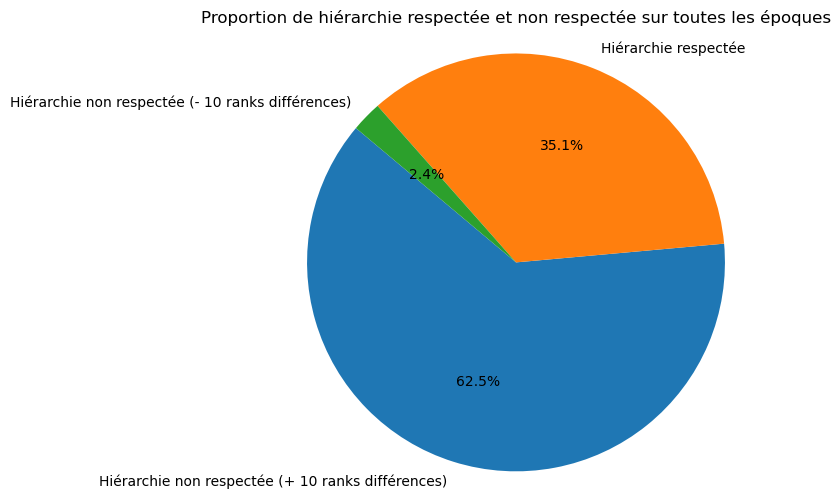

In [119]:
analyse_all_tournoi_all_epoque = analyse_all_epoque_winner_loser

# appel de fonction 
hierachie_all_circuit_all_epoque = hierarchie_all_epoque_per_epoque(analyse_all_tournoi_all_epoque, "all_epoque", "all_circuit")

#print(hierachie_all_circuit_all_epoque)

### 4.3.3.2. Etat de la hiérarchie lors des matchs (Taux de match gagné par ceux qui ont moins de rank), tous tournois et Par époque

Nombre de matchs avec des rankings inconnus sur un OU deux joueurs pour l'époque 1990 - 1999 : 20.0 %
Nombre de matchs avec des rankings inconnus sur un OU deux joueurs pour l'époque 2000 - 2009 : 15.0 %
Nombre de matchs avec des rankings inconnus sur un OU deux joueurs pour l'époque 2010 - 2019 : 16.0 %


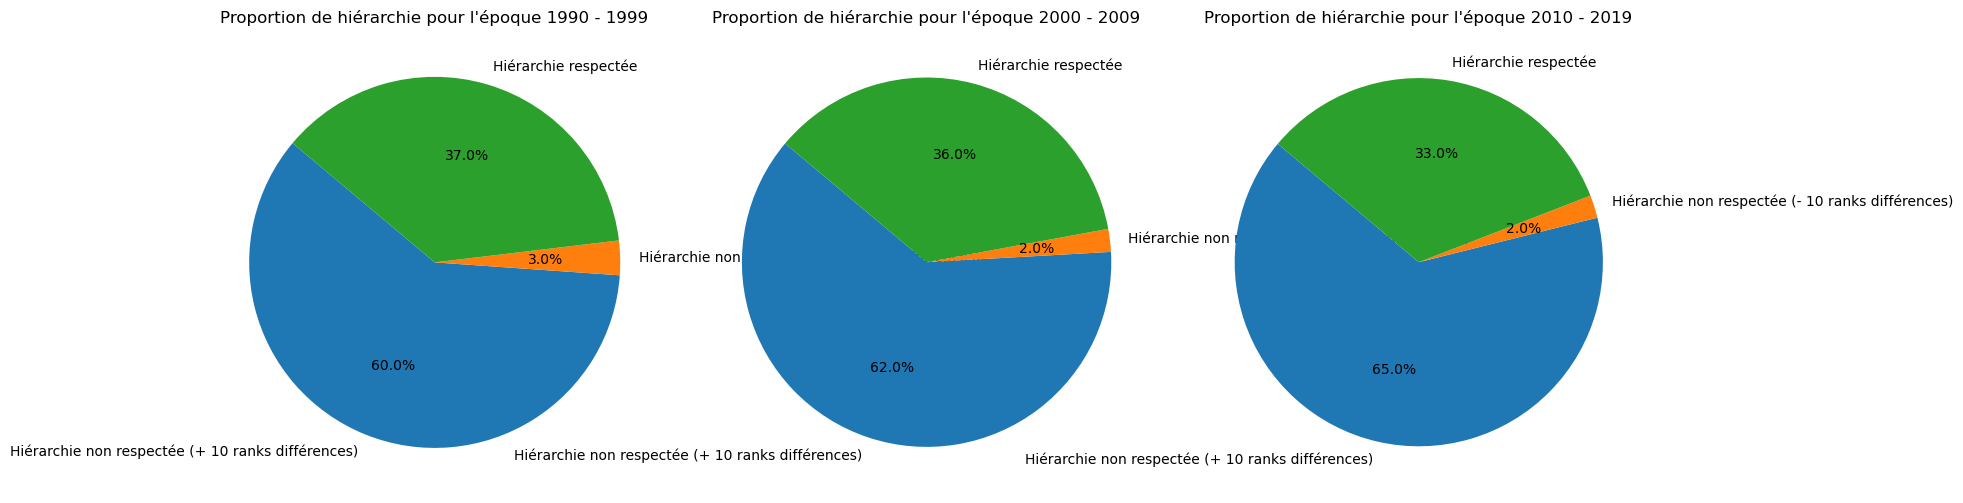

In [120]:
analyse_all_tournoi_per_epoque = analyse_all_epoque_winner_loser

# appel de fonction 
hierachie_all_circuit_per_epoque = hierarchie_all_epoque_per_epoque(analyse_all_tournoi_per_epoque, "per_epoque", "all_circuit")

#print(hierachie_all_circuit_per_epoque)

### 4.3.3.3. Etat de la hiérarchie lors des matchs (Taux de match gagné par ceux qui ont moins de rank), tournois ATP et toutes époques confondues

Nombre de matchs avec des rankings inconnus sur un OU deux joueurs = 2.0 %


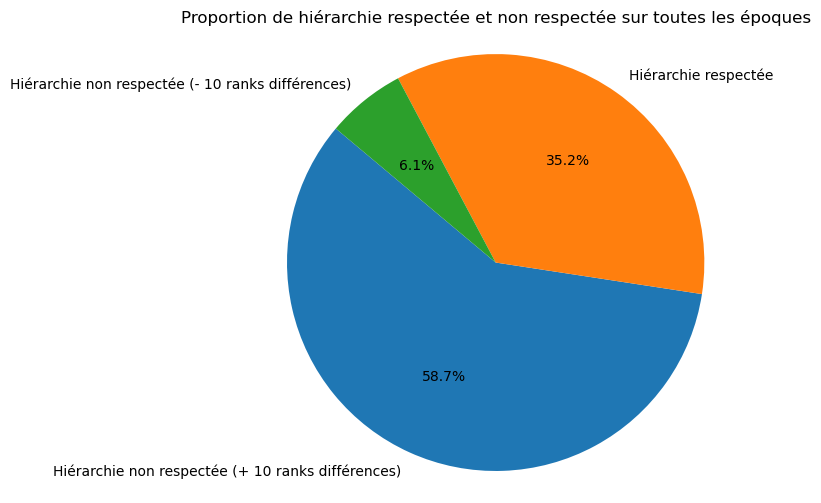

In [121]:
analyse_tournoi_atp_all_epoque = analyse_all_epoque_winner_loser

# Filtre pour récupérer uniquement les matchs des tournois ATP
analyse_tournoi_atp_all_epoque = analyse_tournoi_atp_all_epoque[analyse_tournoi_atp_all_epoque["tourney_circuit"] == "ATP"]

# appel de fonction 
hierachie_atp_circuit_all_epoque = hierarchie_all_epoque_per_epoque(analyse_tournoi_atp_all_epoque, "all_epoque", "atp")

### 4.3.3.4. Etat de la hiérarchie lors des matchs (Taux de match gagné par ceux qui ont moins de rank), tournois ATP et Par époque

Nombre de matchs avec des rankings inconnus sur un OU deux joueurs pour l'époque 1990 - 1999 : 2.0 %
Nombre de matchs avec des rankings inconnus sur un OU deux joueurs pour l'époque 2000 - 2009 : 2.0 %
Nombre de matchs avec des rankings inconnus sur un OU deux joueurs pour l'époque 2010 - 2019 : 2.0 %


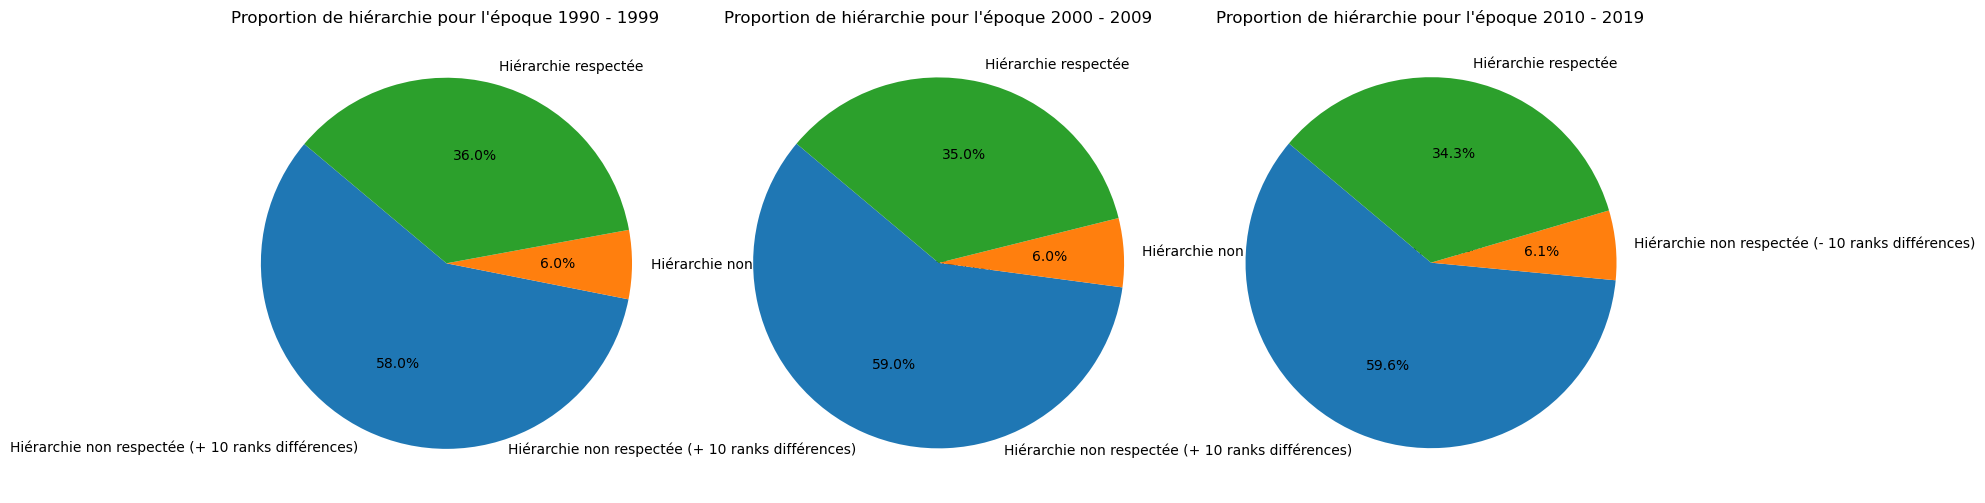

In [122]:
analyse_tournoi_atp_per_epoque = analyse_all_epoque_winner_loser

# Filtre pour récupérer uniquement les matchs des tournois ATP
analyse_tournoi_atp_per_epoque = analyse_tournoi_atp_per_epoque[analyse_tournoi_atp_per_epoque["tourney_circuit"] == "ATP"]

# appel de fonction 
hierachie_atp_circuit_per_epoque = hierarchie_all_epoque_per_epoque(analyse_tournoi_atp_per_epoque, "per_epoque", "atp")

In [123]:
# Concaténation pour les donénes des hiérarchies des matchs pour toutes les époques et les diverses circuits - utile pour tableau public
    # Rassemblement des données en un et même dataframe
    
df_hierarchie_match_all_epoque = pd.concat([hierachie_all_circuit_all_epoque, hierachie_atp_circuit_all_epoque], axis=0)
df_hierarchie_match_all_epoque = df_hierarchie_match_all_epoque.reset_index()
df_hierarchie_match_all_epoque =df_hierarchie_match_all_epoque.drop(columns=['index'])

df_hierarchie_match_all_epoque["proportion"] = df_hierarchie_match_all_epoque["proportion"] *100

# Intégration du nom de l'analyse
df_hierarchie_match_all_epoque["nom_analyse"] = "3.3.hierarchie_respecte_all_circuit_circuit_atp_all_epoque" 

# Modification du naming contenant les valeurs de la proportion
df_hierarchie_match_all_epoque = df_hierarchie_match_all_epoque.rename(columns={"proportion": "valeurs"})

#print(df_hierarchie_match_all_epoque)


# Export des données pour tableau public
#df_hierarchie_match_all_epoque.to_excel(f"3.3.hierarchie_respecte_all_circuit_circuit_atp_all_epoque.xlsx",  sheet_name='Sheet_name_1') 
      

In [124]:
# Concaténation pour les donénes des hiérarchies des matchs pour toutes les époques et les diverses circuits - utile pour tableau public
    # Rassemblement des données en un et même dataframe
    
df_hierarchie_match_per_epoque = pd.concat([hierachie_all_circuit_per_epoque, hierachie_atp_circuit_per_epoque], axis=0)
df_hierarchie_match_per_epoque = df_hierarchie_match_per_epoque.reset_index()
df_hierarchie_match_per_epoque =df_hierarchie_match_per_epoque.drop(columns=['index'])


# Intégration du nom de l'analyse
df_hierarchie_match_per_epoque["nom_analyse"] = "3.3.hierarchie_respecte_all_circuit_circuit_atp_per_epoque" 

# Modification du naming contenant les valeurs de la proportion
df_hierarchie_match_per_epoque = df_hierarchie_match_per_epoque.rename(columns={"proportion": "valeurs"})

print(df_hierarchie_match_per_epoque)


# Export des données pour tableau public
#df_hierarchie_match_per_epoque.to_excel(f"3.3.hierarchie_respecte_all_circuit_circuit_atp_per_epoque.xlsx",  sheet_name='Sheet_name_1') 
      

                                   Type de hierarchie  valeurs       epoque  \
0   Hiérarchie non respectée (+ 10 ranks différences)     60.0  1990 - 1999   
1   Hiérarchie non respectée (- 10 ranks différences)      3.0  1990 - 1999   
2                                Hiérarchie respectée     37.0  1990 - 1999   
3   Hiérarchie non respectée (+ 10 ranks différences)     62.0  2000 - 2009   
4   Hiérarchie non respectée (- 10 ranks différences)      2.0  2000 - 2009   
5                                Hiérarchie respectée     36.0  2000 - 2009   
6   Hiérarchie non respectée (+ 10 ranks différences)     65.0  2010 - 2019   
7   Hiérarchie non respectée (- 10 ranks différences)      2.0  2010 - 2019   
8                                Hiérarchie respectée     33.0  2010 - 2019   
9   Hiérarchie non respectée (+ 10 ranks différences)     58.0  1990 - 1999   
10  Hiérarchie non respectée (- 10 ranks différences)      6.0  1990 - 1999   
11                               Hiérarchie respecté

In [125]:
# Concaténation des deux jeux de données, pour pouvoir ensuite les exporter et les traiter sur tableau
df_hierarchie_match_per_epoque_all_epoque = pd.concat([df_hierarchie_match_all_epoque, df_hierarchie_match_per_epoque], axis=0)


# Indication "no_data" sur les valeurs NULL
df_hierarchie_match_per_epoque_all_epoque = df_hierarchie_match_per_epoque_all_epoque.fillna("no_data")

#print(df_hierarchie_match_per_epoque_all_epoque)

### Concaténation des données de la thématique 3 pour l'utilisation sur Tableau Public, et obtenir des filtres communs sur le dashboard


In [126]:
# Concaténation des deux jeux de données, pour pouvoir ensuite les exporter et les traiter sur tableau
tableau_thematique_3 = pd.concat([df_rank_top_all_per_epoque_all_epoque, df_rank_arrive_le_plus_rapidement_top_all_per_epoque_all_epoque,df_hierarchie_match_per_epoque_all_epoque], axis=0)


# Indication "no_data" sur les valeurs NULL
tableau_thematique_3 = tableau_thematique_3.fillna("no_data")


#print(tableau_thematique_3)

# Export des données
tableau_thematique_3.to_excel("thematique_3_data.xlsx",  sheet_name='Sheet_name_1') 

## 4.4 Thématique 4 : Les joueurs et les tournois/surface

### 4.4.1.1 Top 10 : Joueurs qui ont le plus gagné de tournois VS Temps de carrière (année) - Depuis 1990 

In [127]:
def win_tourney_x_year_carreer(type_tournoi):

    tournoi_win = analyse_all_epoque
    tournoi_first_appareance_last_appareance = analyse_all_epoque
    
    # Si type de tournoi ATP, on filtre sur les tournois ATP uniquement
    if (type_tournoi == "atp"):
        
        tournoi_win = tournoi_win[tournoi_win["tourney_circuit"] == "ATP"]
        tournoi_first_appareance_last_appareance = tournoi_first_appareance_last_appareance[tournoi_first_appareance_last_appareance["tourney_circuit"] == "ATP"]

    # A. Traitement pour obtenir le nombre de tournois gagnés par joueur 

        # Récupération seulement des matchs ou c'est une finale
    tournoi_win = tournoi_win[tournoi_win["round"]=="F"]

        # Récupération des données seulement des gagnants dans les matchs
    tournoi_win = tournoi_win[tournoi_win["result_player_match"]=="Win"]

        # Création d'un champ intermédiaire avec 1 par défaut, pour mener une somme et compter le nombre de matchs gagnés
    tournoi_win["tournoi_win"] = 1

        # Group by pour rassembler les données des joueurs autour 
    tournoi_win = tournoi_win.groupby(["player_id","player_name"]).agg({"tournoi_win":"sum"})
    tournoi_win = tournoi_win.reset_index()

    # B. Traitements pour obtenir la date du premier match référencé et du dernier PUIS calculer le nombre d'années de carrière

        # Copie de la colonne de l'année du match - pour pouvoir mener l'aggregation sur les deux champs
    tournoi_first_appareance_last_appareance["year_copie"] = tournoi_first_appareance_last_appareance["year"]

        # Group by  pour rassembler les données autour des joueurs id, pour acquérir la date min de chaque joueur dans les données de match et pareil pour la date max, donc match le plus récent ou dernier
    tournoi_first_appareance_last_appareance = tournoi_first_appareance_last_appareance.groupby(["player_id","player_name"]).agg({"year":"min", "year_copie":"max"})
    tournoi_first_appareance_last_appareance = tournoi_first_appareance_last_appareance.rename(columns={'year': 'year_first_appearance', 'year_copie':'year_last_recent_appareance'})
    tournoi_first_appareance_last_appareance = tournoi_first_appareance_last_appareance.reset_index()

        # Différence de l'année de première apparition par rapport à la dernière apparition, pour obtenir le nombre d'année de carrière
    tournoi_first_appareance_last_appareance["year_carreer"] = tournoi_first_appareance_last_appareance["year_last_recent_appareance"] - tournoi_first_appareance_last_appareance["year_first_appearance"]

    # C. Rassemblement des données pour avoir le nombre de tournois WIn et le nombre d'années de carrière

        # Jointure pour obtenir le nombre d'année de carrière avec le nombre de tournois win
    tournoi_win_year_carreer = tournoi_win.merge(
        tournoi_first_appareance_last_appareance[["player_id", "year_carreer"]],
        left_on="player_id",  # Colonne de la première table
        right_on="player_id",  # Colonne de la seconde table
        how="left"
    )

        # Récupération du top 10 des joueurs qui ont le plus gagnés de tournoi + reset des index pour la visualisation
    tournoi_win_year_carreer= tournoi_win_year_carreer.sort_values(by='tournoi_win', ascending=False).head(10)
    tournoi_win_year_carreer = tournoi_win_year_carreer.reset_index()


    #print(tournoi_win_year_carreer)


    #----# 

    # Visualisation sous forme d'un scatter plot

    # Créer une figure
    plt.figure(figsize=(10, 6))

    # Créer le scatter plot
    plt.scatter(tournoi_win_year_carreer["year_carreer"], tournoi_win_year_carreer["tournoi_win"], marker='o')

    # Ajouter des étiquettes aux points du scatter plot - les placer au dessus des points
    for i, txt in enumerate(tournoi_win_year_carreer["player_name"]):
        plt.annotate(txt, (tournoi_win_year_carreer["year_carreer"][i], tournoi_win_year_carreer["tournoi_win"][i]), textcoords="offset points", xytext=(0, 10), ha='center')

    # Titres et étiquettes des axes
    plt.title("Nombre de tournois gagnés par rapport aux années de carrière")
    plt.xlabel("Années de carrière")
    plt.ylabel("Nombre de tournois gagnés")

    # Afficher le scatter plot
    plt.grid(True)
    plt.show()
    
    #print(tournoi_win_year_carreer)
    
    tournoi_win_year_carreer =tournoi_win_year_carreer.drop(columns=['index'])

    tournoi_win_year_carreer["circuit_cible"] = type_tournoi
    
    #print(tournoi_win_year_carreer)
    
    return(tournoi_win_year_carreer)

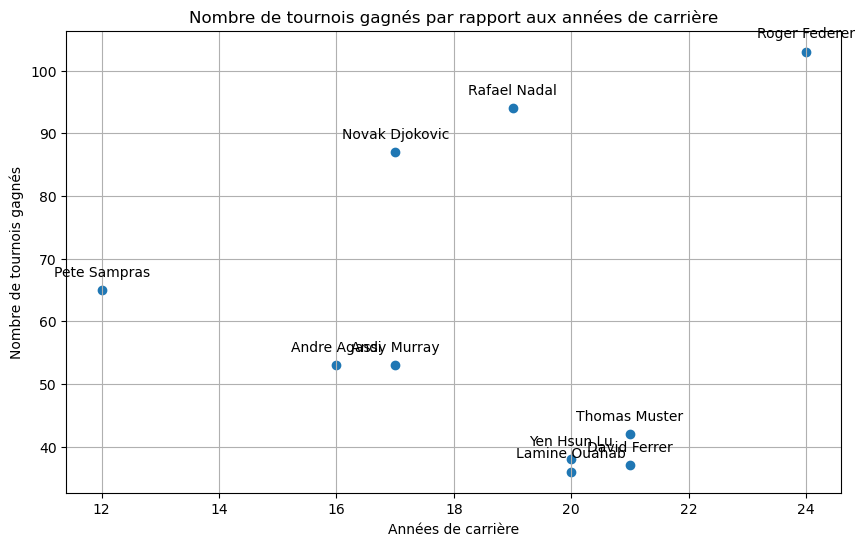

In [128]:
# Appel de la fonction
win_tourney_x_year_carrer_all_circuit_all_epoque = win_tourney_x_year_carreer("all_circuit")

### 4.4.1.2 Top 10 : Joueurs qui ont le plus gagné de tournois ATP VS Temps de carrière (année) - depuis 1990

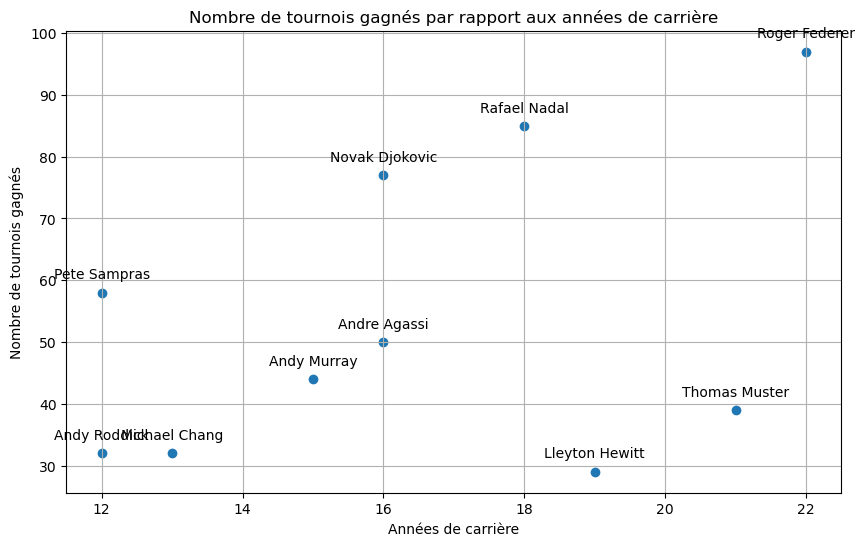

In [129]:
# Appel de la fonction
win_tourney_x_year_carrer_atp_circuit_all_epoque = win_tourney_x_year_carreer("atp")

In [130]:
# Concaténation pour les donénes du top 10 des joueurs ayant remportés le plus grand nombres de tounrois gagnés sur toutes les époques et les diverses circuits - utile pour tableau public
    # Rassemblement des données en un et même dataframe
    
df_top_10_player_win_tournoi_x_year_all_epoque = pd.concat([win_tourney_x_year_carrer_all_circuit_all_epoque, win_tourney_x_year_carrer_atp_circuit_all_epoque], axis=0)
df_top_10_player_win_tournoi_x_year_all_epoque = df_top_10_player_win_tournoi_x_year_all_epoque.reset_index()
df_top_10_player_win_tournoi_x_year_all_epoque =df_top_10_player_win_tournoi_x_year_all_epoque.drop(columns=['index'])


# Intégration du nom de l'analyse
df_top_10_player_win_tournoi_x_year_all_epoque["nom_analyse"] = "4.1.top10_win_tournoi_year_carreer_all_circuit_circuit_atp_all_epoque" 

# Modification du naming contenant les valeurs de la proportion
df_top_10_player_win_tournoi_x_year_all_epoque = df_top_10_player_win_tournoi_x_year_all_epoque.rename(columns={"tournoi_win": "valeurs"})

# Suppression de la colonne inutile 
df_top_10_player_win_tournoi_x_year_all_epoque =df_top_10_player_win_tournoi_x_year_all_epoque.drop(columns=['player_id'])

#print(df_top_10_player_win_tournoi_x_year_all_epoque)

# Export des données pour tableau public
#df_top_10_player_win_tournoi_x_year_all_epoque.to_excel(f"4.1.top10_win_tournoi_year_carreer_all_circuit_circuit_atp_all_epoque.xlsx",  sheet_name='Sheet_name_1') 
      

### 4.4.1.3 Top 10 : Nombre de tournois  remportés par age pour le top 10 des vainqueurs de tous les tournois

In [131]:
def win_tourney_x_per_age(type_tournoi):

# Traitement global

    tournoi_win_age = analyse_all_epoque
    
    # Si type de tournoi ATP, on filtre sur les tournois ATP uniquement
    if (type_tournoi == "atp"):
        
        tournoi_win_age = tournoi_win_age[tournoi_win_age["tourney_circuit"] == "ATP"]
        #print("oui")
        # Récupération seulement des matchs ou c'est une finale
    tournoi_win_age = tournoi_win_age[tournoi_win_age["round"]=="F"]

        # Récupération des données seulement des gagnants dans les matchs
    tournoi_win_age = tournoi_win_age[tournoi_win_age["result_player_match"]=="Win"]

        # Création d'un champ intermédiaire pour faire la somme des tournois
    tournoi_win_age["tournoi_win"] = 1

    # A. Traitement pour récupérer la liste unique des 10 qui ont le plus gagnés de tournoi

        # Group pour rassembler le nombre de tournoi par joueur et par an
    tournoi_win_age_top_10_unique_player = tournoi_win_age.groupby(["player_id","player_name"]).agg({"tournoi_win":"sum"})
    tournoi_win_age_top_10_unique_player = tournoi_win_age_top_10_unique_player.reset_index()

        # Récupération du top 10 des joueurs qui ont le plus gagnés de tournoi
    tournoi_win_age_top_10_unique_player= tournoi_win_age_top_10_unique_player.sort_values(by='tournoi_win', ascending=False).head(10)

        # Récupération de manière unique des joueurs dans le top 10
    tournoi_win_age_top_10_unique_player = tournoi_win_age_top_10_unique_player["player_id"].unique()

    #print(tournoi_win_age_top_10_unique_player)

    # B. Récupération du nombre de tournois gagnés par age pour le top 10 des joueurs

        # Récupération de le jeu de données de base seulement des lignes des 10 top joueurs - pour les tournois ATP
    tournoi_win_age_top_10 = tournoi_win_age[tournoi_win_age['player_id'].isin(tournoi_win_age_top_10_unique_player)]

    #print(tournoi_win_age_top_10)

        # Arrondi de l'age des joueurs (pour éviter les 22,6 par exemple)
    tournoi_win_age_top_10["player_age"] = round(tournoi_win_age_top_10["player_age"],0)

        # Group pour rassembler le nombre de tournoi par joueur et par an
    tournoi_win_age_top_10 = tournoi_win_age_top_10.groupby(["player_id","player_name", "player_age"]).agg({"tournoi_win":"sum"})
    tournoi_win_age_top_10 = tournoi_win_age_top_10.reset_index()

        # Triez le DataFrame par 'player_id' et 'player_age'
    tournoi_win_age_top_10 = tournoi_win_age_top_10.sort_values(by=['player_id', 'player_age'])

        # Ajoutez une colonne 'cumulative_wins' qui calcule les victoires cumulatives par joueur - pour que ça soit plus lisible sur le graphique
    tournoi_win_age_top_10['cumulative_wins'] = tournoi_win_age_top_10.groupby('player_id')['tournoi_win'].cumsum()

    #print(tournoi_win_age_top_10)

    # ---- #

    # Visualisation sous la forme d'un graphique line plot



        # Parcourez les joueurs uniques dans les données
    for player_id in tournoi_win_age_top_10['player_id'].unique():
            # Récupération des données qui concernes le joueur itéré
        player_data = tournoi_win_age_top_10[tournoi_win_age_top_10['player_id'] == player_id]

        # Créez une ligne pour chaque joueur
        plt.plot(player_data['player_age'], player_data['cumulative_wins'], label=player_data['player_name'].values[0])

        # Titres et étiquettes des axes
    plt.title("Évolution du nombre de tournois gagnés en fonction de l'âge")
    plt.xlabel("Âge du joueur")
    plt.ylabel("Nombre de tournois gagnés")

        # Légende pour identifier les joueurs
    plt.legend()

        # Affichez le graphique
    plt.grid(True)
    plt.show()
    
    
    # Ajout du type de circuit des données traitées - utile pour Tableau public
    tournoi_win_age_top_10["circuit_cible"] = type_tournoi
    
    #print(tournoi_win_age_top_10)
    
    return(tournoi_win_age_top_10)

        
    #print(tournoi_win_age_top_10)

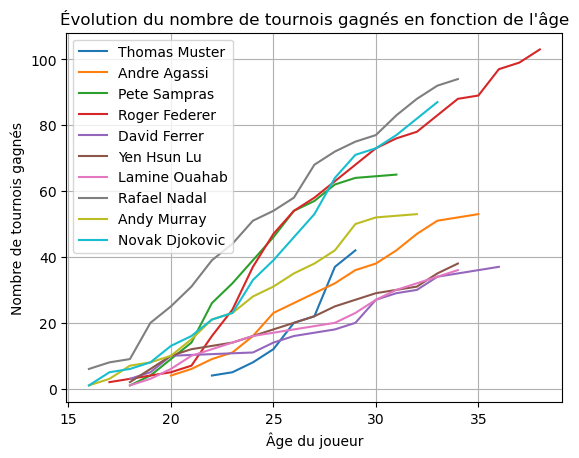

In [132]:
# Appel de fonction
top_10_nb_tourney_win_per_age_all_circuit_all_epoque =  win_tourney_x_per_age("all_circuit")

### 4.4.1.4 Top 10 : Nombre de tournois ATP remportés par age pour le top 10 des vainqueurs de tournoi ATP

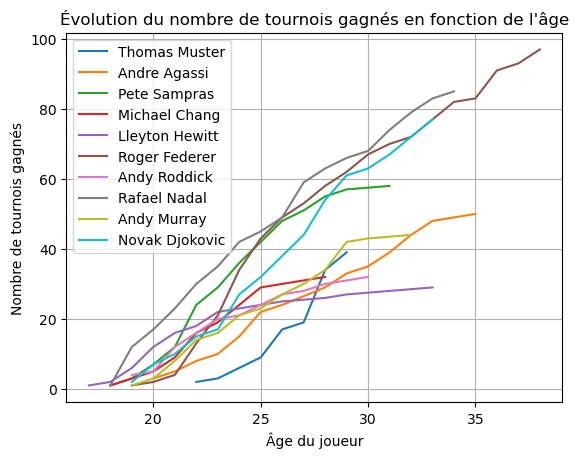

In [133]:
# Appel de fonction
top_10_nb_tourney_win_per_age_atp_circuit_all_epoque = win_tourney_x_per_age("atp")

In [134]:
# Concaténation pour les donénes du top 10 des joueurs ayant remportés le plus grand nombres de tounrois gagnés sur toutes les époques et les diverses circuits - utile pour tableau public
    # Rassemblement des données en un et même dataframe
    
df_top_10_player_win_tournoi_per_age_all_epoque = pd.concat([top_10_nb_tourney_win_per_age_all_circuit_all_epoque, top_10_nb_tourney_win_per_age_atp_circuit_all_epoque], axis=0)
df_top_10_player_win_tournoi_per_age_all_epoque = df_top_10_player_win_tournoi_per_age_all_epoque.reset_index()
df_top_10_player_win_tournoi_per_age_all_epoque =df_top_10_player_win_tournoi_per_age_all_epoque.drop(columns=['index'])

# Intégration du nom de l'analyse
df_top_10_player_win_tournoi_per_age_all_epoque["nom_analyse"] = "4.2.top10_win_tournoi_cumulative_per_age_all_circuit_circuit_atp_all_epoque" 

# Modification du naming contenant les valeurs de la proportion
df_top_10_player_win_tournoi_per_age_all_epoque = df_top_10_player_win_tournoi_per_age_all_epoque.rename(columns={"cumulative_wins": "valeurs"})

# Suppression de la colonne inutile 
df_top_10_player_win_tournoi_per_age_all_epoque =df_top_10_player_win_tournoi_per_age_all_epoque.drop(columns=['player_id', 'tournoi_win'])

#print(df_top_10_player_win_tournoi_per_age_all_epoque)

# Export des données pour tableau public
#df_top_10_player_win_tournoi_per_age_all_epoque.to_excel(f"4.2.top10_win_tournoi_cumulative_per_age_all_circuit_circuit_atp_all_epoque.xlsx",  sheet_name='Sheet_name_1') 
      

### 4.4.2.1. Top 10 : Joueurs qui ont le plus gagné sur chaque surface de tous les tournois - depuis 1990

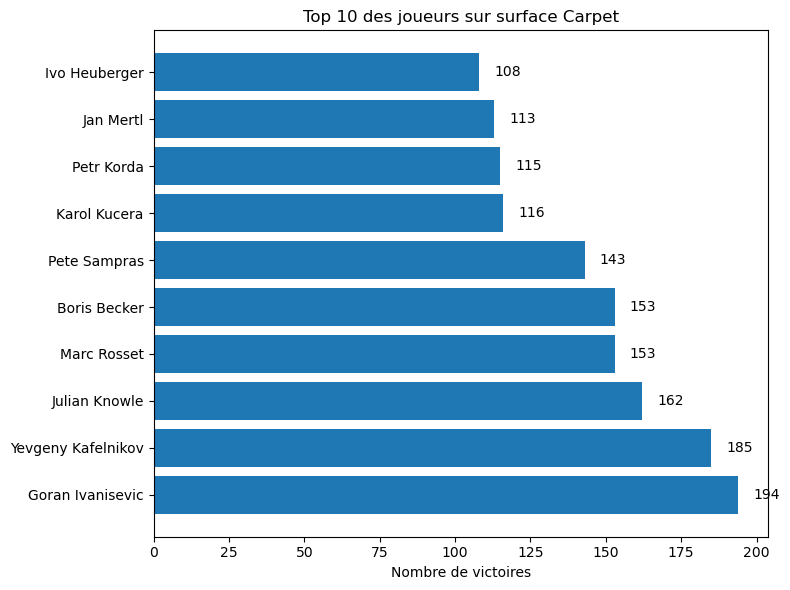

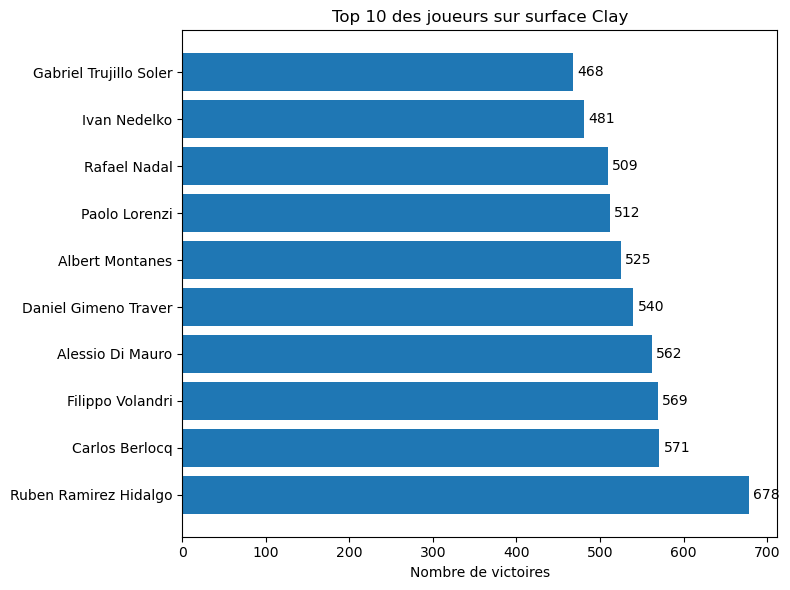

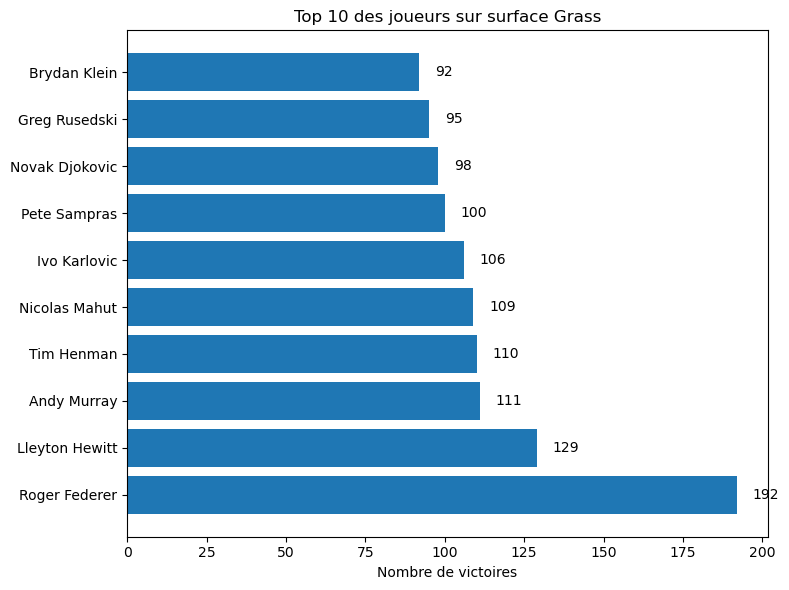

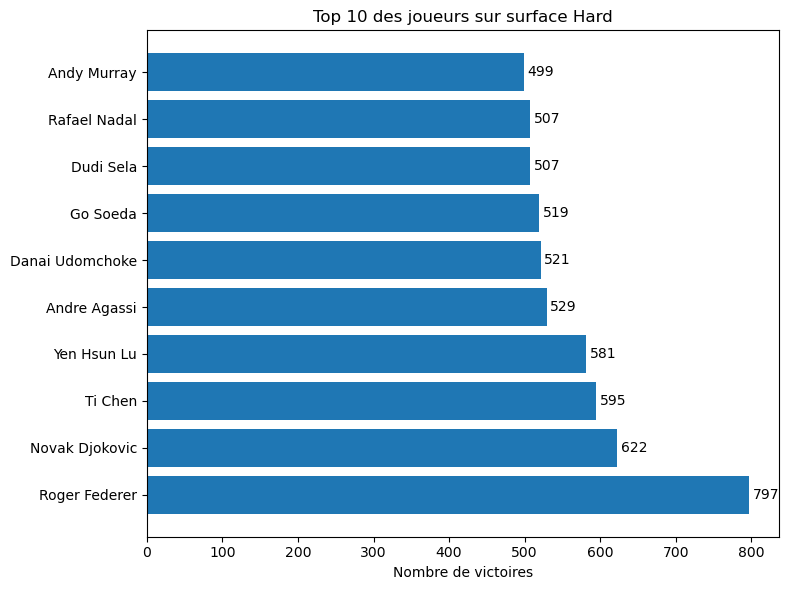

In [135]:
analyse_13 = analyse_all_epoque


# Traitement des données

    # On garde seulement les champs que l'on va traiter
analyse_13 = analyse_13[["id_atp_matches","tourney_id","surface","tourney_circuit","player_name","result_player_match"]]

    # On filtre sur les données pour garder seulement les lignes ou ce sont les gagnats des matchs
        # Aucun NA
analyse_13 = analyse_13[analyse_13["result_player_match"] == "Win"]

    # Créer colonne avec 1 par défaut pour effectuer une somme dessus et compter les matchs wins
analyse_13["count_win_match"] = 1

    # Group by pour rassembler les données autour du player name ET surface, somme du champ créé précédement
analyse_13 = analyse_13.groupby(["player_name", "surface"]).agg({"count_win_match":"sum"})
analyse_13 = analyse_13.reset_index()

    # Trie croissant ET récupération du top 10
        # Groupement par surface et tri par "count_win_match"
analyse_13_all_circuit_top10_by_surface = analyse_13.groupby('surface', group_keys=False).apply(lambda group: group.sort_values(by='count_win_match', ascending=False).head(10))

#print(analyse_13_all_circuit_top10_by_surface)

# Visualisation des données 

# Parcourir les surfaces uniques
for surface in analyse_13_all_circuit_top10_by_surface['surface'].unique():
    # Sélectionner les données pour la surface actuelle
    surface_data = analyse_13_all_circuit_top10_by_surface[analyse_13_all_circuit_top10_by_surface['surface'] == surface]

    # Créer un graphique bar pour la surface actuelle
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(surface_data['player_name'], surface_data['count_win_match'])
    ax.set_xlabel("Nombre de victoires")
    ax.set_title(f"Top 10 des joueurs sur surface {surface}")

    # Ajouter les étiquettes brutes des données
    for i, (player_name, count_win_match) in enumerate(zip(surface_data['player_name'], surface_data['count_win_match'])):
        ax.text(count_win_match + 5, i, f"{count_win_match}", va='center')

    
    plt.tight_layout()

# Afficher les graphiques
plt.show()

# Intégration du type de circuit ciblé - utile pour tableau public
analyse_13_all_circuit_top10_by_surface["circuit_cible"] = "all_circuit"

### 4.4.2.2. Top 10 : Joueurs qui ont le plus gagné sur chaque surface des tournois ATP - depuis 1990

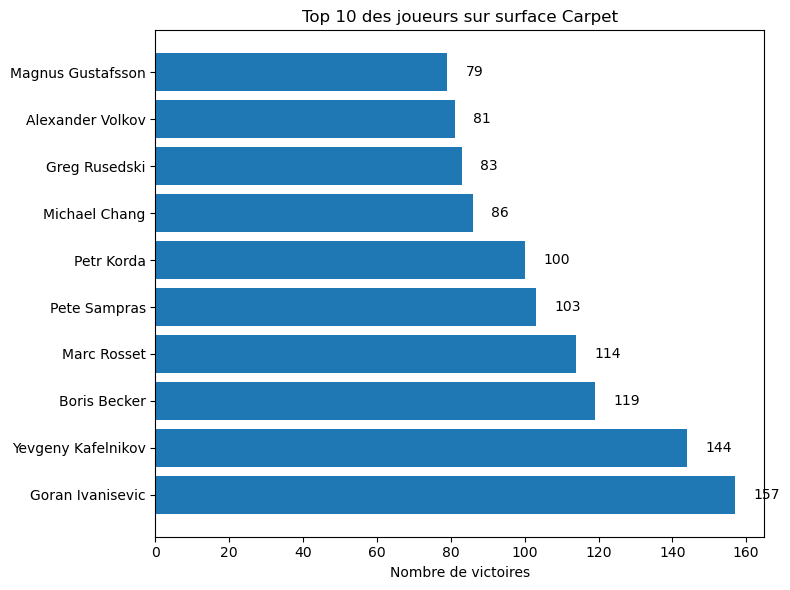

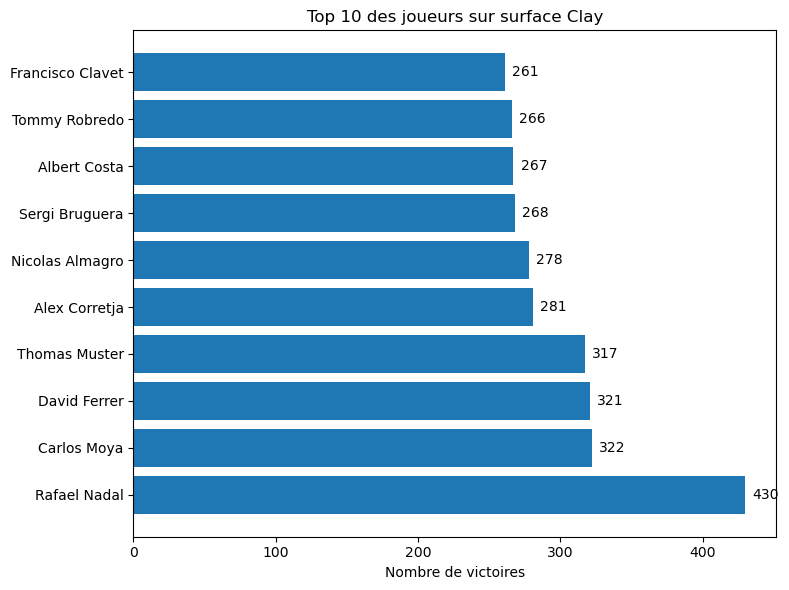

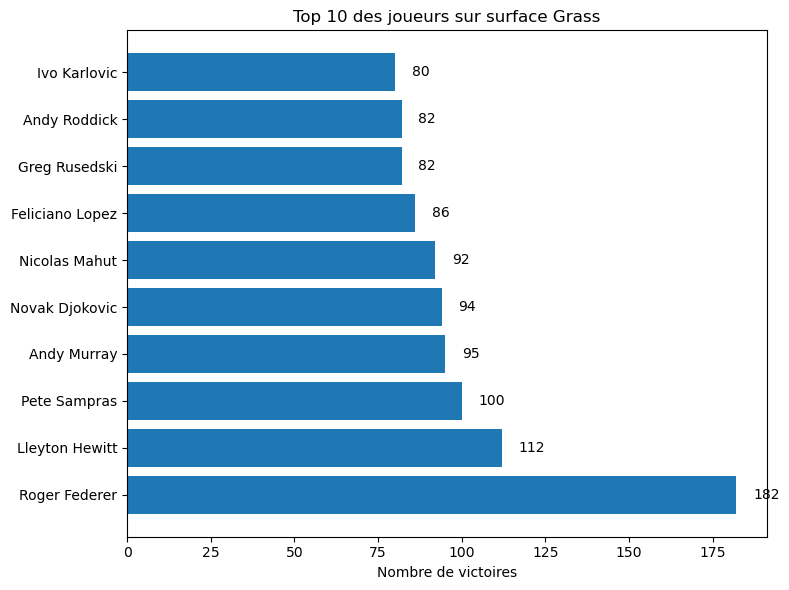

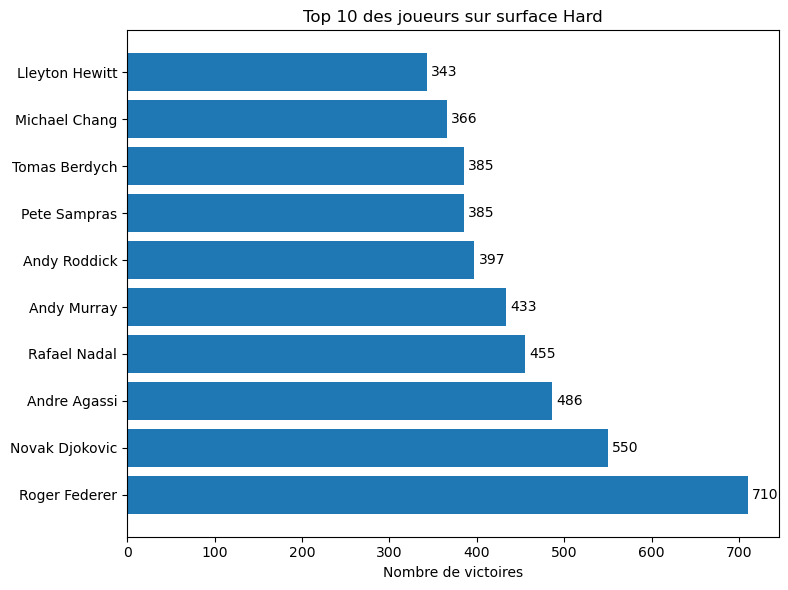

In [136]:
analyse_13_2 = analyse_all_epoque


# Traitement des données

    # On garde seulement les champs que l'on va traiter
analyse_13_2 = analyse_13_2[["id_atp_matches","tourney_id","surface","tourney_circuit","player_name","result_player_match"]]

    # On filtre sur les données pour garder seulement les lignes ou ce sont les gagnats des matchs
        # Aucun NA
analyse_13_2 = analyse_13_2[analyse_13_2["result_player_match"] == "Win"]


    # On filtre sur les données pour garder seulement les matchs qui sont dans le circuit ATP
analyse_13_2 = analyse_13_2[analyse_13_2["tourney_circuit"] == "ATP"]

    # Créer colonne avec 1 par défaut pour effectuer une somme dessus et compter les matchs wins
analyse_13_2["count_win_match"] = 1

    # Group by pour rassembler les données autour du player name ET surface, somme du champ créé précédement
analyse_13_2 = analyse_13_2.groupby(["player_name", "surface"]).agg({"count_win_match":"sum"})
analyse_13_2 = analyse_13_2.reset_index()

    # Trie croissant ET récupération du top 10
        # Groupement par surface et tri par "count_win_match"
analyse_13_atp_circuit_top10_by_surface = analyse_13_2.groupby('surface', group_keys=False).apply(lambda group: group.sort_values(by='count_win_match', ascending=False).head(10))

#print(analyse_13_atp_circuit_top10_by_surface)

# Visualisation des données 

# Parcourir les surfaces uniques
for surface in analyse_13_atp_circuit_top10_by_surface['surface'].unique():
    # Sélectionner les données pour la surface actuelle
    surface_data = analyse_13_atp_circuit_top10_by_surface[analyse_13_atp_circuit_top10_by_surface['surface'] == surface]

    # Créer un graphique bar pour la surface actuelle
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(surface_data['player_name'], surface_data['count_win_match'])
    ax.set_xlabel("Nombre de victoires")
    ax.set_title(f"Top 10 des joueurs sur surface {surface}")

    # Ajouter les étiquettes brutes des données
    for i, (player_name, count_win_match) in enumerate(zip(surface_data['player_name'], surface_data['count_win_match'])):
        ax.text(count_win_match + 5, i, f"{count_win_match}", va='center')

    
    plt.tight_layout()

# Afficher les graphiques
plt.show()

# Intégration du type de circuit ciblé - utile pour tableau public
analyse_13_atp_circuit_top10_by_surface["circuit_cible"] = "atp"

In [137]:
# Concaténation pour les donénes du top 10 des joueurs par surface ayant gagné le plus de matchs sur les différentes surfaces  - utile pour tableau public
    # Rassemblement des données en un et même dataframe
    
df_top10_win_per_surface_all_epoque = pd.concat([analyse_13_all_circuit_top10_by_surface, analyse_13_atp_circuit_top10_by_surface], axis=0)
df_top10_win_per_surface_all_epoque = df_top10_win_per_surface_all_epoque.reset_index()
df_top10_win_per_surface_all_epoque =df_top10_win_per_surface_all_epoque.drop(columns=['index'])


# Intégration du nom de l'analyse
df_top10_win_per_surface_all_epoque["nom_analyse"] = "4.3.top10_joueurs_win_matchs_per_surface_all_circuit_circuit_atp_all_epoque.xlsx" 

# Modification du naming contenant les valeurs de la proportion
df_top10_win_per_surface_all_epoque = df_top10_win_per_surface_all_epoque.rename(columns={"count_win_match": "valeurs"})

#print(df_top10_win_per_surface_all_epoque)

# Export des données pour tableau public
#df_top10_win_per_surface_all_epoque.to_excel(f"4.3.top10_joueurs_win_matchs_per_surface_all_circuit_circuit_atp_all_epoque.xlsx",  sheet_name='Sheet_name_1') 

### 4.4.3.1. Top 10 : Nationalité qui ont le plus gagné de tournoi - depuis 1990

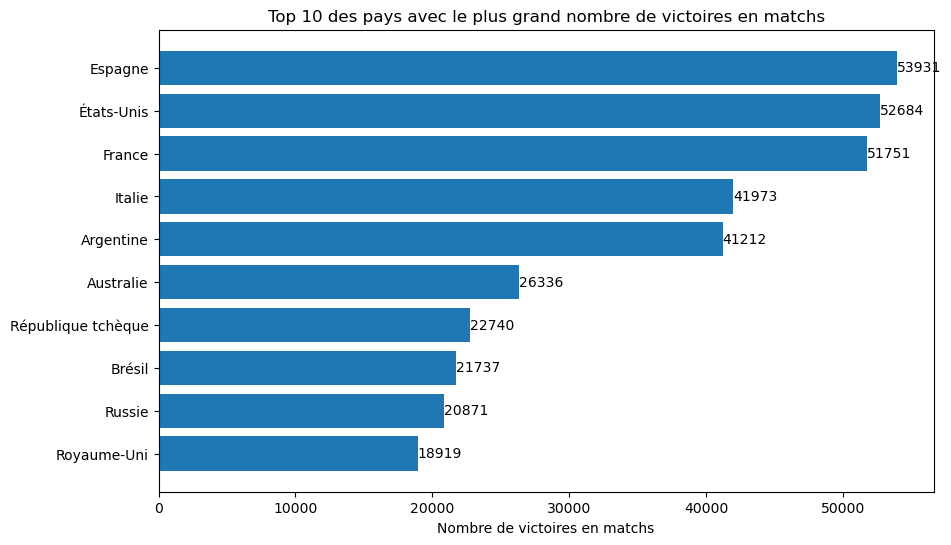

In [138]:
analyse_14 = analyse_all_epoque


# Traitement des données

    # On garde seulement les champs que l'on va traiter
analyse_14 = analyse_14[["id_atp_matches","tourney_id","surface","tourney_circuit","player_name","result_player_match","Pays"]]

    # On filtre sur les données pour garder seulement les lignes ou ce sont les gagnats des matchs
        # Aucun NA
analyse_14 = analyse_14[analyse_14["result_player_match"] == "Win"]

    # Créer colonne avec 1 par défaut pour effectuer une somme dessus et compter les matchs wins
analyse_14["count_win_match"] = 1

    # Group by pour rassembler les données autour du player name ET country, somme du champ créé précédement
analyse_14 = analyse_14.groupby(["Pays"]).agg({"count_win_match":"sum"})
analyse_14 = analyse_14.reset_index()

    # Trie croissant ET récupération du top 10
        # Groupement par surface et tri par "count_win_match"
analyse_14_all_circuit_top10 = analyse_14.sort_values(by='count_win_match', ascending=False).head(10)

#print(analyse_14_all_circuit_top10)

# Visualisation des données 

# Créer le graphique
plt.figure(figsize=(10, 6))
bars = plt.barh(analyse_14_all_circuit_top10["Pays"].values, analyse_14_all_circuit_top10["count_win_match"].values)
plt.xlabel('Nombre de victoires en matchs')
plt.title('Top 10 des pays avec le plus grand nombre de victoires en matchs')
plt.gca().invert_yaxis()  # Inverser l'axe y pour afficher le pays avec le plus grand nombre en haut

# Ajouter les étiquettes de données brutes
for bar, count in zip(bars, analyse_14_all_circuit_top10["count_win_match"].values):
    plt.text(count, bar.get_y() + bar.get_height() / 2, str(count), ha='left', va='center')

# Afficher le graphique
plt.show()

# Intégration du type de circuit ciblé - utile pour tableau public
analyse_14_all_circuit_top10["circuit_cible"] = "all_circuit"

### 4.4.3.2. Top 10 : Nationalité qui ont le plus gagné de tournoi ATP - depuis 1990

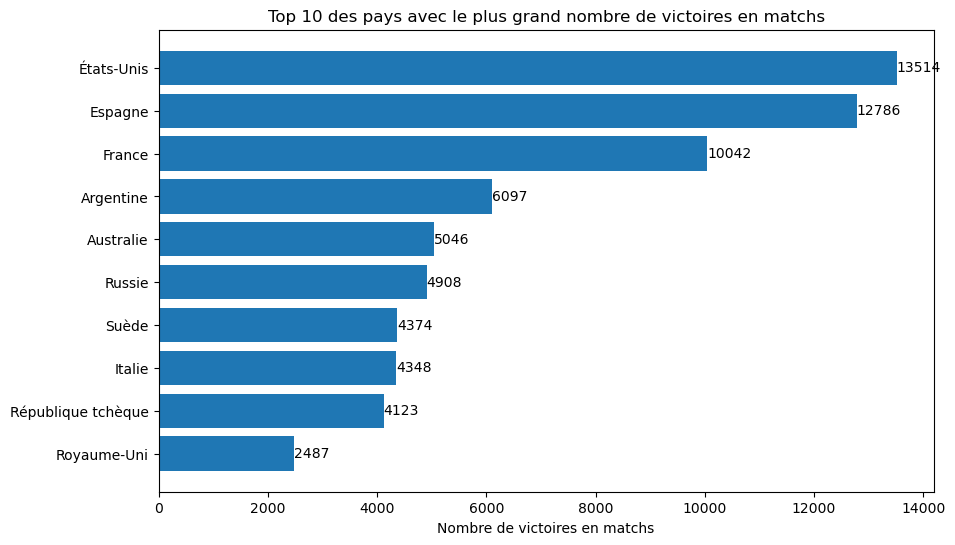

In [139]:
analyse_14_2 = analyse_all_epoque


# Traitement des données

    # On garde seulement les champs que l'on va traiter
analyse_14_2 = analyse_14_2[["id_atp_matches","tourney_id","surface","tourney_circuit","player_name","result_player_match","Pays"]]

    # On filtre sur les données pour garder seulement les lignes ou ce sont les gagnats des matchs
        # Aucun NA
analyse_14_2 = analyse_14_2[analyse_14_2["result_player_match"] == "Win"]

    # On filtre sur les données pour garder seulement les matchs qui sont dans le circuit ATP
analyse_14_2 = analyse_14_2[analyse_14_2["tourney_circuit"] == "ATP"]

    # Créer colonne avec 1 par défaut pour effectuer une somme dessus et compter les matchs wins
analyse_14_2["count_win_match"] = 1

    # Group by pour rassembler les données autour du player name ET country, somme du champ créé précédement
analyse_14_2 = analyse_14_2.groupby(["Pays"]).agg({"count_win_match":"sum"})
analyse_14_2 = analyse_14_2.reset_index()

    # Trie croissant ET récupération du top 10
        # Groupement par surface et tri par "count_win_match"
analyse_14_atp_circuit_top10 = analyse_14_2.sort_values(by='count_win_match', ascending=False).head(10)

#print(analyse_14_atp_circuit_top10)

# Visualisation des données 

    # Créer le graphique
plt.figure(figsize=(10, 6))
bars = plt.barh(analyse_14_atp_circuit_top10["Pays"].values, analyse_14_atp_circuit_top10["count_win_match"].values)
plt.xlabel('Nombre de victoires en matchs')
plt.title('Top 10 des pays avec le plus grand nombre de victoires en matchs')
plt.gca().invert_yaxis()  # Inverser l'axe y pour afficher le pays avec le plus grand nombre en haut

    # Ajouter les étiquettes de données brutes
for bar, count in zip(bars, analyse_14_atp_circuit_top10["count_win_match"].values):
    plt.text(count, bar.get_y() + bar.get_height() / 2, str(count), ha='left', va='center')

    # Afficher le graphique
plt.show()

# Intégration du type de circuit ciblé - utile pour tableau public
analyse_14_atp_circuit_top10["circuit_cible"] = "atp"

In [140]:
# Concaténation pour les donénes du top 10 des joueurs par surface ayant gagné le plus de matchs sur les différentes surfaces  - utile pour tableau public
    # Rassemblement des données en un et même dataframe
    
df_top10_natio_win_match_all_epoque = pd.concat([analyse_14_all_circuit_top10, analyse_14_atp_circuit_top10], axis=0)
df_top10_natio_win_match_all_epoque = df_top10_natio_win_match_all_epoque.reset_index()
df_top10_natio_win_match_all_epoque =df_top10_natio_win_match_all_epoque.drop(columns=['index'])

# Intégration du nom de l'analyse
df_top10_natio_win_match_all_epoque["nom_analyse"] = "4.4.top10_nationalite_win_matchs_all_circuit_circuit_atp_all_epoque.xlsx" 

# Modification du naming contenant les valeurs de la proportion
df_top10_natio_win_match_all_epoque = df_top10_natio_win_match_all_epoque.rename(columns={"count_win_match": "valeurs"})

#print(df_top10_natio_win_match_all_epoque)

# Export des données pour tableau public
#df_top10_natio_win_match_all_epoque.to_excel(f"4.4.top10_nationalite_win_matchs_all_circuit_circuit_atp_all_epoque.xlsx",  sheet_name='Sheet_name_1') 

### 4.4.4.1. Top 10 : Nationalité qui ont le plus gagné sur chaque surface de tous les tournois - depuis 1990

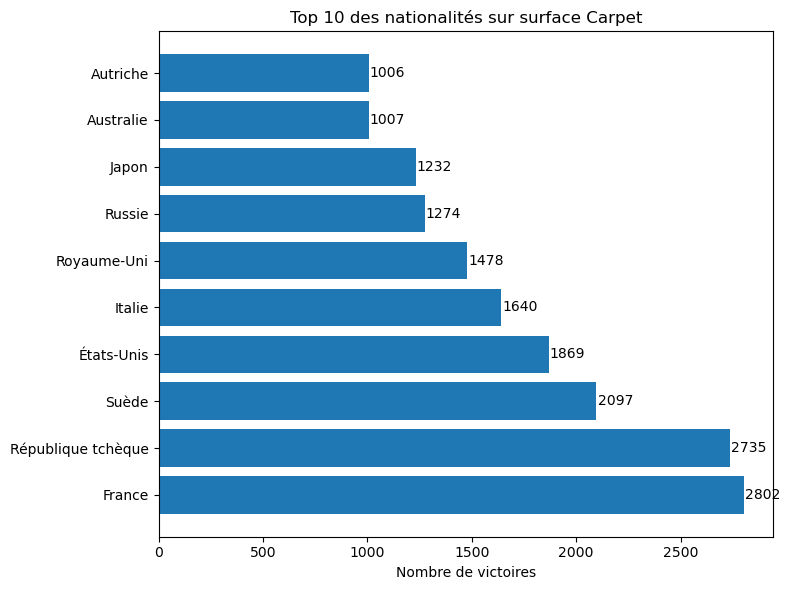

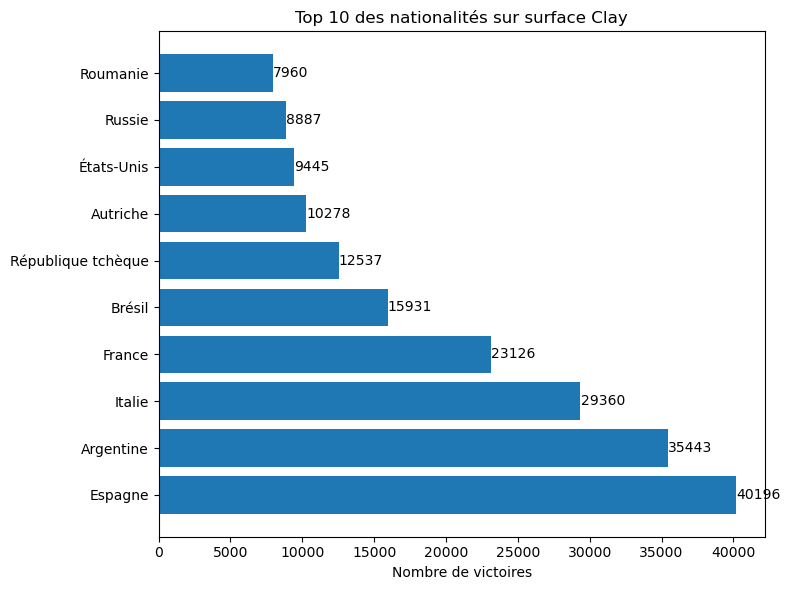

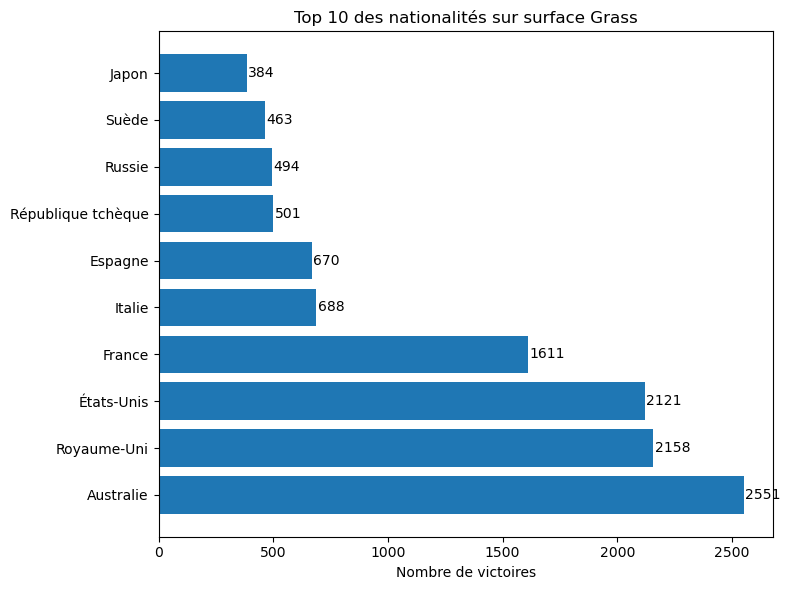

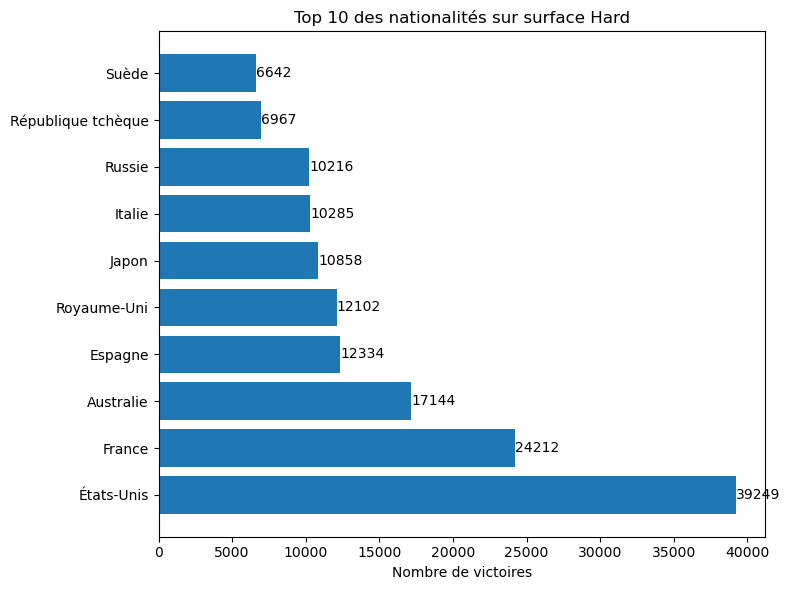

In [141]:
analyse_15 = analyse_all_epoque


# Traitement des données

    # On garde seulement les champs que l'on va traiter
analyse_15 = analyse_15[["id_atp_matches","tourney_id","surface","tourney_circuit","player_name","result_player_match","Pays"]]

    # On filtre sur les données pour garder seulement les lignes ou ce sont les gagnats des matchs
        # Aucun NA
analyse_15 = analyse_15[analyse_15["result_player_match"] == "Win"]

    # Créer colonne avec 1 par défaut pour effectuer une somme dessus et compter les matchs wins
analyse_15["count_win_match"] = 1

    # Group by pour rassembler les données autour du player name ET surface, somme du champ créé précédement
analyse_15 = analyse_15.groupby(["Pays", "surface"]).agg({"count_win_match":"sum"})
analyse_15 = analyse_15.reset_index()

    # Trie croissant ET récupération du top 10
        # Groupement par surface et tri par "count_win_match"
analyse_15_all_circuit_top10_by_surface = analyse_15.groupby('surface', group_keys=False).apply(lambda group: group.sort_values(by='count_win_match', ascending=False).head(10))

#print(analyse_15_all_circuit_top10_by_surface)

# Visualisation des données 

# Parcourir les surfaces uniques
for surface in analyse_15_all_circuit_top10_by_surface['surface'].unique():
    # Sélectionner les données pour la surface actuelle
    surface_data = analyse_15_all_circuit_top10_by_surface[analyse_15_all_circuit_top10_by_surface['surface'] == surface]

    # Créer un graphique bar pour la surface actuelle
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(surface_data['Pays'], surface_data['count_win_match'])
    ax.set_xlabel("Nombre de victoires")
    ax.set_title(f"Top 10 des nationalités sur surface {surface}")

    # Ajouter les étiquettes brutes des données
    for i, (player_name, count_win_match) in enumerate(zip(surface_data['Pays'], surface_data['count_win_match'])):
        ax.text(count_win_match + 5, i, f"{count_win_match}", va='center')

    
    plt.tight_layout()

# Afficher les graphiques
plt.show()

# Intégration du type de circuit ciblé - utile pour tableau public
analyse_15_all_circuit_top10_by_surface["circuit_cible"] = "all_circuit"

### 4.4.4.2. Top 10 : Nationalité qui ont le plus gagné sur chaque surface de tous les tournois ATP - depuis 1990

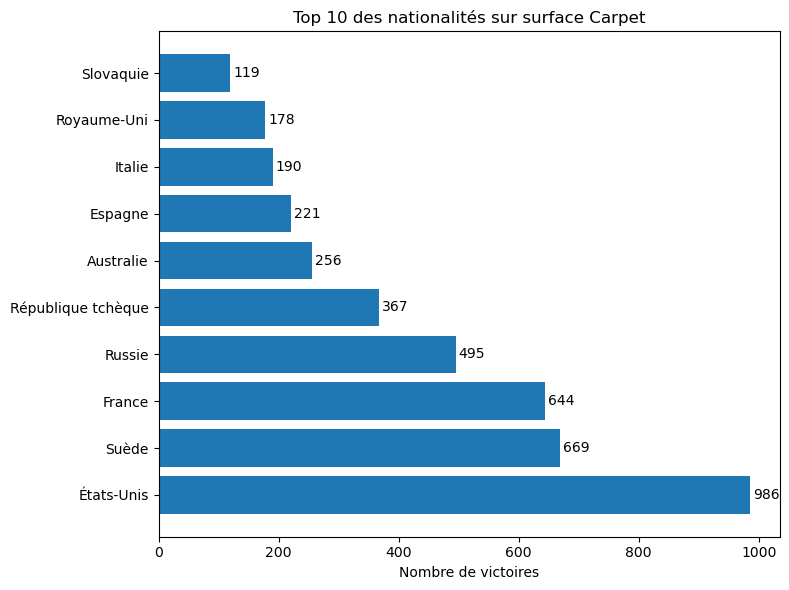

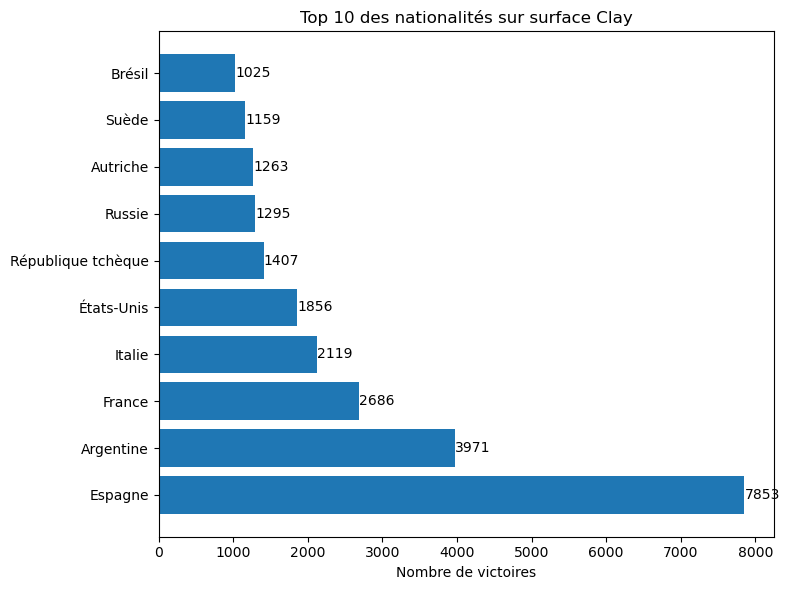

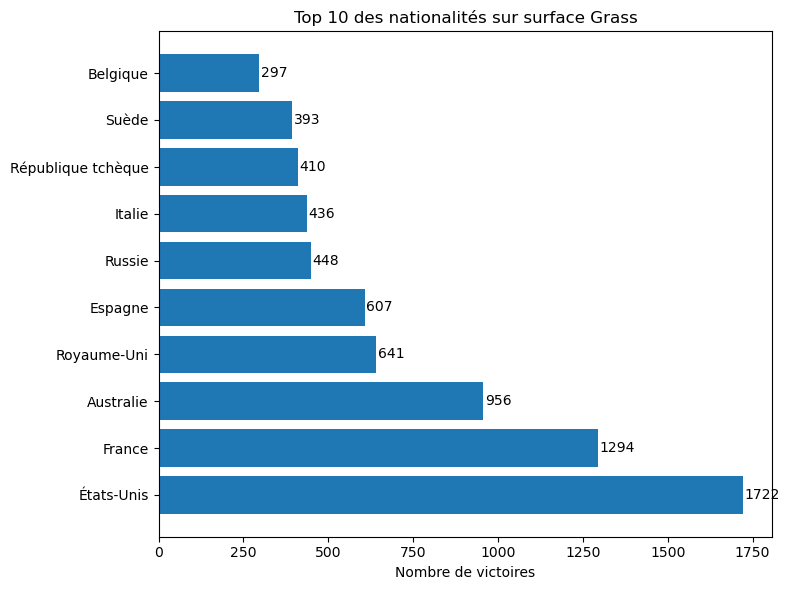

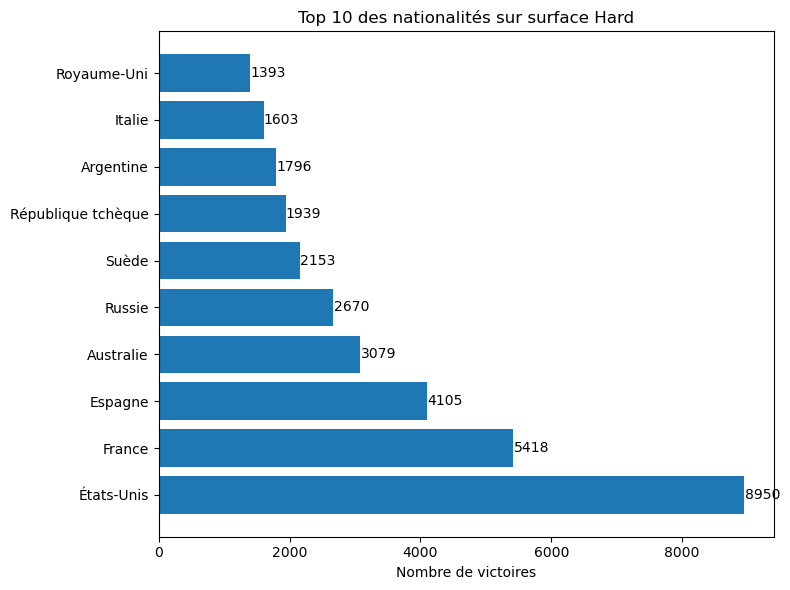

In [142]:
analyse_15_bis = analyse_all_epoque


# Traitement des données

    # On garde seulement les champs que l'on va traiter
analyse_15_bis = analyse_15_bis[["id_atp_matches","tourney_id","surface","tourney_circuit","player_name","result_player_match","Pays"]]

    # On filtre sur les données pour garder seulement les lignes ou ce sont les gagnats des matchs
        # Aucun NA
analyse_15_bis = analyse_15_bis[analyse_15_bis["result_player_match"] == "Win"]

    # On filtre sur les données pour garder seulement les matchs qui sont dans le circuit ATP
analyse_15_bis = analyse_15_bis[analyse_15_bis["tourney_circuit"] == "ATP"]


    # Créer colonne avec 1 par défaut pour effectuer une somme dessus et compter les matchs wins
analyse_15_bis["count_win_match"] = 1

    # Group by pour rassembler les données autour du player name ET surface, somme du champ créé précédement
analyse_15_bis = analyse_15_bis.groupby(["Pays", "surface"]).agg({"count_win_match":"sum"})
analyse_15_bis = analyse_15_bis.reset_index()

    # Trie croissant ET récupération du top 10
        # Groupement par surface et tri par "count_win_match"
analyse_15_atp_circuit_top10_by_surface = analyse_15_bis.groupby('surface', group_keys=False).apply(lambda group: group.sort_values(by='count_win_match', ascending=False).head(10))

#print(analyse_15_atp_circuit_top10_by_surface)

# Visualisation des données 

# Parcourir les surfaces uniques
for surface in analyse_15_atp_circuit_top10_by_surface['surface'].unique():
    # Sélectionner les données pour la surface actuelle
    surface_data = analyse_15_atp_circuit_top10_by_surface[analyse_15_atp_circuit_top10_by_surface['surface'] == surface]

    # Créer un graphique bar pour la surface actuelle
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(surface_data['Pays'], surface_data['count_win_match'])
    ax.set_xlabel("Nombre de victoires")
    ax.set_title(f"Top 10 des nationalités sur surface {surface}")

    # Ajouter les étiquettes brutes des données
    for i, (player_name, count_win_match) in enumerate(zip(surface_data['Pays'], surface_data['count_win_match'])):
        ax.text(count_win_match + 5, i, f"{count_win_match}", va='center')

    
    plt.tight_layout()

# Afficher les graphiques
plt.show()


# Intégration du type de circuit ciblé - utile pour tableau public
analyse_15_atp_circuit_top10_by_surface["circuit_cible"] = "atp"

In [143]:
# Concaténation pour les donénes du top 10 des natio par surface ayant gagné le plus de matchs sur les différentes surfaces  - utile pour tableau public
    # Rassemblement des données en un et même dataframe
    
df_top10_natio_win_match_per_surface_all_epoque = pd.concat([analyse_15_all_circuit_top10_by_surface, analyse_15_atp_circuit_top10_by_surface], axis=0)
df_top10_natio_win_match_per_surface_all_epoque = df_top10_natio_win_match_per_surface_all_epoque.reset_index()
df_top10_natio_win_match_per_surface_all_epoque =df_top10_natio_win_match_per_surface_all_epoque.drop(columns=['index'])

# Intégration du nom de l'analyse
df_top10_natio_win_match_per_surface_all_epoque["nom_analyse"] = "4.5.top10_nationalite_win_matchs_per_surface_all_circuit_circuit_atp_all_epoque." 

# Modification du naming contenant les valeurs de la proportion
df_top10_natio_win_match_per_surface_all_epoque = df_top10_natio_win_match_per_surface_all_epoque.rename(columns={"count_win_match": "valeurs"})

#print(df_top10_natio_win_match_per_surface_all_epoque)

# Export des données pour tableau public
#df_top10_natio_win_match_per_surface_all_epoque.to_excel(f"4.5.top10_nationalite_win_matchs_per_surface_all_circuit_circuit_atp_all_epoque.xlsx",  sheet_name='Sheet_name_1') 

### 4.4.4.1. Top 10 : Les tranches de tailles qui ont le plus gagné de tournoi - depuis 1990

In [144]:
def win_tourney_x_per_heigt(type_tournoi):

# Traitement global

    tournoi_win_height = analyse_all_epoque
    
    # Si type de tournoi ATP, on filtre sur les tournois ATP uniquement
    if (type_tournoi == "atp"):
        
        tournoi_win_height = tournoi_win_height[tournoi_win_height["tourney_circuit"] == "ATP"]
        #print("oui")
        
        # Récupération seulement des matchs ou c'est une finale
    tournoi_win_height = tournoi_win_height[tournoi_win_height["round"]=="F"]

        # Récupération des données seulement des gagnants dans les matchs
    tournoi_win_height = tournoi_win_height[tournoi_win_height["result_player_match"]=="Win"]

        # Création d'un champ intermédiaire pour faire la somme des tournois
    tournoi_win_height["tournoi_win"] = 1

    # A. Traitement pour récupérer la liste unique des 10 qui ont le plus gagnés de tournoi

        # Group pour rassembler le nombre de tournoi par joueur et par an
    tournoi_win_height_top_10_unique_player = tournoi_win_height.groupby(["player_id","player_name"]).agg({"tournoi_win":"sum"})
    tournoi_win_height_top_10_unique_player = tournoi_win_height_top_10_unique_player.reset_index()

        # Récupération du top 10 des joueurs qui ont le plus gagnés de tournoi
    tournoi_win_height_top_10_unique_player= tournoi_win_height_top_10_unique_player.sort_values(by='tournoi_win', ascending=False).head(10)

        # Récupération de manière unique des joueurs dans le top 10
    tournoi_win_height_top_10_unique_player = tournoi_win_height_top_10_unique_player["player_id"].unique()

    #print(tournoi_win_age_top_10_unique_player)

    # B. Récupération du nombre de tournois gagnés par age pour le top 10 des joueurs

        # Récupération de le jeu de données de base seulement des lignes des 10 top joueurs - pour les tournois ATP
    tournoi_win_height_top_10 = tournoi_win_height[tournoi_win_height['player_id'].isin(tournoi_win_height_top_10_unique_player)]

    #print(tournoi_win_age_top_10)

        # Création de la catégorie de taille des joueurs
    intervalles_height = [130,160, 170,180,190,220, np.inf]  
    categories_height = ["1m30 - 1m60", "1m60 - 1m70", "1m70 - 1m80", "1m80 - 1m90", "1m90 - 2m20", "Inconnu"]
    tournoi_win_height_top_10["height_categorie"] = pd.cut(tournoi_win_height_top_10["player_ht"], bins = intervalles_height, labels=categories_height,  include_lowest=True)

        # Group pour rassembler le nombre de tournoi par catégorie de taille, provenant des 10 meilleurs joueurs
    tournoi_win_height_top_10 = tournoi_win_height_top_10.groupby(["height_categorie"]).agg({"tournoi_win":"sum"})
    tournoi_win_height_top_10 = tournoi_win_height_top_10.reset_index()

    #print(tournoi_win_height_top_10)
    tournoi_win_height_top_10["circuit_cible"] = type_tournoi

    # ---- #

    # Visualisation sous la forme d'un graphique à barres


    # Créez un graphique à barres
    plt.figure(figsize=(10, 6))
    plt.bar(tournoi_win_height_top_10['height_categorie'], tournoi_win_height_top_10['tournoi_win'])

    # Titres et étiquettes des axes
    plt.title("Nombre de tournois gagnés par catégorie de taille")
    plt.xlabel("Catégorie de taille")
    plt.ylabel("Nombre de tournois gagnés")

    # Affichez les valeurs au-dessus des barres
    for i, value in enumerate(tournoi_win_height_top_10['tournoi_win']):
        plt.text(i, value, str(value), ha='center', va='bottom')

    # Rotation des étiquettes d'axe x pour une meilleure lisibilité
    plt.xticks(rotation=45)

    # Affichez le graphique
    plt.tight_layout()
    plt.show()
    
    return(tournoi_win_height_top_10)

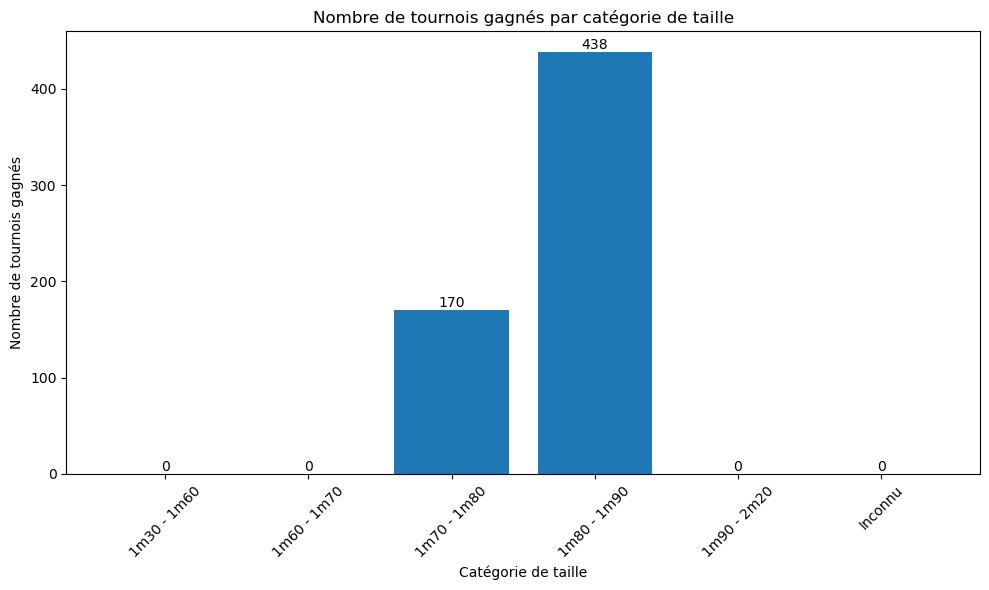

In [145]:
win_tourney_x_per_height_all_circuit_all_epoque = win_tourney_x_per_heigt("all_circuit")

### 4.4.4.2. Top 10 : Les tranches de tailles qui ont le plus gagné de tournoi ATP - depuis 1990

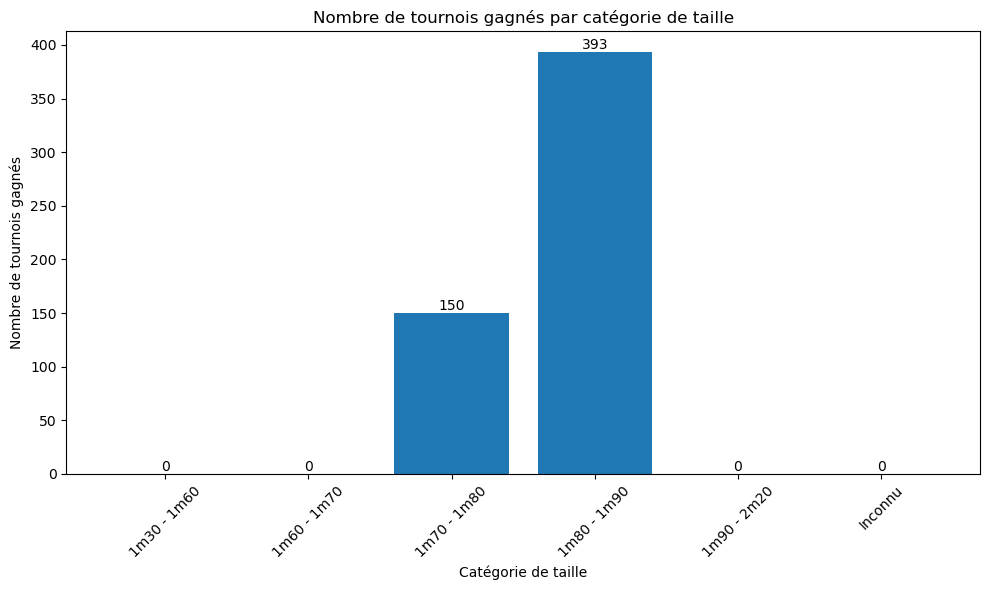

In [146]:
win_tourney_x_per_height_atp_circuit_all_epoque = win_tourney_x_per_heigt("atp")

In [147]:
# Concaténation pour les donénes des catéogories de taille ayant gangés le plus de tournois  - utile pour tableau public
    # Rassemblement des données en un et même dataframe
    
df_win_tourney_height_all_epoque = pd.concat([win_tourney_x_per_height_all_circuit_all_epoque, win_tourney_x_per_height_atp_circuit_all_epoque], axis=0)
df_win_tourney_height_all_epoque = df_win_tourney_height_all_epoque.reset_index()
df_win_tourney_height_all_epoque =df_win_tourney_height_all_epoque.drop(columns=['index'])

# Intégration du nom de l'analyse
df_win_tourney_height_all_epoque["nom_analyse"] = "4.6.categ_height_win_tourney_all_circuit_atp_circuit_all_epoque" 

# Modification du naming contenant les valeurs de la proportion
df_win_tourney_height_all_epoque = df_win_tourney_height_all_epoque.rename(columns={"tournoi_win": "valeurs"})

#print(df_win_tourney_height_all_epoque)

# Export des données pour tableau public
#df_win_tourney_height_all_epoque.to_excel(f"4.6.categ_height_win_tourney_all_circuit_atp_circuit_all_epoque.xlsx",  sheet_name='Sheet_name_1') 

### 4.4.4.3. Les 3 Joueurs par tranches de tailles qui ont le plus gagné de tournoi - depuis 1990

In [148]:
def top_3_win_tourney_x_per_heigt(type_tournoi):

# Traitement global

    tournoi_win_per_height = analyse_all_epoque
    
    # Si type de tournoi ATP, on filtre sur les tournois ATP uniquement
    if (type_tournoi == "atp"):
        
        tournoi_win_per_height = tournoi_win_per_height[tournoi_win_per_height["tourney_circuit"] == "ATP"]
        #print("oui")

        # Filtre pour récupérer seulement les finales
    tournoi_win_per_height = tournoi_win_per_height[tournoi_win_per_height["round"]=="F"]

        # Filtre pour récupérer seulement ceux qui les ont gagnés
    tournoi_win_per_height = tournoi_win_per_height[tournoi_win_per_height["result_player_match"]=="Win"]


        # Création de la catégorie d'age
    intervalles_height = [130,160, 170,180,190,220, np.inf]  
    categories_height = ["1m30 - 1m60", "1m60 - 1m70", "1m70 - 1m80", "1m80 - 1m90", "1m90 - 2m20", "Inconnu"]
    tournoi_win_per_height["height_categorie"] = pd.cut(tournoi_win_per_height["player_ht"], bins = intervalles_height, labels=categories_height,  include_lowest=True)    

        # Création du champ intermédiaire pour sommer le nombre de tournoi gagné
    tournoi_win_per_height["tournoi_win"] = 1

        # Group by pour rassembler les données par joueur ET catégorie de taille
    tournoi_win_per_height = tournoi_win_per_height.groupby(["player_id","player_name"]).agg({"tournoi_win":"sum",  "height_categorie":"first"})
    tournoi_win_per_height = tournoi_win_per_height.reset_index()

        # Récupération du top 3 des joueurs par catégorie de taille

    categories_height_unique = tournoi_win_per_height["height_categorie"].unique()

        # Création d'un dataframe pour stocker les top joueurs par catégorie
    df_top_3_per_height = pd.DataFrame(columns=['player_id','player_name', 'height_categorie', 'tournoi_win'])

    # Boucle pour obtenir la proportion par époque 
    for height_categ in categories_height_unique:

        # Récupération des données de la catégorie de taille pour l'analyse
        top_categ_height = tournoi_win_per_height[tournoi_win_per_height["height_categorie"] == height_categ]

        # Récupération du top 3 des joueurs pour la catégorie de taille itérée
        top_categ_height= top_categ_height.sort_values(by='tournoi_win', ascending=False).head(3)
        #print(top_categ_height)

        # Intégration des données dans le dataframe pour ajouter les top 3 des joueurs par catégorie de taille
        df_top_3_per_height = pd.concat([df_top_3_per_height, top_categ_height])

    # Réinitialisez les index du DataFrame résultant
    df_top_3_per_height = df_top_3_per_height.reset_index(drop=True)

    #print(df_top_3_per_height)
    
    df_top_3_per_height["circuit_cible"] = type_tournoi

 #   print(df_top_3_per_height)

    # --- #

    # Visualisation sous forme de graphique à barres

    # Conversion de la colonne 'tournoi_win' en type int
    df_top_3_per_height["tournoi_win"] = df_top_3_per_height["tournoi_win"].astype(int)

    # Créez une figure et des sous-plots
    fig, ax = plt.subplots(figsize=(10, 6))

    # Groupement des données par catégorie de taille
    categories_height = df_top_3_per_height["height_categorie"].unique()

    for category in categories_height:

        top_players = df_top_3_per_height[df_top_3_per_height["height_categorie"] == category].nlargest(3, "tournoi_win")
        x = top_players["player_name"]
        y = top_players["tournoi_win"]
        bars = ax.bar(x, y, label=category)

        # Ajout des étiquettes de données au-dessus des barres
        ax.bar_label(bars)

    # Configurez les détails du graphique
    ax.set_xlabel("Joueurs")
    ax.set_ylabel("Nombre de tournois gagnés")
    ax.set_title("Top 3 des joueurs par catégorie de taille avec le plus de tournois gagnés")
    ax.legend()
    plt.xticks(rotation=45, ha="right")  # Rotation des étiquettes pour une meilleure lisibilité

    # Affichez le graphique
    plt.tight_layout()
    plt.show()
    
    return(df_top_3_per_height)

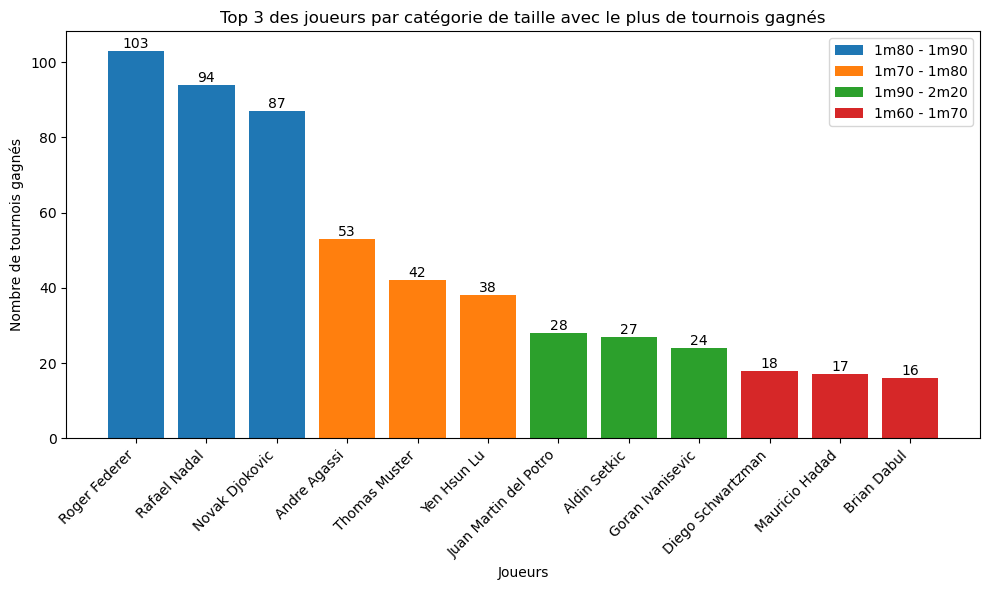

In [149]:
# Appel de fonction
top_3_player_win_tourney_x_per_height_all_circuit_all_epoque = top_3_win_tourney_x_per_heigt("all_circuit")

### 4.4.4.4. Les 3 Joueurs par tranches de tailles qui ont le plus gagné de tournoi ATP - depuis 1990

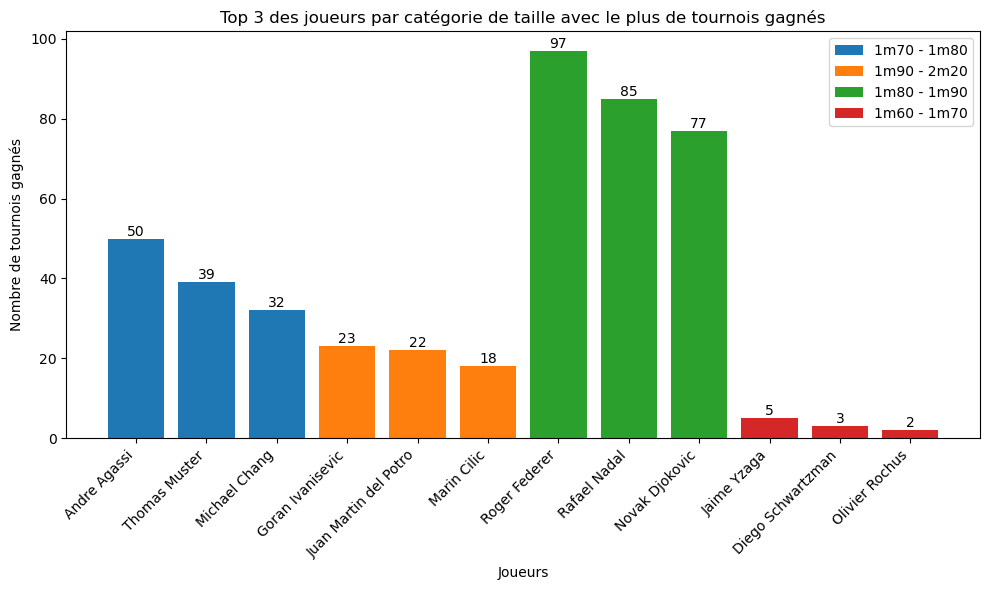

In [150]:
# Appel de fonction
top_3_player_win_tourney_x_per_height_atp_circuit_all_epoque  = top_3_win_tourney_x_per_heigt("atp")

In [151]:
# Concaténation pour les donénes des top 3 des joueurs par catéogories de taille ayant gangés le plus de tournois  - utile pour tableau public
    # Rassemblement des données en un et même dataframe
    
df_top_3_player_win_tourney_per_height_all_epoque = pd.concat([top_3_player_win_tourney_x_per_height_all_circuit_all_epoque, top_3_player_win_tourney_x_per_height_atp_circuit_all_epoque], axis=0)
df_top_3_player_win_tourney_per_height_all_epoque = df_top_3_player_win_tourney_per_height_all_epoque.reset_index()
df_top_3_player_win_tourney_per_height_all_epoque =df_top_3_player_win_tourney_per_height_all_epoque.drop(columns=['index'])

# Intégration du nom de l'analyse
df_top_3_player_win_tourney_per_height_all_epoque["nom_analyse"] = "4.7.top3_player_per_categ_height_win_tourney_all_circuit_atp_circuit_all_epoque" 

# Modification du naming contenant les valeurs de la proportion
df_top_3_player_win_tourney_per_height_all_epoque = df_top_3_player_win_tourney_per_height_all_epoque.rename(columns={"tournoi_win": "valeurs"})

# Suppression de la colonne inutile 
df_top_3_player_win_tourney_per_height_all_epoque =df_top_3_player_win_tourney_per_height_all_epoque.drop(columns=['player_id'])

print(df_top_3_player_win_tourney_per_height_all_epoque)

# Export des données pour tableau public
#df_top_3_player_win_tourney_per_height_all_epoque.to_excel(f"4.7.top3_player_per_categ_height_win_tourney_all_circuit_atp_circuit_all_epoque.xlsx",  sheet_name='Sheet_name_1') 

              player_name height_categorie  valeurs circuit_cible  \
0           Roger Federer      1m80 - 1m90      103   all_circuit   
1            Rafael Nadal      1m80 - 1m90       94   all_circuit   
2          Novak Djokovic      1m80 - 1m90       87   all_circuit   
3            Andre Agassi      1m70 - 1m80       53   all_circuit   
4           Thomas Muster      1m70 - 1m80       42   all_circuit   
5             Yen Hsun Lu      1m70 - 1m80       38   all_circuit   
6   Juan Martin del Potro      1m90 - 2m20       28   all_circuit   
7            Aldin Setkic      1m90 - 2m20       27   all_circuit   
8        Goran Ivanisevic      1m90 - 2m20       24   all_circuit   
9       Diego Schwartzman      1m60 - 1m70       18   all_circuit   
10         Mauricio Hadad      1m60 - 1m70       17   all_circuit   
11            Brian Dabul      1m60 - 1m70       16   all_circuit   
12           Andre Agassi      1m70 - 1m80       50           atp   
13          Thomas Muster      1m7

### Concaténation des données de la thématique 4 pour l'utilisation sur Tableau Public, et obtenir des filtres communs sur le dashboard


In [152]:
# Concaténation des deux jeux de données, pour pouvoir ensuite les exporter et les traiter sur tableau
tableau_thematique_4 = pd.concat([df_top_10_player_win_tournoi_x_year_all_epoque, df_top_10_player_win_tournoi_per_age_all_epoque,df_top10_win_per_surface_all_epoque,df_top10_natio_win_match_all_epoque,df_top10_natio_win_match_per_surface_all_epoque,df_win_tourney_height_all_epoque,df_top_3_player_win_tourney_per_height_all_epoque], axis=0)

# Indication "no_data" sur les valeurs NULL
#tableau_thematique_4 = tableau_thematique_4.fillna("no_data")


#print(tableau_thematique_4)

# Export des données
tableau_thematique_4.to_excel("thematique_4_data.xlsx",  sheet_name='Sheet_name_1') 

## 4.5 Thématique 5 : Les meilleurs joueurs et les caractéristiques identitaire et physiques ET les statistiques - Circuit ATP par défaut - de 90 à 2019

In [153]:
analyse_all_epoque_atp = analyse_all_epoque

# Filtre pour récupérer seulement les matchs sur le circuit ATP
analyse_all_epoque_atp = analyse_all_epoque_atp[analyse_all_epoque_atp["tourney_circuit"] == "ATP"]

# Problème spécifique à certains joueurs avec un caractère spécial sur certaines données et pas d'autres (comme "Edouard Roger-Vasselin" OU "Edouard Roger Vaselin")
analyse_all_epoque_atp["player_name"] = analyse_all_epoque_atp["player_name"].str.replace('-',' ')


# Filtre pour récupérer seulement les matchs allant de 90 à 2019
analyse_all_epoque_atp = analyse_all_epoque_atp[analyse_all_epoque_atp["epoque"].notnull()]


### 4.5.1. Top 10 : Joueurs qui ont fait les meilleurs wins rate (au moins 15 matchs dans une saison sur le cirtcuit ATP) - sur une saison

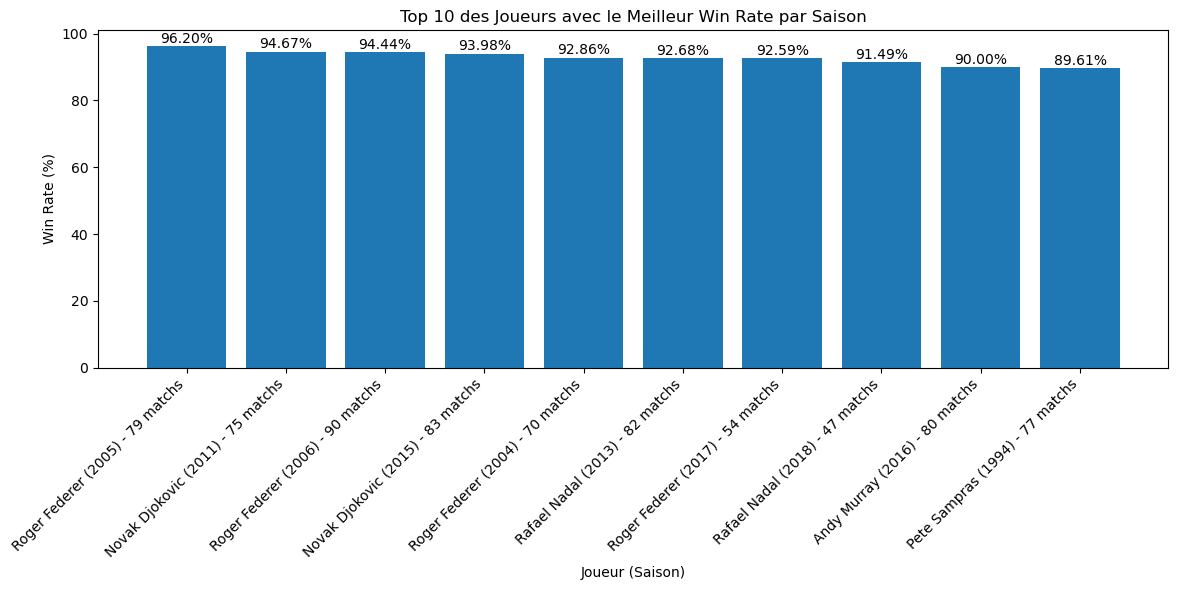

In [154]:
top_10_winrate = analyse_all_epoque_atp

# A. Traitement récupération du nombre de match gagné par année

    # Filtre pour garder seulement les victoires
top_10_winrate_nb_win = top_10_winrate[top_10_winrate["result_player_match"]=="Win"]

    # Intégration d'un champ intermédiaire pour sommer
top_10_winrate_nb_win["match_win"] = 1
  
    # Group pour rassembler les données autour des joueurs et des années
top_10_winrate_nb_win = top_10_winrate_nb_win.groupby(["player_id","player_name", "year"]).agg({"match_win":"sum"})
top_10_winrate_nb_win = top_10_winrate_nb_win.reset_index()

# B. Traitement récupération du nombre de match au total par année

top_10_winrate_nb_all = top_10_winrate

    # Intégration d'un champ intermédiaire pour sommer
top_10_winrate_nb_all["all_match"] = 1

    # Group pour rassembler les données autour des joueurs et des années
top_10_winrate_nb_all = top_10_winrate_nb_all.groupby(["player_id","player_name", "year"]).agg({"all_match":"sum"})
top_10_winrate_nb_all = top_10_winrate_nb_all.reset_index()

# C. Calcul du win rate par année

    # Jointure pour rassembler les données matchs totales ET matchs win

top_10_winrate_nb_all_nb_win = top_10_winrate_nb_all.merge(
        top_10_winrate_nb_win[["player_id", "year", "match_win"]],
        left_on= ["player_id","year"],  # Colonne de la première table
        right_on=["player_id","year"],  # Colonne de la seconde table
        how="left"
)

    # Remplacer les NULL par des 0, ceux qui n'ont gagnés aucun match qui sont en NULL
top_10_winrate_nb_all_nb_win = top_10_winrate_nb_all_nb_win.fillna(0)
     
    # Calcul du win rate
top_10_winrate_nb_all_nb_win["win_rate"] = round((top_10_winrate_nb_all_nb_win["match_win"] / top_10_winrate_nb_all_nb_win["all_match"]) * 100,2)

#print(top_10_winrate_nb_all_nb_win)

# D. Détection des meilleurs win rate pour les 10 joueurs (garder joueur + saison)

    # Filtrer sur les saisons a au moins plus de 15 matchs sur le circuit ATP - Sinon on se tape ceux qui ont fait quelques matchs, faussant les win rate des réels joueurs à importants du circuit atp
top_10_winrate_nb_all_nb_win = top_10_winrate_nb_all_nb_win[top_10_winrate_nb_all_nb_win["all_match"] > 15]
    
    # Top 10
top_10_winrate_nb_all_nb_win= top_10_winrate_nb_all_nb_win.sort_values(by='win_rate', ascending=False).head(10)  


# --- #

# Visualisation sous forme de graphique à barre 

# Créer un graphique à barres
plt.figure(figsize=(12, 6))
plt.bar(top_10_winrate_nb_all_nb_win["player_name"] + " (" + top_10_winrate_nb_all_nb_win["year"].astype(str) + ") - " + top_10_winrate_nb_all_nb_win["all_match"].astype(str) + " matchs", top_10_winrate_nb_all_nb_win["win_rate"])
plt.xlabel("Joueur (Saison)")
plt.ylabel("Win Rate (%)")
plt.title("Top 10 des Joueurs avec le Meilleur Win Rate par Saison")
plt.xticks(rotation=45, ha="right")

# Ajouter les étiquettes de données au-dessus des barres
for i, win_rate in enumerate(top_10_winrate_nb_all_nb_win["win_rate"]):
    plt.text(i, win_rate + 1, f"{win_rate:.2f}%", ha="center")

# Afficher le graphique
plt.tight_layout()
plt.show()

# Intégration du nom de l'analyse
top_10_winrate_nb_all_nb_win["nom_analyse"] = "5.1.top10_player_win_rate_in_1_season_atp_circuit_all_epoque.xlsx" 

# Modification du naming contenant les valeurs de la proportion
top_10_winrate_nb_all_nb_win = top_10_winrate_nb_all_nb_win.rename(columns={"win_rate": "valeurs"})

# Suppression de la colonne inutile 
top_10_winrate_nb_all_nb_win =top_10_winrate_nb_all_nb_win.drop(columns=['player_id', "match_win"])

#print(top_10_winrate_nb_all_nb_win)

# export des données - utile pour Tableau public
#top_10_winrate_nb_all_nb_win.to_excel(f"5.1.top10_player_win_rate_in_1_season_atp_circuit_all_epoque.xlsx",  sheet_name='Sheet_name_1') 

### 4.5.2.1. Top 10 : Joueurs qui ont fait le ratio le plus élevé de finales gagnées (au moins 10 finales jouées) - depuis 1990

In [155]:
def win_loose_rate_final (win_loose, top_flop):

    top_10_winrate_final = analyse_all_epoque_atp


    # A. Traitement récupération du nombre de final gagné

            # Filtre pour récupérer seulement les finales
    top_10_winrate_nb_win_final = top_10_winrate_final[top_10_winrate_final["round"]=="F"]

        # Filtre pour garder seulement les victoires
    top_10_winrate_nb_win_final = top_10_winrate_nb_win_final[top_10_winrate_nb_win_final["result_player_match"]==win_loose]

        # Intégration d'un champ intermédiaire pour sommer
    top_10_winrate_nb_win_final["match_win"] = 1

        # Group pour rassembler les données autour des joueurs et des années
    top_10_winrate_nb_win_final = top_10_winrate_nb_win_final.groupby(["player_id","player_name"]).agg({"match_win":"sum"})
    top_10_winrate_nb_win_final = top_10_winrate_nb_win_final.reset_index()

    # B. Traitement récupération du nombre de final au total joué

    top_10_winrate_finale_nb_all = top_10_winrate_final

            # Filtre pour récupérer seulement les finales
    top_10_winrate_finale_nb_all = top_10_winrate_finale_nb_all[top_10_winrate_finale_nb_all["round"]=="F"]

        # Intégration d'un champ intermédiaire pour sommer
    top_10_winrate_finale_nb_all["all_match"] = 1

        # Group pour rassembler les données autour des joueurs et des années
    top_10_winrate_finale_nb_all = top_10_winrate_finale_nb_all.groupby(["player_id","player_name"]).agg({"all_match":"sum"})
    top_10_winrate_finale_nb_all = top_10_winrate_finale_nb_all.reset_index()

    # C. Calcul du win rate par année

        # Jointure pour rassembler les données matchs totales ET matchs win

    top_10_winrate_finale_nb_all_win = top_10_winrate_finale_nb_all.merge(
            top_10_winrate_nb_win_final[["player_id", "match_win"]],
            left_on= ["player_id"],  # Colonne de la première table
            right_on=["player_id"],  # Colonne de la seconde table
            how="left"
    )

        # Remplacer les NULL par des 0, ceux qui n'ont gagnés aucun match qui sont en NULL
    top_10_winrate_finale_nb_all_win = top_10_winrate_finale_nb_all_win.fillna(0)

        # Calcul du win rate
    top_10_winrate_finale_nb_all_win["win_rate"] = round((top_10_winrate_finale_nb_all_win["match_win"] / top_10_winrate_finale_nb_all_win["all_match"]) * 100,2)

    # D. Détection des meilleurs win rate pour les 10 joueurs (garder joueur)

        # Filtrer pour garder seulement les joueurs qui ont au moins effectué 10 finales dans le circuit ATP
    top_10_winrate_finale_nb_all_win = top_10_winrate_finale_nb_all_win[top_10_winrate_finale_nb_all_win["all_match"] >=  10]

        # Top 10
    top_10_winrate_finale_nb_all_win= top_10_winrate_finale_nb_all_win.sort_values(by='win_rate', ascending=False).head(10)  

    #print(top_10_winrate_finale_nb_all_win)

    # --- #

    # Visualisation sous forme de graphique à barre 

    # Créer un graphique à barres
    plt.figure(figsize=(12, 6))
    plt.bar(top_10_winrate_finale_nb_all_win["player_name"], top_10_winrate_finale_nb_all_win["win_rate"])
    plt.xlabel("Joueurs")
    plt.ylabel(f"{win_loose} Rate Final (%)")
    plt.title(f"{top_flop} 10 des Joueurs dans les finales sur le circuit ATP")
    plt.xticks(rotation=45, ha="right")

    # Ajouter les étiquettes de données au-dessus des barres
    for i, win_rate in enumerate(top_10_winrate_finale_nb_all_win["win_rate"]):
        plt.text(i, win_rate + 1, f"{win_rate:.2f}%", ha="center")

    # Afficher le graphique
    plt.tight_layout()
    plt.show()

    # Intégration de la distinction des données de win rate OU loose rate
    top_10_winrate_finale_nb_all_win["win_or_loose_data"] = win_loose
    
    # Intégration du nom de l'analyse
    top_10_winrate_finale_nb_all_win["nom_analyse"] = "5.2.top10_player_win_loose_rate_final_atp_circuit_all_epoque" 

    # Modification du naming contenant les valeurs de la proportion
    top_10_winrate_finale_nb_all_win = top_10_winrate_finale_nb_all_win.rename(columns={"win_rate": "valeurs"})

    # Suppression de la colonne inutile 
    top_10_winrate_finale_nb_all_win =top_10_winrate_finale_nb_all_win.drop(columns=['player_id', "all_match", "match_win"])
    
    #print(top_10_winrate_finale_nb_all_win)
    
    return(top_10_winrate_finale_nb_all_win)

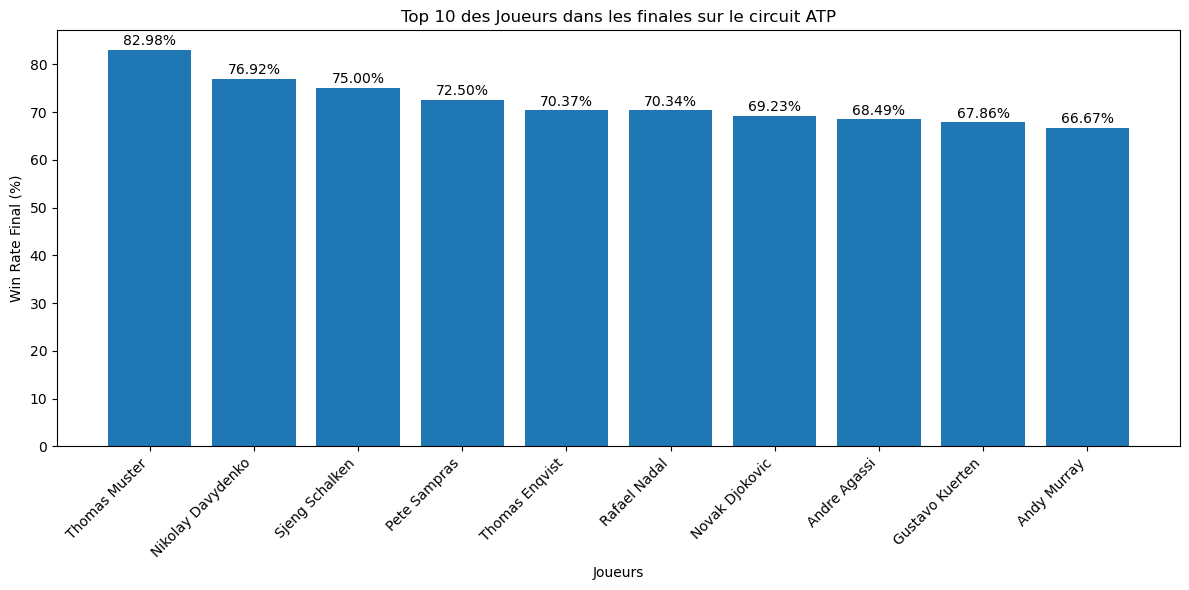

In [156]:
win_rate_final = win_loose_rate_final ("Win", "Top")

### 4.5.2.2. Top 10 : Joueurs qui ont fait le ratio le plus élevé de finales perdues (au moins 10 finales jouées) - depuis 1990

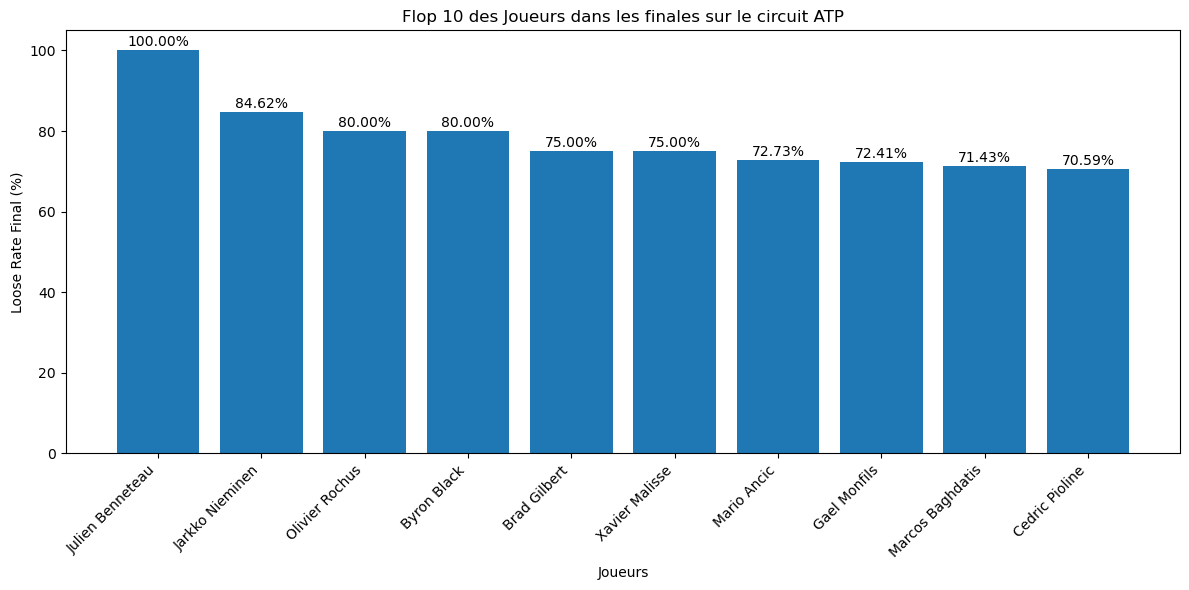

In [157]:
loose_rate_final = win_loose_rate_final ("Loose", "Flop")

In [158]:
# Concaténation pour les donénes des top 10 des joueurs ayant les meilleurs win rate en final et ceux qui en ont le moins - utile pour tableau public
    # Rassemblement des données en un et même dataframe
    
df_top_10_win_loose_rate_final = pd.concat([win_rate_final, loose_rate_final], axis=0)
df_top_10_win_loose_rate_final = df_top_10_win_loose_rate_final.reset_index()
df_top_10_win_loose_rate_final =df_top_10_win_loose_rate_final.drop(columns=['index'])

#print(df_top_10_win_loose_rate_final)

# Export des données pour tableau public
#df_top_10_win_loose_rate_final.to_excel(f"5.2.top10_player_win_loose_rate_final_atp_circuit_all_epoque.xlsx",  sheet_name='Sheet_name_1') 

### 4.5.3.1. Top 10 : Joueurs qui sont les plus endurants (plus de minutes jouées en moyenne) - Ceux qui ont au moins 15 matchs ATP dans leur carrière - BO3 - depuis 1990

In [159]:
def top_10_endurance(bo):

    top_10_endurance = analyse_all_epoque_atp

        # A. Traitement pour récupérer seulement les joueurs avec au moins 15 matchs ATP dans leur carrière pour le BO en question

    joueurs_15_matchs_atp = top_10_endurance

            # Filtre sur les matchs en BOx
    joueurs_15_matchs_atp = joueurs_15_matchs_atp[joueurs_15_matchs_atp["best_of"] == bo]
        
            # Intégration d'un champ intermédiaire pour sommer
    joueurs_15_matchs_atp["all_match"] = 1

            # Group By pour rassembler les donénes autour des joueurs et avoir le nombre de matchs jouées sur leur carrière dans le circuit ATP
    joueurs_15_matchs_atp = joueurs_15_matchs_atp.groupby(["player_id","player_name"]).agg({"all_match":"sum"})
    joueurs_15_matchs_atp = joueurs_15_matchs_atp.reset_index()

            # Filtre pour écarter tous les joueurs qui n'ont pas au moins 15 matchs sur le circuit ATP dans leur carrière
    joueurs_15_matchs_atp = joueurs_15_matchs_atp[joueurs_15_matchs_atp["all_match"] >= 15]

        # B. Traitement récupération du nombre de minutes jouées en moyenne par match + top 10

            # Filtre pour récupérer dans le fichier d'origine, seulement les joueurs qui ont fait au moins 15 matchs sur le circuit ATP dans leur carrière 
    top_10_endurance = top_10_endurance[top_10_endurance['player_name'].isin(joueurs_15_matchs_atp['player_name'])]

            # Filtre pour récupérer seulement les matchs en BOx
    top_10_endurance = top_10_endurance[top_10_endurance["best_of"] == bo]

            # Group pour rassembler les données autour des joueurs et des années
    top_10_endurance = top_10_endurance.groupby(["player_id","player_name"]).agg({"minutes":"mean"})
    top_10_endurance = top_10_endurance.reset_index()

            # Top 10
    top_10_endurance= top_10_endurance.sort_values(by='minutes', ascending=False).head(10)  

    #print(top_10_endurance)
    
    # --- #

    # Visualisation sous forme de graphique à barre 

    # Créer un graphique à barres
    plt.figure(figsize=(12, 6))
    plt.bar(top_10_endurance["player_name"], top_10_endurance["minutes"])
    plt.xlabel("Joueurs")
    plt.ylabel("Nombre de minutes")
    plt.title(f"Top 10 des Joueurs les plus endurants dans les match BO{bo} du circuit ATP (au moins 15 matchs dans leur carrière)")
    plt.xticks(rotation=45, ha="right")

    # Ajouter les étiquettes de données au-dessus des barres
    for i, minutes in enumerate(top_10_endurance["minutes"]):
        plt.text(i, minutes + 1, f"{minutes:.2f} min", ha="center")

    # Afficher le graphique
    plt.tight_layout()
    plt.show()
    
    # Intégration type de bo - utile pour tableau public 
    top_10_endurance["bo"] = bo
    
        # Intégration du nom de l'analyse
    top_10_endurance["nom_analyse"] = "5.3.top10_player_endurance_min_mean_bo3_bo5_atp_circuit_all_epoque" 

    # Modification du naming contenant les valeurs de la proportion
    top_10_endurance = top_10_endurance.rename(columns={"minutes": "valeurs"})

    # Suppression de la colonne inutile 
    top_10_endurance =top_10_endurance.drop(columns=['player_id'])

    #print(top_10_endurance)
    
    return(top_10_endurance)

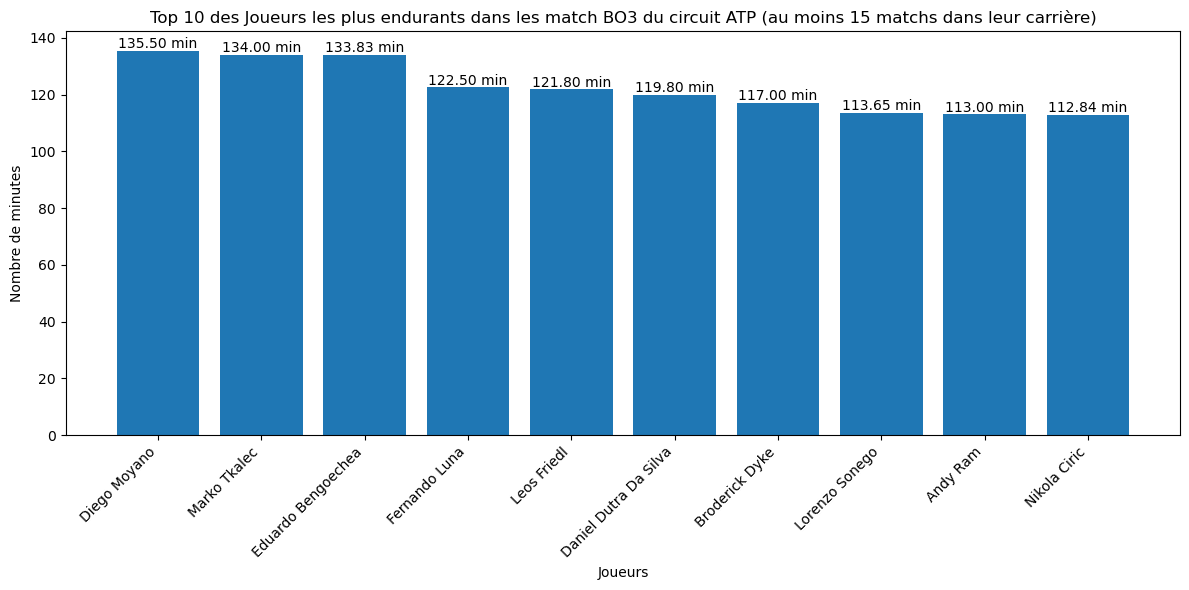

In [160]:
# Appel de fonction
top_10_endurance_bo3 = top_10_endurance(3)

### 4.5.3.2. Top 10 : Joueurs qui sont les plus endurants (plus de minutes jouées en moyenne) - Ceux qui ont au moins 15 matchs ATP dans leur carrière - BO5 - depuis 1990

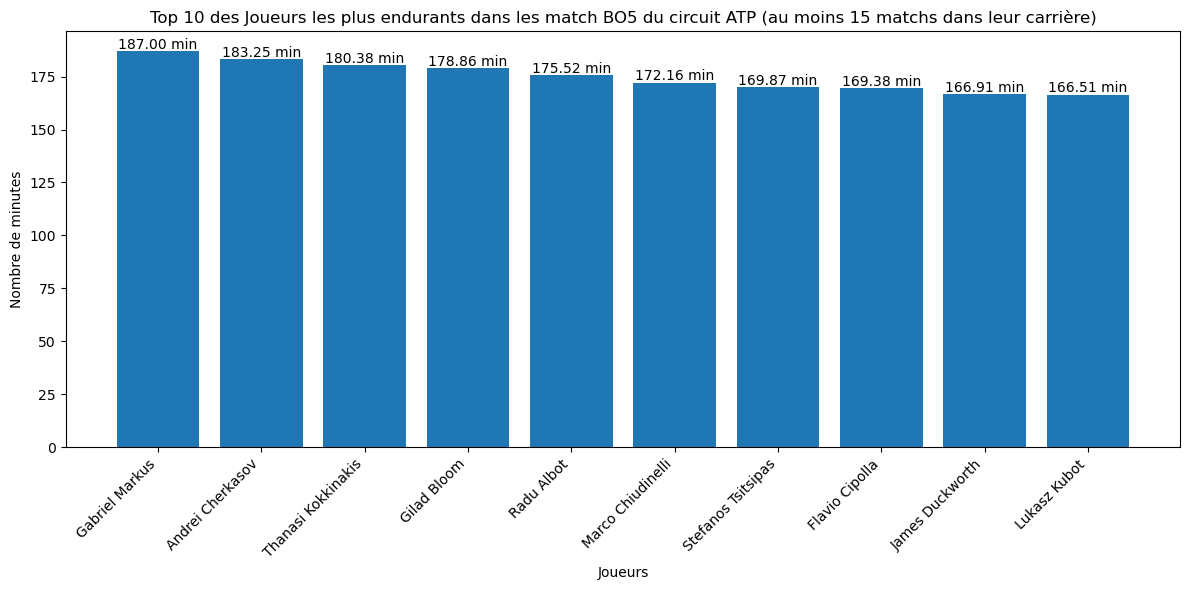

In [161]:
# Appel de fonction
top_10_endurance_bo5 = top_10_endurance(5)

In [162]:
# Concaténation pour les donénes des top 10 des joueurs ayant les moyennes de minutes les plus elevés en match bo3 / bo5 - utile pour tableau public
    # Rassemblement des données en un et même dataframe
    
df_top_10_endurance_bo3_bo5 = pd.concat([top_10_endurance_bo3, top_10_endurance_bo5], axis=0)
df_top_10_endurance_bo3_bo5 = df_top_10_endurance_bo3_bo5.reset_index()
df_top_10_endurance_bo3_bo5 =df_top_10_endurance_bo3_bo5.drop(columns=['index'])

print(df_top_10_endurance_bo3_bo5)

# Export des données pour tableau public
#df_top_10_endurance_bo3_bo5.to_excel(f"5.3.top10_player_endurance_min_mean_bo3_bo5_atp_circuit_all_epoque.xlsx",  sheet_name='Sheet_name_1') 

              player_name     valeurs  bo  \
0            Diego Moyano  135.500000   3   
1            Marko Tkalec  134.000000   3   
2      Eduardo Bengoechea  133.833333   3   
3           Fernando Luna  122.500000   3   
4             Leos Friedl  121.800000   3   
5   Daniel Dutra Da Silva  119.800000   3   
6          Broderick Dyke  117.000000   3   
7          Lorenzo Sonego  113.650000   3   
8                Andy Ram  113.000000   3   
9            Nikola Ciric  112.842105   3   
10         Gabriel Markus  187.000000   5   
11       Andrei Cherkasov  183.250000   5   
12     Thanasi Kokkinakis  180.384615   5   
13            Gilad Bloom  178.857143   5   
14             Radu Albot  175.520000   5   
15      Marco Chiudinelli  172.157895   5   
16     Stefanos Tsitsipas  169.869565   5   
17         Flavio Cipolla  169.380952   5   
18        James Duckworth  166.913043   5   
19           Lukasz Kubot  166.512195   5   

                                          nom_analyse 

### 4.5.4. Top 10 : Joueurs qui ont les carrières les plus longues dans l'élite (plus de matchs dans l'élite) - depuis 1990

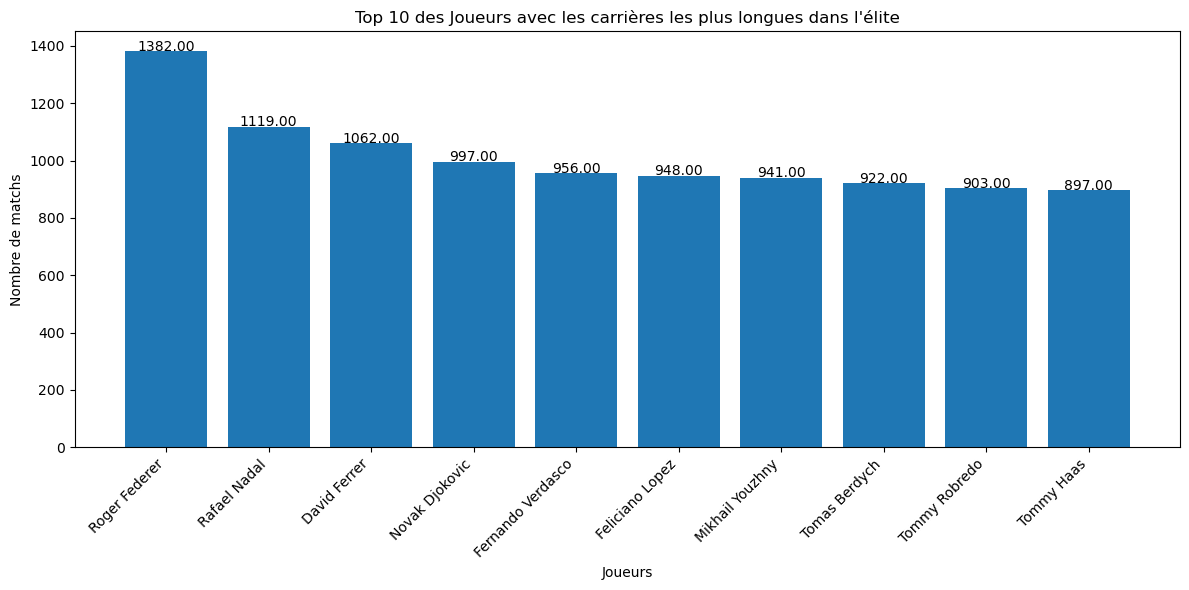

In [163]:
top_10_longevite_elite = analyse_all_epoque_atp

    # A. Traitement récupération du nombre de matchs + top 10 de ceux qui en ont le plus

top_10_longevite_elite["all_match"] = 1
    
        # Group pour rassembler les données autour des joueurs et des années
top_10_longevite_elite = top_10_longevite_elite.groupby(["player_id","player_name"]).agg({"all_match":"sum"})
top_10_longevite_elite = top_10_longevite_elite.reset_index()

        # Top 10
top_10_longevite_elite= top_10_longevite_elite.sort_values(by='all_match', ascending=False).head(10)  

#print(top_10_endurance)
    
    # --- #

# Visualisation sous forme de graphique à barre 

    # Créer un graphique à barres
plt.figure(figsize=(12, 6))
plt.bar(top_10_longevite_elite["player_name"], top_10_longevite_elite["all_match"])
plt.xlabel("Joueurs")
plt.ylabel("Nombre de matchs")
plt.title(f"Top 10 des Joueurs avec les carrières les plus longues dans l'élite")
plt.xticks(rotation=45, ha="right")

# Ajouter les étiquettes de données au-dessus des barres
for i, all_match in enumerate(top_10_longevite_elite["all_match"]):
    plt.text(i, all_match + 1, f"{all_match:.2f}", ha="center")

# Afficher le graphique
plt.tight_layout()
plt.show()

# Intégration du nom de l'analyse
top_10_longevite_elite["nom_analyse"] = "5.4.top10_player_longevite_elite_atp_circuit_all_epoque" 

# Modification du naming contenant les valeurs de la proportion
top_10_longevite_elite = top_10_longevite_elite.rename(columns={"all_match": "valeurs"})

# Suppression de la colonne inutile 
top_10_longevite_elite =top_10_longevite_elite.drop(columns=['player_id'])

#print(top_10_longevite_elite)

# Export des données pour tableau public
#top_10_longevite_elite.to_excel(f"5.4.top10_player_longevite_elite_atp_circuit_all_epoque.xlsx",  sheet_name='Sheet_name_1') 

### 4.5.5. Top 10 : Joueurs qui sont les plus dominants Dans les matchs (Gagne le plus de match sans perdre un set) - depuis 1990

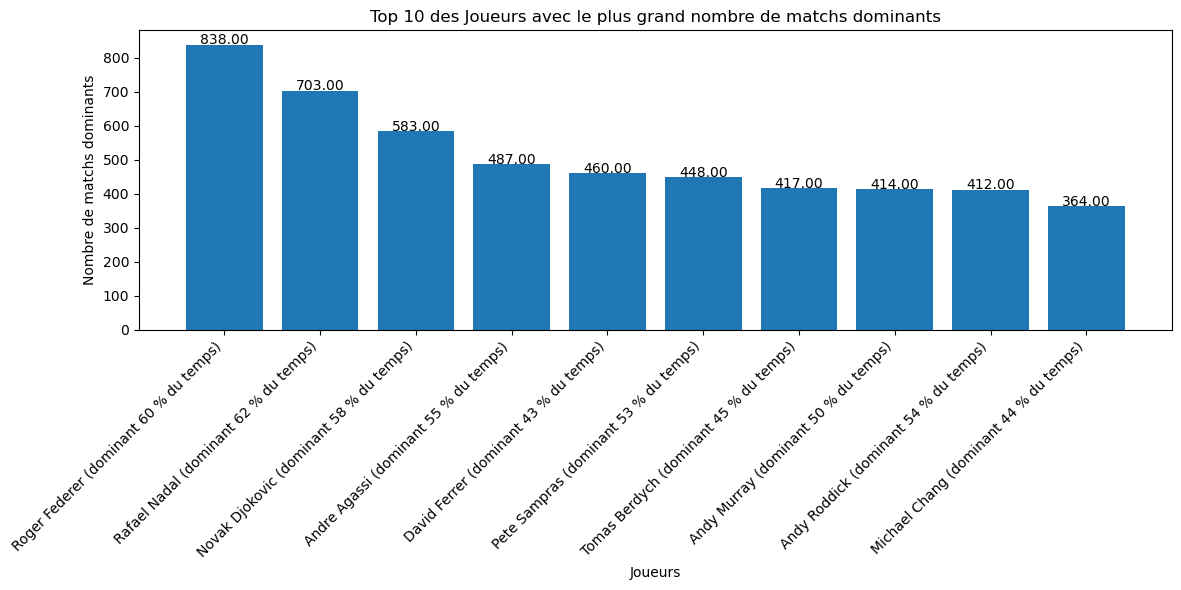

In [164]:
top_10_dominant = analyse_all_epoque_atp

# Création d'un champ dominants avec 0 par défaut et intégration de 1 si respecte les conditions 
top_10_dominant["match_dominant"] = 0
    # Si best_of = 3 ET nb_sets - nb_sets_player = 0 -> 1 (dominants en match BO3)
    # Si best_of = 5 ET nb_sets - nb_sets_player = 0 -> 1 (dominants en match BO5)
top_10_dominant.loc[(top_10_dominant['best_of'] == 3) & (top_10_dominant['nb_sets'] - top_10_dominant['nb_sets_player'] == 0), ['match_dominant']] = 1
top_10_dominant.loc[(top_10_dominant['best_of'] == 5) & (top_10_dominant['nb_sets'] - top_10_dominant['nb_sets_player'] == 0), ['match_dominant']] = 1

# (Pour faire le ratio) Indication par 1 tous les matchs pour comptabiliser le nombre de match au total
top_10_dominant["all_match"] = 1

# Group by pour rassembler autour des joueurs le nombre de matchs ou ils ont été dominants totalement
top_10_dominant = top_10_dominant.groupby(["player_id","player_name"]).agg({"match_dominant":"sum", "all_match":"sum"})
top_10_dominant = top_10_dominant.reset_index()

        # Calcul du nombre d'ace par match en moyenne
top_10_dominant["proportion_match_dominant"] = (top_10_dominant["match_dominant"] / top_10_dominant["all_match"])*100
top_10_dominant["proportion_match_dominant"] = top_10_dominant["proportion_match_dominant"].astype(int)
top_10_dominant["proportion_match_dominant"] = top_10_dominant["proportion_match_dominant"].astype(str)

        # Top 10
top_10_dominant= top_10_dominant.sort_values(by='match_dominant', ascending=False).head(10)  

#print(top_10_dominant)

    # --- #

# Visualisation sous forme de graphique à barre 

    # Créer un graphique à barres
plt.figure(figsize=(12, 6))
plt.bar(top_10_dominant["player_name"] + " (dominant " +top_10_dominant["proportion_match_dominant"] +" % du temps)", top_10_dominant["match_dominant"])
plt.xlabel("Joueurs")
plt.ylabel("Nombre de matchs dominants")
plt.title(f"Top 10 des Joueurs avec le plus grand nombre de matchs dominants")
plt.xticks(rotation=45, ha="right")

# Ajouter les étiquettes de données au-dessus des barres
for i, all_match in enumerate(top_10_dominant["match_dominant"]):
    plt.text(i, all_match + 1, f"{all_match:.2f}", ha="center")

# Afficher le graphique
plt.tight_layout()
plt.show()

# Intégration du nom de l'analyse
top_10_dominant["nom_analyse"] = "5.5.top10_player_dominant_perd_moins_set_atp_circuit_all_epoque" 

# Modification du naming contenant les valeurs de la proportion
top_10_dominant = top_10_dominant.rename(columns={"match_dominant": "valeurs"})

# Suppression de la colonne inutile 
top_10_dominant =top_10_dominant.drop(columns=['player_id', 'all_match'])

#print(top_10_dominant)

# Export des données pour tableau public
#top_10_dominant.to_excel(f"5.5.top10_player_dominant_perd_moins_set_atp_circuit_all_epoque.xlsx",  sheet_name='Sheet_name_1') 

### 4.5.6.1. Top 10 : Joueurs qui sont les plus dominants sur les services (Nombre d'aces) - depuis 1990

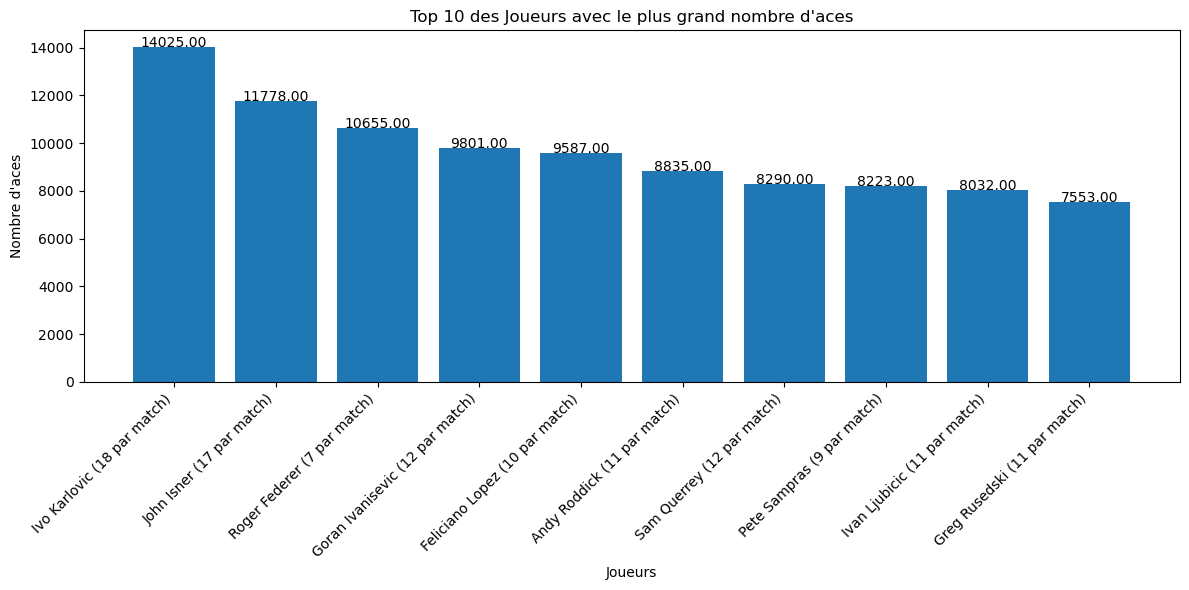

In [165]:
top_10_ace = analyse_all_epoque_atp

    # A. Traitement récupération du nombre d'aces + top 10 de ceux qui en ont le plus d'ace

top_10_ace["all_match"] = 1
    
        # Group pour rassembler les données autour des joueurs et des années
top_10_ace = top_10_ace.groupby(["player_id","player_name"]).agg({"p_ace":"sum", "all_match":"sum"})
top_10_ace = top_10_ace.reset_index()

        # Calcul du nombre d'ace par match en moyenne
top_10_ace["ratio_ace_per_match"] = top_10_ace["p_ace"] / top_10_ace["all_match"]
top_10_ace["ratio_ace_per_match"] = top_10_ace["ratio_ace_per_match"].astype(int)
top_10_ace["ratio_ace_per_match"] = top_10_ace["ratio_ace_per_match"].astype(str)

        # Top 10
top_10_ace= top_10_ace.sort_values(by='p_ace', ascending=False).head(10)  

#print(top_10_ace)
    
    # --- #

# Visualisation sous forme de graphique à barre 

    # Créer un graphique à barres
plt.figure(figsize=(12, 6))
plt.bar(top_10_ace["player_name"] + " ("+ top_10_ace["ratio_ace_per_match"] +" par match)", top_10_ace["p_ace"])
plt.xlabel("Joueurs")
plt.ylabel("Nombre d'aces")
plt.title(f"Top 10 des Joueurs avec le plus grand nombre d'aces")
plt.xticks(rotation=45, ha="right")

# Ajouter les étiquettes de données au-dessus des barres
for i, all_match in enumerate(top_10_ace["p_ace"]):
    plt.text(i, all_match + 1, f"{all_match:.2f}", ha="center")

# Afficher le graphique
plt.tight_layout()
plt.show()

# Intégration du nom de l'analyse
top_10_ace["nom_analyse"] = "5.6.top10_player_plus_ace_atp_circuit_all_epoque" 

# Modification du naming contenant les valeurs de la proportion
top_10_ace = top_10_ace.rename(columns={"p_ace": "valeurs"})

# Suppression de la colonne inutile 
top_10_ace =top_10_ace.drop(columns=['player_id',"all_match"])

#print(top_10_ace)

# Export des données pour tableau public
#top_10_ace.to_excel(f"5.6.top10_player_plus_ace_atp_circuit_all_epoque.xlsx",  sheet_name='Sheet_name_1') 

### 4.5.6.2. Top 10 : Joueurs qui ont le plus de sang froid lors des points importants (Nombre de balles de breaks sauvées) - depuis 1990

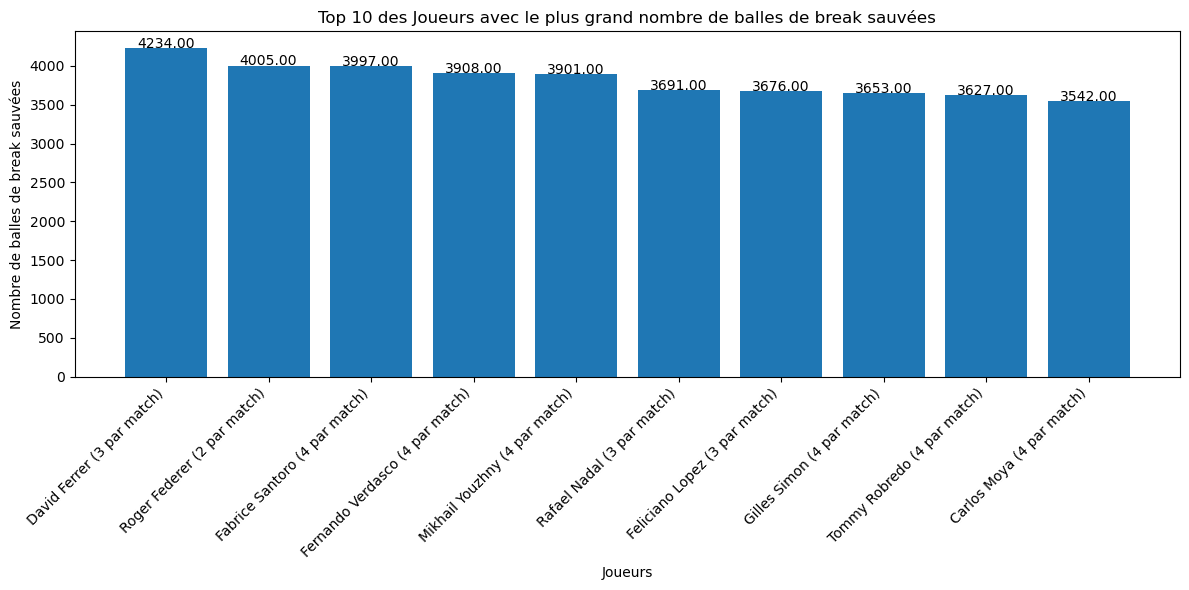

In [166]:
top_10_bp = analyse_all_epoque_atp

    # A. Traitement récupération du nombre d'aces + top 10 de ceux qui en ont le plus d'ace

top_10_bp["all_match"] = 1
    
        # Group pour rassembler les données autour des joueurs et des années
top_10_bp = top_10_bp.groupby(["player_id","player_name"]).agg({"p_bpSaved":"sum", "all_match":"sum"})
top_10_bp = top_10_bp.reset_index()

        # Calcul du nombre d'ace par match en moyenne
top_10_bp["ratio_bp_per_match"] = top_10_bp["p_bpSaved"] / top_10_bp["all_match"]
top_10_bp["ratio_bp_per_match"] = top_10_bp["ratio_bp_per_match"].astype(int)
top_10_bp["ratio_bp_per_match"] = top_10_bp["ratio_bp_per_match"].astype(str)

        # Top 10
top_10_bp= top_10_bp.sort_values(by='p_bpSaved', ascending=False).head(10)  

#print(top_10_bp)
    
    # --- #

# Visualisation sous forme de graphique à barre 

    # Créer un graphique à barres
plt.figure(figsize=(12, 6))
plt.bar(top_10_bp["player_name"] + " ("+ top_10_bp["ratio_bp_per_match"] +" par match)", top_10_bp["p_bpSaved"])
plt.xlabel("Joueurs")
plt.ylabel("Nombre de balles de break sauvées")
plt.title(f"Top 10 des Joueurs avec le plus grand nombre de balles de break sauvées")
plt.xticks(rotation=45, ha="right")

# Ajouter les étiquettes de données au-dessus des barres
for i, all_match in enumerate(top_10_bp["p_bpSaved"]):
    plt.text(i, all_match + 1, f"{all_match:.2f}", ha="center")

# Afficher le graphique
plt.tight_layout()
plt.show()


# Intégration du nom de l'analyse
top_10_bp["nom_analyse"] = "5.7.top10_player_more_break_save_atp_circuit_all_epoque" 

# Modification du naming contenant les valeurs de la proportion
top_10_bp = top_10_bp.rename(columns={"p_bpSaved": "valeurs"})

# Suppression de la colonne inutile 
top_10_bp =top_10_bp.drop(columns=['player_id', "all_match"])

#print(top_10_bp)

# Export des données pour tableau public
#top_10_bp.to_excel(f"5.7.top10_player_more_break_save_atp_circuit_all_epoque.xlsx",  sheet_name='Sheet_name_1') 

 ### 4.5.6.3. TOP 10 : Joueurs qui sont les moins précis au service (Nombre de Doubles fautes) - depuis 1990

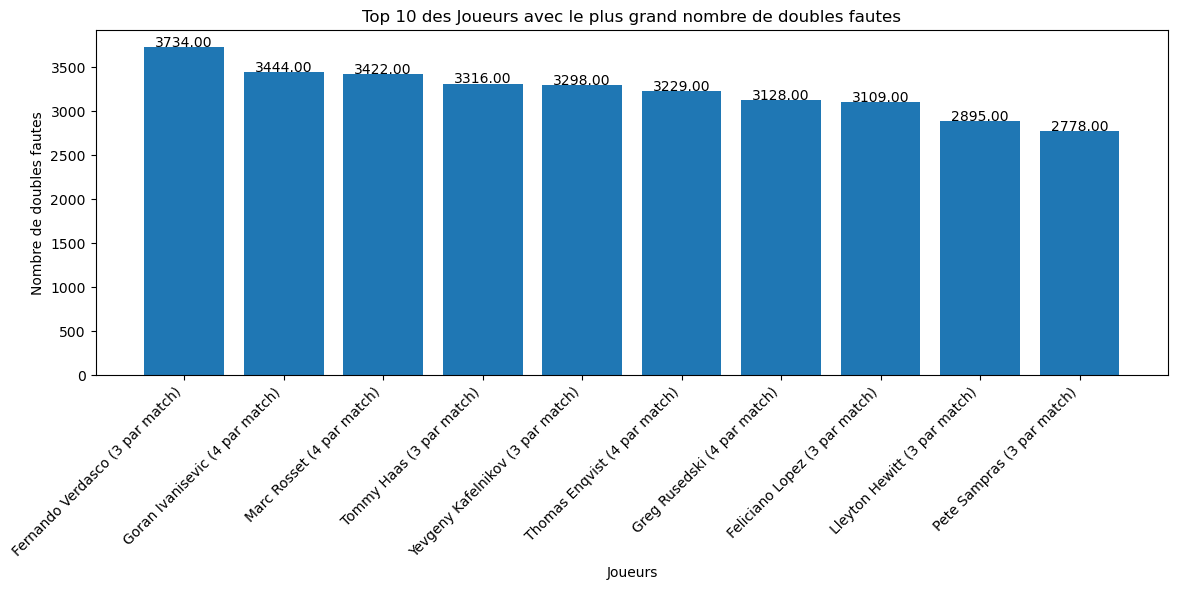

In [167]:
top_10_df = analyse_all_epoque_atp

    # A. Traitement récupération du nombre d'aces + top 10 de ceux qui en ont le plus d'ace

top_10_df["all_match"] = 1
    
        # Group pour rassembler les données autour des joueurs et des années
top_10_df = top_10_df.groupby(["player_id","player_name"]).agg({"p_df":"sum", "all_match":"sum"})
top_10_df = top_10_df.reset_index()

        # Calcul du nombre d'ace par match en moyenne
top_10_df["ratio_df_per_match"] = top_10_df["p_df"] / top_10_df["all_match"]
top_10_df["ratio_df_per_match"] = top_10_df["ratio_df_per_match"].astype(int)
top_10_df["ratio_df_per_match"] = top_10_df["ratio_df_per_match"].astype(str)

        # Top 10
top_10_df= top_10_df.sort_values(by='p_df', ascending=False).head(10)  

#print(top_10_bp)
    
    # --- #

# Visualisation sous forme de graphique à barre 

    # Créer un graphique à barres
plt.figure(figsize=(12, 6))
plt.bar(top_10_df["player_name"] + " ("+ top_10_df["ratio_df_per_match"] +" par match)", top_10_df["p_df"])
plt.xlabel("Joueurs")
plt.ylabel("Nombre de doubles fautes")
plt.title(f"Top 10 des Joueurs avec le plus grand nombre de doubles fautes")
plt.xticks(rotation=45, ha="right")

# Ajouter les étiquettes de données au-dessus des barres
for i, all_match in enumerate(top_10_df["p_df"]):
    plt.text(i, all_match + 1, f"{all_match:.2f}", ha="center")

# Afficher le graphique
plt.tight_layout()
plt.show()

# Intégration du nom de l'analyse
top_10_df["nom_analyse"] = "5.8.top10_player_more_double_faute_atp_circuit_all_epoque" 

# Modification du naming contenant les valeurs de la proportion
top_10_df = top_10_df.rename(columns={"p_df": "valeurs"})

# Suppression de la colonne inutile 
top_10_df =top_10_df.drop(columns=['player_id', "all_match"])

#print(top_10_df)

# Export des données pour tableau public
#top_10_df.to_excel(f"5.8.top10_player_more_double_faute_atp_circuit_all_epoque.xlsx",  sheet_name='Sheet_name_1') 

### Concaténation des données de la thématique 5 pour l'utilisation sur Tableau Public, et obtenir des filtres communs sur le dashboard


In [168]:
# Concaténation des deux jeux de données, pour pouvoir ensuite les exporter et les traiter sur tableau
tableau_thematique_5 = pd.concat([top_10_winrate_nb_all_nb_win,df_top_10_win_loose_rate_final,df_top_10_endurance_bo3_bo5,top_10_longevite_elite,top_10_dominant,top_10_ace,top_10_bp,top_10_df], axis=0)


# Indication "no_data" sur les valeurs NULL
tableau_thematique_5 = tableau_thematique_5.fillna("no_data")


#print(tableau_thematique_5)

# Export des données
tableau_thematique_5.to_excel("thematique_5_data.xlsx",  sheet_name='Sheet_name_1') 